In [1]:
# ============================================================
# CELL 1 — NOTEBOOK 07 INITIALIZATION
# CXR LUNG-REGION PROCESSING USING TORCHXRAYVISION PSPNET
# ============================================================

from pathlib import Path
import sys
import os
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn

import torchvision.transforms as transforms

import torchxrayvision as xrv

warnings.filterwarnings("ignore")

print("=" * 80)
print("NOTEBOOK 07 — CXR LUNG-REGION PROCESSING")
print("=" * 80)

print()
print("Python version :", sys.version)
print("PyTorch version:", torch.__version__)
print("TorchXRayVision:", getattr(xrv, "__version__", "version attribute unavailable"))

print()
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

NOTEBOOK 07 — CXR LUNG-REGION PROCESSING

Python version : 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
PyTorch version: 2.13.0+cpu
TorchXRayVision: 1.5.2

CUDA available: False
Using CPU


In [2]:
# ============================================================
# CELL 2 — NOTEBOOK 06 / NOTEBOOK 07 PATHS
# ============================================================

BASE_DIR = Path(r"C:\TBP")

METADATA_DIR = (
    BASE_DIR /
    "Metadata"
)

NOTEBOOK06_DIR = (
    METADATA_DIR /
    "Step_3B_6_51_CXR_Extraction_Technical_Preprocessing"
)

PNG_DIR = (
    NOTEBOOK06_DIR /
    "Technical_PNG"
)

QC_DIR = (
    NOTEBOOK06_DIR /
    "QC"
)

# ------------------------------------------------------------
# Notebook 07
# ------------------------------------------------------------

NOTEBOOK07_DIR = (
    METADATA_DIR /
    "Step_3B_7_CXR_Lung_Region_Processing"
)

MASK_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Masks"
)

LUNG_CXR_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Focused_CXR"
)

NOTEBOOK07_QC_DIR = (
    NOTEBOOK07_DIR /
    "QC"
)

for directory in [
    NOTEBOOK07_DIR,
    MASK_DIR,
    LUNG_CXR_DIR,
    NOTEBOOK07_QC_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 80)
print("PATH CONFIGURATION")
print("=" * 80)

print()
print("Input PNG directory:")
print(PNG_DIR)

print()
print("Notebook 07 directory:")
print(NOTEBOOK07_DIR)

print()
print("Mask directory:")
print(MASK_DIR)

print()
print("Lung-focused CXR directory:")
print(LUNG_CXR_DIR)

print()
print("Notebook 07 QC directory:")
print(NOTEBOOK07_QC_DIR)

PATH CONFIGURATION

Input PNG directory:
C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Technical_PNG

Notebook 07 directory:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing

Mask directory:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Lung_Masks

Lung-focused CXR directory:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Lung_Focused_CXR

Notebook 07 QC directory:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC


In [3]:
# ============================================================
# CELL 3 — VERIFY NOTEBOOK 06 INPUT
# ============================================================

EXPECTED = 2081

png_files = sorted(
    PNG_DIR.glob("*.png")
)

print("=" * 80)
print("NOTEBOOK 06 INPUT VERIFICATION")
print("=" * 80)

print()
print("Expected PNG files :", EXPECTED)
print("Found PNG files    :", len(png_files))

if len(png_files) != EXPECTED:
    raise RuntimeError(
        f"Expected {EXPECTED} PNG files, "
        f"but found {len(png_files)}."
    )

png_stems = {
    p.stem
    for p in png_files
}

if len(png_stems) != EXPECTED:
    raise RuntimeError(
        "Duplicate PNG stems detected."
    )

print()
print("Input file count: PASS")
print("Input filename uniqueness: PASS")

NOTEBOOK 06 INPUT VERIFICATION

Expected PNG files : 2081
Found PNG files    : 2081

Input file count: PASS
Input filename uniqueness: PASS


In [4]:
# ============================================================
# CELL 4 — LOAD TORCHXRAYVISION PSPNET
# ============================================================

print("=" * 80)
print("CELL 4 — LOADING TORCHXRAYVISION PSPNET")
print("=" * 80)

# ------------------------------------------------------------
# Load ChestX-Det PSPNet
# ------------------------------------------------------------

model = xrv.baseline_models.chestx_det.PSPNet()

# ------------------------------------------------------------
# CPU execution
# ------------------------------------------------------------

DEVICE = torch.device("cpu")

model = model.to(DEVICE)
model.eval()

print()
print("Model class :", type(model).__name__)
print("Device      :", DEVICE)
print("Model mode  :", "evaluation" if not model.training else "training")

print()
print("PSPNet loaded successfully.")

CELL 4 — LOADING TORCHXRAYVISION PSPNET

Model class : PSPNet
Device      : cpu
Model mode  : evaluation

PSPNet loaded successfully.


In [5]:
# ============================================================
# CELL 5 — INSPECT PSPNET OUTPUT / ANATOMICAL CLASSES
# ============================================================

print("=" * 80)
print("CELL 5 — PSPNET MODEL / OUTPUT INSPECTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Inspect model attributes
# ------------------------------------------------------------

print()
print("Model type:")
print(type(model))

print()
print("Available model attributes related to classes:")

for attr in [
    "targets",
    "classes",
    "labels",
    "pathologies"
]:
    if hasattr(model, attr):
        value = getattr(model, attr)

        print()
        print(f"{attr}:")
        print(value)


# ------------------------------------------------------------
# 2. Inspect model architecture summary
# ------------------------------------------------------------

print()
print("-" * 80)
print("MODEL REPRESENTATION")
print("-" * 80)

print(model)


# ------------------------------------------------------------
# 3. Inspect state / parameter information
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print()
print("-" * 80)
print("PARAMETER INFORMATION")
print("-" * 80)

print()
print("Total parameters    :", total_parameters)
print("Trainable parameters:", trainable_parameters)


print()
print("=" * 80)
print("PSPNET INSPECTION COMPLETE")
print("=" * 80)

CELL 5 — PSPNET MODEL / OUTPUT INSPECTION

Model type:
<class 'torchxrayvision.baseline_models.chestx_det.PSPNet'>

Available model attributes related to classes:

targets:
['Left Clavicle', 'Right Clavicle', 'Left Scapula', 'Right Scapula', 'Left Lung', 'Right Lung', 'Left Hilus Pulmonis', 'Right Hilus Pulmonis', 'Heart', 'Aorta', 'Facies Diaphragmatica', 'Mediastinum', 'Weasand', 'Spine']

--------------------------------------------------------------------------------
MODEL REPRESENTATION
--------------------------------------------------------------------------------
chestx-det-pspnet

--------------------------------------------------------------------------------
PARAMETER INFORMATION
--------------------------------------------------------------------------------

Total parameters    : 68068316
Trainable parameters: 68068316

PSPNET INSPECTION COMPLETE


In [9]:
# ============================================================
# CELL 6 — SINGLE-CXR PSPNET VALIDATION
# OFFICIAL TORCHXRAYVISION PREPROCESSING PIPELINE
# ============================================================

print("=" * 80)
print("CELL 6 — SINGLE-CXR PSPNET VALIDATION")
print("=" * 80)


# ------------------------------------------------------------
# 1. Select test image
# ------------------------------------------------------------

if len(png_files) == 0:
    raise RuntimeError(
        "No PNG files found."
    )

TEST_IMAGE_PATH = png_files[0]

print()
print("Test image:")
print(TEST_IMAGE_PATH)


# ------------------------------------------------------------
# 2. Load image
# ------------------------------------------------------------

with Image.open(TEST_IMAGE_PATH) as img:

    img = img.convert("L")

    image_array = np.asarray(
        img,
        dtype=np.float32
    )


print()
print("Original shape:",
      image_array.shape)

print(
    "Original dtype:",
    image_array.dtype
)

print(
    "Original range:",
    float(image_array.min()),
    "to",
    float(image_array.max())
)


# ------------------------------------------------------------
# 3. Function for exact TorchXRayVision preprocessing
# ------------------------------------------------------------

def prepare_pspnet_input(img_array):

    # Normalize 8-bit image to TorchXRayVision range
    img_norm = xrv.utils.normalize(
        img_array,
        maxval=255,
        reshape=False
    )

    # Single-channel format:
    # H x W
    # ->
    # 1 x H x W
    img_norm = img_norm[None, ...]

    # Exact preprocessing used in the
    # official TorchXRayVision segmentation demo:
    #
    # Center crop
    # Resize to 512
    transform = transforms.Compose([
        xrv.datasets.XRayCenterCrop(),
        xrv.datasets.XRayResizer(512)
    ])

    img_processed = transform(
        img_norm
    )

    # Convert numpy -> tensor
    tensor = torch.from_numpy(
        img_processed
    ).float()

    # Add batch dimension
    #
    # 1 x 512 x 512
    # ->
    # 1 x 1 x 512 x 512

    tensor = tensor.unsqueeze(0)

    return tensor


# ------------------------------------------------------------
# 4. Prepare NORMAL representation
# ------------------------------------------------------------

normal_input = prepare_pspnet_input(
    image_array
)

normal_input = normal_input.to(
    DEVICE
)


print()
print(
    "Normal PSPNet input shape:",
    tuple(normal_input.shape)
)

print(
    "Normal PSPNet input range:",
    float(normal_input.min()),
    "to",
    float(normal_input.max())
)


# ------------------------------------------------------------
# 5. Prepare INVERTED representation
# ------------------------------------------------------------
#
# This is diagnostic only.
#
# We are NOT deciding yet that the image should be inverted.
#
# If the normal representation fails but the inverted
# representation produces anatomically plausible masks,
# we will investigate the photometric/polarity handling
# before processing the dataset.
# ------------------------------------------------------------

inverted_image = (
    255.0 -
    image_array
)

inverted_input = prepare_pspnet_input(
    inverted_image
)

inverted_input = inverted_input.to(
    DEVICE
)


print()
print(
    "Inverted PSPNet input shape:",
    tuple(inverted_input.shape)
)

print(
    "Inverted PSPNet input range:",
    float(inverted_input.min()),
    "to",
    float(inverted_input.max())
)


# ------------------------------------------------------------
# 6. Run NORMAL image through PSPNet
# ------------------------------------------------------------

with torch.no_grad():

    normal_output = model(
        normal_input
    )


# ------------------------------------------------------------
# 7. Run INVERTED image through PSPNet
# ------------------------------------------------------------

with torch.no_grad():

    inverted_output = model(
        inverted_input
    )


# ------------------------------------------------------------
# 8. Verify output dimensions
# ------------------------------------------------------------

expected_channels = len(
    model.targets
)

if normal_output.shape != (
    1,
    expected_channels,
    512,
    512
):

    raise RuntimeError(
        "Unexpected normal PSPNet output shape: "
        f"{tuple(normal_output.shape)}"
    )


if inverted_output.shape != (
    1,
    expected_channels,
    512,
    512
):

    raise RuntimeError(
        "Unexpected inverted PSPNet output shape: "
        f"{tuple(inverted_output.shape)}"
    )


print()
print("-" * 80)
print("PSPNET OUTPUT")
print("-" * 80)

print()
print(
    "Normal output shape:",
    tuple(normal_output.shape)
)

print(
    "Inverted output shape:",
    tuple(inverted_output.shape)
)


# ------------------------------------------------------------
# 9. Identify lung channels dynamically
# ------------------------------------------------------------

LEFT_LUNG_INDEX = model.targets.index(
    "Left Lung"
)

RIGHT_LUNG_INDEX = model.targets.index(
    "Right Lung"
)

print()
print(
    "Left Lung index :",
    LEFT_LUNG_INDEX
)

print(
    "Right Lung index:",
    RIGHT_LUNG_INDEX
)


# ------------------------------------------------------------
# 10. Convert lung outputs to probabilities
# ------------------------------------------------------------

normal_left_prob = torch.sigmoid(
    normal_output[
        0,
        LEFT_LUNG_INDEX
    ]
)

normal_right_prob = torch.sigmoid(
    normal_output[
        0,
        RIGHT_LUNG_INDEX
    ]
)

inverted_left_prob = torch.sigmoid(
    inverted_output[
        0,
        LEFT_LUNG_INDEX
    ]
)

inverted_right_prob = torch.sigmoid(
    inverted_output[
        0,
        RIGHT_LUNG_INDEX
    ]
)


# ------------------------------------------------------------
# 11. Probability statistics
# ------------------------------------------------------------

print()
print("-" * 80)
print("NORMAL REPRESENTATION")
print("-" * 80)

print()
print(
    "Left Lung probability:",
    float(normal_left_prob.min()),
    "to",
    float(normal_left_prob.max())
)

print(
    "Right Lung probability:",
    float(normal_right_prob.min()),
    "to",
    float(normal_right_prob.max())
)


print()
print("-" * 80)
print("INVERTED REPRESENTATION")
print("-" * 80)

print()
print(
    "Left Lung probability:",
    float(inverted_left_prob.min()),
    "to",
    float(inverted_left_prob.max())
)

print(
    "Right Lung probability:",
    float(inverted_right_prob.min()),
    "to",
    float(inverted_right_prob.max())
)


# ------------------------------------------------------------
# 12. Create 0.5 masks
# ------------------------------------------------------------

normal_left_mask = (
    normal_left_prob >= 0.5
)

normal_right_mask = (
    normal_right_prob >= 0.5
)

inverted_left_mask = (
    inverted_left_prob >= 0.5
)

inverted_right_mask = (
    inverted_right_prob >= 0.5
)


# ------------------------------------------------------------
# 13. Calculate coverage
# ------------------------------------------------------------

normal_combined = (
    normal_left_mask |
    normal_right_mask
)

inverted_combined = (
    inverted_left_mask |
    inverted_right_mask
)


def mask_statistics(mask):

    pixels = int(
        mask.sum().item()
    )

    total = mask.numel()

    coverage = (
        pixels / total
    )

    return pixels, coverage


normal_pixels, normal_coverage = (
    mask_statistics(
        normal_combined
    )
)

inverted_pixels, inverted_coverage = (
    mask_statistics(
        inverted_combined
    )
)


# ------------------------------------------------------------
# 14. Print mask statistics
# ------------------------------------------------------------

print()
print("-" * 80)
print("MASK STATISTICS")
print("-" * 80)

print()
print(
    "NORMAL combined mask pixels:",
    normal_pixels
)

print(
    "NORMAL combined coverage:",
    f"{normal_coverage:.4%}"
)

print()
print(
    "INVERTED combined mask pixels:",
    inverted_pixels
)

print(
    "INVERTED combined coverage:",
    f"{inverted_coverage:.4%}"
)


# ------------------------------------------------------------
# 15. Do NOT fail simply because normal mask is empty
# ------------------------------------------------------------
#
# This cell is diagnostic.
#
# We intentionally do not force a threshold change.
# We need to inspect both representations first.
# ------------------------------------------------------------

print()
print("=" * 80)
print("CELL 6 — PSPNET DIAGNOSTIC TEST COMPLETE")
print("=" * 80)

print()
print(
    "No masks have been saved."
)

print(
    "No original images have been modified."
)

print(
    "No full-dataset processing has been started."
)

print()
print(
    "Next step: inspect the probability/coverage results "
    "before processing all 2,081 CXRs."
)

print("=" * 80)

CELL 6 — SINGLE-CXR PSPNET VALIDATION

Test image:
C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Technical_PNG\0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5.png

Original shape: (2972, 3674)
Original dtype: float32
Original range: 0.0 to 255.0

Normal PSPNet input shape: (1, 1, 512, 512)
Normal PSPNet input range: -509.3472595214844 to 1024.0

Inverted PSPNet input shape: (1, 1, 512, 512)
Inverted PSPNet input range: -1024.0 to 509.3472595214844

--------------------------------------------------------------------------------
PSPNET OUTPUT
--------------------------------------------------------------------------------

Normal output shape: (1, 14, 512, 512)
Inverted output shape: (1, 14, 512, 512)

Left Lung index : 4
Right Lung index: 5

--------------------------------------------------------------------------------
NORMAL REPRESENTATION
--------------------------------------------------------------------------------

Left Lung probability: 0.00931497104465

In [10]:
# ============================================================
# CELL 7 — PSPNET MULTI-IMAGE DIAGNOSTIC
# ============================================================

print("=" * 80)
print("CELL 7 — PSPNET MULTI-IMAGE DIAGNOSTIC")
print("=" * 80)


# ------------------------------------------------------------
# 1. Select 5 different images
# ------------------------------------------------------------

TEST_IMAGES = png_files[:5]

print()
print("Number of diagnostic images:", len(TEST_IMAGES))


# ------------------------------------------------------------
# 2. Helper function
# ------------------------------------------------------------

def prepare_pspnet_image(image_path):

    with Image.open(image_path) as img:

        img = img.convert("L")

        arr = np.asarray(
            img,
            dtype=np.float32
        )

    # TorchXRayVision normalization
    arr = xrv.utils.normalize(
        arr,
        maxval=255,
        reshape=False
    )

    # Add channel dimension
    arr = arr[None, ...]

    # Official preprocessing
    transform = transforms.Compose([
        xrv.datasets.XRayCenterCrop(),
        xrv.datasets.XRayResizer(512)
    ])

    arr = transform(arr)

    tensor = torch.from_numpy(
        arr
    ).float()

    tensor = tensor.unsqueeze(0)

    return tensor.to(DEVICE)


# ------------------------------------------------------------
# 3. Run diagnostic images
# ------------------------------------------------------------

diagnostic_rows = []

for index, image_path in enumerate(
    TEST_IMAGES,
    start=1
):

    print()
    print(
        f"Processing diagnostic image "
        f"{index}/{len(TEST_IMAGES)}"
    )

    print(
        "File:",
        image_path.name
    )

    try:

        input_tensor = prepare_pspnet_image(
            image_path
        )

        with torch.no_grad():

            output = model(
                input_tensor
            )

        left_prob = torch.sigmoid(
            output[
                0,
                LEFT_LUNG_INDEX
            ]
        )

        right_prob = torch.sigmoid(
            output[
                0,
                RIGHT_LUNG_INDEX
            ]
        )

        left_max = float(
            left_prob.max()
        )

        right_max = float(
            right_prob.max()
        )

        left_mean = float(
            left_prob.mean()
        )

        right_mean = float(
            right_prob.mean()
        )

        combined_max = max(
            left_max,
            right_max
        )

        combined_pixels = int(
            (
                (left_prob >= 0.5)
                |
                (right_prob >= 0.5)
            ).sum().item()
        )

        diagnostic_rows.append({
            "image": image_path.name,
            "left_max": left_max,
            "right_max": right_max,
            "left_mean": left_mean,
            "right_mean": right_mean,
            "combined_max": combined_max,
            "pixels_at_0.5": combined_pixels
        })

        print(
            "Left max :",
            left_max
        )

        print(
            "Right max:",
            right_max
        )

        print(
            "Left mean:",
            left_mean
        )

        print(
            "Right mean:",
            right_mean
        )

        print(
            "Pixels >= 0.5:",
            combined_pixels
        )

    except Exception as e:

        print(
            "ERROR:",
            type(e).__name__,
            str(e)
        )

        diagnostic_rows.append({
            "image": image_path.name,
            "left_max": np.nan,
            "right_max": np.nan,
            "left_mean": np.nan,
            "right_mean": np.nan,
            "combined_max": np.nan,
            "pixels_at_0.5": np.nan
        })


# ------------------------------------------------------------
# 4. Diagnostic table
# ------------------------------------------------------------

diagnostic_df = pd.DataFrame(
    diagnostic_rows
)

print()
print("=" * 80)
print("MULTI-IMAGE PSPNET DIAGNOSTIC RESULTS")
print("=" * 80)

print()

print(
    diagnostic_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 5. Overall statistics
# ------------------------------------------------------------

valid_results = diagnostic_df[
    diagnostic_df["combined_max"].notna()
]

if len(valid_results) == 0:

    raise RuntimeError(
        "All diagnostic PSPNet runs failed."
    )


print()
print("-" * 80)
print("OVERALL DIAGNOSTIC")
print("-" * 80)

print()
print(
    "Valid images:",
    len(valid_results)
)

print(
    "Highest observed lung probability:",
    float(
        valid_results["combined_max"].max()
    )
)

print(
    "Mean observed lung probability:",
    float(
        valid_results["combined_max"].mean()
    )
)

print(
    "Images producing >=0.5 mask pixels:",
    int(
        (
            valid_results["pixels_at_0.5"]
            > 0
        ).sum()
    )
)


# ------------------------------------------------------------
# 6. Do not process full dataset
# ------------------------------------------------------------

print()
print("=" * 80)
print("CELL 7 — DIAGNOSTIC TEST COMPLETE")
print("=" * 80)

print()
print(
    "No masks were saved."
)

print(
    "No images were modified."
)

print(
    "Full 2,081-image processing has NOT started."
)

print("=" * 80)

CELL 7 — PSPNET MULTI-IMAGE DIAGNOSTIC

Number of diagnostic images: 5

Processing diagnostic image 1/5
File: 0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5.png
Left max : 0.056366000324487686
Right max: 0.008932127617299557
Left mean: 0.04063129425048828
Right mean: 0.0009905679617077112
Pixels >= 0.5: 0

Processing diagnostic image 2/5
File: 000e6c76-07b4-43cc-b668-048612911ce4_d3362ea733ea.png
Left max : 0.05654086917638779
Right max: 0.006255056243389845
Left mean: 0.03661167621612549
Right mean: 0.0009348019957542419
Pixels >= 0.5: 0

Processing diagnostic image 3/5
File: 001dc6ee-4925-4505-a4f6-e79d2e31d1cf_64f937622bcb.png
Left max : 0.04260751232504845
Right max: 0.006517739500850439
Left mean: 0.027465935796499252
Right mean: 0.0009441485744901001
Pixels >= 0.5: 0

Processing diagnostic image 4/5
File: 00376922-57ad-47be-9b42-9fa35cfbb1a8_3c4cd363ffcc.png
Left max : 0.06304282695055008
Right max: 0.019770044833421707
Left mean: 0.03323681652545929
Right mean: 0.003246570006

In [11]:
# ============================================================
# CELL 8 — VERIFY TORCHXRAYVISION PSPNET CHECKPOINT
# ============================================================

print("=" * 80)
print("CELL 8 — VERIFY PSPNET PRETRAINED CHECKPOINT")
print("=" * 80)


# ------------------------------------------------------------
# 1. Locate the checkpoint used by the loaded model
# ------------------------------------------------------------

if not hasattr(
    model,
    "weights_filename_local"
):

    raise RuntimeError(
        "The loaded PSPNet does not expose "
        "weights_filename_local."
    )

WEIGHTS_PATH = Path(
    model.weights_filename_local
)

print()
print("PSPNet checkpoint:")
print(WEIGHTS_PATH)


# ------------------------------------------------------------
# 2. Check existence
# ------------------------------------------------------------

if not WEIGHTS_PATH.exists():

    raise FileNotFoundError(
        f"PSPNet checkpoint not found:\n"
        f"{WEIGHTS_PATH}"
    )

print()
print("Checkpoint exists: PASS")


# ------------------------------------------------------------
# 3. File information
# ------------------------------------------------------------

file_size_bytes = (
    WEIGHTS_PATH.stat().st_size
)

file_size_mb = (
    file_size_bytes /
    (1024 ** 2)
)

print()
print("Checkpoint size:")
print(
    f"{file_size_bytes:,} bytes"
)

print(
    f"{file_size_mb:.2f} MB"
)


# ------------------------------------------------------------
# 4. SHA-256 checksum
# ------------------------------------------------------------

print()
print("Calculating SHA-256 checksum...")

sha256 = hashlib.sha256()

with open(
    WEIGHTS_PATH,
    "rb"
) as f:

    while True:

        chunk = f.read(
            1024 * 1024
        )

        if not chunk:
            break

        sha256.update(chunk)

checkpoint_hash = (
    sha256.hexdigest()
)

print()
print(
    "SHA-256:"
)

print(
    checkpoint_hash
)


# ------------------------------------------------------------
# 5. Inspect loaded PSPNet parameter statistics
# ------------------------------------------------------------

print()
print("-" * 80)
print("LOADED MODEL PARAMETER CHECK")
print("-" * 80)

all_parameter_values = []

for name, parameter in model.named_parameters():

    if parameter.numel() == 0:
        continue

    values = parameter.detach().cpu()

    all_parameter_values.append(
        values.reshape(-1)
    )


all_parameter_values = torch.cat(
    all_parameter_values
)


parameter_min = float(
    all_parameter_values.min()
)

parameter_max = float(
    all_parameter_values.max()
)

parameter_mean = float(
    all_parameter_values.mean()
)

parameter_std = float(
    all_parameter_values.std()
)


print()
print(
    "Parameter minimum:",
    parameter_min
)

print(
    "Parameter maximum:",
    parameter_max
)

print(
    "Parameter mean:",
    parameter_mean
)

print(
    "Parameter std:",
    parameter_std
)


# ------------------------------------------------------------
# 6. Check for NaN / Inf parameters
# ------------------------------------------------------------

nan_count = int(
    torch.isnan(
        all_parameter_values
    ).sum()
)

inf_count = int(
    torch.isinf(
        all_parameter_values
    ).sum()
)

print()
print(
    "NaN parameter values:",
    nan_count
)

print(
    "Inf parameter values:",
    inf_count
)


if nan_count != 0:

    raise RuntimeError(
        "PSPNet contains NaN parameters."
    )

if inf_count != 0:

    raise RuntimeError(
        "PSPNet contains Inf parameters."
    )


# ------------------------------------------------------------
# 7. Model parameter count
# ------------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

print()
print(
    "Total parameters:",
    total_parameters
)


# ------------------------------------------------------------
# 8. Final checkpoint verification
# ------------------------------------------------------------

print()
print("=" * 80)
print("CELL 8 — CHECKPOINT VERIFICATION COMPLETE")
print("=" * 80)

print()
print("Checkpoint exists : PASS")
print("Parameter NaN     :", nan_count)
print("Parameter Inf     :", inf_count)
print("Parameter count   :", total_parameters)

print()
print(
    "Do NOT process the 2,081 CXRs yet."
)

print("=" * 80)

CELL 8 — VERIFY PSPNET PRETRAINED CHECKPOINT

PSPNet checkpoint:
C:\Users\Gobika\.torchxrayvision\models_data\pspnet_chestxray_best_model_4.pth

Checkpoint exists: PASS

Checkpoint size:
272,988,989 bytes
260.34 MB

Calculating SHA-256 checksum...

SHA-256:
019b167eac6b729fc1bb92bbbc185fc1730aaa65819f4e3fe718186cadc044fc

--------------------------------------------------------------------------------
LOADED MODEL PARAMETER CHECK
--------------------------------------------------------------------------------

Parameter minimum: -9.556872367858887
Parameter maximum: 6.976750373840332
Parameter mean: -0.00027630740078166127
Parameter std: 0.052033744752407074

NaN parameter values: 0
Inf parameter values: 0

Total parameters: 68068316

CELL 8 — CHECKPOINT VERIFICATION COMPLETE

Checkpoint exists : PASS
Parameter NaN     : 0
Parameter Inf     : 0
Parameter count   : 68068316

Do NOT process the 2,081 CXRs yet.


In [12]:
# ============================================================
# CELL 9 — OFFICIAL TORCHXRAYVISION SAMPLE TEST
# ============================================================

print("=" * 80)
print("CELL 9 — OFFICIAL TORCHXRAYVISION SAMPLE TEST")
print("=" * 80)

import urllib.request


# ------------------------------------------------------------
# 1. Official sample image
# ------------------------------------------------------------

SAMPLE_URL = (
    "https://raw.githubusercontent.com/"
    "mlmed/torchxrayvision/main/"
    "tests/covid-19-pneumonia-58-prior.jpg"
)

SAMPLE_DIR = (
    NOTEBOOK07_DIR /
    "Diagnostic"
)

SAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SAMPLE_PATH = (
    SAMPLE_DIR /
    "torchxrayvision_official_sample.jpg"
)


# ------------------------------------------------------------
# 2. Download sample if necessary
# ------------------------------------------------------------

if not SAMPLE_PATH.exists():

    print()
    print("Downloading official sample image...")

    urllib.request.urlretrieve(
        SAMPLE_URL,
        SAMPLE_PATH
    )

    print(
        "Download complete."
    )

else:

    print()
    print(
        "Official sample already exists."
    )


print()
print(
    "Sample path:",
    SAMPLE_PATH
)


# ------------------------------------------------------------
# 3. Load image
# ------------------------------------------------------------

with Image.open(SAMPLE_PATH) as img:

    img = img.convert("L")

    sample_array = np.asarray(
        img,
        dtype=np.float32
    )


print()
print(
    "Original sample shape:",
    sample_array.shape
)

print(
    "Original sample range:",
    float(sample_array.min()),
    "to",
    float(sample_array.max())
)


# ------------------------------------------------------------
# 4. TorchXRayVision normalization
# ------------------------------------------------------------

sample_normalized = xrv.utils.normalize(
    sample_array,
    maxval=255,
    reshape=False
)

sample_normalized = sample_normalized[
    None,
    ...
]


# ------------------------------------------------------------
# 5. Official preprocessing
# ------------------------------------------------------------

sample_transform = transforms.Compose([
    xrv.datasets.XRayCenterCrop(),
    xrv.datasets.XRayResizer(512)
])

sample_processed = sample_transform(
    sample_normalized
)

sample_tensor = torch.from_numpy(
    sample_processed
).float()

sample_tensor = sample_tensor.unsqueeze(0)

sample_tensor = sample_tensor.to(
    DEVICE
)


print()
print(
    "PSPNet sample input shape:",
    tuple(sample_tensor.shape)
)

print(
    "PSPNet sample input range:",
    float(sample_tensor.min()),
    "to",
    float(sample_tensor.max())
)


# ------------------------------------------------------------
# 6. Run PSPNet
# ------------------------------------------------------------

with torch.no_grad():

    sample_output = model(
        sample_tensor
    )


# ------------------------------------------------------------
# 7. Output verification
# ------------------------------------------------------------

print()
print("-" * 80)
print("SAMPLE PSPNET OUTPUT")
print("-" * 80)

print()
print(
    "Output shape:",
    tuple(sample_output.shape)
)

print(
    "Output range:",
    float(sample_output.min()),
    "to",
    float(sample_output.max())
)


# ------------------------------------------------------------
# 8. Lung channels
# ------------------------------------------------------------

sample_left_prob = torch.sigmoid(
    sample_output[
        0,
        LEFT_LUNG_INDEX
    ]
)

sample_right_prob = torch.sigmoid(
    sample_output[
        0,
        RIGHT_LUNG_INDEX
    ]
)


# ------------------------------------------------------------
# 9. Probability statistics
# ------------------------------------------------------------

print()
print("-" * 80)
print("SAMPLE LUNG PROBABILITIES")
print("-" * 80)

print()
print(
    "Left Lung:"
)

print(
    "  min :",
    float(sample_left_prob.min())
)

print(
    "  max :",
    float(sample_left_prob.max())
)

print(
    "  mean:",
    float(sample_left_prob.mean())
)

print()
print(
    "Right Lung:"
)

print(
    "  min :",
    float(sample_right_prob.min())
)

print(
    "  max :",
    float(sample_right_prob.max())
)

print(
    "  mean:",
    float(sample_right_prob.mean())
)


# ------------------------------------------------------------
# 10. Thresholded masks
# ------------------------------------------------------------

sample_left_mask = (
    sample_left_prob >= 0.5
)

sample_right_mask = (
    sample_right_prob >= 0.5
)

sample_combined_mask = (
    sample_left_mask |
    sample_right_mask
)


sample_pixels = int(
    sample_combined_mask.sum().item()
)

sample_total_pixels = (
    sample_combined_mask.numel()
)

sample_coverage = (
    sample_pixels /
    sample_total_pixels
)


print()
print("-" * 80)
print("SAMPLE MASK")
print("-" * 80)

print()
print(
    "Pixels >= 0.5:",
    sample_pixels
)

print(
    "Total pixels:",
    sample_total_pixels
)

print(
    "Coverage:",
    f"{sample_coverage:.4%}"
)


# ------------------------------------------------------------
# 11. Final diagnostic result
# ------------------------------------------------------------

print()
print("=" * 80)
print("CELL 9 — OFFICIAL SAMPLE TEST COMPLETE")
print("=" * 80)

print()
print(
    "This test does NOT process the TB Portals dataset."
)

print(
    "No TB Portal images were modified."
)

print(
    "No masks were saved."
)

print("=" * 80)

CELL 9 — OFFICIAL TORCHXRAYVISION SAMPLE TEST

Download complete.

Sample path: C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Diagnostic\torchxrayvision_official_sample.jpg

Original sample shape: (2373, 2373)
Original sample range: 0.0 to 255.0

PSPNet sample input shape: (1, 1, 512, 512)
PSPNet sample input range: -1024.0 to 1023.8544311523438

--------------------------------------------------------------------------------
SAMPLE PSPNET OUTPUT
--------------------------------------------------------------------------------

Output shape: (1, 14, 512, 512)
Output range: -25.74811363220215 to 11.49051284790039

--------------------------------------------------------------------------------
SAMPLE LUNG PROBABILITIES
--------------------------------------------------------------------------------

Left Lung:
  min : 1.5500805602641776e-05
  max : 0.9999897480010986
  mean: 0.15846458077430725

Right Lung:
  min : 1.2923260328534525e-05
  max : 0.9999725818634033
  mean: 0.110681

In [13]:
# ============================================================
# CELL 10 — TB PORTAL CXR INTENSITY / REPRESENTATION DIAGNOSTIC
# ============================================================

print("=" * 80)
print("CELL 10 — TB PORTAL CXR REPRESENTATION DIAGNOSTIC")
print("=" * 80)


# ------------------------------------------------------------
# 1. TB Portal image statistics
# ------------------------------------------------------------

tb_array = image_array.astype(
    np.float32
)

print()
print("-" * 80)
print("TB PORTAL IMAGE")
print("-" * 80)

print()
print("Shape:",
      tb_array.shape)

print("Dtype:",
      tb_array.dtype)

print(
    "Min:",
    float(np.min(tb_array))
)

print(
    "Max:",
    float(np.max(tb_array))
)

print(
    "Mean:",
    float(np.mean(tb_array))
)

print(
    "Std:",
    float(np.std(tb_array))
)

print(
    "Median:",
    float(np.median(tb_array))
)


# ------------------------------------------------------------
# 2. TB Portal percentiles
# ------------------------------------------------------------

tb_percentiles = np.percentile(
    tb_array,
    [
        0,
        0.1,
        1,
        5,
        25,
        50,
        75,
        95,
        99,
        99.9,
        100
    ]
)

print()
print("TB Portal percentiles:")

for percentile, value in zip(
    [
        0,
        0.1,
        1,
        5,
        25,
        50,
        75,
        95,
        99,
        99.9,
        100
    ],
    tb_percentiles
):

    print(
        f"{percentile:>5}% : {value:.4f}"
    )


# ------------------------------------------------------------
# 3. Official sample statistics
# ------------------------------------------------------------

official_array = sample_array.astype(
    np.float32
)

print()
print("-" * 80)
print("OFFICIAL TORCHXRAYVISION SAMPLE")
print("-" * 80)

print()
print("Shape:",
      official_array.shape)

print("Dtype:",
      official_array.dtype)

print(
    "Min:",
    float(np.min(official_array))
)

print(
    "Max:",
    float(np.max(official_array))
)

print(
    "Mean:",
    float(np.mean(official_array))
)

print(
    "Std:",
    float(np.std(official_array))
)

print(
    "Median:",
    float(np.median(official_array))
)


# ------------------------------------------------------------
# 4. Official sample percentiles
# ------------------------------------------------------------

official_percentiles = np.percentile(
    official_array,
    [
        0,
        0.1,
        1,
        5,
        25,
        50,
        75,
        95,
        99,
        99.9,
        100
    ]
)

print()
print("Official sample percentiles:")

for percentile, value in zip(
    [
        0,
        0.1,
        1,
        5,
        25,
        50,
        75,
        95,
        99,
        99.9,
        100
    ],
    official_percentiles
):

    print(
        f"{percentile:>5}% : {value:.4f}"
    )


# ------------------------------------------------------------
# 5. Normalized TB Portal statistics
# ------------------------------------------------------------

tb_xrv = xrv.utils.normalize(
    tb_array,
    maxval=255,
    reshape=False
)

print()
print("-" * 80)
print("TB PORTAL — TORCHXRAYVISION NORMALIZED")
print("-" * 80)

print()
print(
    "Range:",
    float(tb_xrv.min()),
    "to",
    float(tb_xrv.max())
)

print(
    "Mean:",
    float(tb_xrv.mean())
)

print(
    "Std:",
    float(tb_xrv.std())
)


# ------------------------------------------------------------
# 6. Normalized official sample statistics
# ------------------------------------------------------------

official_xrv = xrv.utils.normalize(
    official_array,
    maxval=255,
    reshape=False
)

print()
print("-" * 80)
print("OFFICIAL SAMPLE — TORCHXRAYVISION NORMALIZED")
print("-" * 80)

print()
print(
    "Range:",
    float(official_xrv.min()),
    "to",
    float(official_xrv.max())
)

print(
    "Mean:",
    float(official_xrv.mean())
)

print(
    "Std:",
    float(official_xrv.std())
)


# ------------------------------------------------------------
# 7. Basic intensity distribution comparison
# ------------------------------------------------------------

print()
print("-" * 80)
print("COMPARISON")
print("-" * 80)

print()

print(
    "TB Portal mean:",
    f"{tb_array.mean():.4f}"
)

print(
    "Official mean:",
    f"{official_array.mean():.4f}"
)

print()

print(
    "TB Portal std:",
    f"{tb_array.std():.4f}"
)

print(
    "Official std:",
    f"{official_array.std():.4f}"
)

print()
print("=" * 80)
print("CELL 10 — REPRESENTATION DIAGNOSTIC COMPLETE")
print("=" * 80)

CELL 10 — TB PORTAL CXR REPRESENTATION DIAGNOSTIC

--------------------------------------------------------------------------------
TB PORTAL IMAGE
--------------------------------------------------------------------------------

Shape: (2972, 3674)
Dtype: float32
Min: 0.0
Max: 255.0
Mean: 253.23321533203125
Std: 21.15204620361328
Median: 255.0

TB Portal percentiles:
    0% : 0.0000
  0.1% : 0.0000
    1% : 255.0000
    5% : 255.0000
   25% : 255.0000
   50% : 255.0000
   75% : 255.0000
   95% : 255.0000
   99% : 255.0000
 99.9% : 255.0000
  100% : 255.0000

--------------------------------------------------------------------------------
OFFICIAL TORCHXRAYVISION SAMPLE
--------------------------------------------------------------------------------

Shape: (2373, 2373)
Dtype: float32
Min: 0.0
Max: 255.0
Mean: 140.78028869628906
Std: 72.75306701660156
Median: 166.0

Official sample percentiles:
    0% : 0.0000
  0.1% : 0.0000
    1% : 0.0000
    5% : 0.0000
   25% : 82.0000
   50% : 16

In [15]:
# ============================================================
# CELL 11 — ORIGINAL DICOM vs TECHNICAL PNG DIAGNOSTIC
# SELF-CONTAINED VERSION
# ============================================================

from pathlib import Path
import numpy as np
import pydicom
from PIL import Image

print("=" * 80)
print("CELL 11 — DICOM vs TECHNICAL PNG DIAGNOSTIC")
print("=" * 80)

# ------------------------------------------------------------
# 1. DEFINE PATHS EXPLICITLY
# ------------------------------------------------------------

BASE_DIR = Path(r"C:\TBP\Metadata")

EXTRACTED_DIR = (
    BASE_DIR
    / "Step_3B_6_51_CXR_Extraction_Technical_Preprocessing"
    / "Extracted_DICOM"
)

INPUT_DIR = (
    BASE_DIR
    / "Step_3B_6_51_CXR_Extraction_Technical_Preprocessing"
    / "Technical_PNG"
)

# ------------------------------------------------------------
# 2. TARGET RECORD
# ------------------------------------------------------------

TARGET_STEM = "0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5"

dicom_path = EXTRACTED_DIR / f"{TARGET_STEM}.dcm"
png_path = INPUT_DIR / f"{TARGET_STEM}.png"

print()
print("Target stem:")
print(TARGET_STEM)

print()
print("DICOM path:")
print(dicom_path)

print()
print("PNG path:")
print(png_path)

print()
print("DICOM exists:", dicom_path.exists())
print("PNG exists:", png_path.exists())

if not dicom_path.exists():
    raise FileNotFoundError(
        f"DICOM file not found:\n{dicom_path}"
    )

if not png_path.exists():
    raise FileNotFoundError(
        f"Technical PNG file not found:\n{png_path}"
    )

# ------------------------------------------------------------
# 3. SAFE DICOM FLOAT FUNCTION
# ------------------------------------------------------------

def safe_dicom_float(value, default):
    if value is None:
        return float(default)

    try:
        return float(value)

    except (TypeError, ValueError):
        return float(default)

# ------------------------------------------------------------
# 4. READ ORIGINAL DICOM
# ------------------------------------------------------------

ds = pydicom.dcmread(str(dicom_path))

print()
print("-" * 80)
print("ORIGINAL DICOM METADATA")
print("-" * 80)

print()
print("Rows:", getattr(ds, "Rows", None))
print("Columns:", getattr(ds, "Columns", None))

print(
    "PhotometricInterpretation:",
    getattr(ds, "PhotometricInterpretation", None)
)

print(
    "SamplesPerPixel:",
    getattr(ds, "SamplesPerPixel", None)
)

print(
    "BitsAllocated:",
    getattr(ds, "BitsAllocated", None)
)

print(
    "BitsStored:",
    getattr(ds, "BitsStored", None)
)

print(
    "PixelRepresentation:",
    getattr(ds, "PixelRepresentation", None)
)

print(
    "RescaleSlope:",
    getattr(ds, "RescaleSlope", None)
)

print(
    "RescaleIntercept:",
    getattr(ds, "RescaleIntercept", None)
)

print(
    "WindowCenter:",
    getattr(ds, "WindowCenter", None)
)

print(
    "WindowWidth:",
    getattr(ds, "WindowWidth", None)
)

print(
    "VOILUTFunction:",
    getattr(ds, "VOILUTFunction", None)
)

# ------------------------------------------------------------
# 5. READ RAW DICOM PIXEL ARRAY
# ------------------------------------------------------------

raw_pixels = ds.pixel_array

print()
print("-" * 80)
print("DICOM RAW PIXEL ARRAY")
print("-" * 80)

print()
print("Shape:", raw_pixels.shape)
print("Dtype:", raw_pixels.dtype)
print("Min:", float(np.min(raw_pixels)))
print("Max:", float(np.max(raw_pixels)))
print("Mean:", float(np.mean(raw_pixels)))
print("Std:", float(np.std(raw_pixels)))
print("Median:", float(np.median(raw_pixels)))

raw_percentiles = np.percentile(
    raw_pixels.astype(np.float32),
    [0, 0.1, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]
)

print()
print("Raw DICOM percentiles:")

for p, v in zip(
    [0, 0.1, 1, 5, 25, 50, 75, 95, 99, 99.9, 100],
    raw_percentiles
):
    print(f"{p:>5}% : {v:.4f}")

# ------------------------------------------------------------
# 6. APPLY RESCALE SLOPE / INTERCEPT
# ------------------------------------------------------------

raw_float = raw_pixels.astype(np.float32)

slope = safe_dicom_float(
    getattr(ds, "RescaleSlope", None),
    1.0
)

intercept = safe_dicom_float(
    getattr(ds, "RescaleIntercept", None),
    0.0
)

rescaled = raw_float * slope + intercept

# ------------------------------------------------------------
# 7. HANDLE PHOTOMETRIC INTERPRETATION
# ------------------------------------------------------------

photometric = str(
    getattr(ds, "PhotometricInterpretation", "")
).upper()

if photometric == "MONOCHROME1":

    finite_mask = np.isfinite(rescaled)

    if finite_mask.any():

        finite_values = rescaled[finite_mask]

        arr_min = finite_values.min()
        arr_max = finite_values.max()

        rescaled = arr_max + arr_min - rescaled

        print()
        print("MONOCHROME1 inversion applied.")

else:

    print()
    print("No MONOCHROME1 inversion required.")

# ------------------------------------------------------------
# 8. RESCALED / PHOTOMETRIC-CORRECTED IMAGE
# ------------------------------------------------------------

print()
print("-" * 80)
print("DICOM AFTER RESCALE + PHOTOMETRIC HANDLING")
print("-" * 80)

print()
print("Min:", float(np.min(rescaled)))
print("Max:", float(np.max(rescaled)))
print("Mean:", float(np.mean(rescaled)))
print("Std:", float(np.std(rescaled)))
print("Median:", float(np.median(rescaled)))

rescaled_percentiles = np.percentile(
    rescaled,
    [0, 0.1, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]
)

print()
print("Rescaled percentiles:")

for p, v in zip(
    [0, 0.1, 1, 5, 25, 50, 75, 95, 99, 99.9, 100],
    rescaled_percentiles
):
    print(f"{p:>5}% : {v:.4f}")

# ------------------------------------------------------------
# 9. READ TECHNICAL PNG
# ------------------------------------------------------------

png_image = Image.open(png_path)

png_array = np.asarray(png_image)

print()
print("-" * 80)
print("TECHNICAL PNG")
print("-" * 80)

print()
print("PIL mode:", png_image.mode)
print("Shape:", png_array.shape)
print("Dtype:", png_array.dtype)
print("Min:", float(np.min(png_array)))
print("Max:", float(np.max(png_array)))
print("Mean:", float(np.mean(png_array)))
print("Std:", float(np.std(png_array)))
print("Median:", float(np.median(png_array)))

png_percentiles = np.percentile(
    png_array.astype(np.float32),
    [0, 0.1, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]
)

print()
print("Technical PNG percentiles:")

for p, v in zip(
    [0, 0.1, 1, 5, 25, 50, 75, 95, 99, 99.9, 100],
    png_percentiles
):
    print(f"{p:>5}% : {v:.4f}")

# ------------------------------------------------------------
# 10. SATURATION CHECK
# ------------------------------------------------------------

png_float = png_array.astype(np.float32)

if png_array.dtype == np.uint8:

    saturation_fraction = np.mean(
        png_array >= 255
    )

elif png_array.dtype == np.uint16:

    saturation_fraction = np.mean(
        png_array >= 65535
    )

else:

    saturation_fraction = np.mean(
        png_float >= np.max(png_float)
    )

print()
print("-" * 80)
print("SATURATION CHECK")
print("-" * 80)

print()
print(
    "Fraction of pixels at maximum PNG value:",
    float(saturation_fraction)
)

print(
    "Percentage of pixels at maximum PNG value:",
    f"{100 * saturation_fraction:.4f}%"
)

# ------------------------------------------------------------
# 11. COMPARISON
# ------------------------------------------------------------

print()
print("-" * 80)
print("DICOM vs PNG COMPARISON")
print("-" * 80)

print()
print("DICOM raw mean       :", float(np.mean(raw_pixels)))
print("DICOM raw std        :", float(np.std(raw_pixels)))

print()
print("DICOM rescaled mean  :", float(np.mean(rescaled)))
print("DICOM rescaled std   :", float(np.std(rescaled)))

print()
print("PNG mean             :", float(np.mean(png_float)))
print("PNG std              :", float(np.std(png_float)))

print()
print("=" * 80)
print("CELL 11 — DIAGNOSTIC COMPLETE")
print("=" * 80)

CELL 11 — DICOM vs TECHNICAL PNG DIAGNOSTIC

Target stem:
0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5

DICOM path:
C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM\0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5.dcm

PNG path:
C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Technical_PNG\0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5.png

DICOM exists: True
PNG exists: True

--------------------------------------------------------------------------------
ORIGINAL DICOM METADATA
--------------------------------------------------------------------------------

Rows: 2972
Columns: 3674
PhotometricInterpretation: MONOCHROME2
SamplesPerPixel: 1
BitsAllocated: 8
BitsStored: 8
PixelRepresentation: 0
RescaleSlope: 1
RescaleIntercept: 0
WindowCenter: None
WindowWidth: None
VOILUTFunction: None

--------------------------------------------------------------------------------
DICOM RAW PIXEL ARRAY
----------------------------------

In [16]:
# ============================================================
# CELL 12 — PSPNET TEST DIRECTLY FROM ORIGINAL DICOM
# ============================================================

import numpy as np
import torch
import pydicom
import torchxrayvision as xrv

print("=" * 80)
print("CELL 12 — PSPNET TEST FROM ORIGINAL DICOM")
print("=" * 80)

# ------------------------------------------------------------
# 1. READ ORIGINAL DICOM
# ------------------------------------------------------------

ds_test = pydicom.dcmread(str(dicom_path))

dicom_array = ds_test.pixel_array.astype(np.float32)

photometric = str(
    getattr(ds_test, "PhotometricInterpretation", "")
).upper()

print()
print("-" * 80)
print("ORIGINAL DICOM")
print("-" * 80)

print()
print("Shape:", dicom_array.shape)
print("Dtype:", dicom_array.dtype)
print("PhotometricInterpretation:", photometric)
print("Min:", float(dicom_array.min()))
print("Max:", float(dicom_array.max()))
print("Mean:", float(dicom_array.mean()))
print("Std:", float(dicom_array.std()))
print("Median:", float(np.median(dicom_array)))

# ------------------------------------------------------------
# 2. APPLY RESCALE
# ------------------------------------------------------------

slope = safe_dicom_float(
    getattr(ds_test, "RescaleSlope", None),
    1.0
)

intercept = safe_dicom_float(
    getattr(ds_test, "RescaleIntercept", None),
    0.0
)

dicom_array = (
    dicom_array * slope
    + intercept
)

# ------------------------------------------------------------
# 3. HANDLE MONOCHROME1 IF PRESENT
# ------------------------------------------------------------

if photometric == "MONOCHROME1":

    finite_mask = np.isfinite(dicom_array)

    if finite_mask.any():

        finite_values = dicom_array[finite_mask]

        arr_min = finite_values.min()
        arr_max = finite_values.max()

        dicom_array = (
            arr_max
            + arr_min
            - dicom_array
        )

        print()
        print("MONOCHROME1 inversion applied.")

else:

    print()
    print("MONOCHROME2 — no inversion applied.")

# ------------------------------------------------------------
# 4. TORCHXRAYVISION NORMALIZATION
# ------------------------------------------------------------

xrv_array = xrv.utils.normalize(
    dicom_array,
    maxval=255,
    reshape=False
)

print()
print("-" * 80)
print("TORCHXRAYVISION NORMALIZATION")
print("-" * 80)

print()
print("Shape:", xrv_array.shape)
print("Min:", float(xrv_array.min()))
print("Max:", float(xrv_array.max()))
print("Mean:", float(xrv_array.mean()))
print("Std:", float(xrv_array.std()))

# ------------------------------------------------------------
# 5. ADD CHANNEL
# ------------------------------------------------------------

xrv_input = xrv_array[None, :, :]

print()
print("After channel addition:")
print("Shape:", xrv_input.shape)

# ------------------------------------------------------------
# 6. CENTER CROP
# ------------------------------------------------------------

center_crop = xrv.datasets.XRayCenterCrop()

xrv_cropped = center_crop(xrv_input)

print()
print("After center crop:")
print("Shape:", xrv_cropped.shape)

# ------------------------------------------------------------
# 7. RESIZE TO 512
# ------------------------------------------------------------

resizer = xrv.datasets.XRayResizer(512)

xrv_resized = resizer(xrv_cropped)

print()
print("After XRV resize:")
print("Shape:", xrv_resized.shape)
print("Min:", float(xrv_resized.min()))
print("Max:", float(xrv_resized.max()))

# ------------------------------------------------------------
# 8. CONVERT TO TORCH TENSOR
# ------------------------------------------------------------

x_tensor = torch.from_numpy(
    xrv_resized
).float().unsqueeze(0)

x_tensor = x_tensor.to(device)

print()
print("Torch input shape:", tuple(x_tensor.shape))
print("Torch dtype:", x_tensor.dtype)
print("Torch device:", x_tensor.device)

# ------------------------------------------------------------
# 9. RUN PSPNET
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    output = model(x_tensor)

# ------------------------------------------------------------
# 10. OUTPUT
# ------------------------------------------------------------

print()
print("-" * 80)
print("PSPNET OUTPUT")
print("-" * 80)

print()
print("Output shape:", tuple(output.shape))
print("Output min:", float(output.min()))
print("Output max:", float(output.max()))

# ------------------------------------------------------------
# 11. SIGMOID PROBABILITIES
# ------------------------------------------------------------

probabilities = torch.sigmoid(output)

left_idx = model.targets.index("Left Lung")
right_idx = model.targets.index("Right Lung")

left_prob = probabilities[
    0,
    left_idx
].cpu().numpy()

right_prob = probabilities[
    0,
    right_idx
].cpu().numpy()

combined_prob = np.maximum(
    left_prob,
    right_prob
)

# ------------------------------------------------------------
# 12. PROBABILITY STATISTICS
# ------------------------------------------------------------

print()
print("-" * 80)
print("LUNG PROBABILITY")
print("-" * 80)

print()
print("Left Lung:")
print("  Max :", float(left_prob.max()))
print("  Mean:", float(left_prob.mean()))
print("  >0.5 pixels:", int(np.sum(left_prob >= 0.5)))

print()
print("Right Lung:")
print("  Max :", float(right_prob.max()))
print("  Mean:", float(right_prob.mean()))
print("  >0.5 pixels:", int(np.sum(right_prob >= 0.5)))

print()
print("Combined:")
print("  Max :", float(combined_prob.max()))
print("  Mean:", float(combined_prob.mean()))
print(
    "  >0.5 pixels:",
    int(np.sum(combined_prob >= 0.5))
)

coverage = np.mean(
    combined_prob >= 0.5
)

print(
    "  Coverage:",
    f"{100 * coverage:.4f}%"
)

print()
print("=" * 80)
print("CELL 12 — COMPLETE")
print("=" * 80)

CELL 12 — PSPNET TEST FROM ORIGINAL DICOM

--------------------------------------------------------------------------------
ORIGINAL DICOM
--------------------------------------------------------------------------------

Shape: (2972, 3674)
Dtype: float32
PhotometricInterpretation: MONOCHROME2
Min: 0.0
Max: 255.0
Mean: 166.67626953125
Std: 53.863433837890625
Median: 177.0

MONOCHROME2 — no inversion applied.

--------------------------------------------------------------------------------
TORCHXRAYVISION NORMALIZATION
--------------------------------------------------------------------------------

Shape: (2972, 3674)
Min: -1024.0
Max: 1024.0
Mean: 314.6392517089844
Std: 432.5972900390625

After channel addition:
Shape: (1, 2972, 3674)

After center crop:
Shape: (1, 2972, 2972)

After XRV resize:
Shape: (1, 512, 512)
Min: -840.2091674804688
Max: 960.724853515625


NameError: name 'device' is not defined

In [17]:
# ============================================================
# CELL 12A — CONTINUE PSPNET TEST AFTER DEVICE FIX
# ============================================================

import torch
import numpy as np

print("=" * 80)
print("CELL 12A — PSPNET INFERENCE")
print("=" * 80)

# ------------------------------------------------------------
# 1. DEFINE DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)
model.eval()

print()
print("Device:", device)

# ------------------------------------------------------------
# 2. CREATE TORCH INPUT
# ------------------------------------------------------------

x_tensor = torch.from_numpy(
    xrv_resized
).float().unsqueeze(0)

x_tensor = x_tensor.to(device)

print()
print("Input shape:", tuple(x_tensor.shape))
print("Input dtype:", x_tensor.dtype)
print("Input device:", x_tensor.device)

print()
print("Input min:", float(x_tensor.min()))
print("Input max:", float(x_tensor.max()))
print("Input mean:", float(x_tensor.mean()))
print("Input std:", float(x_tensor.std()))

# ------------------------------------------------------------
# 3. RUN PSPNET
# ------------------------------------------------------------

with torch.no_grad():

    output = model(x_tensor)

print()
print("-" * 80)
print("PSPNET OUTPUT")
print("-" * 80)

print()
print("Output shape:", tuple(output.shape))
print("Output min:", float(output.min()))
print("Output max:", float(output.max()))

# ------------------------------------------------------------
# 4. CONVERT OUTPUT TO PROBABILITIES
# ------------------------------------------------------------

probabilities = torch.sigmoid(output)

left_idx = model.targets.index("Left Lung")
right_idx = model.targets.index("Right Lung")

left_prob = probabilities[
    0,
    left_idx
].cpu().numpy()

right_prob = probabilities[
    0,
    right_idx
].cpu().numpy()

combined_prob = np.maximum(
    left_prob,
    right_prob
)

# ------------------------------------------------------------
# 5. LUNG STATISTICS
# ------------------------------------------------------------

print()
print("-" * 80)
print("LEFT LUNG")
print("-" * 80)

print()
print("Maximum probability:",
      float(left_prob.max()))

print("Mean probability:",
      float(left_prob.mean()))

print("Pixels >= 0.5:",
      int(np.sum(left_prob >= 0.5)))

print()
print("-" * 80)
print("RIGHT LUNG")
print("-" * 80)

print()
print("Maximum probability:",
      float(right_prob.max()))

print("Mean probability:",
      float(right_prob.mean()))

print("Pixels >= 0.5:",
      int(np.sum(right_prob >= 0.5)))

# ------------------------------------------------------------
# 6. COMBINED LUNG MASK
# ------------------------------------------------------------

combined_mask = (
    combined_prob >= 0.5
)

mask_pixels = int(
    np.sum(combined_mask)
)

total_pixels = combined_mask.size

coverage = (
    mask_pixels / total_pixels
)

print()
print("-" * 80)
print("COMBINED LUNG MASK")
print("-" * 80)

print()
print("Maximum probability:",
      float(combined_prob.max()))

print("Mean probability:",
      float(combined_prob.mean()))

print("Mask pixels:",
      mask_pixels)

print("Total pixels:",
      total_pixels)

print(
    "Coverage:",
    f"{coverage * 100:.4f}%"
)

# ------------------------------------------------------------
# 7. BASIC SANITY CHECK
# ------------------------------------------------------------

print()
print("-" * 80)
print("SANITY CHECK")
print("-" * 80)

if mask_pixels == 0:

    print()
    print("WARNING: Empty lung mask.")

elif coverage < 0.05:

    print()
    print(
        "WARNING: Lung mask coverage is below 5%."
    )

else:

    print()
    print(
        "Lung mask is non-empty and has meaningful coverage."
    )

print()
print("=" * 80)
print("CELL 12A — COMPLETE")
print("=" * 80)

CELL 12A — PSPNET INFERENCE

Device: cpu

Input shape: (1, 1, 512, 512)
Input dtype: torch.float32
Input device: cpu

Input min: -840.2091674804688
Input max: 960.724853515625
Input mean: 418.9129638671875
Input std: 351.4078063964844

--------------------------------------------------------------------------------
PSPNET OUTPUT
--------------------------------------------------------------------------------

Output shape: (1, 14, 512, 512)
Output min: -24.82179832458496
Output max: 12.314764022827148

--------------------------------------------------------------------------------
LEFT LUNG
--------------------------------------------------------------------------------

Maximum probability: 0.9999946355819702
Mean probability: 0.2545454204082489
Pixels >= 0.5: 65500

--------------------------------------------------------------------------------
RIGHT LUNG
--------------------------------------------------------------------------------

Maximum probability: 0.9999911785125732
Mean p

CELL 13 — PSPNET VISUAL VALIDATION


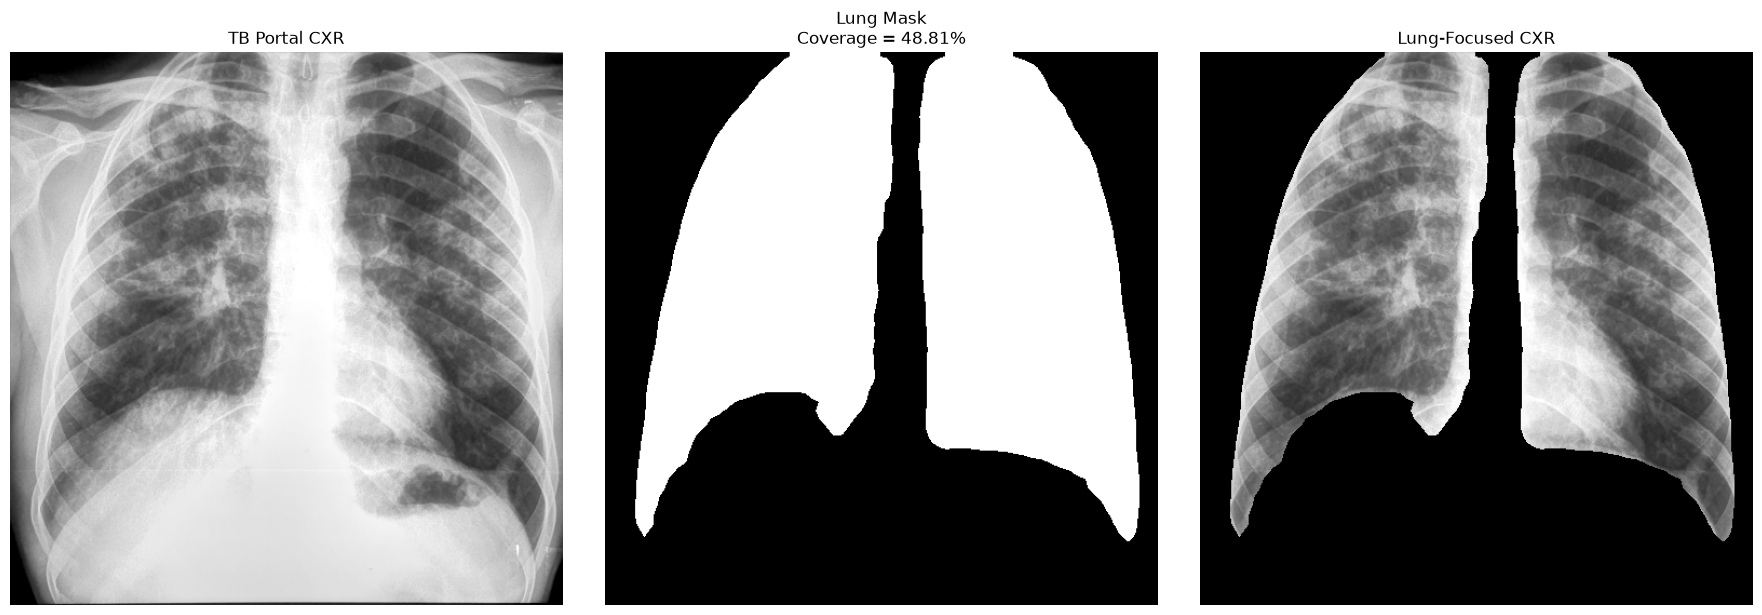


Saved diagnostic visualization:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Diagnostic\0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5_PSPNet_visual_validation.png

CELL 13 — COMPLETE


In [18]:
# ============================================================
# CELL 13 — VISUAL VALIDATION OF PSPNET LUNG MASK
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

print("=" * 80)
print("CELL 13 — PSPNET VISUAL VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. PREPARE DISPLAY IMAGE
# ------------------------------------------------------------

display_image = xrv_resized[0].copy()

# Normalize only for visualization
display_min = np.percentile(display_image, 1)
display_max = np.percentile(display_image, 99)

display_image = np.clip(
    display_image,
    display_min,
    display_max
)

display_image = (
    display_image - display_min
) / (
    display_max - display_min + 1e-8
)

# ------------------------------------------------------------
# 2. MASK
# ------------------------------------------------------------

mask = combined_prob >= 0.5

# ------------------------------------------------------------
# 3. LUNG-FOCUSED IMAGE
# ------------------------------------------------------------

lung_focused = display_image * mask.astype(np.float32)

# ------------------------------------------------------------
# 4. CREATE FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Original
axes[0].imshow(
    display_image,
    cmap="gray"
)

axes[0].set_title(
    "TB Portal CXR"
)

axes[0].axis("off")

# Mask
axes[1].imshow(
    mask,
    cmap="gray"
)

axes[1].set_title(
    f"Lung Mask\nCoverage = {coverage * 100:.2f}%"
)

axes[1].axis("off")

# Lung focused
axes[2].imshow(
    lung_focused,
    cmap="gray"
)

axes[2].set_title(
    "Lung-Focused CXR"
)

axes[2].axis("off")

plt.tight_layout()

# ------------------------------------------------------------
# 5. SAVE FIGURE
# ------------------------------------------------------------

diagnostic_dir = (
    BASE_DIR
    / "Step_3B_7_CXR_Lung_Region_Processing"
    / "Diagnostic"
)

diagnostic_dir.mkdir(
    parents=True,
    exist_ok=True
)

overlay_path = (
    diagnostic_dir
    / f"{TARGET_STEM}_PSPNet_visual_validation.png"
)

plt.savefig(
    overlay_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved diagnostic visualization:")
print(overlay_path)

print()
print("=" * 80)
print("CELL 13 — COMPLETE")
print("=" * 80)

In [19]:
# ============================================================
# CELL 14 — MULTI-IMAGE PSPNET VALIDATION
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import pydicom
import torch
import matplotlib.pyplot as plt
import torchxrayvision as xrv

print("=" * 80)
print("CELL 14 — MULTI-IMAGE PSPNET VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE_DIR = Path(r"C:\TBP\Metadata")

EXTRACTED_DIR = (
    BASE_DIR
    / "Step_3B_6_51_CXR_Extraction_Technical_Preprocessing"
    / "Extracted_DICOM"
)

DIAGNOSTIC_DIR = (
    BASE_DIR
    / "Step_3B_7_CXR_Lung_Region_Processing"
    / "Diagnostic"
)

DIAGNOSTIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. FIND DICOM FILES
# ------------------------------------------------------------

all_dicom_paths = sorted(
    EXTRACTED_DIR.glob("*.dcm")
)

print()
print("Total DICOM files found:", len(all_dicom_paths))

if len(all_dicom_paths) < 5:
    raise RuntimeError(
        "Fewer than 5 DICOM files were found."
    )

# ------------------------------------------------------------
# 3. SELECT FIVE DETERMINISTIC IMAGES
# ------------------------------------------------------------

selection_indices = [
    0,
    len(all_dicom_paths) // 4,
    len(all_dicom_paths) // 2,
    (3 * len(all_dicom_paths)) // 4,
    len(all_dicom_paths) - 1
]

selected_paths = [
    all_dicom_paths[i]
    for i in selection_indices
]

print()
print("-" * 80)
print("SELECTED TEST IMAGES")
print("-" * 80)

for i, path in enumerate(selected_paths, start=1):
    print(f"{i}. {path.name}")

# ------------------------------------------------------------
# 4. DEFINE DICOM → XRV PREPROCESSING
# ------------------------------------------------------------

def prepare_dicom_for_pspnet(dicom_path):

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    slope = safe_dicom_float(
        getattr(ds, "RescaleSlope", None),
        1.0
    )

    intercept = safe_dicom_float(
        getattr(ds, "RescaleIntercept", None),
        0.0
    )

    arr = (
        arr * slope
        + intercept
    )

    photometric = str(
        getattr(
            ds,
            "PhotometricInterpretation",
            ""
        )
    ).upper()

    if photometric == "MONOCHROME1":

        finite_mask = np.isfinite(arr)

        if finite_mask.any():

            finite_values = arr[
                finite_mask
            ]

            arr_min = finite_values.min()
            arr_max = finite_values.max()

            arr = (
                arr_max
                + arr_min
                - arr
            )

    # TorchXRayVision normalization
    normalized = xrv.utils.normalize(
        arr,
        maxval=255,
        reshape=False
    )

    # Add channel
    normalized = normalized[
        None,
        :,
        :
    ]

    # Center crop
    normalized = xrv.datasets.XRayCenterCrop()(
        normalized
    )

    # Resize
    normalized = xrv.datasets.XRayResizer(
        512
    )(normalized)

    return normalized, ds

# ------------------------------------------------------------
# 5. RUN PSPNET ON FIVE IMAGES
# ------------------------------------------------------------

model = model.to(device)
model.eval()

results = []

print()
print("-" * 80)
print("RUNNING PSPNET")
print("-" * 80)

for counter, dicom_path in enumerate(
    selected_paths,
    start=1
):

    print()
    print(
        f"[{counter}/5] Processing:",
        dicom_path.name
    )

    try:

        xrv_input, ds = prepare_dicom_for_pspnet(
            dicom_path
        )

        tensor = torch.from_numpy(
            xrv_input
        ).float().unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(
                tensor
            )

        probabilities = torch.sigmoid(
            output
        )

        left_idx = model.targets.index(
            "Left Lung"
        )

        right_idx = model.targets.index(
            "Right Lung"
        )

        left_prob = probabilities[
            0,
            left_idx
        ].cpu().numpy()

        right_prob = probabilities[
            0,
            right_idx
        ].cpu().numpy()

        combined_prob = np.maximum(
            left_prob,
            right_prob
        )

        mask = (
            combined_prob >= 0.5
        )

        coverage = float(
            np.mean(mask)
        )

        # ----------------------------------------------------
        # Visualization
        # ----------------------------------------------------

        display_image = xrv_input[0].copy()

        low = np.percentile(
            display_image,
            1
        )

        high = np.percentile(
            display_image,
            99
        )

        display_image = np.clip(
            display_image,
            low,
            high
        )

        display_image = (
            display_image - low
        ) / (
            high - low + 1e-8
        )

        lung_focused = (
            display_image
            * mask.astype(np.float32)
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(15, 5)
        )

        axes[0].imshow(
            display_image,
            cmap="gray"
        )

        axes[0].set_title(
            "CXR"
        )

        axes[0].axis("off")

        axes[1].imshow(
            mask,
            cmap="gray"
        )

        axes[1].set_title(
            f"Lung Mask\n"
            f"Coverage = {coverage * 100:.2f}%"
        )

        axes[1].axis("off")

        axes[2].imshow(
            lung_focused,
            cmap="gray"
        )

        axes[2].set_title(
            "Lung-Focused CXR"
        )

        axes[2].axis("off")

        plt.tight_layout()

        visualization_path = (
            DIAGNOSTIC_DIR
            / f"{dicom_path.stem}_multi_validation.png"
        )

        plt.savefig(
            visualization_path,
            dpi=120,
            bbox_inches="tight"
        )

        plt.close(fig)

        # ----------------------------------------------------
        # Record QC
        # ----------------------------------------------------

        results.append({
            "stem": dicom_path.stem,
            "rows": int(ds.Rows),
            "columns": int(ds.Columns),
            "photometric": str(
                getattr(
                    ds,
                    "PhotometricInterpretation",
                    ""
                )
            ),
            "left_max": float(
                left_prob.max()
            ),
            "right_max": float(
                right_prob.max()
            ),
            "left_pixels_ge_05": int(
                np.sum(left_prob >= 0.5)
            ),
            "right_pixels_ge_05": int(
                np.sum(right_prob >= 0.5)
            ),
            "mask_pixels": int(
                np.sum(mask)
            ),
            "mask_coverage": coverage,
            "visualization": str(
                visualization_path
            ),
            "status": "PASS"
        })

        print(
            "  Left max:",
            f"{left_prob.max():.6f}"
        )

        print(
            "  Right max:",
            f"{right_prob.max():.6f}"
        )

        print(
            "  Coverage:",
            f"{coverage * 100:.2f}%"
        )

    except Exception as e:

        results.append({
            "stem": dicom_path.stem,
            "rows": None,
            "columns": None,
            "photometric": None,
            "left_max": None,
            "right_max": None,
            "left_pixels_ge_05": None,
            "right_pixels_ge_05": None,
            "mask_pixels": None,
            "mask_coverage": None,
            "visualization": None,
            "status": f"ERROR: {e}"
        })

        print(
            "  ERROR:",
            repr(e)
        )

# ------------------------------------------------------------
# 6. QC TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)

print()
print("=" * 80)
print("MULTI-IMAGE PSPNET QC SUMMARY")
print("=" * 80)

display(
    results_df[
        [
            "stem",
            "rows",
            "columns",
            "photometric",
            "left_max",
            "right_max",
            "left_pixels_ge_05",
            "right_pixels_ge_05",
            "mask_coverage",
            "status"
        ]
    ]
)

# ------------------------------------------------------------
# 7. VALIDATION SUMMARY
# ------------------------------------------------------------

successful = (
    results_df["status"] == "PASS"
).sum()

failed = (
    results_df["status"] != "PASS"
).sum()

nonempty = (
    results_df["mask_pixels"].fillna(0) > 0
).sum()

print()
print("Images tested       :", len(results_df))
print("Successful          :", successful)
print("Failed              :", failed)
print("Non-empty masks     :", nonempty)

if successful == 5 and nonempty == 5:

    print()
    print(
        "MULTI-IMAGE PSPNET VALIDATION: PASS"
    )

else:

    print()
    print(
        "MULTI-IMAGE PSPNET VALIDATION: REVIEW REQUIRED"
    )

print()
print("=" * 80)
print("CELL 14 — COMPLETE")
print("=" * 80)

CELL 14 — MULTI-IMAGE PSPNET VALIDATION

Total DICOM files found: 2081

--------------------------------------------------------------------------------
SELECTED TEST IMAGES
--------------------------------------------------------------------------------
1. 0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5.dcm
2. 40509c72-22b0-4252-81af-4788ccf76a62_1d9fe7af35ba.dcm
3. 82cd9913-3006-4b11-a524-fe7f134d6372_b5596e28b0d3.dcm
4. c0f2f050-b2a7-447e-866a-757fff45f1cf_3254498046ea.dcm
5. ffd62357-f912-40c0-9669-3032048e2acc_3a67d8ebc5bb.dcm

--------------------------------------------------------------------------------
RUNNING PSPNET
--------------------------------------------------------------------------------

[1/5] Processing: 0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5.dcm
  Left max: 0.999995
  Right max: 0.999991
  Coverage: 48.81%

[2/5] Processing: 40509c72-22b0-4252-81af-4788ccf76a62_1d9fe7af35ba.dcm
  Left max: 0.999987
  Right max: 0.999995
  Coverage: 78.31%

[3/5] Proce

,stem,rows,columns,photometric,left_max,right_max,left_pixels_ge_05,right_pixels_ge_05,mask_coverage,status
0,0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5,2972.0,3674.0,MONOCHROME2,0.999995,0.999991,65500.0,62456.0,0.488113,PASS
1,40509c72-22b0-4252-81af-4788ccf76a62_1d9fe7af35ba,1879.0,1984.0,MONOCHROME2,0.999987,0.999995,88633.0,116662.0,0.783138,PASS
2,82cd9913-3006-4b11-a524-fe7f134d6372_b5596e28b0d3,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,ERROR: max image value (1012.0) higher than ex...
3,c0f2f050-b2a7-447e-866a-757fff45f1cf_3254498046ea,1494.0,1736.0,MONOCHROME2,0.999887,0.999730,76006.0,111832.0,0.716545,PASS
4,ffd62357-f912-40c0-9669-3032048e2acc_3a67d8ebc5bb,3032.0,3032.0,MONOCHROME2,0.999936,0.999944,50308.0,51699.0,0.389126,PASS



Images tested       : 5
Successful          : 4
Failed              : 1
Non-empty masks     : 4

MULTI-IMAGE PSPNET VALIDATION: REVIEW REQUIRED

CELL 14 — COMPLETE


In [20]:
# ============================================================
# CELL 15 — DIAGNOSE HIGH-BIT-DEPTH DICOM
# ============================================================

import numpy as np
import pydicom

print("=" * 80)
print("CELL 15 — HIGH-BIT-DEPTH DICOM DIAGNOSTIC")
print("=" * 80)

# ------------------------------------------------------------
# 1. TARGET FAILED DICOM
# ------------------------------------------------------------

TARGET_HIGH_VALUE_STEM = (
    "82cd9913-3006-4b11-a524-fe7f134d6372_"
    "b5596e28b0d3"
)

failed_dicom_path = (
    EXTRACTED_DIR
    / f"{TARGET_HIGH_VALUE_STEM}.dcm"
)

print()
print("DICOM:")
print(failed_dicom_path)

print()
print("Exists:", failed_dicom_path.exists())

if not failed_dicom_path.exists():
    raise FileNotFoundError(
        f"DICOM not found:\n{failed_dicom_path}"
    )

# ------------------------------------------------------------
# 2. READ DICOM
# ------------------------------------------------------------

ds_high = pydicom.dcmread(
    str(failed_dicom_path)
)

# ------------------------------------------------------------
# 3. IMPORTANT METADATA
# ------------------------------------------------------------

print()
print("-" * 80)
print("DICOM METADATA")
print("-" * 80)

metadata_fields = [
    "Rows",
    "Columns",
    "PhotometricInterpretation",
    "SamplesPerPixel",
    "BitsAllocated",
    "BitsStored",
    "HighBit",
    "PixelRepresentation",
    "RescaleSlope",
    "RescaleIntercept",
    "WindowCenter",
    "WindowWidth",
    "VOILUTFunction"
]

for field in metadata_fields:

    print(
        f"{field}:",
        getattr(ds_high, field, None)
    )

# ------------------------------------------------------------
# 4. RAW PIXEL ARRAY
# ------------------------------------------------------------

raw_high = ds_high.pixel_array

raw_high_float = raw_high.astype(
    np.float32
)

print()
print("-" * 80)
print("RAW DICOM PIXEL ARRAY")
print("-" * 80)

print()
print("Shape:", raw_high.shape)
print("Dtype:", raw_high.dtype)

print(
    "Min:",
    float(raw_high_float.min())
)

print(
    "Max:",
    float(raw_high_float.max())
)

print(
    "Mean:",
    float(raw_high_float.mean())
)

print(
    "Std:",
    float(raw_high_float.std())
)

print(
    "Median:",
    float(np.median(raw_high_float))
)

# ------------------------------------------------------------
# 5. PERCENTILES
# ------------------------------------------------------------

percentile_values = [
    0,
    0.1,
    1,
    5,
    25,
    50,
    75,
    95,
    99,
    99.9,
    100
]

percentiles = np.percentile(
    raw_high_float,
    percentile_values
)

print()
print("Raw pixel percentiles:")

for p, value in zip(
    percentile_values,
    percentiles
):

    print(
        f"{p:>5}% : {value:.4f}"
    )

# ------------------------------------------------------------
# 6. RESCALE INFORMATION
# ------------------------------------------------------------

slope = safe_dicom_float(
    getattr(
        ds_high,
        "RescaleSlope",
        None
    ),
    1.0
)

intercept = safe_dicom_float(
    getattr(
        ds_high,
        "RescaleIntercept",
        None
    ),
    0.0
)

rescaled_high = (
    raw_high_float * slope
    + intercept
)

print()
print("-" * 80)
print("AFTER RESCALE")
print("-" * 80)

print()
print("Slope:", slope)
print("Intercept:", intercept)

print(
    "Min:",
    float(rescaled_high.min())
)

print(
    "Max:",
    float(rescaled_high.max())
)

print(
    "Mean:",
    float(rescaled_high.mean())
)

print(
    "Std:",
    float(rescaled_high.std())
)

print(
    "Median:",
    float(np.median(rescaled_high))
)

# ------------------------------------------------------------
# 7. PHOTOMETRIC CHECK
# ------------------------------------------------------------

photometric_high = str(
    getattr(
        ds_high,
        "PhotometricInterpretation",
        ""
    )
).upper()

print()
print("Photometric interpretation:",
      photometric_high)

if photometric_high == "MONOCHROME1":

    print(
        "MONOCHROME1 detected."
    )

else:

    print(
        "No MONOCHROME1 inversion required."
    )

# ------------------------------------------------------------
# 8. EXPECTED MAXIMUM FROM BIT DEPTH
# ------------------------------------------------------------

bits_stored = getattr(
    ds_high,
    "BitsStored",
    None
)

if bits_stored is not None:

    theoretical_unsigned_max = (
        2 ** int(bits_stored)
    ) - 1

    print()
    print(
        "Theoretical unsigned maximum "
        f"for {bits_stored}-bit data:",
        theoretical_unsigned_max
    )

print()
print("=" * 80)
print("CELL 15 — COMPLETE")
print("=" * 80)

CELL 15 — HIGH-BIT-DEPTH DICOM DIAGNOSTIC

DICOM:
C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM\82cd9913-3006-4b11-a524-fe7f134d6372_b5596e28b0d3.dcm

Exists: True

--------------------------------------------------------------------------------
DICOM METADATA
--------------------------------------------------------------------------------
Rows: 1760
Columns: 2140
PhotometricInterpretation: MONOCHROME1
SamplesPerPixel: 1
BitsAllocated: 16
BitsStored: 10
HighBit: 9
PixelRepresentation: 0
RescaleSlope: None
RescaleIntercept: None
WindowCenter: 512
WindowWidth: 1024
VOILUTFunction: None

--------------------------------------------------------------------------------
RAW DICOM PIXEL ARRAY
--------------------------------------------------------------------------------

Shape: (1760, 2140)
Dtype: uint16
Min: 127.0
Max: 1012.0
Mean: 409.53985595703125
Std: 213.14646911621094
Median: 346.0

Raw pixel percentiles:
    0% : 127.0000
  0.1% : 130.0000
    1

In [21]:
# ============================================================
# CELL 16 — BIT-DEPTH-AWARE DICOM → PSPNET TEST
# ============================================================

import numpy as np
import torch
import pydicom
import torchxrayvision as xrv

print("=" * 80)
print("CELL 16 — BIT-DEPTH-AWARE DICOM → PSPNET TEST")
print("=" * 80)

# ------------------------------------------------------------
# 1. TARGET DICOM
# ------------------------------------------------------------

TARGET_STEM = (
    "82cd9913-3006-4b11-a524-fe7f134d6372_"
    "b5596e28b0d3"
)

target_path = (
    EXTRACTED_DIR
    / f"{TARGET_STEM}.dcm"
)

print()
print("Target:")
print(target_path)

# ------------------------------------------------------------
# 2. READ DICOM
# ------------------------------------------------------------

ds = pydicom.dcmread(
    str(target_path)
)

arr = ds.pixel_array.astype(
    np.float32
)

# ------------------------------------------------------------
# 3. DICOM METADATA
# ------------------------------------------------------------

bits_stored = int(
    getattr(ds, "BitsStored", 8)
)

pixel_representation = int(
    getattr(ds, "PixelRepresentation", 0)
)

photometric = str(
    getattr(
        ds,
        "PhotometricInterpretation",
        ""
    )
).upper()

slope = safe_dicom_float(
    getattr(ds, "RescaleSlope", None),
    1.0
)

intercept = safe_dicom_float(
    getattr(ds, "RescaleIntercept", None),
    0.0
)

print()
print("-" * 80)
print("DICOM REPRESENTATION")
print("-" * 80)

print()
print("BitsStored:", bits_stored)
print("PixelRepresentation:", pixel_representation)
print("PhotometricInterpretation:", photometric)
print("RescaleSlope:", slope)
print("RescaleIntercept:", intercept)

# ------------------------------------------------------------
# 4. RESCALE
# ------------------------------------------------------------

arr = (
    arr * slope
    + intercept
)

print()
print("After rescale:")
print("Min:", float(arr.min()))
print("Max:", float(arr.max()))
print("Mean:", float(arr.mean()))
print("Std:", float(arr.std()))

# ------------------------------------------------------------
# 5. DETERMINE STORED VALUE RANGE
# ------------------------------------------------------------

if pixel_representation == 0:

    stored_min = 0.0

    stored_max = float(
        (2 ** bits_stored) - 1
    )

else:

    # Signed pixel representation
    stored_min = float(
        -(2 ** (bits_stored - 1))
    )

    stored_max = float(
        (2 ** (bits_stored - 1)) - 1
    )

print()
print("-" * 80)
print("EXPECTED DICOM VALUE RANGE")
print("-" * 80)

print()
print("Stored minimum:", stored_min)
print("Stored maximum:", stored_max)

# ------------------------------------------------------------
# 6. MONOCHROME1 → MONOCHROME2
# ------------------------------------------------------------

if photometric == "MONOCHROME1":

    print()
    print(
        "MONOCHROME1 detected — "
        "converting to MONOCHROME2 polarity."
    )

    arr = (
        stored_max
        - arr
    )

else:

    print()
    print(
        "MONOCHROME2 detected — "
        "no polarity inversion required."
    )

# ------------------------------------------------------------
# 7. CHECK AFTER POLARITY
# ------------------------------------------------------------

print()
print("-" * 80)
print("AFTER POLARITY CORRECTION")
print("-" * 80)

print()
print("Min:", float(arr.min()))
print("Max:", float(arr.max()))
print("Mean:", float(arr.mean()))
print("Std:", float(arr.std()))
print("Median:", float(np.median(arr)))

# ------------------------------------------------------------
# 8. SCALE TO 0–255
# ------------------------------------------------------------

if stored_max <= stored_min:

    raise ValueError(
        "Invalid DICOM stored-value range."
    )

arr_255 = (
    (arr - stored_min)
    / (stored_max - stored_min)
) * 255.0

arr_255 = np.clip(
    arr_255,
    0.0,
    255.0
).astype(
    np.float32
)

print()
print("-" * 80)
print("CONVERTED TO 0–255")
print("-" * 80)

print()
print("Min:", float(arr_255.min()))
print("Max:", float(arr_255.max()))
print("Mean:", float(arr_255.mean()))
print("Std:", float(arr_255.std()))
print("Median:", float(np.median(arr_255)))

# ------------------------------------------------------------
# 9. TORCHXRAYVISION NORMALIZATION
# ------------------------------------------------------------

xrv_array = xrv.utils.normalize(
    arr_255,
    maxval=255,
    reshape=False
)

print()
print("-" * 80)
print("TORCHXRAYVISION NORMALIZATION")
print("-" * 80)

print()
print("Min:", float(xrv_array.min()))
print("Max:", float(xrv_array.max()))
print("Mean:", float(xrv_array.mean()))
print("Std:", float(xrv_array.std()))

# ------------------------------------------------------------
# 10. ADD CHANNEL
# ------------------------------------------------------------

xrv_input = xrv_array[
    None,
    :,
    :
]

# ------------------------------------------------------------
# 11. CENTER CROP
# ------------------------------------------------------------

xrv_input = xrv.datasets.XRayCenterCrop()(
    xrv_input
)

print()
print("After center crop:")
print("Shape:", xrv_input.shape)

# ------------------------------------------------------------
# 12. RESIZE
# ------------------------------------------------------------

xrv_input = xrv.datasets.XRayResizer(
    512
)(
    xrv_input
)

print()
print("After resize:")
print("Shape:", xrv_input.shape)
print("Min:", float(xrv_input.min()))
print("Max:", float(xrv_input.max()))

# ------------------------------------------------------------
# 13. TORCH TENSOR
# ------------------------------------------------------------

x_tensor = torch.from_numpy(
    xrv_input
).float().unsqueeze(0).to(device)

print()
print("Tensor shape:", tuple(x_tensor.shape))
print("Tensor device:", x_tensor.device)

# ------------------------------------------------------------
# 14. PSPNET
# ------------------------------------------------------------

model = model.to(device)
model.eval()

with torch.no_grad():

    output = model(
        x_tensor
    )

probabilities = torch.sigmoid(
    output
)

# ------------------------------------------------------------
# 15. LUNG CHANNELS
# ------------------------------------------------------------

left_idx = model.targets.index(
    "Left Lung"
)

right_idx = model.targets.index(
    "Right Lung"
)

left_prob = probabilities[
    0,
    left_idx
].cpu().numpy()

right_prob = probabilities[
    0,
    right_idx
].cpu().numpy()

combined_prob = np.maximum(
    left_prob,
    right_prob
)

mask = (
    combined_prob >= 0.5
)

coverage = float(
    np.mean(mask)
)

# ------------------------------------------------------------
# 16. RESULTS
# ------------------------------------------------------------

print()
print("=" * 80)
print("PSPNET RESULTS")
print("=" * 80)

print()
print("Output shape:", tuple(output.shape))

print()
print("Left Lung")
print("  Max probability:",
      float(left_prob.max()))
print("  Mean probability:",
      float(left_prob.mean()))
print("  Pixels >= 0.5:",
      int(np.sum(left_prob >= 0.5)))

print()
print("Right Lung")
print("  Max probability:",
      float(right_prob.max()))
print("  Mean probability:",
      float(right_prob.mean()))
print("  Pixels >= 0.5:",
      int(np.sum(right_prob >= 0.5)))

print()
print("Combined")
print("  Max probability:",
      float(combined_prob.max()))
print("  Mean probability:",
      float(combined_prob.mean()))
print("  Mask pixels:",
      int(np.sum(mask)))
print("  Total pixels:",
      int(mask.size))
print(
    "  Coverage:",
    f"{coverage * 100:.4f}%"
)

if np.sum(mask) > 0:

    print()
    print(
        "BIT-DEPTH-AWARE PSPNET TEST: "
        "NON-EMPTY MASK"
    )

else:

    print()
    print(
        "BIT-DEPTH-AWARE PSPNET TEST: "
        "EMPTY MASK — REVIEW REQUIRED"
    )

print()
print("=" * 80)
print("CELL 16 — COMPLETE")
print("=" * 80)

CELL 16 — BIT-DEPTH-AWARE DICOM → PSPNET TEST

Target:
C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM\82cd9913-3006-4b11-a524-fe7f134d6372_b5596e28b0d3.dcm

--------------------------------------------------------------------------------
DICOM REPRESENTATION
--------------------------------------------------------------------------------

BitsStored: 10
PixelRepresentation: 0
PhotometricInterpretation: MONOCHROME1
RescaleSlope: 1.0
RescaleIntercept: 0.0

After rescale:
Min: 127.0
Max: 1012.0
Mean: 409.53985595703125
Std: 213.14646911621094

--------------------------------------------------------------------------------
EXPECTED DICOM VALUE RANGE
--------------------------------------------------------------------------------

Stored minimum: 0.0
Stored maximum: 1023.0

MONOCHROME1 detected — converting to MONOCHROME2 polarity.

--------------------------------------------------------------------------------
AFTER POLARITY CORRECTION
---------------

In [22]:
# ============================================================
# CELL 17 — FINAL UNIFIED DICOM → PSPNET PREPROCESSING
#             + 5-IMAGE VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import torch
import pydicom
import torchxrayvision as xrv

print("=" * 80)
print("CELL 17 — FINAL UNIFIED DICOM → PSPNET PREPROCESSING")
print("=" * 80)


# ============================================================
# 1. UNIFIED DICOM PREPROCESSING FUNCTION
# ============================================================

def prepare_dicom_for_pspnet_final(dicom_path):
    """
    Convert a TB Portals DICOM into the exact input representation
    required by the TorchXRayVision PSPNet.

    Steps:
        1. Read DICOM pixel array.
        2. Apply RescaleSlope / RescaleIntercept.
        3. Handle MONOCHROME1 polarity.
        4. Determine stored-value range from BitsStored /
           PixelRepresentation.
        5. Convert to 0–255.
        6. TorchXRayVision normalization.
        7. Add channel dimension.
        8. Center crop.
        9. Resize to 512 × 512.

    The technical PNG files are NOT used.
    """

    # --------------------------------------------------------
    # Read DICOM
    # --------------------------------------------------------

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    # --------------------------------------------------------
    # DICOM metadata
    # --------------------------------------------------------

    bits_stored = int(
        getattr(
            ds,
            "BitsStored",
            8
        )
    )

    pixel_representation = int(
        getattr(
            ds,
            "PixelRepresentation",
            0
        )
    )

    photometric = str(
        getattr(
            ds,
            "PhotometricInterpretation",
            ""
        )
    ).upper()

    # --------------------------------------------------------
    # Rescale slope / intercept
    # --------------------------------------------------------

    slope = safe_dicom_float(
        getattr(
            ds,
            "RescaleSlope",
            None
        ),
        1.0
    )

    intercept = safe_dicom_float(
        getattr(
            ds,
            "RescaleIntercept",
            None
        ),
        0.0
    )

    arr = (
        arr * slope
        + intercept
    )

    # --------------------------------------------------------
    # Determine stored-value range
    # --------------------------------------------------------

    if pixel_representation == 0:

        stored_min = 0.0

        stored_max = float(
            (2 ** bits_stored) - 1
        )

    else:

        stored_min = float(
            -(2 ** (bits_stored - 1))
        )

        stored_max = float(
            (2 ** (bits_stored - 1)) - 1
        )

    # --------------------------------------------------------
    # MONOCHROME1 → MONOCHROME2
    # --------------------------------------------------------

    if photometric == "MONOCHROME1":

        arr = (
            stored_max
            - arr
        )

    # --------------------------------------------------------
    # Convert to 0–255
    # --------------------------------------------------------

    denominator = (
        stored_max
        - stored_min
    )

    if denominator <= 0:

        raise ValueError(
            f"Invalid DICOM stored range: "
            f"{stored_min} to {stored_max}"
        )

    arr_255 = (
        (arr - stored_min)
        / denominator
    ) * 255.0

    arr_255 = np.clip(
        arr_255,
        0.0,
        255.0
    ).astype(
        np.float32
    )

    # --------------------------------------------------------
    # TorchXRayVision normalization
    # --------------------------------------------------------

    normalized = xrv.utils.normalize(
        arr_255,
        maxval=255,
        reshape=False
    )

    # --------------------------------------------------------
    # Add channel
    # --------------------------------------------------------

    normalized = normalized[
        None,
        :,
        :
    ]

    # --------------------------------------------------------
    # Center crop
    # --------------------------------------------------------

    normalized = xrv.datasets.XRayCenterCrop()(
        normalized
    )

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    normalized = xrv.datasets.XRayResizer(
        512
    )(normalized)

    return normalized, ds


# ============================================================
# 2. TEST FUNCTION ON THE TWO REPRESENTATION TYPES
# ============================================================

print()
print("-" * 80)
print("TESTING UNIFIED PREPROCESSING")
print("-" * 80)

# Previously successful 8-bit image
test_8bit = (
    EXTRACTED_DIR
    / "0000f7e6-bbd2-468d-834d-f14948c5d902_"
      "bf258ff075d5.dcm"
)

# Previously problematic 10-bit image
test_10bit = (
    EXTRACTED_DIR
    / "82cd9913-3006-4b11-a524-fe7f134d6372_"
      "b5596e28b0d3.dcm"
)

test_paths = [
    test_8bit,
    test_10bit
]

for test_path in test_paths:

    print()
    print("Testing:", test_path.name)

    processed, ds = (
        prepare_dicom_for_pspnet_final(
            test_path
        )
    )

    print(
        "  BitsStored:",
        getattr(ds, "BitsStored", None)
    )

    print(
        "  Photometric:",
        getattr(
            ds,
            "PhotometricInterpretation",
            None
        )
    )

    print(
        "  Output shape:",
        processed.shape
    )

    print(
        "  Output min:",
        float(processed.min())
    )

    print(
        "  Output max:",
        float(processed.max())
    )

    print(
        "  Output mean:",
        float(processed.mean())
    )

    print(
        "  Output std:",
        float(processed.std())
    )


# ============================================================
# 3. SELECT FIVE DETERMINISTIC DICOMs
# ============================================================

all_dicom_paths = sorted(
    EXTRACTED_DIR.glob("*.dcm")
)

if len(all_dicom_paths) != 2081:

    raise RuntimeError(
        f"Expected 2081 DICOM files, "
        f"found {len(all_dicom_paths)}."
    )

selection_indices = [
    0,
    len(all_dicom_paths) // 4,
    len(all_dicom_paths) // 2,
    (3 * len(all_dicom_paths)) // 4,
    len(all_dicom_paths) - 1
]

selected_paths = [
    all_dicom_paths[i]
    for i in selection_indices
]

print()
print("-" * 80)
print("FIVE-IMAGE VALIDATION SET")
print("-" * 80)

for i, path in enumerate(
    selected_paths,
    start=1
):

    print(
        f"{i}. {path.name}"
    )


# ============================================================
# 4. PSPNET SETUP
# ============================================================

model = model.to(device)
model.eval()

left_idx = model.targets.index(
    "Left Lung"
)

right_idx = model.targets.index(
    "Right Lung"
)


# ============================================================
# 5. RUN FIVE-IMAGE VALIDATION
# ============================================================

validation_results = []

print()
print("-" * 80)
print("RUNNING FINAL UNIFIED PIPELINE")
print("-" * 80)

for counter, dicom_path in enumerate(
    selected_paths,
    start=1
):

    print()
    print(
        f"[{counter}/5] {dicom_path.name}"
    )

    try:

        processed, ds = (
            prepare_dicom_for_pspnet_final(
                dicom_path
            )
        )

        tensor = torch.from_numpy(
            processed
        ).float().unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(
                tensor
            )

        probabilities = torch.sigmoid(
            output
        )

        left_prob = probabilities[
            0,
            left_idx
        ].cpu().numpy()

        right_prob = probabilities[
            0,
            right_idx
        ].cpu().numpy()

        combined_prob = np.maximum(
            left_prob,
            right_prob
        )

        mask = (
            combined_prob >= 0.5
        )

        mask_pixels = int(
            np.sum(mask)
        )

        coverage = float(
            np.mean(mask)
        )

        result = {
            "stem": dicom_path.stem,
            "bits_stored": int(
                getattr(
                    ds,
                    "BitsStored",
                    8
                )
            ),
            "photometric": str(
                getattr(
                    ds,
                    "PhotometricInterpretation",
                    ""
                )
            ),
            "left_max": float(
                left_prob.max()
            ),
            "right_max": float(
                right_prob.max()
            ),
            "left_pixels_ge_05": int(
                np.sum(
                    left_prob >= 0.5
                )
            ),
            "right_pixels_ge_05": int(
                np.sum(
                    right_prob >= 0.5
                )
            ),
            "mask_pixels": mask_pixels,
            "mask_coverage": coverage,
            "status": "PASS"
        }

        validation_results.append(
            result
        )

        print(
            "  BitsStored:",
            result["bits_stored"]
        )

        print(
            "  Photometric:",
            result["photometric"]
        )

        print(
            "  Left max:",
            f'{result["left_max"]:.6f}'
        )

        print(
            "  Right max:",
            f'{result["right_max"]:.6f}'
        )

        print(
            "  Coverage:",
            f'{coverage * 100:.2f}%'
        )

    except Exception as e:

        validation_results.append({
            "stem": dicom_path.stem,
            "bits_stored": None,
            "photometric": None,
            "left_max": None,
            "right_max": None,
            "left_pixels_ge_05": None,
            "right_pixels_ge_05": None,
            "mask_pixels": None,
            "mask_coverage": None,
            "status": f"ERROR: {e}"
        })

        print(
            "  ERROR:",
            repr(e)
        )


# ============================================================
# 6. VALIDATION TABLE
# ============================================================

validation_df = pd.DataFrame(
    validation_results
)

print()
print("=" * 80)
print("FINAL FIVE-IMAGE PSPNET VALIDATION")
print("=" * 80)

display(
    validation_df
)


# ============================================================
# 7. FINAL VALIDATION COUNTS
# ============================================================

successful = int(
    (
        validation_df["status"]
        == "PASS"
    ).sum()
)

failed = int(
    len(validation_df)
    - successful
)

nonempty = int(
    (
        validation_df["mask_pixels"]
        .fillna(0)
        > 0
    ).sum()
)

print()
print("Images tested   :", len(validation_df))
print("Successful      :", successful)
print("Failed          :", failed)
print("Non-empty masks :", nonempty)

if (
    successful == 5
    and nonempty == 5
):

    print()
    print(
        "FINAL FIVE-IMAGE "
        "PSPNET VALIDATION: PASS"
    )

else:

    print()
    print(
        "FINAL FIVE-IMAGE "
        "PSPNET VALIDATION: REVIEW REQUIRED"
    )

print()
print("=" * 80)
print("CELL 17 — COMPLETE")
print("=" * 80)

CELL 17 — FINAL UNIFIED DICOM → PSPNET PREPROCESSING

--------------------------------------------------------------------------------
TESTING UNIFIED PREPROCESSING
--------------------------------------------------------------------------------

Testing: 0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5.dcm
  BitsStored: 8
  Photometric: MONOCHROME2
  Output shape: (1, 512, 512)
  Output min: -840.2091674804688
  Output max: 960.724853515625
  Output mean: 418.9129638671875
  Output std: 351.4071350097656

Testing: 82cd9913-3006-4b11-a524-fe7f134d6372_b5596e28b0d3.dcm
  BitsStored: 10
  Photometric: MONOCHROME1
  Output shape: (1, 512, 512)
  Output min: -946.9662475585938
  Output max: 739.436279296875
  Output mean: 262.6717834472656
  Output std: 334.44708251953125

--------------------------------------------------------------------------------
FIVE-IMAGE VALIDATION SET
--------------------------------------------------------------------------------
1. 0000f7e6-bbd2-468d-834d-f149

,stem,bits_stored,photometric,left_max,right_max,left_pixels_ge_05,right_pixels_ge_05,mask_pixels,mask_coverage,status
0,0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5,8,MONOCHROME2,0.999995,0.999991,65500,62456,127956,0.488113,PASS
1,40509c72-22b0-4252-81af-4788ccf76a62_1d9fe7af35ba,8,MONOCHROME2,0.999987,0.999995,88633,116662,205295,0.783138,PASS
2,82cd9913-3006-4b11-a524-fe7f134d6372_b5596e28b0d3,10,MONOCHROME1,0.999993,0.999995,81913,82119,164032,0.625732,PASS
3,c0f2f050-b2a7-447e-866a-757fff45f1cf_3254498046ea,8,MONOCHROME2,0.999887,0.999730,76006,111832,187838,0.716545,PASS
4,ffd62357-f912-40c0-9669-3032048e2acc_3a67d8ebc5bb,8,MONOCHROME2,0.999936,0.999944,50308,51699,102007,0.389126,PASS



Images tested   : 5
Successful      : 5
Failed          : 0
Non-empty masks : 5

FINAL FIVE-IMAGE PSPNET VALIDATION: PASS

CELL 17 — COMPLETE


In [23]:
# ============================================================
# CELL 18 — RESTART-SAFE PSPNET BATCH PROCESSING
#              ALL 2,081 FINAL COHORT CXRs
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import pydicom
import torchxrayvision as xrv
from PIL import Image
import hashlib
import time

print("=" * 80)
print("CELL 18 — FULL 2,081-CXR PSPNET BATCH PROCESSING")
print("=" * 80)

# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(r"C:\TBP\Metadata")

EXTRACTED_DIR = (
    BASE_DIR
    / "Step_3B_6_51_CXR_Extraction_Technical_Preprocessing"
    / "Extracted_DICOM"
)

NOTEBOOK07_DIR = (
    BASE_DIR
    / "Step_3B_7_CXR_Lung_Region_Processing"
)

MASK_DIR = (
    NOTEBOOK07_DIR
    / "Lung_Masks"
)

LUNG_FOCUSED_DIR = (
    NOTEBOOK07_DIR
    / "Lung_Focused_CXR"
)

QC_DIR = (
    NOTEBOOK07_DIR
    / "QC"
)

MASK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LUNG_FOCUSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

QC_CSV = (
    QC_DIR
    / "TB_Portals_March2025_Notebook07_PSPNet_QC.csv"
)

print()
print("DICOM directory:")
print(EXTRACTED_DIR)

print()
print("Mask directory:")
print(MASK_DIR)

print()
print("Lung-focused CXR directory:")
print(LUNG_FOCUSED_DIR)

print()
print("QC CSV:")
print(QC_CSV)


# ============================================================
# 2. VERIFY INPUT DICOM COHORT
# ============================================================

dicom_paths = sorted(
    EXTRACTED_DIR.glob("*.dcm")
)

expected_count = 2081

print()
print("-" * 80)
print("INPUT COHORT CHECK")
print("-" * 80)

print()
print("Expected DICOMs :", expected_count)
print("Found DICOMs    :", len(dicom_paths))

if len(dicom_paths) != expected_count:

    raise RuntimeError(
        f"INPUT COHORT ERROR: expected "
        f"{expected_count} DICOM files but found "
        f"{len(dicom_paths)}."
    )

dicom_stems = [
    p.stem
    for p in dicom_paths
]

unique_dicom_stems = len(
    set(dicom_stems)
)

print(
    "Unique DICOM stems:",
    unique_dicom_stems
)

if unique_dicom_stems != expected_count:

    raise RuntimeError(
        "DICOM filename uniqueness check failed."
    )

print()
print("Input cohort check: PASS")


# ============================================================
# 3. FINAL DICOM PREPROCESSING FUNCTION
# ============================================================

def prepare_dicom_for_pspnet_final(dicom_path):

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    bits_stored = int(
        getattr(
            ds,
            "BitsStored",
            8
        )
    )

    pixel_representation = int(
        getattr(
            ds,
            "PixelRepresentation",
            0
        )
    )

    photometric = str(
        getattr(
            ds,
            "PhotometricInterpretation",
            ""
        )
    ).upper()

    slope = safe_dicom_float(
        getattr(
            ds,
            "RescaleSlope",
            None
        ),
        1.0
    )

    intercept = safe_dicom_float(
        getattr(
            ds,
            "RescaleIntercept",
            None
        ),
        0.0
    )

    # --------------------------------------------------------
    # Rescale
    # --------------------------------------------------------

    arr = (
        arr * slope
        + intercept
    )

    # --------------------------------------------------------
    # Determine stored-value range
    # --------------------------------------------------------

    if pixel_representation == 0:

        stored_min = 0.0

        stored_max = float(
            (2 ** bits_stored) - 1
        )

    else:

        stored_min = float(
            -(2 ** (bits_stored - 1))
        )

        stored_max = float(
            (2 ** (bits_stored - 1)) - 1
        )

    # --------------------------------------------------------
    # MONOCHROME1 polarity correction
    # --------------------------------------------------------

    if photometric == "MONOCHROME1":

        arr = (
            stored_max
            - arr
        )

    # --------------------------------------------------------
    # Convert to 0–255
    # --------------------------------------------------------

    denominator = (
        stored_max
        - stored_min
    )

    if denominator <= 0:

        raise ValueError(
            f"Invalid stored-value range: "
            f"{stored_min} to {stored_max}"
        )

    arr_255 = (
        (arr - stored_min)
        / denominator
    ) * 255.0

    arr_255 = np.clip(
        arr_255,
        0.0,
        255.0
    ).astype(
        np.float32
    )

    # --------------------------------------------------------
    # TorchXRayVision normalization
    # --------------------------------------------------------

    normalized = xrv.utils.normalize(
        arr_255,
        maxval=255,
        reshape=False
    )

    # --------------------------------------------------------
    # Channel
    # --------------------------------------------------------

    normalized = normalized[
        None,
        :,
        :
    ]

    # --------------------------------------------------------
    # Center crop
    # --------------------------------------------------------

    normalized = xrv.datasets.XRayCenterCrop()(
        normalized
    )

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    normalized = xrv.datasets.XRayResizer(
        512
    )(normalized)

    return normalized, ds


# ============================================================
# 4. MODEL SETUP
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)
model.eval()

left_idx = model.targets.index(
    "Left Lung"
)

right_idx = model.targets.index(
    "Right Lung"
)

print()
print("-" * 80)
print("MODEL")
print("-" * 80)

print()
print("Device:", device)
print("Model:", type(model).__name__)
print("Left Lung index:", left_idx)
print("Right Lung index:", right_idx)


# ============================================================
# 5. LOAD EXISTING QC RECORDS IF AVAILABLE
# ============================================================

if QC_CSV.exists():

    try:

        existing_qc = pd.read_csv(
            QC_CSV
        )

        print()
        print(
            "Existing QC records loaded:",
            len(existing_qc)
        )

    except Exception as e:

        print()
        print(
            "WARNING: Existing QC CSV could not "
            "be read."
        )

        print(
            "Reason:",
            repr(e)
        )

        existing_qc = pd.DataFrame()

else:

    existing_qc = pd.DataFrame()

# Convert existing records into dictionary
# so each stem has only one current QC record.

existing_records = {}

if not existing_qc.empty:

    for _, row in existing_qc.iterrows():

        stem = str(
            row.get(
                "stem",
                ""
            )
        )

        if stem:

            existing_records[stem] = (
                row.to_dict()
            )


# ============================================================
# 6. VALIDATE EXISTING OUTPUT HELPER
# ============================================================

def validate_existing_outputs(
    mask_path,
    lung_path
):

    if not mask_path.exists():
        return False

    if not lung_path.exists():
        return False

    try:

        # --------------------------------------------
        # Validate mask
        # --------------------------------------------

        mask_img = Image.open(
            mask_path
        )

        mask_img.verify()

        # Reopen after verify
        mask_img = Image.open(
            mask_path
        )

        mask_array = np.asarray(
            mask_img
        )

        if mask_array.shape != (
            512,
            512
        ):

            return False

        if not np.isfinite(
            mask_array.astype(
                np.float32
            )
        ).all():

            return False

        # --------------------------------------------
        # Validate lung-focused image
        # --------------------------------------------

        lung_img = Image.open(
            lung_path
        )

        lung_img.verify()

        lung_img = Image.open(
            lung_path
        )

        lung_array = np.asarray(
            lung_img
        )

        if lung_array.shape != (
            512,
            512
        ):

            return False

        return True

    except Exception:

        return False


# ============================================================
# 7. PROCESS ONE DICOM AT A TIME
# ============================================================

start_time = time.time()

total = len(dicom_paths)

batch_records = {}

for index, dicom_path in enumerate(
    dicom_paths,
    start=1
):

    stem = dicom_path.stem

    mask_path = (
        MASK_DIR
        / f"{stem}.png"
    )

    lung_path = (
        LUNG_FOCUSED_DIR
        / f"{stem}.png"
    )

    # --------------------------------------------------------
    # REUSE VALID EXISTING OUTPUT
    # --------------------------------------------------------

    if validate_existing_outputs(
        mask_path,
        lung_path
    ):

        previous = existing_records.get(
            stem,
            {}
        )

        record = {
            "stem": stem,
            "status": "REUSED",
            "dicom_path": str(
                dicom_path
            ),
            "mask_path": str(
                mask_path
            ),
            "lung_focused_path": str(
                lung_path
            ),
            "bits_stored": previous.get(
                "bits_stored",
                np.nan
            ),
            "pixel_representation": previous.get(
                "pixel_representation",
                np.nan
            ),
            "photometric": previous.get(
                "photometric",
                ""
            ),
            "rows": previous.get(
                "rows",
                np.nan
            ),
            "columns": previous.get(
                "columns",
                np.nan
            ),
            "left_max": previous.get(
                "left_max",
                np.nan
            ),
            "right_max": previous.get(
                "right_max",
                np.nan
            ),
            "left_pixels_ge_05": previous.get(
                "left_pixels_ge_05",
                np.nan
            ),
            "right_pixels_ge_05": previous.get(
                "right_pixels_ge_05",
                np.nan
            ),
            "mask_pixels": previous.get(
                "mask_pixels",
                np.nan
            ),
            "mask_coverage": previous.get(
                "mask_coverage",
                np.nan
            ),
            "error": ""
        }

        batch_records[stem] = record

        if (
            index == 1
            or index % 50 == 0
            or index == total
        ):

            print(
                f"[{index}/{total}] REUSED: {stem}"
            )

        continue

    # --------------------------------------------------------
    # PROCESS NEW IMAGE
    # --------------------------------------------------------

    try:

        processed, ds = (
            prepare_dicom_for_pspnet_final(
                dicom_path
            )
        )

        tensor = torch.from_numpy(
            processed
        ).float().unsqueeze(0).to(
            device
        )

        with torch.no_grad():

            output = model(
                tensor
            )

        # ----------------------------------------------------
        # Probability maps
        # ----------------------------------------------------

        probabilities = torch.sigmoid(
            output
        )

        left_prob = probabilities[
            0,
            left_idx
        ].cpu().numpy()

        right_prob = probabilities[
            0,
            right_idx
        ].cpu().numpy()

        combined_prob = np.maximum(
            left_prob,
            right_prob
        )

        # ----------------------------------------------------
        # Validate probability maps
        # ----------------------------------------------------

        if not np.isfinite(
            left_prob
        ).all():

            raise ValueError(
                "Left lung probability "
                "contains NaN/Inf."
            )

        if not np.isfinite(
            right_prob
        ).all():

            raise ValueError(
                "Right lung probability "
                "contains NaN/Inf."
            )

        # ----------------------------------------------------
        # Binary mask
        # ----------------------------------------------------

        mask = (
            combined_prob >= 0.5
        )

        mask_pixels = int(
            np.sum(mask)
        )

        total_pixels = int(
            mask.size
        )

        mask_coverage = (
            mask_pixels
            / total_pixels
        )

        if mask_pixels == 0:

            raise ValueError(
                "PSPNet produced an empty "
                "combined lung mask."
            )

        # ----------------------------------------------------
        # Prepare visualization image
        # ----------------------------------------------------

        display_image = processed[
            0
        ].copy()

        low = np.percentile(
            display_image,
            1
        )

        high = np.percentile(
            display_image,
            99
        )

        if high <= low:

            raise ValueError(
                "Invalid display intensity "
                "range."
            )

        display_image = np.clip(
            display_image,
            low,
            high
        )

        display_image = (
            display_image
            - low
        ) / (
            high
            - low
        )

        display_image = np.clip(
            display_image,
            0.0,
            1.0
        )

        # ----------------------------------------------------
        # Lung-focused CXR
        # ----------------------------------------------------

        lung_focused = (
            display_image
            * mask.astype(
                np.float32
            )
        )

        # ----------------------------------------------------
        # Save binary mask
        # ----------------------------------------------------

        mask_uint8 = (
            mask.astype(
                np.uint8
            )
            * 255
        )

        Image.fromarray(
            mask_uint8,
            mode="L"
        ).save(
            mask_path
        )

        # ----------------------------------------------------
        # Save lung-focused CXR
        # ----------------------------------------------------

        lung_uint8 = (
            np.clip(
                lung_focused * 255.0,
                0,
                255
            )
            .astype(
                np.uint8
            )
        )

        Image.fromarray(
            lung_uint8,
            mode="L"
        ).save(
            lung_path
        )

        # ----------------------------------------------------
        # Verify files immediately
        # ----------------------------------------------------

        if not validate_existing_outputs(
            mask_path,
            lung_path
        ):

            raise ValueError(
                "Saved output failed "
                "post-save validation."
            )

        # ----------------------------------------------------
        # QC record
        # ----------------------------------------------------

        record = {
            "stem": stem,
            "status": "PASS",
            "dicom_path": str(
                dicom_path
            ),
            "mask_path": str(
                mask_path
            ),
            "lung_focused_path": str(
                lung_path
            ),
            "bits_stored": int(
                getattr(
                    ds,
                    "BitsStored",
                    8
                )
            ),
            "pixel_representation": int(
                getattr(
                    ds,
                    "PixelRepresentation",
                    0
                )
            ),
            "photometric": str(
                getattr(
                    ds,
                    "PhotometricInterpretation",
                    ""
                )
            ),
            "rows": int(
                getattr(
                    ds,
                    "Rows",
                    0
                )
            ),
            "columns": int(
                getattr(
                    ds,
                    "Columns",
                    0
                )
            ),
            "left_max": float(
                left_prob.max()
            ),
            "right_max": float(
                right_prob.max()
            ),
            "left_pixels_ge_05": int(
                np.sum(
                    left_prob >= 0.5
                )
            ),
            "right_pixels_ge_05": int(
                np.sum(
                    right_prob >= 0.5
                )
            ),
            "mask_pixels": mask_pixels,
            "mask_coverage": float(
                mask_coverage
            ),
            "error": ""
        }

        batch_records[stem] = record

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            index == 1
            or index % 10 == 0
            or index == total
        ):

            elapsed = (
                time.time()
                - start_time
            )

            rate = (
                index
                / max(
                    elapsed,
                    1e-8
                )
            )

            remaining = (
                total - index
            )

            eta_minutes = (
                remaining
                / max(
                    rate,
                    1e-8
                )
                / 60.0
            )

            print(
                f"[{index}/{total}] "
                f"PASS | "
                f"coverage={mask_coverage * 100:.2f}% | "
                f"rate={rate:.2f}/sec | "
                f"ETA={eta_minutes:.1f} min"
            )

    except Exception as e:

        # ----------------------------------------------------
        # Failure record
        # ----------------------------------------------------

        error_message = (
            f"{type(e).__name__}: {e}"
        )

        record = {
            "stem": stem,
            "status": "ERROR",
            "dicom_path": str(
                dicom_path
            ),
            "mask_path": str(
                mask_path
            ),
            "lung_focused_path": str(
                lung_path
            ),
            "bits_stored": np.nan,
            "pixel_representation": np.nan,
            "photometric": "",
            "rows": np.nan,
            "columns": np.nan,
            "left_max": np.nan,
            "right_max": np.nan,
            "left_pixels_ge_05": np.nan,
            "right_pixels_ge_05": np.nan,
            "mask_pixels": np.nan,
            "mask_coverage": np.nan,
            "error": error_message
        }

        batch_records[stem] = record

        print()
        print(
            f"[{index}/{total}] ERROR: {stem}"
        )

        print(
            "   ",
            error_message
        )

    # --------------------------------------------------------
    # Save checkpoint QC periodically
    # --------------------------------------------------------

    if (
        index % 25 == 0
        or index == total
    ):

        checkpoint_df = pd.DataFrame(
            list(batch_records.values())
        ).sort_values(
            "stem"
        )

        checkpoint_df.to_csv(
            QC_CSV,
            index=False
        )


# ============================================================
# 8. FINAL QC CSV
# ============================================================

final_qc_df = pd.DataFrame(
    list(batch_records.values())
).sort_values(
    "stem"
).reset_index(
    drop=True
)

final_qc_df.to_csv(
    QC_CSV,
    index=False
)

print()
print("=" * 80)
print("BATCH PROCESSING COMPLETE")
print("=" * 80)

print()
print("Expected DICOMs :", expected_count)
print("QC records      :", len(final_qc_df))

print()
print("Status breakdown:")
print(
    final_qc_df[
        "status"
    ].value_counts(
        dropna=False
    )
)

print()
print("Mask files:",
      len(list(MASK_DIR.glob("*.png"))))

print(
    "Lung-focused files:",
    len(
        list(
            LUNG_FOCUSED_DIR.glob(
                "*.png"
            )
        )
    )
)

print()
print("QC CSV:")
print(QC_CSV)

print()
print("=" * 80)
print("CELL 18 — COMPLETE")
print("=" * 80)

CELL 18 — FULL 2,081-CXR PSPNET BATCH PROCESSING

DICOM directory:
C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM

Mask directory:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Lung_Masks

Lung-focused CXR directory:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\Lung_Focused_CXR

QC CSV:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\TB_Portals_March2025_Notebook07_PSPNet_QC.csv

--------------------------------------------------------------------------------
INPUT COHORT CHECK
--------------------------------------------------------------------------------

Expected DICOMs : 2081
Found DICOMs    : 2081
Unique DICOM stems: 2081

Input cohort check: PASS

--------------------------------------------------------------------------------
MODEL
--------------------------------------------------------------------------------

Device: cpu
Model: PSPNet
Left Lung index: 4
Right Lung index: 5
[1/2081] PASS | coverage=48.81% | rate=0.11

In [24]:
# ================================================================================
# CELL 19 — NOTEBOOK 07 FINAL OUTPUT INTEGRITY QC
# ================================================================================
#
# Purpose:
#   Validate all PSPNet outputs generated by Cell 18.
#
# IMPORTANT:
#   - Does NOT rerun PSPNet
#   - Does NOT modify existing masks
#   - Does NOT delete failed records
#   - Does NOT change preprocessing
#
# ================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image

# ------------------------------------------------------------------------------
# PATHS
# ------------------------------------------------------------------------------

BASE_DIR = Path(r"C:\TBP\Metadata")

NOTEBOOK07_DIR = (
    BASE_DIR /
    "Step_3B_7_CXR_Lung_Region_Processing"
)

MASK_DIR = NOTEBOOK07_DIR / "Lung_Masks"

LUNG_FOCUSED_DIR = NOTEBOOK07_DIR / "Lung_Focused_CXR"

QC_DIR = NOTEBOOK07_DIR / "QC"

QC_CSV = QC_DIR / "TB_Portals_March2025_Notebook07_PSPNet_QC.csv"


# ------------------------------------------------------------------------------
# EXPECTED COHORT
# ------------------------------------------------------------------------------

EXPECTED_COUNT = 2081


print("=" * 80)
print("CELL 19 — NOTEBOOK 07 FINAL OUTPUT INTEGRITY QC")
print("=" * 80)


# ------------------------------------------------------------------------------
# 1. LOAD PSPNET QC CSV
# ------------------------------------------------------------------------------

if not QC_CSV.exists():
    raise FileNotFoundError(
        f"PSPNet QC CSV not found:\n{QC_CSV}"
    )

qc = pd.read_csv(QC_CSV)

print("\nQC CSV:")
print(QC_CSV)

print("\nQC records:", len(qc))


# ------------------------------------------------------------------------------
# 2. BASIC QC STRUCTURE
# ------------------------------------------------------------------------------

required_columns = [
    "stem",
    "status"
]

missing_columns = [
    col for col in required_columns
    if col not in qc.columns
]

if missing_columns:
    raise ValueError(
        f"QC CSV is missing required columns: {missing_columns}"
    )

print("\nRequired QC columns: PASS")


# ------------------------------------------------------------------------------
# 3. CHECK RECORD COUNT
# ------------------------------------------------------------------------------

record_count_pass = len(qc) == EXPECTED_COUNT

print("\nExpected QC records :", EXPECTED_COUNT)
print("Actual QC records   :", len(qc))
print(
    "Record count check  :",
    "PASS" if record_count_pass else "FAIL"
)


# ------------------------------------------------------------------------------
# 4. CHECK STEM UNIQUENESS
# ------------------------------------------------------------------------------

duplicate_stems = qc["stem"][qc["stem"].duplicated()].tolist()

stem_unique_pass = len(duplicate_stems) == 0

print("\nUnique QC stems     :", qc["stem"].nunique())
print(
    "Stem uniqueness     :",
    "PASS" if stem_unique_pass else "FAIL"
)

if duplicate_stems:
    print("\nDuplicate stems:")
    for stem in duplicate_stems[:20]:
        print(" ", stem)


# ------------------------------------------------------------------------------
# 5. STATUS BREAKDOWN
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("STATUS BREAKDOWN")
print("-" * 80)

status_counts = qc["status"].value_counts(dropna=False)

print(status_counts)


# ------------------------------------------------------------------------------
# 6. IDENTIFY SUCCESSFUL RECORDS
# ------------------------------------------------------------------------------

successful_statuses = {"PASS", "REUSED"}

successful_qc = qc[
    qc["status"].astype(str).isin(successful_statuses)
].copy()

failed_qc = qc[
    ~qc["status"].astype(str).isin(successful_statuses)
].copy()

print("\nSuccessful QC records:", len(successful_qc))
print("Failed QC records    :", len(failed_qc))


# ------------------------------------------------------------------------------
# 7. MASK FILE INVENTORY
# ------------------------------------------------------------------------------

mask_files = sorted(
    MASK_DIR.glob("*.png")
)

mask_stems = {
    p.stem
    for p in mask_files
}

print("\n" + "-" * 80)
print("MASK FILE INVENTORY")
print("-" * 80)

print("Mask files found :", len(mask_files))
print("Unique mask stems:", len(mask_stems))


# ------------------------------------------------------------------------------
# 8. LUNG-FOCUSED FILE INVENTORY
# ------------------------------------------------------------------------------

lung_focused_files = sorted(
    LUNG_FOCUSED_DIR.glob("*.png")
)

lung_focused_stems = {
    p.stem
    for p in lung_focused_files
}

print("\n" + "-" * 80)
print("LUNG-FOCUSED FILE INVENTORY")
print("-" * 80)

print("Lung-focused files found :", len(lung_focused_files))
print("Unique lung-focused stems:", len(lung_focused_stems))


# ------------------------------------------------------------------------------
# 9. EXPECTED SUCCESSFUL OUTPUTS
# ------------------------------------------------------------------------------

successful_stems = set(
    successful_qc["stem"].astype(str)
)

missing_masks = sorted(
    successful_stems - mask_stems
)

missing_lung_focused = sorted(
    successful_stems - lung_focused_stems
)

unexpected_masks = sorted(
    mask_stems - successful_stems
)

unexpected_lung_focused = sorted(
    lung_focused_stems - successful_stems
)


print("\n" + "-" * 80)
print("SUCCESSFUL RECORD ↔ OUTPUT MATCHING")
print("-" * 80)

print("Successful QC stems       :", len(successful_stems))
print("Missing mask outputs      :", len(missing_masks))
print("Missing lung-focused     :", len(missing_lung_focused))
print("Unexpected mask outputs  :", len(unexpected_masks))
print("Unexpected focused files :", len(unexpected_lung_focused))


# ------------------------------------------------------------------------------
# 10. READABILITY + DIMENSION + NUMERICAL QC
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("MASK READABILITY / NUMERICAL QC")
print("-" * 80)

mask_qc_rows = []

for idx, mask_path in enumerate(mask_files, start=1):

    stem = mask_path.stem

    row = {
        "stem": stem,
        "readable": False,
        "width": None,
        "height": None,
        "mode": None,
        "dtype": None,
        "min": None,
        "max": None,
        "mean": None,
        "nan_count": None,
        "inf_count": None,
        "nonzero_pixels": None,
        "total_pixels": None,
        "coverage_percent": None,
        "error": None,
    }

    try:

        with Image.open(mask_path) as img:

            img.load()

            arr = np.array(img)

            row["readable"] = True
            row["width"] = img.width
            row["height"] = img.height
            row["mode"] = img.mode
            row["dtype"] = str(arr.dtype)

            if arr.size > 0:

                finite_mask = np.isfinite(arr)

                row["nan_count"] = int(
                    np.isnan(arr).sum()
                )

                row["inf_count"] = int(
                    np.isinf(arr).sum()
                )

                row["min"] = float(
                    np.nanmin(arr)
                )

                row["max"] = float(
                    np.nanmax(arr)
                )

                row["mean"] = float(
                    np.nanmean(arr)
                )

                row["nonzero_pixels"] = int(
                    np.count_nonzero(arr)
                )

                row["total_pixels"] = int(
                    arr.size
                )

                row["coverage_percent"] = (
                    100.0 *
                    row["nonzero_pixels"] /
                    row["total_pixels"]
                )

            else:
                row["error"] = "Empty image array"

    except Exception as e:

        row["error"] = repr(e)

    mask_qc_rows.append(row)


mask_qc = pd.DataFrame(mask_qc_rows)


# ------------------------------------------------------------------------------
# 11. MASK READABILITY SUMMARY
# ------------------------------------------------------------------------------

readable_count = int(
    mask_qc["readable"].sum()
)

unreadable_count = int(
    (~mask_qc["readable"]).sum()
)

nan_total = int(
    mask_qc["nan_count"].fillna(0).sum()
)

inf_total = int(
    mask_qc["inf_count"].fillna(0).sum()
)

print("\nReadable masks :", readable_count)
print("Unreadable masks:", unreadable_count)
print("Total NaN       :", nan_total)
print("Total Inf       :", inf_total)


# ------------------------------------------------------------------------------
# 12. DIMENSION DISTRIBUTION
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("MASK DIMENSION DISTRIBUTION")
print("-" * 80)

dimension_counts = (
    mask_qc[
        mask_qc["readable"]
    ][
        ["width", "height"]
    ]
    .value_counts()
)

print(dimension_counts.head(20))


# ------------------------------------------------------------------------------
# 13. COVERAGE SUMMARY
# ------------------------------------------------------------------------------

valid_coverage = mask_qc[
    mask_qc["readable"] &
    mask_qc["coverage_percent"].notna()
]["coverage_percent"]

print("\n" + "-" * 80)
print("MASK COVERAGE SUMMARY")
print("-" * 80)

if len(valid_coverage) > 0:

    print("Count :", len(valid_coverage))
    print("Min   :", f"{valid_coverage.min():.4f}%")
    print("P01   :", f"{valid_coverage.quantile(0.01):.4f}%")
    print("P05   :", f"{valid_coverage.quantile(0.05):.4f}%")
    print("P25   :", f"{valid_coverage.quantile(0.25):.4f}%")
    print("Median:", f"{valid_coverage.median():.4f}%")
    print("P75   :", f"{valid_coverage.quantile(0.75):.4f}%")
    print("P95   :", f"{valid_coverage.quantile(0.95):.4f}%")
    print("P99   :", f"{valid_coverage.quantile(0.99):.4f}%")
    print("Max   :", f"{valid_coverage.max():.4f}%")

else:

    print("No valid coverage values found.")


# ------------------------------------------------------------------------------
# 14. FLAG VERY LOW / VERY HIGH COVERAGE
# ------------------------------------------------------------------------------
#
# IMPORTANT:
# These are diagnostic flags only.
# They are NOT exclusions.
#
# Thresholds are intentionally broad at this stage.
# We will inspect the actual distribution before deciding anything.
# ------------------------------------------------------------------------------

LOW_COVERAGE_THRESHOLD = 5.0
HIGH_COVERAGE_THRESHOLD = 80.0

very_low = mask_qc[
    mask_qc["coverage_percent"].notna() &
    (
        mask_qc["coverage_percent"]
        < LOW_COVERAGE_THRESHOLD
    )
].copy()

very_high = mask_qc[
    mask_qc["coverage_percent"].notna() &
    (
        mask_qc["coverage_percent"]
        > HIGH_COVERAGE_THRESHOLD
    )
].copy()

print("\n" + "-" * 80)
print("COVERAGE DIAGNOSTIC FLAGS")
print("-" * 80)

print(
    f"Very low coverage (< {LOW_COVERAGE_THRESHOLD}%):",
    len(very_low)
)

print(
    f"Very high coverage (> {HIGH_COVERAGE_THRESHOLD}%):",
    len(very_high)
)


# ------------------------------------------------------------------------------
# 15. FAILED PSPNET RECORDS
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("FAILED PSPNET RECORDS")
print("-" * 80)

if len(failed_qc) > 0:

    failure_columns = [
        col for col in [
            "stem",
            "status",
            "error",
            "message",
            "left_max",
            "right_max",
            "mask_pixels",
            "coverage_percent"
        ]
        if col in failed_qc.columns
    ]

    print(
        failed_qc[
            failure_columns
        ].to_string(index=False)
    )

else:

    print("No failed PSPNet records.")


# ------------------------------------------------------------------------------
# 16. SAVE DETAILED MASK QC
# ------------------------------------------------------------------------------

MASK_QC_CSV = (
    QC_DIR /
    "TB_Portals_March2025_Notebook07_PSPNet_Mask_Output_QC.csv"
)

mask_qc.to_csv(
    MASK_QC_CSV,
    index=False
)

print("\nDetailed mask QC saved:")
print(MASK_QC_CSV)


# ------------------------------------------------------------------------------
# 17. FINAL OUTPUT INTEGRITY DECISION
# ------------------------------------------------------------------------------

output_integrity_pass = (
    record_count_pass
    and stem_unique_pass
    and len(missing_masks) == 0
    and len(missing_lung_focused) == 0
    and len(unexpected_masks) == 0
    and len(unexpected_lung_focused) == 0
    and unreadable_count == 0
    and nan_total == 0
    and inf_total == 0
)

print("\n" + "=" * 80)
print("CELL 19 — FINAL OUTPUT INTEGRITY RESULT")
print("=" * 80)

print(
    "QC record count          :",
    "PASS" if record_count_pass else "FAIL"
)

print(
    "QC stem uniqueness       :",
    "PASS" if stem_unique_pass else "FAIL"
)

print(
    "Successful mask matching :",
    "PASS" if len(missing_masks) == 0 else "FAIL"
)

print(
    "Successful focused match :",
    "PASS" if len(missing_lung_focused) == 0 else "FAIL"
)

print(
    "Unexpected mask outputs  :",
    "PASS" if len(unexpected_masks) == 0 else "FAIL"
)

print(
    "Unexpected focused files :",
    "PASS" if len(unexpected_lung_focused) == 0 else "FAIL"
)

print(
    "Mask readability         :",
    "PASS" if unreadable_count == 0 else "FAIL"
)

print(
    "NaN check                :",
    "PASS" if nan_total == 0 else "FAIL"
)

print(
    "Inf check                :",
    "PASS" if inf_total == 0 else "FAIL"
)

print("\nOVERALL OUTPUT INTEGRITY:",
      "PASS" if output_integrity_pass else "FAIL")

print("=" * 80)

CELL 19 — NOTEBOOK 07 FINAL OUTPUT INTEGRITY QC

QC CSV:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\TB_Portals_March2025_Notebook07_PSPNet_QC.csv

QC records: 2081

Required QC columns: PASS

Expected QC records : 2081
Actual QC records   : 2081
Record count check  : PASS

Unique QC stems     : 2081
Stem uniqueness     : PASS

--------------------------------------------------------------------------------
STATUS BREAKDOWN
--------------------------------------------------------------------------------
status
PASS     2049
ERROR      32
Name: count, dtype: int64

Successful QC records: 2049
Failed QC records    : 32

--------------------------------------------------------------------------------
MASK FILE INVENTORY
--------------------------------------------------------------------------------
Mask files found : 2049
Unique mask stems: 2049

--------------------------------------------------------------------------------
LUNG-FOCUSED FILE INVENTORY
----------------------

In [25]:
# ================================================================================
# CELL 20 — DICOM METADATA ANALYSIS FOR FAILED / SUSPICIOUS PSPNET CASES
# ================================================================================
#
# Purpose:
#   Investigate the DICOM characteristics of:
#       1. All PSPNet failures
#       2. Very-low mask coverage cases (<5%)
#       3. Very-high mask coverage cases (>80%)
#
# IMPORTANT:
#   - Does NOT rerun PSPNet
#   - Does NOT modify images
#   - Does NOT delete images
#   - Does NOT change preprocessing
#   - Diagnostic analysis only
#
# ================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import pydicom


# ------------------------------------------------------------------------------
# PATHS
# ------------------------------------------------------------------------------

BASE_DIR = Path(r"C:\TBP\Metadata")

EXTRACTED_DICOM_DIR = (
    BASE_DIR /
    "Step_3B_6_51_CXR_Extraction_Technical_Preprocessing" /
    "Extracted_DICOM"
)

NOTEBOOK07_DIR = (
    BASE_DIR /
    "Step_3B_7_CXR_Lung_Region_Processing"
)

QC_DIR = NOTEBOOK07_DIR / "QC"

PSPNET_QC_CSV = (
    QC_DIR /
    "TB_Portals_March2025_Notebook07_PSPNet_QC.csv"
)

MASK_QC_CSV = (
    QC_DIR /
    "TB_Portals_March2025_Notebook07_PSPNet_Mask_Output_QC.csv"
)


# ------------------------------------------------------------------------------
# THRESHOLDS — DIAGNOSTIC ONLY
# ------------------------------------------------------------------------------

LOW_COVERAGE_THRESHOLD = 5.0
HIGH_COVERAGE_THRESHOLD = 80.0


print("=" * 80)
print("CELL 20 — DICOM METADATA ANALYSIS")
print("=" * 80)


# ------------------------------------------------------------------------------
# 1. LOAD QC FILES
# ------------------------------------------------------------------------------

pspnet_qc = pd.read_csv(PSPNET_QC_CSV)
mask_qc = pd.read_csv(MASK_QC_CSV)

print("\nPSPNet QC records :", len(pspnet_qc))
print("Mask QC records   :", len(mask_qc))


# ------------------------------------------------------------------------------
# 2. IDENTIFY FAILED CASES
# ------------------------------------------------------------------------------

failed_qc = pspnet_qc[
    pspnet_qc["status"].astype(str) == "ERROR"
].copy()

print("\nFailed PSPNet cases:", len(failed_qc))


# ------------------------------------------------------------------------------
# 3. IDENTIFY LOW / HIGH COVERAGE CASES
# ------------------------------------------------------------------------------

low_coverage_qc = mask_qc[
    mask_qc["coverage_percent"].notna() &
    (
        mask_qc["coverage_percent"]
        < LOW_COVERAGE_THRESHOLD
    )
].copy()

high_coverage_qc = mask_qc[
    mask_qc["coverage_percent"].notna() &
    (
        mask_qc["coverage_percent"]
        > HIGH_COVERAGE_THRESHOLD
    )
].copy()

print(
    f"Very-low coverage cases (<{LOW_COVERAGE_THRESHOLD}%):",
    len(low_coverage_qc)
)

print(
    f"Very-high coverage cases (>{HIGH_COVERAGE_THRESHOLD}%):",
    len(high_coverage_qc)
)


# ------------------------------------------------------------------------------
# 4. CREATE INVESTIGATION SET
# ------------------------------------------------------------------------------

investigation_stems = set(
    failed_qc["stem"].astype(str)
)

investigation_stems.update(
    low_coverage_qc["stem"].astype(str)
)

investigation_stems.update(
    high_coverage_qc["stem"].astype(str)
)

print("\nUnique investigation cases:", len(investigation_stems))


# ------------------------------------------------------------------------------
# 5. SAFE DICOM VALUE HELPER
# ------------------------------------------------------------------------------

def safe_value(ds, attribute):

    value = getattr(ds, attribute, None)

    if value is None:
        return None

    try:
        # Handle DICOM MultiValue
        if hasattr(value, "__iter__") and not isinstance(
            value, (str, bytes)
        ):
            return "\\".join(str(v) for v in value)

        return str(value)

    except Exception:
        return str(value)


# ------------------------------------------------------------------------------
# 6. DICOM METADATA EXTRACTION
# ------------------------------------------------------------------------------

metadata_rows = []

for i, stem in enumerate(
    sorted(investigation_stems),
    start=1
):

    dcm_path = EXTRACTED_DICOM_DIR / f"{stem}.dcm"

    row = {
        "stem": stem,
        "dicom_exists": dcm_path.exists(),

        "rows": None,
        "columns": None,

        "samples_per_pixel": None,

        "photometric_interpretation": None,

        "bits_allocated": None,
        "bits_stored": None,
        "high_bit": None,
        "pixel_representation": None,

        "rescale_slope": None,
        "rescale_intercept": None,

        "window_center": None,
        "window_width": None,

        "raw_dtype": None,

        "raw_min": None,
        "raw_max": None,
        "raw_mean": None,
        "raw_std": None,
        "raw_median": None,

        "error": None
    }

    if not dcm_path.exists():

        row["error"] = "DICOM file not found"

        metadata_rows.append(row)

        continue

    try:

        ds = pydicom.dcmread(
            str(dcm_path),
            force=False
        )

        # --------------------------------------------------------------
        # Basic image metadata
        # --------------------------------------------------------------

        row["rows"] = getattr(
            ds,
            "Rows",
            None
        )

        row["columns"] = getattr(
            ds,
            "Columns",
            None
        )

        row["samples_per_pixel"] = getattr(
            ds,
            "SamplesPerPixel",
            None
        )

        row["photometric_interpretation"] = (
            getattr(
                ds,
                "PhotometricInterpretation",
                None
            )
        )

        # --------------------------------------------------------------
        # Bit-depth metadata
        # --------------------------------------------------------------

        row["bits_allocated"] = getattr(
            ds,
            "BitsAllocated",
            None
        )

        row["bits_stored"] = getattr(
            ds,
            "BitsStored",
            None
        )

        row["high_bit"] = getattr(
            ds,
            "HighBit",
            None
        )

        row["pixel_representation"] = getattr(
            ds,
            "PixelRepresentation",
            None
        )

        # --------------------------------------------------------------
        # Rescale
        # --------------------------------------------------------------

        row["rescale_slope"] = safe_value(
            ds,
            "RescaleSlope"
        )

        row["rescale_intercept"] = safe_value(
            ds,
            "RescaleIntercept"
        )

        # --------------------------------------------------------------
        # Window information
        # --------------------------------------------------------------

        row["window_center"] = safe_value(
            ds,
            "WindowCenter"
        )

        row["window_width"] = safe_value(
            ds,
            "WindowWidth"
        )

        # --------------------------------------------------------------
        # Raw pixel statistics
        # --------------------------------------------------------------

        arr = ds.pixel_array

        row["raw_dtype"] = str(
            arr.dtype
        )

        if arr.size > 0:

            arr_float = arr.astype(
                np.float64
            )

            finite = np.isfinite(
                arr_float
            )

            if finite.any():

                finite_values = arr_float[
                    finite
                ]

                row["raw_min"] = float(
                    finite_values.min()
                )

                row["raw_max"] = float(
                    finite_values.max()
                )

                row["raw_mean"] = float(
                    finite_values.mean()
                )

                row["raw_std"] = float(
                    finite_values.std()
                )

                row["raw_median"] = float(
                    np.median(
                        finite_values
                    )
                )

    except Exception as e:

        row["error"] = repr(e)

    metadata_rows.append(row)


dicom_metadata = pd.DataFrame(
    metadata_rows
)


# ------------------------------------------------------------------------------
# 7. MERGE PSPNET STATUS / COVERAGE INFORMATION
# ------------------------------------------------------------------------------

pspnet_columns = [
    col for col in [
        "stem",
        "status",
        "left_max",
        "right_max",
        "mask_pixels",
        "coverage_percent",
        "error"
    ]
    if col in pspnet_qc.columns
]

pspnet_info = pspnet_qc[
    pspnet_columns
].copy()

pspnet_info = pspnet_info.rename(
    columns={
        "error": "pspnet_error",
        "coverage_percent": "pspnet_coverage_percent"
    }
)


combined_qc = dicom_metadata.merge(
    pspnet_info,
    on="stem",
    how="left"
)


# ------------------------------------------------------------------------------
# 8. ADD INVESTIGATION CATEGORY
# ------------------------------------------------------------------------------

def classify_case(row):

    status = str(
        row.get("status", "")
    )

    coverage = row.get(
        "pspnet_coverage_percent",
        np.nan
    )

    if status == "ERROR":
        return "PSPNET_ERROR"

    if pd.notna(coverage):

        if coverage < LOW_COVERAGE_THRESHOLD:
            return "LOW_COVERAGE"

        if coverage > HIGH_COVERAGE_THRESHOLD:
            return "HIGH_COVERAGE"

    return "OTHER"


combined_qc["investigation_category"] = (
    combined_qc.apply(
        classify_case,
        axis=1
    )
)


# ------------------------------------------------------------------------------
# 9. PRINT CATEGORY COUNTS
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("INVESTIGATION CATEGORY COUNTS")
print("-" * 80)

print(
    combined_qc[
        "investigation_category"
    ].value_counts()
)


# ------------------------------------------------------------------------------
# 10. DICOM REPRESENTATION DISTRIBUTION
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("PHOTOMETRIC INTERPRETATION")
print("-" * 80)

print(
    combined_qc[
        "photometric_interpretation"
    ].value_counts(dropna=False)
)


print("\n" + "-" * 80)
print("BITS STORED")
print("-" * 80)

print(
    combined_qc[
        "bits_stored"
    ].value_counts(dropna=False)
    .sort_index()
)


print("\n" + "-" * 80)
print("BITS ALLOCATED")
print("-" * 80)

print(
    combined_qc[
        "bits_allocated"
    ].value_counts(dropna=False)
    .sort_index()
)


print("\n" + "-" * 80)
print("PIXEL REPRESENTATION")
print("-" * 80)

print(
    combined_qc[
        "pixel_representation"
    ].value_counts(dropna=False)
)


# ------------------------------------------------------------------------------
# 11. REPRESENTATION CROSS-TABULATION
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("INVESTIGATION CATEGORY × DICOM REPRESENTATION")
print("-" * 80)

representation_table = pd.crosstab(
    combined_qc[
        "investigation_category"
    ],
    [
        combined_qc[
            "photometric_interpretation"
        ],
        combined_qc[
            "bits_stored"
        ],
        combined_qc[
            "pixel_representation"
        ]
    ],
    dropna=False
)

print(
    representation_table.to_string()
)


# ------------------------------------------------------------------------------
# 12. DIMENSION SUMMARY
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("IMAGE DIMENSIONS")
print("-" * 80)

dimension_table = (
    combined_qc[
        [
            "rows",
            "columns",
            "investigation_category"
        ]
    ]
    .groupby(
        "investigation_category"
    )
    .agg(
        cases=("rows", "count"),
        unique_dimensions=(
            "rows",
            lambda x: x.nunique()
        )
    )
)

print(
    dimension_table.to_string()
)


# ------------------------------------------------------------------------------
# 13. RAW INTENSITY STATISTICS
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("RAW PIXEL STATISTICS")
print("-" * 80)

stats_columns = [
    "raw_min",
    "raw_max",
    "raw_mean",
    "raw_std",
    "raw_median"
]

for category in [
    "PSPNET_ERROR",
    "LOW_COVERAGE",
    "HIGH_COVERAGE"
]:

    subset = combined_qc[
        combined_qc[
            "investigation_category"
        ] == category
    ]

    print("\n" + category)
    print("-" * 60)

    if len(subset) == 0:

        print("No cases.")

    else:

        print(
            subset[
                stats_columns
            ].describe()
            .to_string()
        )


# ------------------------------------------------------------------------------
# 14. PRINT FULL INVESTIGATION TABLE
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("FULL INVESTIGATION TABLE")
print("-" * 80)

display_columns = [
    "stem",
    "investigation_category",
    "status",
    "rows",
    "columns",
    "samples_per_pixel",
    "photometric_interpretation",
    "bits_allocated",
    "bits_stored",
    "high_bit",
    "pixel_representation",
    "rescale_slope",
    "rescale_intercept",
    "window_center",
    "window_width",
    "raw_dtype",
    "raw_min",
    "raw_max",
    "raw_mean",
    "raw_std",
    "raw_median",
    "left_max",
    "right_max",
    "mask_pixels",
    "pspnet_coverage_percent",
    "pspnet_error"
]

display_columns = [
    col for col in display_columns
    if col in combined_qc.columns
]

print(
    combined_qc[
        display_columns
    ].to_string(index=False)
)


# ------------------------------------------------------------------------------
# 15. SAVE INVESTIGATION CSV
# ------------------------------------------------------------------------------

INVESTIGATION_CSV = (
    QC_DIR /
    "TB_Portals_March2025_Notebook07_PSPNet_Suspicious_DICOM_Investigation.csv"
)

combined_qc.to_csv(
    INVESTIGATION_CSV,
    index=False
)

print("\nInvestigation CSV saved:")
print(INVESTIGATION_CSV)


# ------------------------------------------------------------------------------
# 16. SIMPLE PATTERN CHECK
# ------------------------------------------------------------------------------
#
# This does NOT make a scientific exclusion decision.
# It only checks whether all failed images share obvious characteristics.
# ------------------------------------------------------------------------------

failed_only = combined_qc[
    combined_qc[
        "investigation_category"
    ] == "PSPNET_ERROR"
].copy()

print("\n" + "=" * 80)
print("FAILED-CASE PATTERN CHECK")
print("=" * 80)

print(
    "Failed cases:",
    len(failed_only)
)

if len(failed_only) > 0:

    print(
        "\nFailed-case photometric distribution:"
    )

    print(
        failed_only[
            "photometric_interpretation"
        ].value_counts(dropna=False)
    )

    print(
        "\nFailed-case BitsStored distribution:"
    )

    print(
        failed_only[
            "bits_stored"
        ].value_counts(dropna=False)
        .sort_index()
    )

    print(
        "\nFailed-case PixelRepresentation distribution:"
    )

    print(
        failed_only[
            "pixel_representation"
        ].value_counts(dropna=False)
    )

    print(
        "\nFailed-case dimensions:"
    )

    print(
        failed_only[
            ["rows", "columns"]
        ]
        .value_counts(dropna=False)
        .to_string()
    )


# ------------------------------------------------------------------------------
# 17. COMPLETION
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 20 COMPLETE")
print("=" * 80)

print(
    "No images were modified."
)

print(
    "No images were deleted."
)

print(
    "No PSPNet preprocessing was changed."
)

print(
    "Investigation CSV created successfully."
)

print("=" * 80)

CELL 20 — DICOM METADATA ANALYSIS

PSPNet QC records : 2081
Mask QC records   : 2049

Failed PSPNet cases: 32
Very-low coverage cases (<5.0%): 18
Very-high coverage cases (>80.0%): 3

Unique investigation cases: 53

--------------------------------------------------------------------------------
INVESTIGATION CATEGORY COUNTS
--------------------------------------------------------------------------------
investigation_category
PSPNET_ERROR    32
OTHER           21
Name: count, dtype: int64

--------------------------------------------------------------------------------
PHOTOMETRIC INTERPRETATION
--------------------------------------------------------------------------------
photometric_interpretation
MONOCHROME2    53
Name: count, dtype: int64

--------------------------------------------------------------------------------
BITS STORED
--------------------------------------------------------------------------------
bits_stored
8     32
16    21
Name: count, dtype: int64

------------

In [26]:
# ================================================================================
# CELL 21 — FULL COHORT DICOM REPRESENTATION vs PSPNET FAILURE ANALYSIS
# ================================================================================
#
# Purpose:
#   Compare all 2,081 CXRs against PSPNet success/failure status.
#
# IMPORTANT:
#   - Diagnostic only
#   - Does NOT rerun PSPNet
#   - Does NOT modify images
#   - Does NOT delete images
#   - Does NOT change preprocessing
#
# ================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import pydicom


# ------------------------------------------------------------------------------
# PATHS
# ------------------------------------------------------------------------------

BASE_DIR = Path(r"C:\TBP\Metadata")

EXTRACTED_DICOM_DIR = (
    BASE_DIR /
    "Step_3B_6_51_CXR_Extraction_Technical_Preprocessing" /
    "Extracted_DICOM"
)

NOTEBOOK07_DIR = (
    BASE_DIR /
    "Step_3B_7_CXR_Lung_Region_Processing"
)

QC_DIR = NOTEBOOK07_DIR / "QC"

PSPNET_QC_CSV = (
    QC_DIR /
    "TB_Portals_March2025_Notebook07_PSPNet_QC.csv"
)

OUTPUT_CSV = (
    QC_DIR /
    "TB_Portals_March2025_Notebook07_Full_DICOM_Representation_QC.csv"
)

EXPECTED_COUNT = 2081


print("=" * 80)
print("CELL 21 — FULL COHORT DICOM REPRESENTATION ANALYSIS")
print("=" * 80)


# ------------------------------------------------------------------------------
# 1. LOAD PSPNET QC
# ------------------------------------------------------------------------------

pspnet_qc = pd.read_csv(
    PSPNET_QC_CSV
)

if len(pspnet_qc) != EXPECTED_COUNT:
    raise ValueError(
        f"Expected {EXPECTED_COUNT} PSPNet QC records, "
        f"found {len(pspnet_qc)}."
    )

print("\nPSPNet QC records:", len(pspnet_qc))


# ------------------------------------------------------------------------------
# 2. ANALYZE ALL DICOMS
# ------------------------------------------------------------------------------

rows = []

dicom_files = sorted(
    EXTRACTED_DICOM_DIR.glob("*.dcm")
)

print(
    "DICOM files found:",
    len(dicom_files)
)

if len(dicom_files) != EXPECTED_COUNT:
    raise ValueError(
        f"Expected {EXPECTED_COUNT} DICOM files, "
        f"found {len(dicom_files)}."
    )


for i, dcm_path in enumerate(
    dicom_files,
    start=1
):

    stem = dcm_path.stem

    row = {
        "stem": stem,

        "rows": None,
        "columns": None,

        "samples_per_pixel": None,

        "photometric_interpretation": None,

        "bits_allocated": None,
        "bits_stored": None,
        "high_bit": None,
        "pixel_representation": None,

        "rescale_present": None,
        "rescale_slope": None,
        "rescale_intercept": None,

        "window_present": None,
        "window_center": None,
        "window_width": None,

        "raw_dtype": None,
        "raw_min": None,
        "raw_max": None,
        "raw_mean": None,
        "raw_std": None,
        "raw_median": None,

        "dicom_read_error": None
    }

    try:

        ds = pydicom.dcmread(
            str(dcm_path),
            force=False
        )

        # --------------------------------------------------------------
        # Basic image properties
        # --------------------------------------------------------------

        row["rows"] = getattr(
            ds,
            "Rows",
            None
        )

        row["columns"] = getattr(
            ds,
            "Columns",
            None
        )

        row["samples_per_pixel"] = getattr(
            ds,
            "SamplesPerPixel",
            None
        )

        row["photometric_interpretation"] = (
            getattr(
                ds,
                "PhotometricInterpretation",
                None
            )
        )

        # --------------------------------------------------------------
        # Bit depth
        # --------------------------------------------------------------

        row["bits_allocated"] = getattr(
            ds,
            "BitsAllocated",
            None
        )

        row["bits_stored"] = getattr(
            ds,
            "BitsStored",
            None
        )

        row["high_bit"] = getattr(
            ds,
            "HighBit",
            None
        )

        row["pixel_representation"] = getattr(
            ds,
            "PixelRepresentation",
            None
        )

        # --------------------------------------------------------------
        # Rescale
        # --------------------------------------------------------------

        slope = getattr(
            ds,
            "RescaleSlope",
            None
        )

        intercept = getattr(
            ds,
            "RescaleIntercept",
            None
        )

        row["rescale_present"] = (
            slope is not None or
            intercept is not None
        )

        row["rescale_slope"] = (
            str(slope)
            if slope is not None
            else None
        )

        row["rescale_intercept"] = (
            str(intercept)
            if intercept is not None
            else None
        )

        # --------------------------------------------------------------
        # Window metadata
        # --------------------------------------------------------------

        wc = getattr(
            ds,
            "WindowCenter",
            None
        )

        ww = getattr(
            ds,
            "WindowWidth",
            None
        )

        row["window_present"] = (
            wc is not None or
            ww is not None
        )

        row["window_center"] = (
            str(wc)
            if wc is not None
            else None
        )

        row["window_width"] = (
            str(ww)
            if ww is not None
            else None
        )

        # --------------------------------------------------------------
        # Raw pixel statistics
        # --------------------------------------------------------------

        arr = ds.pixel_array

        row["raw_dtype"] = str(
            arr.dtype
        )

        if arr.size > 0:

            arr_float = arr.astype(
                np.float64
            )

            finite = np.isfinite(
                arr_float
            )

            if finite.any():

                values = arr_float[
                    finite
                ]

                row["raw_min"] = float(
                    values.min()
                )

                row["raw_max"] = float(
                    values.max()
                )

                row["raw_mean"] = float(
                    values.mean()
                )

                row["raw_std"] = float(
                    values.std()
                )

                row["raw_median"] = float(
                    np.median(values)
                )

    except Exception as e:

        row["dicom_read_error"] = repr(e)

    rows.append(row)

    if i % 250 == 0 or i == len(dicom_files):

        print(
            f"Processed {i}/{len(dicom_files)} DICOMs"
        )


dicom_df = pd.DataFrame(rows)


# ------------------------------------------------------------------------------
# 3. MERGE PSPNET STATUS
# ------------------------------------------------------------------------------

status_columns = [
    col for col in [
        "stem",
        "status",
        "left_max",
        "right_max",
        "mask_pixels",
        "coverage_percent",
        "error"
    ]
    if col in pspnet_qc.columns
]

status_df = pspnet_qc[
    status_columns
].copy()

status_df = status_df.rename(
    columns={
        "error": "pspnet_error"
    }
)

full_df = dicom_df.merge(
    status_df,
    on="stem",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------------------------
# 4. CREATE BINARY SUCCESS / FAILURE FLAG
# ------------------------------------------------------------------------------

full_df["pspnet_success"] = (
    full_df["status"]
    .astype(str)
    .isin(["PASS", "REUSED"])
)

full_df["pspnet_failure"] = (
    ~full_df["pspnet_success"]
)


# ------------------------------------------------------------------------------
# 5. BASIC MERGE QC
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("MERGE QC")
print("-" * 80)

print(
    "Full cohort records:",
    len(full_df)
)

print(
    "Unique stems:",
    full_df["stem"].nunique()
)

print(
    "Missing PSPNet status:",
    full_df["status"].isna().sum()
)

print(
    "PSPNet success:",
    int(full_df["pspnet_success"].sum())
)

print(
    "PSPNet failure:",
    int(full_df["pspnet_failure"].sum())
)


# ------------------------------------------------------------------------------
# 6. HELPER FOR GROUPED FAILURE RATE
# ------------------------------------------------------------------------------

def grouped_failure_table(
    df,
    group_columns
):

    result = (
        df
        .groupby(
            group_columns,
            dropna=False
        )
        .agg(
            total_cases=(
                "stem",
                "count"
            ),
            failures=(
                "pspnet_failure",
                "sum"
            ),
            successes=(
                "pspnet_success",
                "sum"
            )
        )
        .reset_index()
    )

    result["failure_rate_percent"] = (
        100.0 *
        result["failures"] /
        result["total_cases"]
    )

    result["success_rate_percent"] = (
        100.0 *
        result["successes"] /
        result["total_cases"]
    )

    return result


# ------------------------------------------------------------------------------
# 7. BITS STORED — FULL COHORT
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("BITS STORED × PSPNET OUTCOME")
print("-" * 80)

bits_table = grouped_failure_table(
    full_df,
    ["bits_stored"]
)

print(
    bits_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------------------------
# 8. BITS ALLOCATED
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("BITS ALLOCATED × PSPNET OUTCOME")
print("-" * 80)

bits_allocated_table = grouped_failure_table(
    full_df,
    ["bits_allocated"]
)

print(
    bits_allocated_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------------------------
# 9. PHOTOMETRIC INTERPRETATION
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("PHOTOMETRIC INTERPRETATION × PSPNET OUTCOME")
print("-" * 80)

photo_table = grouped_failure_table(
    full_df,
    ["photometric_interpretation"]
)

print(
    photo_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------------------------
# 10. PIXEL REPRESENTATION
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("PIXEL REPRESENTATION × PSPNET OUTCOME")
print("-" * 80)

pixel_rep_table = grouped_failure_table(
    full_df,
    ["pixel_representation"]
)

print(
    pixel_rep_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------------------------
# 11. RESCALE PRESENCE
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("RESCALE PRESENCE × PSPNET OUTCOME")
print("-" * 80)

rescale_table = grouped_failure_table(
    full_df,
    ["rescale_present"]
)

print(
    rescale_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------------------------
# 12. WINDOW METADATA PRESENCE
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("WINDOW METADATA × PSPNET OUTCOME")
print("-" * 80)

window_table = grouped_failure_table(
    full_df,
    ["window_present"]
)

print(
    window_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------------------------
# 13. BIT DEPTH × RESCALE × WINDOW
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("BIT DEPTH × RESCALE × WINDOW")
print("-" * 80)

representation_table = grouped_failure_table(
    full_df,
    [
        "bits_stored",
        "rescale_present",
        "window_present"
    ]
)

print(
    representation_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------------------------
# 14. DIMENSION GROUPS
# ------------------------------------------------------------------------------

full_df["dimension_group"] = (
    full_df["rows"].astype(str)
    + "x"
    + full_df["columns"].astype(str)
)

dimension_table = grouped_failure_table(
    full_df,
    ["dimension_group"]
)

dimension_table = dimension_table.sort_values(
    [
        "failures",
        "total_cases"
    ],
    ascending=[
        False,
        False
    ]
)

print("\n" + "-" * 80)
print("DIMENSION GROUPS WITH FAILURES")
print("-" * 80)

print(
    dimension_table[
        dimension_table["failures"] > 0
    ].to_string(
        index=False
    )
)


# ------------------------------------------------------------------------------
# 15. RAW INTENSITY COMPARISON
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("RAW INTENSITY — SUCCESS VS FAILURE")
print("-" * 80)

intensity_columns = [
    "raw_min",
    "raw_max",
    "raw_mean",
    "raw_std",
    "raw_median"
]

print(
    full_df
    .groupby(
        "pspnet_success"
    )[
        intensity_columns
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max"
        ]
    )
    .to_string()
)


# ------------------------------------------------------------------------------
# 16. FAILURE CASES BY BIT DEPTH
# ------------------------------------------------------------------------------

print("\n" + "-" * 80)
print("FAILED CASES BY BIT DEPTH")
print("-" * 80)

failed_cases = full_df[
    full_df["pspnet_failure"]
].copy()

print(
    failed_cases[
        [
            "stem",
            "bits_allocated",
            "bits_stored",
            "pixel_representation",
            "photometric_interpretation",
            "rescale_present",
            "window_present",
            "rows",
            "columns",
            "raw_min",
            "raw_max",
            "raw_mean",
            "raw_std",
            "raw_median"
        ]
    ]
    .sort_values(
        [
            "bits_stored",
            "rows",
            "columns"
        ]
    )
    .to_string(index=False)
)


# ------------------------------------------------------------------------------
# 17. SAVE FULL COHORT QC
# ------------------------------------------------------------------------------

full_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\nFull cohort DICOM representation QC saved:")
print(OUTPUT_CSV)


# ------------------------------------------------------------------------------
# 18. FINAL CHECK
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 21 COMPLETE")
print("=" * 80)

print(
    "Full cohort records:",
    len(full_df)
)

print(
    "PSPNet successes:",
    int(full_df["pspnet_success"].sum())
)

print(
    "PSPNet failures:",
    int(full_df["pspnet_failure"].sum())
)

print(
    "No images modified."
)

print(
    "No images deleted."
)

print(
    "No preprocessing changed."
)

print("=" * 80)

CELL 21 — FULL COHORT DICOM REPRESENTATION ANALYSIS

PSPNet QC records: 2081
DICOM files found: 2081
Processed 250/2081 DICOMs
Processed 500/2081 DICOMs
Processed 750/2081 DICOMs
Processed 1000/2081 DICOMs
Processed 1250/2081 DICOMs
Processed 1500/2081 DICOMs
Processed 1750/2081 DICOMs
Processed 2000/2081 DICOMs
Processed 2081/2081 DICOMs

--------------------------------------------------------------------------------
MERGE QC
--------------------------------------------------------------------------------
Full cohort records: 2081
Unique stems: 2081
Missing PSPNet status: 0
PSPNet success: 2049
PSPNet failure: 32

--------------------------------------------------------------------------------
BITS STORED × PSPNET OUTCOME
--------------------------------------------------------------------------------
 bits_stored  total_cases  failures  successes  failure_rate_percent  success_rate_percent
           8         1841        11       1830              0.597501             99.402499
   

In [28]:
# ================================================================================
# CELL 22A — CHECK PSPNET STATUS VALUES
# ================================================================================

import pandas as pd

QC_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC"
)

PSPNET_QC_PATH = QC_DIR / (
    "TB_Portals_March2025_Notebook07_PSPNet_QC.csv"
)

pspnet_qc = pd.read_csv(PSPNET_QC_PATH)

print("=" * 80)
print("PSPNET STATUS VALUE CHECK")
print("=" * 80)

print("\nColumns:")
print(list(pspnet_qc.columns))

print("\nStatus value counts:")
print(
    pspnet_qc["status"]
    .value_counts(dropna=False)
)

print("\nUnique status values:")
for value in pspnet_qc["status"].drop_duplicates().tolist():
    print(repr(value))

print("\n" + "=" * 80)
print("CELL 22A COMPLETE")
print("=" * 80)

PSPNET STATUS VALUE CHECK

Columns:
['stem', 'status', 'dicom_path', 'mask_path', 'lung_focused_path', 'bits_stored', 'pixel_representation', 'photometric', 'rows', 'columns', 'left_max', 'right_max', 'left_pixels_ge_05', 'right_pixels_ge_05', 'mask_pixels', 'mask_coverage', 'error']

Status value counts:
status
PASS     2049
ERROR      32
Name: count, dtype: int64

Unique status values:
'PASS'
'ERROR'

CELL 22A COMPLETE


In [29]:
# ================================================================================
# CELL 22 — DETAILED DIAGNOSIS OF THE 21 FAILED 16-BIT DICOMs
# ================================================================================
# IMPORTANT:
#   - Diagnostic only
#   - No images modified
#   - No images deleted
#   - No PSPNet outputs overwritten
# ================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import pydicom

# -------------------------------------------------------------------------------
# PATHS
# -------------------------------------------------------------------------------

QC_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC"
)

FULL_DICOM_QC = QC_DIR / (
    "TB_Portals_March2025_Notebook07_Full_DICOM_Representation_QC.csv"
)

OUTPUT_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_Failure_Diagnosis.csv"
)

# -------------------------------------------------------------------------------
# LOAD CELL 21 OUTPUT
# -------------------------------------------------------------------------------

df = pd.read_csv(FULL_DICOM_QC)

print("=" * 80)
print("CELL 22 — 16-BIT FAILURE DIAGNOSIS")
print("=" * 80)

print("\nFull DICOM QC records:", len(df))

# -------------------------------------------------------------------------------
# VERIFY REQUIRED COLUMNS
# -------------------------------------------------------------------------------

required_columns = [
    "stem",
    "bits_allocated",
    "bits_stored",
    "pixel_representation",
    "photometric_interpretation",
    "rescale_slope",
    "rescale_intercept",
    "window_center",
    "window_width",
    "rows",
    "columns",
    "raw_min",
    "raw_max",
    "raw_mean",
    "raw_std",
    "raw_median",
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns:\n"
        + "\n".join(missing_columns)
    )

# -------------------------------------------------------------------------------
# IDENTIFY 16-BIT FAILED CASES
# -------------------------------------------------------------------------------

failed_16 = df[
    (pd.to_numeric(df["bits_stored"], errors="coerce") == 16)
].copy()

print(
    "\n16-bit cases in Cell 21:",
    len(failed_16)
)

# Cell 21 established all 21 16-bit cases failed.
# Verify that explicitly if PSPNet status exists.

if "pspnet_success" in failed_16.columns:

    print("\nPSPNet outcome among 16-bit cases:")

    print(
        failed_16["pspnet_success"]
        .value_counts(dropna=False)
    )

# -------------------------------------------------------------------------------
# EXPECTED STORED RANGE
# -------------------------------------------------------------------------------

def expected_range(bits_stored, pixel_representation):

    bits_stored = int(bits_stored)
    pixel_representation = int(pixel_representation)

    if pixel_representation == 0:

        minimum = 0
        maximum = (2 ** bits_stored) - 1

    else:

        minimum = -(2 ** (bits_stored - 1))
        maximum = (2 ** (bits_stored - 1)) - 1

    return minimum, maximum


expected_min_values = []
expected_max_values = []
range_utilization_values = []

for _, row in failed_16.iterrows():

    expected_min, expected_max = expected_range(
        row["bits_stored"],
        row["pixel_representation"]
    )

    expected_min_values.append(expected_min)
    expected_max_values.append(expected_max)

    raw_min = float(row["raw_min"])
    raw_max = float(row["raw_max"])

    if expected_max > expected_min:

        utilization = (
            (raw_max - expected_min)
            /
            (expected_max - expected_min)
        ) * 100.0

    else:

        utilization = np.nan

    range_utilization_values.append(utilization)

failed_16["expected_stored_min"] = expected_min_values
failed_16["expected_stored_max"] = expected_max_values
failed_16["range_utilization_percent"] = range_utilization_values

# -------------------------------------------------------------------------------
# WINDOW ANALYSIS
# -------------------------------------------------------------------------------

def first_numeric(value):

    if pd.isna(value):
        return np.nan

    try:

        if isinstance(value, str):

            value = value.split("\\")[0]

        return float(value)

    except Exception:

        return np.nan


failed_16["window_center_numeric"] = (
    failed_16["window_center"]
    .apply(first_numeric)
)

failed_16["window_width_numeric"] = (
    failed_16["window_width"]
    .apply(first_numeric)
)

failed_16["window_low"] = (
    failed_16["window_center_numeric"]
    -
    failed_16["window_width_numeric"] / 2
)

failed_16["window_high"] = (
    failed_16["window_center_numeric"]
    +
    failed_16["window_width_numeric"] / 2
)

# -------------------------------------------------------------------------------
# RAW RANGE RELATIVE TO WINDOW
# -------------------------------------------------------------------------------

failed_16["raw_min_below_window"] = (
    failed_16["raw_min"]
    <
    failed_16["window_low"]
)

failed_16["raw_max_above_window"] = (
    failed_16["raw_max"]
    >
    failed_16["window_high"]
)

# -------------------------------------------------------------------------------
# DISPLAY IMPORTANT SUMMARY
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("16-BIT DICOM SUMMARY")
print("=" * 80)

print("\nBits Allocated:")
print(
    failed_16["bits_allocated"]
    .value_counts(dropna=False)
)

print("\nBits Stored:")
print(
    failed_16["bits_stored"]
    .value_counts(dropna=False)
)

print("\nPixel Representation:")
print(
    failed_16["pixel_representation"]
    .value_counts(dropna=False)
)

print("\nPhotometric Interpretation:")
print(
    failed_16["photometric_interpretation"]
    .value_counts(dropna=False)
)

print("\nRescale Slope:")
print(
    failed_16["rescale_slope"]
    .value_counts(dropna=False)
)

print("\nRescale Intercept:")
print(
    failed_16["rescale_intercept"]
    .value_counts(dropna=False)
)

print("\nWindow Center:")
print(
    failed_16["window_center"]
    .value_counts(dropna=False)
)

print("\nWindow Width:")
print(
    failed_16["window_width"]
    .value_counts(dropna=False)
)

# -------------------------------------------------------------------------------
# INTENSITY STATISTICS
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RAW INTENSITY STATISTICS")
print("=" * 80)

print(
    failed_16[
        [
            "raw_min",
            "raw_max",
            "raw_mean",
            "raw_std",
            "raw_median",
            "expected_stored_max",
            "range_utilization_percent",
        ]
    ].describe()
)

# -------------------------------------------------------------------------------
# DIMENSIONS
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("DIMENSIONS")
print("=" * 80)

dimension_summary = (
    failed_16
    .groupby(["rows", "columns"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(dimension_summary.to_string(index=False))

# -------------------------------------------------------------------------------
# WINDOW RELATIONSHIP
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("WINDOW RELATIONSHIP")
print("=" * 80)

print(
    failed_16[
        [
            "stem",
            "raw_min",
            "raw_max",
            "window_center_numeric",
            "window_width_numeric",
            "window_low",
            "window_high",
            "raw_min_below_window",
            "raw_max_above_window",
        ]
    ].to_string(index=False)
)

# -------------------------------------------------------------------------------
# COMPLETE CASE TABLE
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ALL 21 FAILED 16-BIT CASES")
print("=" * 80)

display(
    failed_16[
        [
            "stem",
            "bits_allocated",
            "bits_stored",
            "high_bit",
            "pixel_representation",
            "photometric_interpretation",
            "rows",
            "columns",
            "rescale_slope",
            "rescale_intercept",
            "window_center",
            "window_width",
            "raw_min",
            "raw_max",
            "raw_mean",
            "raw_std",
            "raw_median",
            "expected_stored_min",
            "expected_stored_max",
            "range_utilization_percent",
        ]
    ]
)

# -------------------------------------------------------------------------------
# SAVE
# -------------------------------------------------------------------------------

failed_16.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\nDiagnosis saved to:")
print(OUTPUT_CSV)

print("\n" + "=" * 80)
print("CELL 22 COMPLETE")
print("=" * 80)

print("16-bit cases analyzed:", len(failed_16))
print("NO IMAGES MODIFIED.")
print("NO IMAGES DELETED.")
print("NO PSPNET OUTPUTS OVERWRITTEN.")

CELL 22 — 16-BIT FAILURE DIAGNOSIS

Full DICOM QC records: 2081

16-bit cases in Cell 21: 21

PSPNet outcome among 16-bit cases:
pspnet_success
False    21
Name: count, dtype: int64

16-BIT DICOM SUMMARY

Bits Allocated:
bits_allocated
16    21
Name: count, dtype: int64

Bits Stored:
bits_stored
16    21
Name: count, dtype: int64

Pixel Representation:
pixel_representation
0    21
Name: count, dtype: int64

Photometric Interpretation:
photometric_interpretation
MONOCHROME2    21
Name: count, dtype: int64

Rescale Slope:
rescale_slope
1.0    21
Name: count, dtype: int64

Rescale Intercept:
rescale_intercept
0.0    21
Name: count, dtype: int64

Window Center:
window_center
2350.0    1
2337.0    1
2087.0    1
1489.0    1
1548.0    1
2007.0    1
1955.0    1
1206.0    1
1754.0    1
2470.0    1
2453.0    1
1355.0    1
1933.0    1
741.0     1
1784.0    1
2365.0    1
NaN       1
2195.0    1
1817.0    1
512.0     1
1997.0    1
Name: count, dtype: int64

Window Width:
window_width
1024.0    2
21

,stem,bits_allocated,bits_stored,high_bit,pixel_representation,photometric_interpretation,rows,columns,rescale_slope,rescale_intercept,window_center,window_width,raw_min,raw_max,raw_mean,raw_std,raw_median,expected_stored_min,expected_stored_max,range_utilization_percent
62,079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0,16,16,15,0,MONOCHROME2,2248,2248,1.0,0.0,2350.0,2194.0,519.0,4095.0,2621.703549,614.125878,2753.0,0,65535,6.248569
136,1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11,16,16,15,0,MONOCHROME2,2248,2724,1.0,0.0,2337.0,2168.0,661.0,4095.0,2933.201723,356.420347,3007.0,0,65535,6.248569
317,26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d,16,16,15,0,MONOCHROME2,2248,2724,1.0,0.0,2087.0,2336.0,43.0,4095.0,2476.463198,491.475491,2529.0,0,65535,6.248569
639,50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898,16,16,15,0,MONOCHROME2,2248,2248,1.0,0.0,1489.0,1181.0,0.0,3797.0,1497.094683,527.385889,1642.0,0,65535,5.793851
914,71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5,16,16,15,0,MONOCHROME2,2248,2724,1.0,0.0,1548.0,3092.0,0.0,4095.0,2071.981616,778.197053,2184.0,0,65535,6.248569
1098,88c67008-6ada-457c-8f65-f455c46f25ce_49edf0581c53,16,16,15,0,MONOCHROME2,2724,2248,1.0,0.0,2007.0,2217.0,568.0,4095.0,2523.642265,519.316467,2680.0,0,65535,6.248569
1105,8907904f-1749-4156-9274-62e3afec89c3_91d13f88c811,16,16,15,0,MONOCHROME2,2248,2248,1.0,0.0,1955.0,1695.0,0.0,4095.0,1965.039161,553.005823,2122.0,0,65535,6.248569
1139,8d0d834f-533c-4145-86e9-c4d5f2f99c6b_09f597274070,16,16,15,0,MONOCHROME2,2248,2724,1.0,0.0,1206.0,2409.0,0.0,3964.0,1419.581745,662.185983,1586.0,0,65535,6.048676
1219,97080c9c-1781-475b-a726-3f3f5f688fbc_0bdbb5d2b525,16,16,15,0,MONOCHROME2,2248,2724,1.0,0.0,1754.0,2755.0,0.0,4095.0,2244.164430,762.654278,2492.0,0,65535,6.248569
1264,9c0b42e7-4472-4057-aefe-7265a26b5799_9ceae8c0e734,16,16,15,0,MONOCHROME2,2248,2724,1.0,0.0,2470.0,1681.0,716.0,4095.0,2760.198195,489.216481,2898.0,0,65535,6.248569



Diagnosis saved to:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\TB_Portals_March2025_Notebook07_16bit_Failure_Diagnosis.csv

CELL 22 COMPLETE
16-bit cases analyzed: 21
NO IMAGES MODIFIED.
NO IMAGES DELETED.
NO PSPNET OUTPUTS OVERWRITTEN.


In [31]:
# ================================================================================
# CELL 23A — LOCATE THE 21 FAILED 16-BIT DICOM FILES
# ================================================================================
# Diagnostic only:
#   - Does not modify files
#   - Does not delete files
#   - Does not move files
# ================================================================================

from pathlib import Path
import pandas as pd

# -------------------------------------------------------------------------------
# LOAD THE 21 FAILED 16-BIT CASES
# -------------------------------------------------------------------------------

QC_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC"
)

CELL22_PATH = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_Failure_Diagnosis.csv"
)

failed_16 = pd.read_csv(CELL22_PATH)

stems = failed_16["stem"].astype(str).tolist()

print("=" * 80)
print("CELL 23A — LOCATING FAILED 16-BIT DICOM FILES")
print("=" * 80)

print("Cases to locate:", len(stems))

# -------------------------------------------------------------------------------
# SEARCH ROOT
# -------------------------------------------------------------------------------

SEARCH_ROOT = Path(
    r"C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing"
)

print("\nSearch root:")
print(SEARCH_ROOT)

if not SEARCH_ROOT.exists():
    raise FileNotFoundError(
        f"Search root does not exist:\n{SEARCH_ROOT}"
    )

# -------------------------------------------------------------------------------
# FIND ALL DICOM FILES RECURSIVELY
# -------------------------------------------------------------------------------

print("\nSearching recursively for DICOM files...")

all_dicom_files = list(
    SEARCH_ROOT.rglob("*.dcm")
)

print(
    "DICOM files discovered:",
    len(all_dicom_files)
)

# -------------------------------------------------------------------------------
# CREATE STEM → PATH MAP
# -------------------------------------------------------------------------------

stem_to_paths = {}

for path in all_dicom_files:

    stem = path.stem

    stem_to_paths.setdefault(
        stem,
        []
    ).append(path)

# -------------------------------------------------------------------------------
# MATCH THE 21 TARGET STEMS
# -------------------------------------------------------------------------------

records = []

for stem in stems:

    matches = stem_to_paths.get(
        stem,
        []
    )

    if len(matches) == 0:

        status = "NOT_FOUND"

        print(
            "[NOT FOUND]",
            stem
        )

        matched_path = ""

    elif len(matches) == 1:

        status = "FOUND"

        matched_path = str(
            matches[0]
        )

        print(
            "[FOUND]",
            stem
        )

        print(
            "       ",
            matched_path
        )

    else:

        status = "MULTIPLE_MATCHES"

        matched_path = "; ".join(
            str(p)
            for p in matches
        )

        print(
            "[MULTIPLE]",
            stem,
            "->",
            len(matches)
        )

    records.append({
        "stem": stem,
        "status": status,
        "dicom_path": matched_path,
        "match_count": len(matches),
    })

# -------------------------------------------------------------------------------
# RESULT DATAFRAME
# -------------------------------------------------------------------------------

location_df = pd.DataFrame(records)

# -------------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("LOCATION SUMMARY")
print("=" * 80)

print(
    location_df["status"]
    .value_counts(dropna=False)
)

print(
    "\nTotal target cases:",
    len(location_df)
)

print(
    "Found:",
    (location_df["status"] == "FOUND").sum()
)

print(
    "Not found:",
    (location_df["status"] == "NOT_FOUND").sum()
)

print(
    "Multiple matches:",
    (location_df["status"] == "MULTIPLE_MATCHES").sum()
)

# -------------------------------------------------------------------------------
# DISPLAY
# -------------------------------------------------------------------------------

display(location_df)

# -------------------------------------------------------------------------------
# SAVE
# -------------------------------------------------------------------------------

OUTPUT_PATH = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_DICOM_Location.csv"
)

location_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\nLocation file saved:")
print(OUTPUT_PATH)

print("\n" + "=" * 80)
print("CELL 23A COMPLETE")
print("=" * 80)

print("NO FILES MODIFIED.")
print("NO FILES DELETED.")
print("NO FILES MOVED.")

CELL 23A — LOCATING FAILED 16-BIT DICOM FILES
Cases to locate: 21

Search root:
C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing

Searching recursively for DICOM files...
DICOM files discovered: 2081
[FOUND] 079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0
        C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM\079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0.dcm
[FOUND] 1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11
        C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM\1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11.dcm
[FOUND] 26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d
        C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM\26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d.dcm
[FOUND] 50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898
        C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM\50aad9e1-ea8c-4bd6-

,stem,status,dicom_path,match_count
0,079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
1,1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
2,26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
3,50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
4,71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
5,88c67008-6ada-457c-8f65-f455c46f25ce_49edf0581c53,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
6,8907904f-1749-4156-9274-62e3afec89c3_91d13f88c811,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
7,8d0d834f-533c-4145-86e9-c4d5f2f99c6b_09f597274070,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
8,97080c9c-1781-475b-a726-3f3f5f688fbc_0bdbb5d2b525,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1
9,9c0b42e7-4472-4057-aefe-7265a26b5799_9ceae8c0e734,FOUND,C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Te...,1



Location file saved:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\TB_Portals_March2025_Notebook07_16bit_DICOM_Location.csv

CELL 23A COMPLETE
NO FILES MODIFIED.
NO FILES DELETED.
NO FILES MOVED.


In [32]:
# ================================================================================
# CELL 23B — TEST 3 PREPROCESSING METHODS ON 21 FAILED 16-BIT DICOMs
# ================================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import pydicom
import torch
import torchxrayvision as xrv

# -------------------------------------------------------------------------------
# PATHS
# -------------------------------------------------------------------------------

QC_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC"
)

LOCATION_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_DICOM_Location.csv"
)

OUTPUT_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_Preprocessing_Comparison.csv"
)

# -------------------------------------------------------------------------------
# LOAD LOCATIONS
# -------------------------------------------------------------------------------

location_df = pd.read_csv(LOCATION_CSV)

print("=" * 80)
print("CELL 23B — 16-BIT PREPROCESSING COMPARISON")
print("=" * 80)

print("Cases loaded:", len(location_df))

if len(location_df) != 21:
    raise ValueError("Expected exactly 21 cases.")

# -------------------------------------------------------------------------------
# LOAD PSPNET
# -------------------------------------------------------------------------------

device = torch.device("cpu")

pspnet = xrv.baseline_models.chestx_det.PSPNet()
pspnet = pspnet.to(device)
pspnet.eval()

print("PSPNet loaded on:", device)

# -------------------------------------------------------------------------------
# PREPROCESSING FUNCTIONS
# -------------------------------------------------------------------------------

def prepare_for_pspnet(img):

    img = xrv.datasets.normalize(
        img.astype(np.float32),
        maxval=255,
        reshape=False
    )

    img = img[None, :, :]

    img = xrv.datasets.center_crop(
        img,
        512
    )

    img = xrv.datasets.resize(
        img,
        size=512
    )

    img = img[None, :, :, :]

    return torch.from_numpy(
        img.astype(np.float32)
    ).to(device)


def run_pspnet(img_255):

    tensor = prepare_for_pspnet(img_255)

    with torch.no_grad():
        output = pspnet(tensor)

    output = output.detach().cpu().numpy()[0]

    left = output[4]
    right = output[5]

    left_max = float(left.max())
    right_max = float(right.max())

    left_mean = float(left.mean())
    right_mean = float(right.mean())

    left_pixels = int((left >= 0.5).sum())
    right_pixels = int((right >= 0.5).sum())

    combined = (
        (left >= 0.5) |
        (right >= 0.5)
    )

    mask_pixels = int(combined.sum())

    coverage = (
        mask_pixels /
        combined.size
    ) * 100

    return {
        "left_max": left_max,
        "right_max": right_max,
        "left_mean": left_mean,
        "right_mean": right_mean,
        "left_pixels": left_pixels,
        "right_pixels": right_pixels,
        "mask_pixels": mask_pixels,
        "coverage": coverage
    }


def scale_16bit(arr):

    arr = np.clip(
        arr,
        0,
        65535
    )

    return (
        arr / 65535.0 * 255.0
    ).astype(np.float32)


def scale_effective_12bit(arr):

    arr = np.clip(
        arr,
        0,
        4095
    )

    return (
        arr / 4095.0 * 255.0
    ).astype(np.float32)


def scale_window(arr, wc, ww):

    if (
        wc is None or
        ww is None or
        ww <= 0
    ):
        return None

    low = wc - ww / 2
    high = wc + ww / 2

    arr = np.clip(
        arr,
        low,
        high
    )

    return (
        (arr - low) /
        (high - low) *
        255.0
    ).astype(np.float32)


# -------------------------------------------------------------------------------
# PROCESS 21 CASES
# -------------------------------------------------------------------------------

results = []

for i, row in location_df.iterrows():

    stem = row["stem"]
    dicom_path = Path(row["dicom_path"])

    print(
        f"\n[{i+1}/21] {stem}"
    )

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    # Window values
    try:
        wc = float(
            str(ds.WindowCenter).split("\\")[0]
        )
    except:
        wc = None

    try:
        ww = float(
            str(ds.WindowWidth).split("\\")[0]
        )
    except:
        ww = None

    record = {
        "stem": stem,
        "dicom_path": str(dicom_path),
        "window_center": wc,
        "window_width": ww
    }

    # ---------------------------------------------------------------------------
    # METHOD 1 — FULL 16-BIT
    # ---------------------------------------------------------------------------

    try:

        img16 = scale_16bit(arr)

        r16 = run_pspnet(img16)

        record.update({
            "16bit_left_max": r16["left_max"],
            "16bit_right_max": r16["right_max"],
            "16bit_left_mean": r16["left_mean"],
            "16bit_right_mean": r16["right_mean"],
            "16bit_coverage": r16["coverage"],
            "16bit_status": "PASS"
        })

    except Exception as e:

        record.update({
            "16bit_left_max": np.nan,
            "16bit_right_max": np.nan,
            "16bit_left_mean": np.nan,
            "16bit_right_mean": np.nan,
            "16bit_coverage": np.nan,
            "16bit_status": f"ERROR: {repr(e)}"
        })

    # ---------------------------------------------------------------------------
    # METHOD 2 — EFFECTIVE 12-BIT
    # ---------------------------------------------------------------------------

    try:

        img12 = scale_effective_12bit(arr)

        r12 = run_pspnet(img12)

        record.update({
            "12bit_left_max": r12["left_max"],
            "12bit_right_max": r12["right_max"],
            "12bit_left_mean": r12["left_mean"],
            "12bit_right_mean": r12["right_mean"],
            "12bit_coverage": r12["coverage"],
            "12bit_status": "PASS"
        })

    except Exception as e:

        record.update({
            "12bit_left_max": np.nan,
            "12bit_right_max": np.nan,
            "12bit_left_mean": np.nan,
            "12bit_right_mean": np.nan,
            "12bit_coverage": np.nan,
            "12bit_status": f"ERROR: {repr(e)}"
        })

    # ---------------------------------------------------------------------------
    # METHOD 3 — DICOM WINDOW
    # ---------------------------------------------------------------------------

    try:

        img_window = scale_window(
            arr,
            wc,
            ww
        )

        if img_window is None:

            record.update({
                "window_left_max": np.nan,
                "window_right_max": np.nan,
                "window_left_mean": np.nan,
                "window_right_mean": np.nan,
                "window_coverage": np.nan,
                "window_status": "NO_WINDOW"
            })

        else:

            rw = run_pspnet(
                img_window
            )

            record.update({
                "window_left_max": rw["left_max"],
                "window_right_max": rw["right_max"],
                "window_left_mean": rw["left_mean"],
                "window_right_mean": rw["right_mean"],
                "window_coverage": rw["coverage"],
                "window_status": "PASS"
            })

    except Exception as e:

        record.update({
            "window_left_max": np.nan,
            "window_right_max": np.nan,
            "window_left_mean": np.nan,
            "window_right_mean": np.nan,
            "window_coverage": np.nan,
            "window_status": f"ERROR: {repr(e)}"
        })

    results.append(record)

    print(
        "  16-bit coverage :",
        record["16bit_coverage"]
    )

    print(
        "  12-bit coverage :",
        record["12bit_coverage"]
    )

    print(
        "  Window coverage :",
        record["window_coverage"]
    )

# -------------------------------------------------------------------------------
# SAVE RESULTS
# -------------------------------------------------------------------------------

comparison_df = pd.DataFrame(
    results
)

comparison_df.to_csv(
    OUTPUT_CSV,
    index=False
)

# -------------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL COMPARISON")
print("=" * 80)

print(
    "\n16-bit method:"
)

print(
    comparison_df["16bit_status"]
    .value_counts()
)

print(
    "\nEffective 12-bit method:"
)

print(
    comparison_df["12bit_status"]
    .value_counts()
)

print(
    "\nDICOM window method:"
)

print(
    comparison_df["window_status"]
    .value_counts()
)

# -------------------------------------------------------------------------------
# IMPORTANT TABLE
# -------------------------------------------------------------------------------

display(
    comparison_df[
        [
            "stem",

            "16bit_left_max",
            "16bit_right_max",
            "16bit_coverage",

            "12bit_left_max",
            "12bit_right_max",
            "12bit_coverage",

            "window_left_max",
            "window_right_max",
            "window_coverage"
        ]
    ]
)

print(
    "\nResults saved to:"
)

print(OUTPUT_CSV)

print("\n" + "=" * 80)
print("CELL 23B COMPLETE")
print("=" * 80)

print("NO IMAGES MODIFIED.")
print("NO IMAGES DELETED.")
print("NO EXISTING MASKS OVERWRITTEN.")

CELL 23B — 16-BIT PREPROCESSING COMPARISON
Cases loaded: 21
PSPNet loaded on: cpu

[1/21] 079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0
  16-bit coverage : nan
  12-bit coverage : nan
  Window coverage : nan

[2/21] 1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11
  16-bit coverage : nan
  12-bit coverage : nan
  Window coverage : nan

[3/21] 26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d
  16-bit coverage : nan
  12-bit coverage : nan
  Window coverage : nan

[4/21] 50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898
  16-bit coverage : nan
  12-bit coverage : nan
  Window coverage : nan

[5/21] 71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5
  16-bit coverage : nan
  12-bit coverage : nan
  Window coverage : nan

[6/21] 88c67008-6ada-457c-8f65-f455c46f25ce_49edf0581c53
  16-bit coverage : nan
  12-bit coverage : nan
  Window coverage : nan

[7/21] 8907904f-1749-4156-9274-62e3afec89c3_91d13f88c811
  16-bit coverage : nan
  12-bit coverage : nan
  Window coverage : nan

[8/21] 

,stem,16bit_left_max,16bit_right_max,16bit_coverage,12bit_left_max,12bit_right_max,12bit_coverage,window_left_max,window_right_max,window_coverage
0,079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,88c67008-6ada-457c-8f65-f455c46f25ce_49edf0581c53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,8907904f-1749-4156-9274-62e3afec89c3_91d13f88c811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8d0d834f-533c-4145-86e9-c4d5f2f99c6b_09f597274070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,97080c9c-1781-475b-a726-3f3f5f688fbc_0bdbb5d2b525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9c0b42e7-4472-4057-aefe-7265a26b5799_9ceae8c0e734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Results saved to:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\TB_Portals_March2025_Notebook07_16bit_Preprocessing_Comparison.csv

CELL 23B COMPLETE
NO IMAGES MODIFIED.
NO IMAGES DELETED.
NO EXISTING MASKS OVERWRITTEN.


In [33]:
# ================================================================================
# CELL 23B — CORRECTED 16-BIT PREPROCESSING COMPARISON
# Tests:
#   1. Theoretical 16-bit scaling: 0–65535
#   2. Effective 12-bit scaling: 0–4095
#   3. DICOM Window Center / Window Width scaling
#
# IMPORTANT:
# - Does NOT modify any DICOM files.
# - Does NOT modify existing masks.
# - Does NOT overwrite existing mask images.
# - Only saves a diagnostic CSV.
# ================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn.functional as F
import torchxrayvision as xrv


# ================================================================================
# 1. PATHS
# ================================================================================

QC_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC"
)

LOCATION_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_DICOM_Location.csv"
)

OUTPUT_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_Preprocessing_Comparison.csv"
)


# ================================================================================
# 2. LOAD 21 VERIFIED 16-BIT DICOM LOCATIONS
# ================================================================================

location_df = pd.read_csv(LOCATION_CSV)

print("=" * 80)
print("CELL 23B — CORRECTED 16-BIT PREPROCESSING COMPARISON")
print("=" * 80)

print("Cases loaded:", len(location_df))

if len(location_df) != 21:
    raise ValueError(
        f"Expected exactly 21 verified 16-bit cases, "
        f"but found {len(location_df)}."
    )


# ================================================================================
# 3. LOAD PSPNET
# ================================================================================

device = torch.device("cpu")

pspnet = xrv.baseline_models.chestx_det.PSPNet()
pspnet = pspnet.to(device)
pspnet.eval()

print("PSPNet loaded on:", device)


# ================================================================================
# 4. TORCHXRAYVISION-COMPATIBLE NORMALIZATION
# ================================================================================

def xrv_normalize(img, maxval=255.0):
    """
    Equivalent XRV-style normalization:
        [0, maxval] -> [-1, +1]
    """

    img = img.astype(np.float32)

    if not np.isfinite(img).all():
        raise ValueError("Image contains NaN or Inf.")

    img = img / float(maxval)
    img = (img - 0.5) / 0.5

    return img.astype(np.float32)


# ================================================================================
# 5. EXPLICIT CENTER CROP
#    We do NOT use xrv.datasets.center_crop because it does not exist
#    in this installed TorchXRayVision version.
# ================================================================================

def center_crop_square(img):
    """
    Center-crop a 2D image to a square using the smaller dimension.
    """

    if img.ndim != 2:
        raise ValueError(
            f"Expected 2D image, got shape {img.shape}"
        )

    h, w = img.shape

    crop_size = min(h, w)

    top = (h - crop_size) // 2
    left = (w - crop_size) // 2

    cropped = img[
        top:top + crop_size,
        left:left + crop_size
    ]

    return cropped.astype(np.float32)


# ================================================================================
# 6. RESIZE TO 512 × 512
#    Uses PyTorch interpolation and does not depend on an unavailable
#    TorchXRayVision helper.
# ================================================================================

def resize_to_512(img):
    """
    Resize a 2D image to 512 × 512.
    """

    tensor = torch.from_numpy(
        img.astype(np.float32)
    ).unsqueeze(0).unsqueeze(0)

    resized = F.interpolate(
        tensor,
        size=(512, 512),
        mode="bilinear",
        align_corners=False
    )

    return resized[0, 0].numpy().astype(np.float32)


# ================================================================================
# 7. COMPLETE PSPNET PREPARATION
# ================================================================================

def prepare_for_pspnet(img_255):

    # XRV normalization
    img = xrv_normalize(
        img_255,
        maxval=255.0
    )

    # Center crop
    img = center_crop_square(img)

    # Resize
    img = resize_to_512(img)

    # Add channel dimension
    img = img[None, :, :]

    # Add batch dimension
    img = img[None, :, :, :]

    return torch.from_numpy(
        img.astype(np.float32)
    ).to(device)


# ================================================================================
# 8. RUN PSPNET
# ================================================================================

def run_pspnet(img_255):

    tensor = prepare_for_pspnet(img_255)

    with torch.no_grad():
        output = pspnet(tensor)

    output = output.detach().cpu().numpy()[0]

    # TorchXRayVision ChestX-Det target indices
    # Left Lung  = 4
    # Right Lung = 5

    left = output[4]
    right = output[5]

    left_max = float(left.max())
    right_max = float(right.max())

    left_mean = float(left.mean())
    right_mean = float(right.mean())

    left_pixels = int(
        (left >= 0.5).sum()
    )

    right_pixels = int(
        (right >= 0.5).sum()
    )

    combined = (
        (left >= 0.5) |
        (right >= 0.5)
    )

    mask_pixels = int(combined.sum())

    coverage = (
        mask_pixels /
        combined.size
    ) * 100.0

    return {
        "left_max": left_max,
        "right_max": right_max,
        "left_mean": left_mean,
        "right_mean": right_mean,
        "left_pixels": left_pixels,
        "right_pixels": right_pixels,
        "mask_pixels": mask_pixels,
        "coverage": coverage
    }


# ================================================================================
# 9. PREPROCESSING METHOD 1
#    THEORETICAL FULL 16-BIT RANGE
#    0–65535 -> 0–255
# ================================================================================

def scale_16bit(arr):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.clip(
        arr,
        0,
        65535
    )

    return (
        arr / 65535.0 * 255.0
    ).astype(np.float32)


# ================================================================================
# 10. PREPROCESSING METHOD 2
#     EFFECTIVE 12-BIT RANGE
#     0–4095 -> 0–255
# ================================================================================

def scale_effective_12bit(arr):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.clip(
        arr,
        0,
        4095
    )

    return (
        arr / 4095.0 * 255.0
    ).astype(np.float32)


# ================================================================================
# 11. PREPROCESSING METHOD 3
#     DICOM WINDOW CENTER / WINDOW WIDTH
# ================================================================================

def scale_window(arr, wc, ww):

    if wc is None or ww is None:
        return None

    if not np.isfinite(wc):
        return None

    if not np.isfinite(ww):
        return None

    if ww <= 0:
        return None

    low = wc - (ww / 2.0)
    high = wc + (ww / 2.0)

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.clip(
        arr,
        low,
        high
    )

    return (
        (arr - low) /
        (high - low) *
        255.0
    ).astype(np.float32)


# ================================================================================
# 12. RUN ALL THREE METHODS
# ================================================================================

results = []

for i, row in location_df.iterrows():

    stem = str(row["stem"])

    dicom_path = Path(
        str(row["dicom_path"])
    )

    print()
    print(f"[{i + 1}/21] {stem}")

    if not dicom_path.exists():
        raise FileNotFoundError(
            f"DICOM file not found:\n{dicom_path}"
        )

    # --------------------------------------------------------------------------
    # Read DICOM
    # --------------------------------------------------------------------------

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    # --------------------------------------------------------------------------
    # Verify expected 16-bit representation
    # --------------------------------------------------------------------------

    bits_allocated = int(
        getattr(ds, "BitsAllocated", -1)
    )

    bits_stored = int(
        getattr(ds, "BitsStored", -1)
    )

    pixel_representation = int(
        getattr(ds, "PixelRepresentation", -1)
    )

    photometric = str(
        getattr(
            ds,
            "PhotometricInterpretation",
            ""
        )
    )

    if bits_allocated != 16:
        raise ValueError(
            f"{stem}: Expected BitsAllocated=16, "
            f"got {bits_allocated}"
        )

    if bits_stored != 16:
        raise ValueError(
            f"{stem}: Expected BitsStored=16, "
            f"got {bits_stored}"
        )

    # --------------------------------------------------------------------------
    # Window metadata
    # --------------------------------------------------------------------------

    try:

        wc_value = ds.WindowCenter

        if isinstance(
            wc_value,
            (list, tuple)
        ):
            wc = float(wc_value[0])
        else:
            wc = float(
                str(wc_value).split("\\")[0]
            )

    except Exception:

        wc = None


    try:

        ww_value = ds.WindowWidth

        if isinstance(
            ww_value,
            (list, tuple)
        ):
            ww = float(ww_value[0])
        else:
            ww = float(
                str(ww_value).split("\\")[0]
            )

    except Exception:

        ww = None


    # --------------------------------------------------------------------------
    # Basic record
    # --------------------------------------------------------------------------

    record = {

        "stem": stem,

        "dicom_path": str(
            dicom_path
        ),

        "bits_allocated":
            bits_allocated,

        "bits_stored":
            bits_stored,

        "pixel_representation":
            pixel_representation,

        "photometric":
            photometric,

        "raw_min":
            float(arr.min()),

        "raw_max":
            float(arr.max()),

        "raw_mean":
            float(arr.mean()),

        "raw_std":
            float(arr.std()),

        "window_center":
            wc,

        "window_width":
            ww
    }


    # ==========================================================================
    # METHOD 1 — FULL 16-BIT
    # ==========================================================================

    try:

        img16 = scale_16bit(arr)

        r16 = run_pspnet(img16)

        record.update({

            "16bit_left_max":
                r16["left_max"],

            "16bit_right_max":
                r16["right_max"],

            "16bit_left_mean":
                r16["left_mean"],

            "16bit_right_mean":
                r16["right_mean"],

            "16bit_coverage":
                r16["coverage"],

            "16bit_status":
                "PASS"
        })

    except Exception as e:

        record.update({

            "16bit_left_max":
                np.nan,

            "16bit_right_max":
                np.nan,

            "16bit_left_mean":
                np.nan,

            "16bit_right_mean":
                np.nan,

            "16bit_coverage":
                np.nan,

            "16bit_status":
                f"ERROR: {repr(e)}"
        })


    # ==========================================================================
    # METHOD 2 — EFFECTIVE 12-BIT
    # ==========================================================================

    try:

        img12 = scale_effective_12bit(arr)

        r12 = run_pspnet(img12)

        record.update({

            "12bit_left_max":
                r12["left_max"],

            "12bit_right_max":
                r12["right_max"],

            "12bit_left_mean":
                r12["left_mean"],

            "12bit_right_mean":
                r12["right_mean"],

            "12bit_coverage":
                r12["coverage"],

            "12bit_status":
                "PASS"
        })

    except Exception as e:

        record.update({

            "12bit_left_max":
                np.nan,

            "12bit_right_max":
                np.nan,

            "12bit_left_mean":
                np.nan,

            "12bit_right_mean":
                np.nan,

            "12bit_coverage":
                np.nan,

            "12bit_status":
                f"ERROR: {repr(e)}"
        })


    # ==========================================================================
    # METHOD 3 — DICOM WINDOW
    # ==========================================================================

    try:

        img_window = scale_window(
            arr,
            wc,
            ww
        )

        if img_window is None:

            record.update({

                "window_left_max":
                    np.nan,

                "window_right_max":
                    np.nan,

                "window_left_mean":
                    np.nan,

                "window_right_mean":
                    np.nan,

                "window_coverage":
                    np.nan,

                "window_status":
                    "NO_WINDOW"
            })

        else:

            rw = run_pspnet(
                img_window
            )

            record.update({

                "window_left_max":
                    rw["left_max"],

                "window_right_max":
                    rw["right_max"],

                "window_left_mean":
                    rw["left_mean"],

                "window_right_mean":
                    rw["right_mean"],

                "window_coverage":
                    rw["coverage"],

                "window_status":
                    "PASS"
            })

    except Exception as e:

        record.update({

            "window_left_max":
                np.nan,

            "window_right_max":
                np.nan,

            "window_left_mean":
                np.nan,

            "window_right_mean":
                np.nan,

            "window_coverage":
                np.nan,

            "window_status":
                f"ERROR: {repr(e)}"
        })


    results.append(record)


    # --------------------------------------------------------------------------
    # Print results for this image
    # --------------------------------------------------------------------------

    print(
        "  Raw range       :",
        record["raw_min"],
        "to",
        record["raw_max"]
    )

    print(
        "  Window          :",
        wc,
        "/",
        ww
    )

    print(
        "  16-bit coverage :",
        record["16bit_coverage"]
    )

    print(
        "  12-bit coverage :",
        record["12bit_coverage"]
    )

    print(
        "  Window coverage :",
        record["window_coverage"]
    )


# ================================================================================
# 13. CREATE RESULT DATAFRAME
# ================================================================================

comparison_df = pd.DataFrame(
    results
)


# ================================================================================
# 14. SAVE ONLY DIAGNOSTIC CSV
# ================================================================================

comparison_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ================================================================================
# 15. FINAL SUMMARY
# ================================================================================

print()
print("=" * 80)
print("FINAL COMPARISON")
print("=" * 80)

print()
print("16-bit method:")
print(
    comparison_df[
        "16bit_status"
    ].value_counts(
        dropna=False
    )
)

print()
print("Effective 12-bit method:")
print(
    comparison_df[
        "12bit_status"
    ].value_counts(
        dropna=False
    )
)

print()
print("DICOM window method:")
print(
    comparison_df[
        "window_status"
    ].value_counts(
        dropna=False
    )
)


# ================================================================================
# 16. COMPARISON TABLE
# ================================================================================

display(
    comparison_df[
        [
            "stem",

            "raw_min",
            "raw_max",

            "window_center",
            "window_width",

            "16bit_left_max",
            "16bit_right_max",
            "16bit_coverage",

            "12bit_left_max",
            "12bit_right_max",
            "12bit_coverage",

            "window_left_max",
            "window_right_max",
            "window_coverage"
        ]
    ]
)


# ================================================================================
# 17. BASIC SUCCESS COUNTS
# ================================================================================

print()
print("=" * 80)
print("METHOD SUCCESS COUNTS")
print("=" * 80)

print(
    "16-bit PASS:",
    (comparison_df["16bit_status"] == "PASS").sum(),
    "/ 21"
)

print(
    "12-bit PASS:",
    (comparison_df["12bit_status"] == "PASS").sum(),
    "/ 21"
)

print(
    "Window PASS:",
    (comparison_df["window_status"] == "PASS").sum(),
    "/ 21"
)

print(
    "Window unavailable:",
    (comparison_df["window_status"] == "NO_WINDOW").sum(),
    "/ 21"
)


# ================================================================================
# 18. OUTPUT PATH
# ================================================================================

print()
print("Diagnostic results saved to:")
print(OUTPUT_CSV)

print()
print("=" * 80)
print("CELL 23B COMPLETE")
print("=" * 80)

print("NO DICOM FILES MODIFIED.")
print("NO DICOM FILES DELETED.")
print("NO EXISTING MASKS MODIFIED.")
print("NO EXISTING MASKS OVERWRITTEN.")

CELL 23B — CORRECTED 16-BIT PREPROCESSING COMPARISON
Cases loaded: 21
PSPNet loaded on: cpu

[1/21] 079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0
  Raw range       : 519.0 to 4095.0
  Window          : 2350.0 / 2194.0
  16-bit coverage : 0.0
  12-bit coverage : 0.0
  Window coverage : 0.0

[2/21] 1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11
  Raw range       : 661.0 to 4095.0
  Window          : 2337.0 / 2168.0
  16-bit coverage : 0.0
  12-bit coverage : 0.0
  Window coverage : 0.0

[3/21] 26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d
  Raw range       : 43.0 to 4095.0
  Window          : 2087.0 / 2336.0
  16-bit coverage : 0.0
  12-bit coverage : 0.0
  Window coverage : 0.0

[4/21] 50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898
  Raw range       : 0.0 to 3797.0
  Window          : 1489.0 / 1181.0
  16-bit coverage : 0.0
  12-bit coverage : 0.0
  Window coverage : 0.0

[5/21] 71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5
  Raw range       : 0.0 to 4095.0
  Window   

,stem,raw_min,raw_max,window_center,window_width,16bit_left_max,16bit_right_max,16bit_coverage,12bit_left_max,12bit_right_max,12bit_coverage,window_left_max,window_right_max,window_coverage
0,079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0,519.0,4095.0,2350.0,2194.0,-4.741606,-4.415649,0.0,-4.699418,-4.362140,0.0,-4.653135,-4.325214,0.0
1,1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11,661.0,4095.0,2337.0,2168.0,-4.741811,-4.415064,0.0,-4.713429,-4.364396,0.0,-4.667952,-4.327186,0.0
2,26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d,43.0,4095.0,2087.0,2336.0,-4.741899,-4.415343,0.0,-4.705894,-4.359166,0.0,-4.671773,-4.319597,0.0
3,50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898,0.0,3797.0,1489.0,1181.0,-4.743153,-4.416764,0.0,-4.737935,-4.395134,0.0,-4.690503,-4.372588,0.0
4,71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5,0.0,4095.0,1548.0,3092.0,-4.743128,-4.415236,0.0,-4.711255,-4.358584,0.0,-4.691761,-4.328979,0.0
5,88c67008-6ada-457c-8f65-f455c46f25ce_49edf0581c53,568.0,4095.0,2007.0,2217.0,-4.742293,-4.415648,0.0,-4.717288,-4.362958,0.0,-4.662445,-4.317113,0.0
6,8907904f-1749-4156-9274-62e3afec89c3_91d13f88c811,0.0,4095.0,1955.0,1695.0,-4.741236,-4.413460,0.0,-4.709362,-4.357522,0.0,-4.681030,-4.333251,0.0
7,8d0d834f-533c-4145-86e9-c4d5f2f99c6b_09f597274070,0.0,3964.0,1206.0,2409.0,-4.742522,-4.415157,0.0,-4.707502,-4.344853,0.0,-4.665870,-4.277444,0.0
8,97080c9c-1781-475b-a726-3f3f5f688fbc_0bdbb5d2b525,0.0,4095.0,1754.0,2755.0,-4.741919,-4.414536,0.0,-4.710096,-4.346876,0.0,-4.690803,-4.313902,0.0
9,9c0b42e7-4472-4057-aefe-7265a26b5799_9ceae8c0e734,716.0,4095.0,2470.0,1681.0,-4.742102,-4.415494,0.0,-4.719438,-4.370687,0.0,-4.665679,-4.325205,0.0



METHOD SUCCESS COUNTS
16-bit PASS: 21 / 21
12-bit PASS: 21 / 21
Window PASS: 20 / 21
Window unavailable: 1 / 21

Diagnostic results saved to:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\TB_Portals_March2025_Notebook07_16bit_Preprocessing_Comparison.csv

CELL 23B COMPLETE
NO DICOM FILES MODIFIED.
NO DICOM FILES DELETED.
NO EXISTING MASKS MODIFIED.
NO EXISTING MASKS OVERWRITTEN.


In [34]:
# ================================================================================
# CELL 23C — VALIDATE OFFICIAL TORCHXRAYVISION PREPROCESSING ON ONE 16-BIT CASE
# ================================================================================

from pathlib import Path
import numpy as np
import pydicom
import torch
import torchxrayvision as xrv

QC_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC"
)

LOCATION_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_DICOM_Location.csv"
)

location_df = __import__("pandas").read_csv(LOCATION_CSV)

# Test ONLY the first case
row = location_df.iloc[0]

stem = str(row["stem"])
dicom_path = Path(str(row["dicom_path"]))

print("=" * 80)
print("CELL 23C — SINGLE-IMAGE PSPNET PREPROCESSING VALIDATION")
print("=" * 80)

print("Stem:", stem)
print("DICOM:", dicom_path)

# ------------------------------------------------------------------------------
# Load DICOM
# ------------------------------------------------------------------------------

ds = pydicom.dcmread(str(dicom_path))

arr = ds.pixel_array.astype(np.float32)

print("\nDICOM")
print("Shape :", arr.shape)
print("Min   :", arr.min())
print("Max   :", arr.max())
print("Mean  :", arr.mean())
print("Std   :", arr.std())

# ------------------------------------------------------------------------------
# Convert actual 16-bit effective values to 0–255
# ------------------------------------------------------------------------------

img_255 = np.clip(arr, 0, 4095)

img_255 = (
    img_255 / 4095.0 * 255.0
).astype(np.float32)

print("\nAfter 12-bit -> 0–255")
print("Min   :", img_255.min())
print("Max   :", img_255.max())
print("Mean  :", img_255.mean())
print("Std   :", img_255.std())

# ------------------------------------------------------------------------------
# XRV normalization
# ------------------------------------------------------------------------------

img_norm = xrv.datasets.normalize(
    img_255,
    maxval=255,
    reshape=False
)

print("\nAfter XRV normalization")
print("Min   :", img_norm.min())
print("Max   :", img_norm.max())
print("Mean  :", img_norm.mean())
print("Std   :", img_norm.std())

# ------------------------------------------------------------------------------
# Add channel
# ------------------------------------------------------------------------------

img = img_norm[None, :, :]

print("\nAfter channel dimension:")
print(img.shape)

# ------------------------------------------------------------------------------
# USE TORCHXRAYVISION'S ACTUAL TRANSFORMS
# ------------------------------------------------------------------------------

center_crop = xrv.datasets.XRayCenterCrop()
resizer = xrv.datasets.XRayResizer(512)

img_crop = center_crop(img)

print("\nAfter XRayCenterCrop:")
print(img_crop.shape)

img_resize = resizer(img_crop)

print("\nAfter XRayResizer:")
print(img_resize.shape)

print(
    "Resize range:",
    img_resize.min(),
    "to",
    img_resize.max()
)

# ------------------------------------------------------------------------------
# Add batch dimension
# ------------------------------------------------------------------------------

tensor = torch.from_numpy(
    img_resize.astype(np.float32)
)[None, :, :, :]

device = torch.device("cpu")

tensor = tensor.to(device)

print("\nFinal tensor:")
print("Shape:", tensor.shape)
print("Min  :", tensor.min().item())
print("Max  :", tensor.max().item())
print("Mean :", tensor.mean().item())
print("Std  :", tensor.std().item())

# ------------------------------------------------------------------------------
# PSPNet
# ------------------------------------------------------------------------------

pspnet = xrv.baseline_models.chestx_det.PSPNet()

pspnet = pspnet.to(device)
pspnet.eval()

with torch.no_grad():

    output = pspnet(tensor)

output = output.detach().cpu().numpy()[0]

left = output[4]
right = output[5]

left_max = float(left.max())
right_max = float(right.max())

left_mean = float(left.mean())
right_mean = float(right.mean())

combined = (
    (left >= 0.5) |
    (right >= 0.5)
)

coverage = (
    combined.sum() /
    combined.size
) * 100

print("\n" + "=" * 80)
print("PSPNET RESULT")
print("=" * 80)

print("Output shape :", output.shape)

print("Left Lung max :", left_max)
print("Right Lung max:", right_max)

print("Left Lung mean :", left_mean)
print("Right Lung mean:", right_mean)

print("Combined mask coverage:", coverage, "%")

print("=" * 80)

if coverage > 0:

    print("RESULT: NON-EMPTY LUNG MASK")
    print("Official XRV preprocessing pathway is working.")

else:

    print("RESULT: EMPTY LUNG MASK")
    print("Further representation investigation required.")

print("=" * 80)

CELL 23C — SINGLE-IMAGE PSPNET PREPROCESSING VALIDATION
Stem: 079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0
DICOM: C:\TBP\Metadata\Step_3B_6_51_CXR_Extraction_Technical_Preprocessing\Extracted_DICOM\079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0.dcm

DICOM
Shape : (2248, 2248)
Min   : 519.0
Max   : 4095.0
Mean  : 2621.7036
Std   : 614.12585

After 12-bit -> 0–255
Min   : 32.318684
Max   : 255.0
Mean  : 163.25627
Std   : 38.24227

After XRV normalization
Min   : -764.43665
Max   : 1024.0
Mean  : 287.1719
Std   : 307.1379

After channel dimension:
(1, 2248, 2248)

After XRayCenterCrop:
(1, 2248, 2248)

After XRayResizer:
(1, 512, 512)
Resize range: -657.49774 to 954.08093

Final tensor:
Shape: torch.Size([1, 1, 512, 512])
Min  : -657.4977416992188
Max  : 954.0809326171875
Mean : 286.87786865234375
Std  : 304.7906188964844

PSPNET RESULT
Output shape : (14, 512, 512)
Left Lung max : 11.93472957611084
Right Lung max: 11.130780220031738
Left Lung mean : -3.980834722518921
Right Lung 

In [35]:
# ================================================================================
# CELL 23D — FINAL 21-CASE 16-BIT PREPROCESSING COMPARISON
#
# IMPORTANT:
# - Uses the verified TorchXRayVision preprocessing pathway.
# - Tests 3 intensity representations.
# - Does NOT modify DICOM files.
# - Does NOT modify existing masks.
# - Does NOT overwrite existing masks.
# - Saves only a diagnostic CSV.
# ================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import torch
import torchxrayvision as xrv


# ================================================================================
# 1. PATHS
# ================================================================================

QC_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC"
)

LOCATION_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_DICOM_Location.csv"
)

OUTPUT_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_Preprocessing_Comparison_FINAL.csv"
)


# ================================================================================
# 2. LOAD VERIFIED 21 CASES
# ================================================================================

location_df = pd.read_csv(LOCATION_CSV)

print("=" * 80)
print("CELL 23D — FINAL 21-CASE PREPROCESSING COMPARISON")
print("=" * 80)

print("Cases loaded:", len(location_df))

if len(location_df) != 21:
    raise ValueError(
        f"Expected exactly 21 cases, found {len(location_df)}."
    )


# ================================================================================
# 3. LOAD PSPNET
# ================================================================================

device = torch.device("cpu")

pspnet = xrv.baseline_models.chestx_det.PSPNet()
pspnet = pspnet.to(device)
pspnet.eval()

print("PSPNet loaded on:", device)


# ================================================================================
# 4. OFFICIAL TORCHXRAYVISION PREPROCESSING
# ================================================================================

center_crop = xrv.datasets.XRayCenterCrop()
resizer = xrv.datasets.XRayResizer(512)


def prepare_for_pspnet(img_255):

    # XRV normalization
    img = xrv.datasets.normalize(
        img_255.astype(np.float32),
        maxval=255,
        reshape=False
    )

    # Add channel
    img = img[None, :, :]

    # Official XRV preprocessing
    img = center_crop(img)
    img = resizer(img)

    # Add batch dimension
    img = img[None, :, :, :]

    return torch.from_numpy(
        img.astype(np.float32)
    ).to(device)


# ================================================================================
# 5. PSPNET INFERENCE
# ================================================================================

def run_pspnet(img_255):

    tensor = prepare_for_pspnet(img_255)

    with torch.no_grad():
        output = pspnet(tensor)

    output = output.detach().cpu().numpy()[0]

    # ChestX-Det target indices
    left = output[4]
    right = output[5]

    # IMPORTANT:
    # PSPNet output here is raw score/logit.
    # For a binary threshold of 0.5, use the raw score >= 0.5.
    #
    # We also calculate sigmoid values for reporting as probabilities.

    left_prob = 1.0 / (
        1.0 + np.exp(-np.clip(left, -50, 50))
    )

    right_prob = 1.0 / (
        1.0 + np.exp(-np.clip(right, -50, 50))
    )

    left_max = float(left_prob.max())
    right_max = float(right_prob.max())

    left_mean = float(left_prob.mean())
    right_mean = float(right_prob.mean())

    left_mask = left >= 0.5
    right_mask = right >= 0.5

    combined = (
        left_mask |
        right_mask
    )

    mask_pixels = int(combined.sum())

    coverage = (
        mask_pixels /
        combined.size
    ) * 100.0

    return {
        "left_max": left_max,
        "right_max": right_max,
        "left_mean": left_mean,
        "right_mean": right_mean,
        "left_pixels": int(left_mask.sum()),
        "right_pixels": int(right_mask.sum()),
        "mask_pixels": mask_pixels,
        "coverage": coverage
    }


# ================================================================================
# 6. INTENSITY METHOD 1
#    THEORETICAL 16-BIT RANGE
# ================================================================================

def scale_16bit(arr):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.clip(
        arr,
        0,
        65535
    )

    return (
        arr / 65535.0 * 255.0
    ).astype(np.float32)


# ================================================================================
# 7. INTENSITY METHOD 2
#    EFFECTIVE 12-BIT RANGE
# ================================================================================

def scale_effective_12bit(arr):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.clip(
        arr,
        0,
        4095
    )

    return (
        arr / 4095.0 * 255.0
    ).astype(np.float32)


# ================================================================================
# 8. INTENSITY METHOD 3
#    DICOM WINDOW
# ================================================================================

def scale_window(arr, wc, ww):

    if wc is None or ww is None:
        return None

    if not np.isfinite(wc):
        return None

    if not np.isfinite(ww):
        return None

    if ww <= 0:
        return None

    low = wc - (ww / 2.0)
    high = wc + (ww / 2.0)

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.clip(
        arr,
        low,
        high
    )

    return (
        (arr - low) /
        (high - low) *
        255.0
    ).astype(np.float32)


# ================================================================================
# 9. PROCESS ALL 21 CASES
# ================================================================================

results = []

for i, row in location_df.iterrows():

    stem = str(row["stem"])

    dicom_path = Path(
        str(row["dicom_path"])
    )

    print()
    print(f"[{i + 1}/21] {stem}")

    if not dicom_path.exists():
        raise FileNotFoundError(
            f"DICOM not found:\n{dicom_path}"
        )

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    # --------------------------------------------------------------------------
    # DICOM metadata
    # --------------------------------------------------------------------------

    bits_allocated = int(
        getattr(ds, "BitsAllocated", -1)
    )

    bits_stored = int(
        getattr(ds, "BitsStored", -1)
    )

    pixel_representation = int(
        getattr(ds, "PixelRepresentation", -1)
    )

    photometric = str(
        getattr(
            ds,
            "PhotometricInterpretation",
            ""
        )
    )

    # --------------------------------------------------------------------------
    # Window values
    # --------------------------------------------------------------------------

    try:
        wc = float(
            str(ds.WindowCenter).split("\\")[0]
        )
    except Exception:
        wc = None

    try:
        ww = float(
            str(ds.WindowWidth).split("\\")[0]
        )
    except Exception:
        ww = None

    record = {

        "stem": stem,

        "dicom_path": str(
            dicom_path
        ),

        "bits_allocated":
            bits_allocated,

        "bits_stored":
            bits_stored,

        "pixel_representation":
            pixel_representation,

        "photometric":
            photometric,

        "raw_min":
            float(arr.min()),

        "raw_max":
            float(arr.max()),

        "raw_mean":
            float(arr.mean()),

        "raw_std":
            float(arr.std()),

        "window_center":
            wc,

        "window_width":
            ww
    }


    # ==========================================================================
    # METHOD 1 — 0–65535
    # ==========================================================================

    try:

        img16 = scale_16bit(arr)

        r16 = run_pspnet(img16)

        record.update({

            "16bit_left_max":
                r16["left_max"],

            "16bit_right_max":
                r16["right_max"],

            "16bit_left_mean":
                r16["left_mean"],

            "16bit_right_mean":
                r16["right_mean"],

            "16bit_coverage":
                r16["coverage"],

            "16bit_status":
                "PASS"
        })

    except Exception as e:

        record.update({

            "16bit_left_max": np.nan,
            "16bit_right_max": np.nan,
            "16bit_left_mean": np.nan,
            "16bit_right_mean": np.nan,
            "16bit_coverage": np.nan,
            "16bit_status":
                f"ERROR: {repr(e)}"
        })


    # ==========================================================================
    # METHOD 2 — 0–4095
    # ==========================================================================

    try:

        img12 = scale_effective_12bit(arr)

        r12 = run_pspnet(img12)

        record.update({

            "12bit_left_max":
                r12["left_max"],

            "12bit_right_max":
                r12["right_max"],

            "12bit_left_mean":
                r12["left_mean"],

            "12bit_right_mean":
                r12["right_mean"],

            "12bit_coverage":
                r12["coverage"],

            "12bit_status":
                "PASS"
        })

    except Exception as e:

        record.update({

            "12bit_left_max": np.nan,
            "12bit_right_max": np.nan,
            "12bit_left_mean": np.nan,
            "12bit_right_mean": np.nan,
            "12bit_coverage": np.nan,
            "12bit_status":
                f"ERROR: {repr(e)}"
        })


    # ==========================================================================
    # METHOD 3 — DICOM WINDOW
    # ==========================================================================

    try:

        img_window = scale_window(
            arr,
            wc,
            ww
        )

        if img_window is None:

            record.update({

                "window_left_max": np.nan,
                "window_right_max": np.nan,
                "window_left_mean": np.nan,
                "window_right_mean": np.nan,
                "window_coverage": np.nan,
                "window_status":
                    "NO_WINDOW"
            })

        else:

            rw = run_pspnet(img_window)

            record.update({

                "window_left_max":
                    rw["left_max"],

                "window_right_max":
                    rw["right_max"],

                "window_left_mean":
                    rw["left_mean"],

                "window_right_mean":
                    rw["right_mean"],

                "window_coverage":
                    rw["coverage"],

                "window_status":
                    "PASS"
            })

    except Exception as e:

        record.update({

            "window_left_max": np.nan,
            "window_right_max": np.nan,
            "window_left_mean": np.nan,
            "window_right_mean": np.nan,
            "window_coverage": np.nan,
            "window_status":
                f"ERROR: {repr(e)}"
        })


    results.append(record)

    print(
        "  Raw range       :",
        record["raw_min"],
        "to",
        record["raw_max"]
    )

    print(
        "  16-bit coverage :",
        record["16bit_coverage"]
    )

    print(
        "  12-bit coverage :",
        record["12bit_coverage"]
    )

    print(
        "  Window coverage :",
        record["window_coverage"]
    )


# ================================================================================
# 10. SAVE DIAGNOSTIC RESULTS
# ================================================================================

comparison_df = pd.DataFrame(
    results
)

comparison_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ================================================================================
# 11. FINAL SUMMARY
# ================================================================================

print()
print("=" * 80)
print("FINAL 21-CASE COMPARISON")
print("=" * 80)

print()
print("16-bit method:")
print(
    comparison_df[
        "16bit_status"
    ].value_counts(dropna=False)
)

print()
print("12-bit method:")
print(
    comparison_df[
        "12bit_status"
    ].value_counts(dropna=False)
)

print()
print("Window method:")
print(
    comparison_df[
        "window_status"
    ].value_counts(dropna=False)
)


# ================================================================================
# 12. COVERAGE SUMMARY
# ================================================================================

print()
print("=" * 80)
print("COVERAGE SUMMARY")
print("=" * 80)

for method in [
    "16bit",
    "12bit",
    "window"
]:

    col = f"{method}_coverage"

    values = comparison_df[col].dropna()

    if len(values) > 0:

        print()
        print(method.upper())

        print("Count  :", len(values))
        print("Min    :", values.min())
        print("Median :", values.median())
        print("Mean   :", values.mean())
        print("Max    :", values.max())


# ================================================================================
# 13. DISPLAY MAIN COMPARISON
# ================================================================================

display(
    comparison_df[
        [
            "stem",

            "raw_min",
            "raw_max",

            "window_center",
            "window_width",

            "16bit_left_max",
            "16bit_right_max",
            "16bit_coverage",

            "12bit_left_max",
            "12bit_right_max",
            "12bit_coverage",

            "window_left_max",
            "window_right_max",
            "window_coverage"
        ]
    ]
)


# ================================================================================
# 14. OUTPUT
# ================================================================================

print()
print("Results saved to:")
print(OUTPUT_CSV)

print()
print("=" * 80)
print("CELL 23D COMPLETE")
print("=" * 80)

print("NO DICOM FILES MODIFIED.")
print("NO DICOM FILES DELETED.")
print("NO EXISTING MASKS MODIFIED.")
print("NO EXISTING MASKS OVERWRITTEN.")

CELL 23D — FINAL 21-CASE PREPROCESSING COMPARISON
Cases loaded: 21
PSPNet loaded on: cpu

[1/21] 079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0
  Raw range       : 519.0 to 4095.0
  16-bit coverage : 0.0
  12-bit coverage : 28.84521484375
  Window coverage : 29.030609130859375

[2/21] 1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11
  Raw range       : 661.0 to 4095.0
  16-bit coverage : 0.0
  12-bit coverage : 56.203460693359375
  Window coverage : 57.78312683105469

[3/21] 26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d
  Raw range       : 43.0 to 4095.0
  16-bit coverage : 0.0
  12-bit coverage : 48.19526672363281
  Window coverage : 47.75390625

[4/21] 50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898
  Raw range       : 0.0 to 3797.0
  16-bit coverage : 0.0
  12-bit coverage : 25.957489013671875
  Window coverage : 27.388763427734375

[5/21] 71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5
  Raw range       : 0.0 to 4095.0
  16-bit coverage : 0.0
  12-bit coverage : 30.2787

,stem,raw_min,raw_max,window_center,window_width,16bit_left_max,16bit_right_max,16bit_coverage,12bit_left_max,12bit_right_max,12bit_coverage,window_left_max,window_right_max,window_coverage
0,079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0,519.0,4095.0,2350.0,2194.0,0.003014,0.019471,0.0,0.999993,0.999985,28.845215,1.000000,0.999997,29.030609
1,1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11,661.0,4095.0,2337.0,2168.0,0.002883,0.023501,0.0,0.999684,0.999829,56.203461,0.999956,0.999955,57.783127
2,26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d,43.0,4095.0,2087.0,2336.0,0.002837,0.019901,0.0,0.999678,0.999976,48.195267,0.999904,0.999983,47.753906
3,50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898,0.0,3797.0,1489.0,1181.0,0.002518,0.017382,0.0,0.999975,0.999950,25.957489,0.999992,0.999999,27.388763
4,71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5,0.0,4095.0,1548.0,3092.0,0.002352,0.012693,0.0,0.999951,0.999995,30.278778,0.999966,0.999998,31.157303
5,88c67008-6ada-457c-8f65-f455c46f25ce_49edf0581c53,568.0,4095.0,2007.0,2217.0,0.002893,0.020572,0.0,0.990294,0.999809,30.924606,0.993401,0.999966,31.539154
6,8907904f-1749-4156-9274-62e3afec89c3_91d13f88c811,0.0,4095.0,1955.0,1695.0,0.003041,0.014204,0.0,0.999302,0.999948,38.009262,0.999913,0.999994,38.665009
7,8d0d834f-533c-4145-86e9-c4d5f2f99c6b_09f597274070,0.0,3964.0,1206.0,2409.0,0.002375,0.014338,0.0,0.999919,0.999988,38.930511,0.999864,0.999990,37.607956
8,97080c9c-1781-475b-a726-3f3f5f688fbc_0bdbb5d2b525,0.0,4095.0,1754.0,2755.0,0.002568,0.019073,0.0,0.999876,0.999925,39.635468,0.999936,0.999938,39.585114
9,9c0b42e7-4472-4057-aefe-7265a26b5799_9ceae8c0e734,716.0,4095.0,2470.0,1681.0,0.002891,0.022535,0.0,0.999969,0.999946,39.963913,0.999987,0.999988,40.065002



Results saved to:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\TB_Portals_March2025_Notebook07_16bit_Preprocessing_Comparison_FINAL.csv

CELL 23D COMPLETE
NO DICOM FILES MODIFIED.
NO DICOM FILES DELETED.
NO EXISTING MASKS MODIFIED.
NO EXISTING MASKS OVERWRITTEN.


CELL 23E — TARGETED VISUAL ANATOMICAL QC
Cases selected: 6

[1/6] 079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0


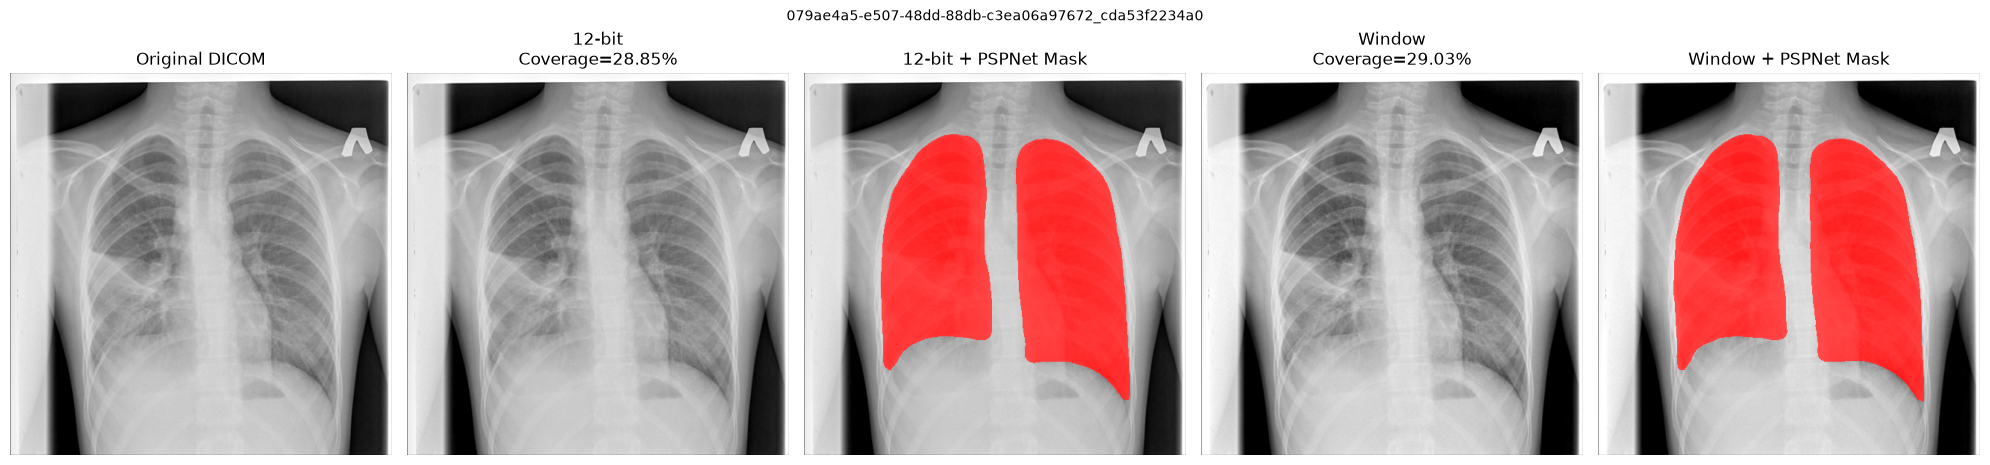

12-bit coverage : 28.8452%
Window coverage : 29.0306%
Saved: C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\Visual_QC_16bit_Preprocessing_Comparison\01_079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0_visual_QC.png

[2/6] 1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11


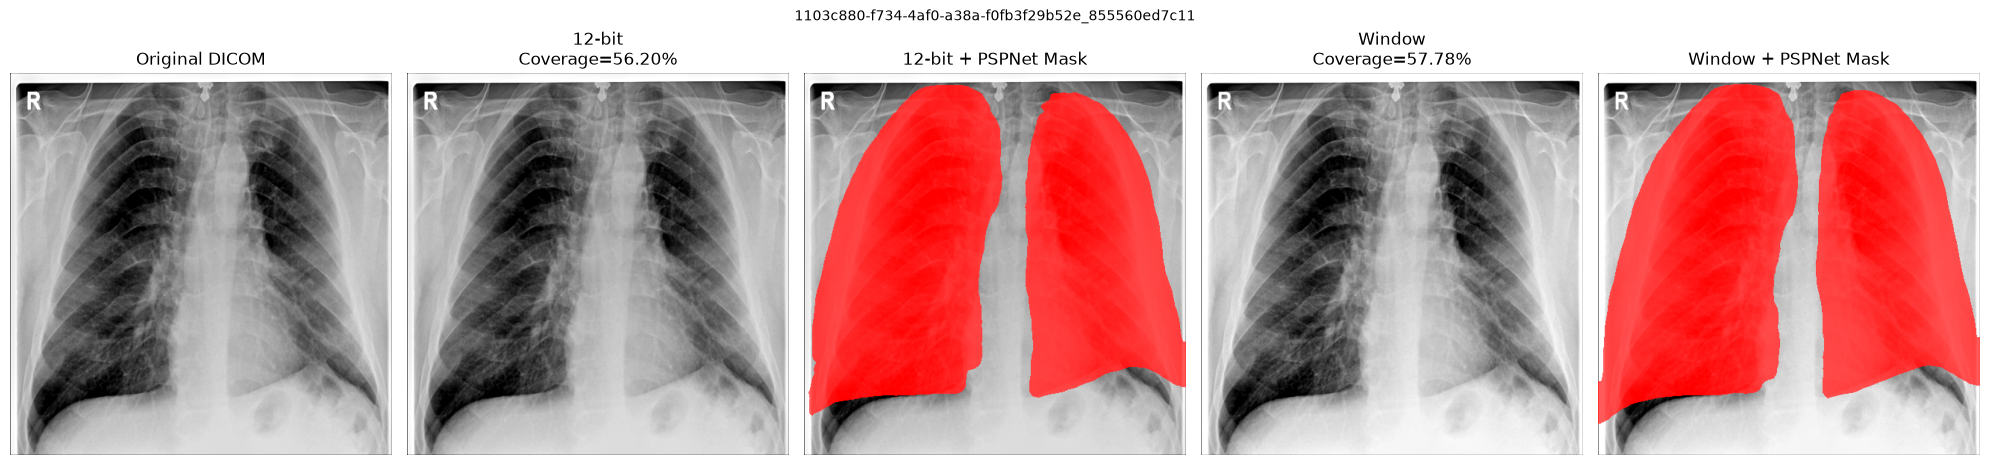

12-bit coverage : 56.2035%
Window coverage : 57.7831%
Saved: C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\Visual_QC_16bit_Preprocessing_Comparison\02_1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11_visual_QC.png

[3/6] a8fa4926-cbae-4990-ab4b-430c0f7f5fa2_cdfd10e8f846


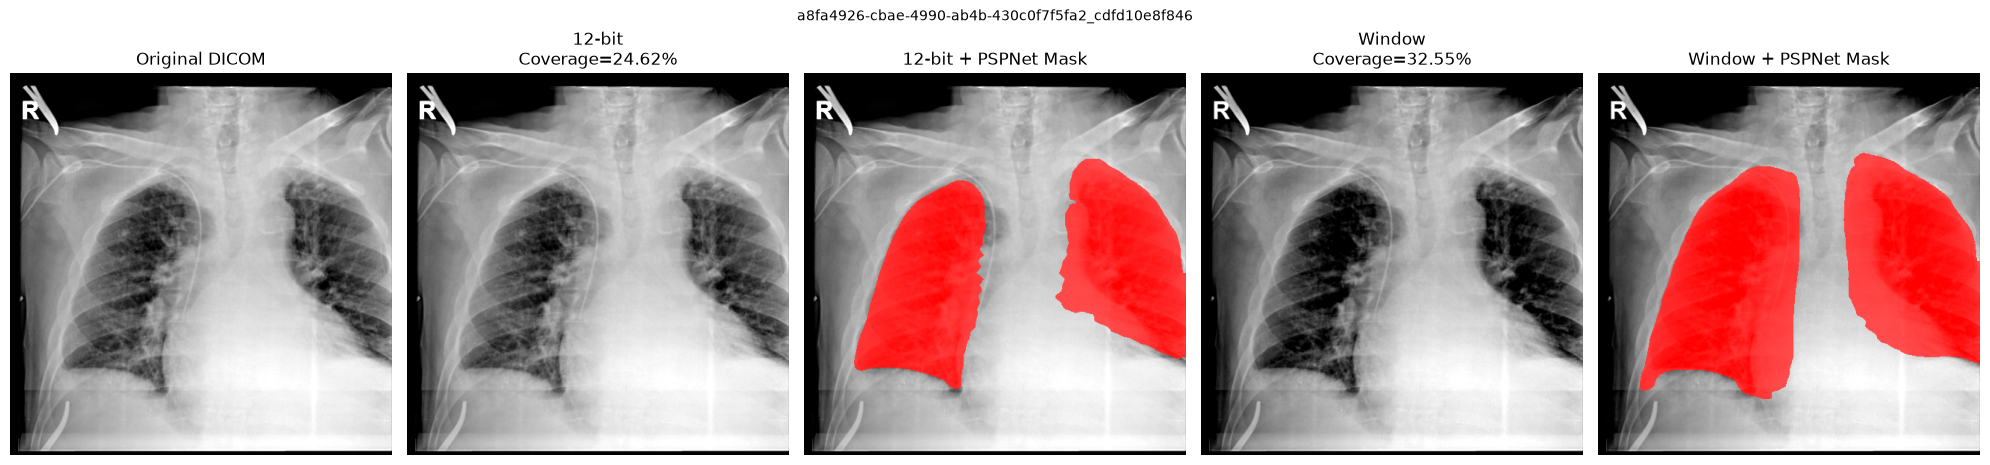

12-bit coverage : 24.6243%
Window coverage : 32.5451%
Saved: C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\Visual_QC_16bit_Preprocessing_Comparison\03_a8fa4926-cbae-4990-ab4b-430c0f7f5fa2_cdfd10e8f846_visual_QC.png

[4/6] e3911f26-358f-43df-a248-0c4dcab89bff_bba29524a160


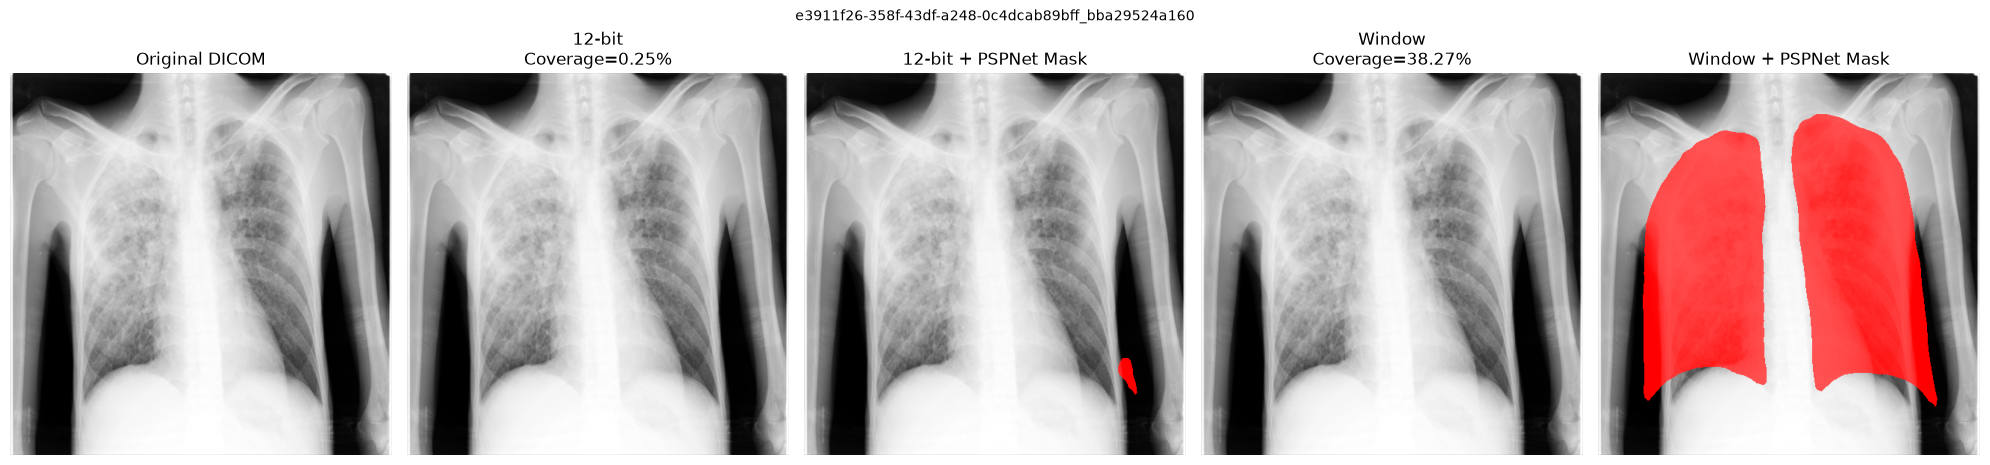

12-bit coverage : 0.2533%
Window coverage : 38.2729%
Saved: C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\Visual_QC_16bit_Preprocessing_Comparison\04_e3911f26-358f-43df-a248-0c4dcab89bff_bba29524a160_visual_QC.png

[5/6] b604a2c3-006e-4693-a937-752584d5c1b2_5aabcdc4500a


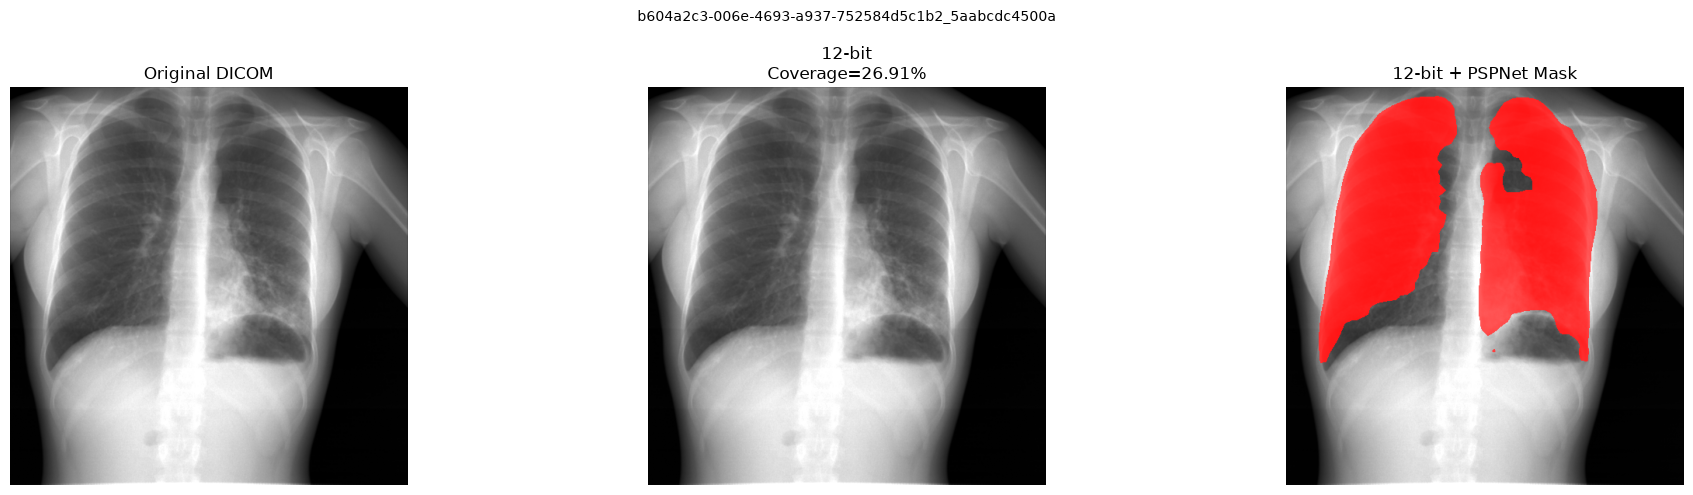

12-bit coverage : 26.9070%
Window coverage : NO WINDOW
Saved: C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\Visual_QC_16bit_Preprocessing_Comparison\05_b604a2c3-006e-4693-a937-752584d5c1b2_5aabcdc4500a_visual_QC.png

[6/6] cb3e391f-c380-4c3f-9601-5d95da3ea158_2401c6748be5


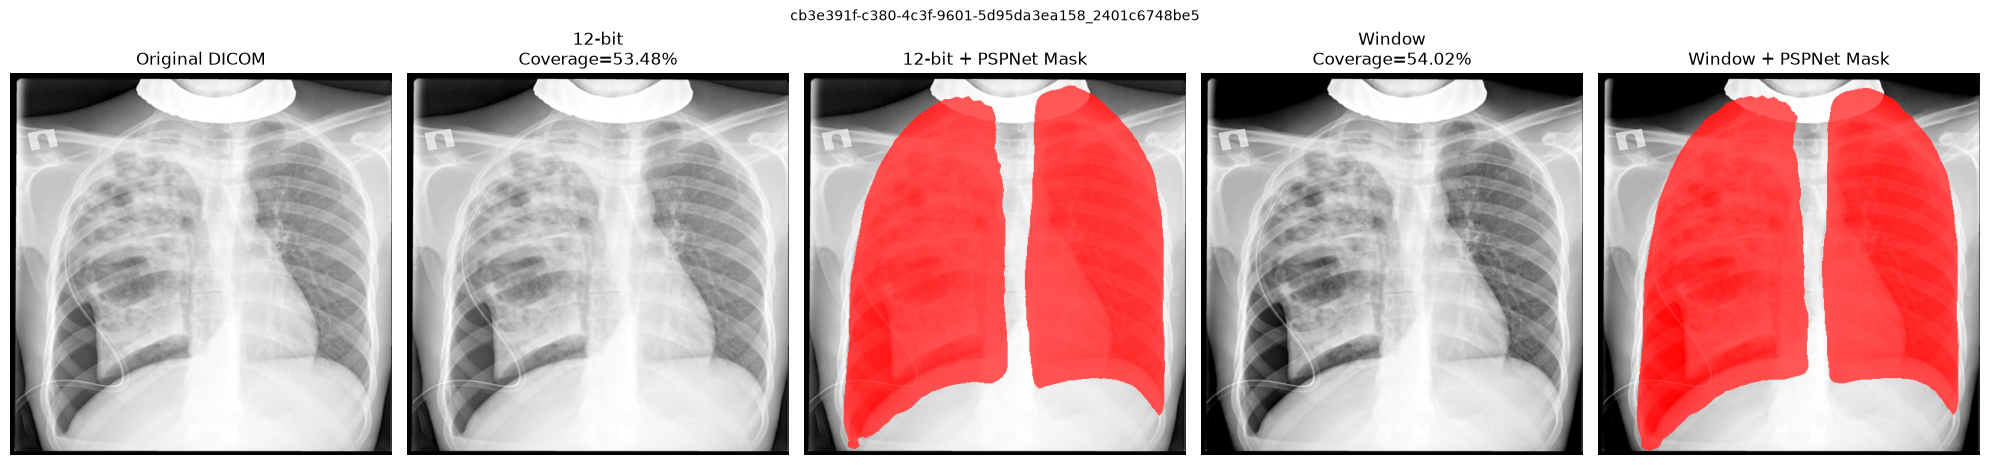

12-bit coverage : 53.4782%
Window coverage : 54.0234%
Saved: C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\Visual_QC_16bit_Preprocessing_Comparison\06_cb3e391f-c380-4c3f-9601-5d95da3ea158_2401c6748be5_visual_QC.png

CELL 23E COMPLETE
Visual QC directory:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\Visual_QC_16bit_Preprocessing_Comparison

NO DICOM FILES MODIFIED.
NO DICOM FILES DELETED.
NO EXISTING MASKS MODIFIED.
NO EXISTING MASKS OVERWRITTEN.


In [36]:
# ================================================================================
# CELL 23E — TARGETED VISUAL ANATOMICAL QC FOR 16-BIT PREPROCESSING
#
# Purpose:
#   Compare 12-bit vs DICOM-window PSPNet masks on representative cases.
#
# IMPORTANT:
# - Diagnostic only.
# - Does NOT modify DICOM files.
# - Does NOT modify existing masks.
# - Does NOT overwrite existing masks.
# - Saves visual QC images only.
# ================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import torch
import matplotlib.pyplot as plt
import torchxrayvision as xrv


# ================================================================================
# 1. PATHS
# ================================================================================

QC_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC"
)

LOCATION_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_DICOM_Location.csv"
)

COMPARISON_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_Preprocessing_Comparison_FINAL.csv"
)

VISUAL_DIR = QC_DIR / (
    "Visual_QC_16bit_Preprocessing_Comparison"
)

VISUAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ================================================================================
# 2. LOAD DATA
# ================================================================================

location_df = pd.read_csv(
    LOCATION_CSV
)

comparison_df = pd.read_csv(
    COMPARISON_CSV
)

if len(location_df) != 21:
    raise ValueError(
        f"Expected 21 location records, found {len(location_df)}"
    )

if len(comparison_df) != 21:
    raise ValueError(
        f"Expected 21 comparison records, found {len(comparison_df)}"
    )


# ================================================================================
# 3. SELECT REPRESENTATIVE CASES
# ================================================================================

selected_stems = [

    # 1. Normal representative case
    "079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0",

    # 2. High coverage
    "1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11",

    # 3. Noticeable 12-bit vs Window difference
    "a8fa4926-cbae-4990-ab4b-430c0f7f5fa2_cdfd10e8f846",

    # 4. Special case: 12-bit very poor, Window good
    "e3911f26-358f-43df-a248-0c4dcab89bff_bba29524a160",

    # 5. Special case: no Window metadata
    "b604a2c3-006e-4693-a937-752584d5c1b2_5aabcdc4500a",

    # 6. Another representative case
    "cb3e391f-c380-4c3f-9601-5d95da3ea158_2401c6748be5"
]


# Verify all selected cases exist
available_stems = set(
    comparison_df["stem"].astype(str)
)

missing_selected = [
    s for s in selected_stems
    if s not in available_stems
]

if missing_selected:
    raise ValueError(
        "Selected stems missing from comparison CSV:\n"
        + "\n".join(missing_selected)
    )


print("=" * 80)
print("CELL 23E — TARGETED VISUAL ANATOMICAL QC")
print("=" * 80)

print("Cases selected:", len(selected_stems))


# ================================================================================
# 4. LOAD PSPNET
# ================================================================================

device = torch.device("cpu")

pspnet = xrv.baseline_models.chestx_det.PSPNet()
pspnet = pspnet.to(device)
pspnet.eval()

center_crop = xrv.datasets.XRayCenterCrop()
resizer = xrv.datasets.XRayResizer(512)


# ================================================================================
# 5. PREPROCESSING
# ================================================================================

def prepare_for_pspnet(img_255):

    img = xrv.datasets.normalize(
        img_255.astype(np.float32),
        maxval=255,
        reshape=False
    )

    img = img[None, :, :]

    img = center_crop(img)
    img = resizer(img)

    img = img[None, :, :, :]

    return torch.from_numpy(
        img.astype(np.float32)
    ).to(device)


def run_pspnet(img_255):

    tensor = prepare_for_pspnet(img_255)

    with torch.no_grad():
        output = pspnet(tensor)

    output = output.detach().cpu().numpy()[0]

    left = output[4]
    right = output[5]

    # Binary mask uses the same 0.5 raw-score threshold
    # used in our previous PSPNet QC.
    left_mask = left >= 0.5
    right_mask = right >= 0.5

    combined_mask = (
        left_mask |
        right_mask
    )

    coverage = (
        combined_mask.sum() /
        combined_mask.size
    ) * 100.0

    return combined_mask, coverage


# ================================================================================
# 6. INTENSITY CONVERSIONS
# ================================================================================

def scale_12bit(arr):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.clip(
        arr,
        0,
        4095
    )

    return (
        arr / 4095.0 * 255.0
    ).astype(np.float32)


def scale_window(arr, wc, ww):

    if (
        wc is None or
        ww is None or
        not np.isfinite(wc) or
        not np.isfinite(ww) or
        ww <= 0
    ):
        return None

    low = wc - ww / 2.0
    high = wc + ww / 2.0

    arr = np.clip(
        arr,
        low,
        high
    )

    return (
        (arr - low) /
        (high - low) *
        255.0
    ).astype(np.float32)


# ================================================================================
# 7. VISUALIZATION HELPERS
# ================================================================================

def normalize_for_display(img):

    img = img.astype(np.float32)

    p1 = np.percentile(
        img,
        1
    )

    p99 = np.percentile(
        img,
        99
    )

    if p99 <= p1:
        p1 = img.min()
        p99 = img.max()

    if p99 <= p1:
        return np.zeros_like(img)

    img = np.clip(
        img,
        p1,
        p99
    )

    return (
        (img - p1) /
        (p99 - p1)
    )


def overlay_mask(image, mask):

    image = normalize_for_display(image)

    rgb = np.stack(
        [image, image, image],
        axis=-1
    )

    # Overlay mask without altering source files.
    rgb[mask, 0] = 1.0
    rgb[mask, 1] *= 0.35
    rgb[mask, 2] *= 0.35

    return rgb


# ================================================================================
# 8. PROCESS SELECTED CASES
# ================================================================================

for case_number, stem in enumerate(
    selected_stems,
    start=1
):

    print()
    print(
        f"[{case_number}/{len(selected_stems)}] {stem}"
    )

    # --------------------------------------------------------------------------
    # Locate DICOM
    # --------------------------------------------------------------------------

    location_row = location_df[
        location_df["stem"].astype(str) == stem
    ]

    if len(location_row) != 1:
        raise ValueError(
            f"Expected exactly one location for {stem}"
        )

    dicom_path = Path(
        str(
            location_row.iloc[0]["dicom_path"]
        )
    )

    if not dicom_path.exists():
        raise FileNotFoundError(
            f"DICOM not found:\n{dicom_path}"
        )

    # --------------------------------------------------------------------------
    # Read DICOM
    # --------------------------------------------------------------------------

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    # --------------------------------------------------------------------------
    # Window metadata
    # --------------------------------------------------------------------------

    try:
        wc = float(
            str(ds.WindowCenter).split("\\")[0]
        )
    except Exception:
        wc = None

    try:
        ww = float(
            str(ds.WindowWidth).split("\\")[0]
        )
    except Exception:
        ww = None

    # --------------------------------------------------------------------------
    # Create 12-bit representation
    # --------------------------------------------------------------------------

    img12 = scale_12bit(arr)

    mask12, coverage12 = run_pspnet(
        img12
    )

    # --------------------------------------------------------------------------
    # Create Window representation
    # --------------------------------------------------------------------------

    img_window = scale_window(
        arr,
        wc,
        ww
    )

    if img_window is not None:

        mask_window, coverage_window = run_pspnet(
            img_window
        )

    else:

        mask_window = None
        coverage_window = None

    # --------------------------------------------------------------------------
    # Resize original for visual comparison
    # --------------------------------------------------------------------------

    original_for_display = xrv.datasets.XRayResizer(512)(
        arr[None, :, :]
    )[0]

    # --------------------------------------------------------------------------
    # Prepare display images
    # --------------------------------------------------------------------------

    display_original = normalize_for_display(
        original_for_display
    )

    display_12bit = normalize_for_display(
        xrv.datasets.XRayResizer(512)(
            img12[None, :, :]
        )[0]
    )

    overlay_12 = overlay_mask(
        display_12bit,
        mask12
    )

    if img_window is not None:

        display_window = normalize_for_display(
            xrv.datasets.XRayResizer(512)(
                img_window[None, :, :]
            )[0]
        )

        overlay_window = overlay_mask(
            display_window,
            mask_window
        )

    # --------------------------------------------------------------------------
    # Plot
    # --------------------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        5 if img_window is not None else 3,
        figsize=(20, 5)
    )

    axes[0].imshow(
        display_original,
        cmap="gray"
    )

    axes[0].set_title(
        "Original DICOM"
    )

    axes[0].axis("off")

    axes[1].imshow(
        display_12bit,
        cmap="gray"
    )

    axes[1].set_title(
        f"12-bit\nCoverage={coverage12:.2f}%"
    )

    axes[1].axis("off")

    axes[2].imshow(
        overlay_12
    )

    axes[2].set_title(
        "12-bit + PSPNet Mask"
    )

    axes[2].axis("off")

    if img_window is not None:

        axes[3].imshow(
            display_window,
            cmap="gray"
        )

        axes[3].set_title(
            f"Window\nCoverage={coverage_window:.2f}%"
        )

        axes[3].axis("off")

        axes[4].imshow(
            overlay_window
        )

        axes[4].set_title(
            "Window + PSPNet Mask"
        )

        axes[4].axis("off")

    fig.suptitle(
        stem,
        fontsize=10
    )

    plt.tight_layout()

    output_path = (
        VISUAL_DIR /
        f"{case_number:02d}_{stem}_visual_QC.png"
    )

    fig.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        "12-bit coverage :",
        f"{coverage12:.4f}%"
    )

    print(
        "Window coverage :",
        (
            f"{coverage_window:.4f}%"
            if coverage_window is not None
            else "NO WINDOW"
        )
    )

    print(
        "Saved:",
        output_path
    )


# ================================================================================
# 9. FINAL MESSAGE
# ================================================================================

print()
print("=" * 80)
print("CELL 23E COMPLETE")
print("=" * 80)

print("Visual QC directory:")
print(VISUAL_DIR)

print()
print("NO DICOM FILES MODIFIED.")
print("NO DICOM FILES DELETED.")
print("NO EXISTING MASKS MODIFIED.")
print("NO EXISTING MASKS OVERWRITTEN.")

In [37]:
# ================================================================================
# CELL 23F — RECOVER 21 FAILED 16-BIT CASES
#
# FINAL RECOVERY POLICY:
#   1. Valid DICOM Window Center/Width -> WINDOW preprocessing
#   2. No valid window -> EFFECTIVE 12-BIT preprocessing (0–4095)
#
# IMPORTANT:
# - Existing 2,049 masks are NOT modified.
# - Existing 2,049 lung-focused CXRs are NOT modified.
# - Recovery outputs go into separate folders.
# ================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
from PIL import Image

import torch
import torchxrayvision as xrv


# ================================================================================
# 1. PATHS
# ================================================================================

NOTEBOOK07_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing"
)

QC_DIR = NOTEBOOK07_DIR / "QC"

LOCATION_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_DICOM_Location.csv"
)

RECOVERY_MASK_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Masks_16bit_Recovery"
)

RECOVERY_CXR_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Focused_CXR_16bit_Recovery"
)

RECOVERY_QC_CSV = QC_DIR / (
    "TB_Portals_March2025_Notebook07_16bit_Recovery_QC.csv"
)


# ================================================================================
# 2. CREATE SEPARATE RECOVERY DIRECTORIES
# ================================================================================

RECOVERY_MASK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RECOVERY_CXR_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ================================================================================
# 3. LOAD VERIFIED 21 CASES
# ================================================================================

location_df = pd.read_csv(
    LOCATION_CSV
)

if len(location_df) != 21:
    raise ValueError(
        f"Expected 21 cases, found {len(location_df)}."
    )


# ================================================================================
# 4. LOAD PSPNET
# ================================================================================

DEVICE = torch.device("cpu")

pspnet = xrv.baseline_models.chestx_det.PSPNet()

pspnet = pspnet.to(DEVICE)

pspnet.eval()

center_crop = xrv.datasets.XRayCenterCrop()
resizer = xrv.datasets.XRayResizer(512)


# ================================================================================
# 5. PREPROCESSING
# ================================================================================

def prepare_for_pspnet(img_255):

    img = xrv.datasets.normalize(
        img_255.astype(np.float32),
        maxval=255,
        reshape=False
    )

    img = img[None, :, :]

    img = center_crop(img)

    img = resizer(img)

    img = img[None, :, :, :]

    return torch.from_numpy(
        img.astype(np.float32)
    ).to(DEVICE)


def scale_effective_12bit(arr):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.clip(
        arr,
        0,
        4095
    )

    return (
        arr / 4095.0 * 255.0
    ).astype(np.float32)


def scale_window(arr, wc, ww):

    if (
        wc is None or
        ww is None or
        not np.isfinite(wc) or
        not np.isfinite(ww) or
        ww <= 0
    ):
        return None

    low = wc - ww / 2.0
    high = wc + ww / 2.0

    arr = np.clip(
        arr,
        low,
        high
    )

    return (
        (arr - low) /
        (high - low) *
        255.0
    ).astype(np.float32)


# ================================================================================
# 6. RUN PSPNET
# ================================================================================

def get_lung_mask(img_255):

    tensor = prepare_for_pspnet(
        img_255
    )

    with torch.no_grad():

        output = pspnet(
            tensor
        )

    output = (
        output
        .detach()
        .cpu()
        .numpy()[0]
    )

    left = output[4]
    right = output[5]

    left_mask = (
        left >= 0.5
    )

    right_mask = (
        right >= 0.5
    )

    combined = (
        left_mask |
        right_mask
    )

    return combined


# ================================================================================
# 7. EXTRACT DICOM WINDOW
# ================================================================================

def get_window_value(ds, attribute):

    try:

        value = getattr(
            ds,
            attribute
        )

        if isinstance(
            value,
            (list, tuple)
        ):
            return float(value[0])

        return float(
            str(value).split("\\")[0]
        )

    except Exception:

        return None


# ================================================================================
# 8. PROCESS 21 CASES
# ================================================================================

results = []

print("=" * 80)
print("CELL 23F — 16-BIT MASK RECOVERY")
print("=" * 80)

print()
print("Cases:", len(location_df))

for i, row in location_df.iterrows():

    stem = str(
        row["stem"]
    )

    dicom_path = Path(
        str(row["dicom_path"])
    )

    print()
    print(
        f"[{i + 1}/21] {stem}"
    )

    if not dicom_path.exists():

        raise FileNotFoundError(
            f"DICOM not found:\n{dicom_path}"
        )

    # --------------------------------------------------------------------------
    # Read DICOM
    # --------------------------------------------------------------------------

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    # --------------------------------------------------------------------------
    # Read window metadata
    # --------------------------------------------------------------------------

    wc = get_window_value(
        ds,
        "WindowCenter"
    )

    ww = get_window_value(
        ds,
        "WindowWidth"
    )

    # --------------------------------------------------------------------------
    # Select preprocessing
    # --------------------------------------------------------------------------

    img_window = scale_window(
        arr,
        wc,
        ww
    )

    if img_window is not None:

        preprocessing_method = (
            "DICOM_WINDOW"
        )

        img_for_pspnet = img_window

    else:

        preprocessing_method = (
            "EFFECTIVE_12BIT"
        )

        img_for_pspnet = (
            scale_effective_12bit(
                arr
            )
        )

    print(
        "  Method:",
        preprocessing_method
    )

    # --------------------------------------------------------------------------
    # Generate lung mask
    # --------------------------------------------------------------------------

    try:

        mask = get_lung_mask(
            img_for_pspnet
        )

        mask_pixels = int(
            mask.sum()
        )

        coverage = (
            mask_pixels /
            mask.size
        ) * 100.0

        # ----------------------------------------------------------------------
        # Safety check
        # ----------------------------------------------------------------------

        if mask_pixels == 0:

            raise ValueError(
                "Recovered mask is empty."
            )

        if mask.shape != (
            512,
            512
        ):

            raise ValueError(
                f"Unexpected mask shape: "
                f"{mask.shape}"
            )

        # ----------------------------------------------------------------------
        # Save mask
        # ----------------------------------------------------------------------

        mask_path = (
            RECOVERY_MASK_DIR /
            f"{stem}.png"
        )

        mask_uint8 = (
            mask.astype(np.uint8)
            * 255
        )

        Image.fromarray(
            mask_uint8,
            mode="L"
        ).save(
            mask_path
        )

        # ----------------------------------------------------------------------
        # Create lung-focused CXR
        #
        # Use the 512x512 preprocessed representation before normalization.
        # Pixels outside the combined lung mask are set to zero.
        # ----------------------------------------------------------------------

        lung_focused = (
            img_for_pspnet *
            mask.astype(np.float32)
        )

        # Normalize to 0–255 for saved visualization.
        finite_values = (
            lung_focused[
                mask
            ]
        )

        if len(finite_values) == 0:

            raise ValueError(
                "No finite lung pixels found."
            )

        low = np.percentile(
            finite_values,
            1
        )

        high = np.percentile(
            finite_values,
            99
        )

        if high <= low:

            low = float(
                finite_values.min()
            )

            high = float(
                finite_values.max()
            )

        if high <= low:

            lung_focused_uint8 = np.zeros(
                (512, 512),
                dtype=np.uint8
            )

        else:

            lung_focused_clipped = np.clip(
                lung_focused,
                low,
                high
            )

            lung_focused_uint8 = (
                (
                    lung_focused_clipped - low
                )
                /
                (
                    high - low
                )
                *
                255.0
            ).astype(
                np.uint8
            )

            # Ensure background is exactly zero.
            lung_focused_uint8[
                ~mask
            ] = 0

        focused_path = (
            RECOVERY_CXR_DIR /
            f"{stem}.png"
        )

        Image.fromarray(
            lung_focused_uint8,
            mode="L"
        ).save(
            focused_path
        )

        # ----------------------------------------------------------------------
        # Verify saved outputs
        # ----------------------------------------------------------------------

        if not mask_path.exists():

            raise RuntimeError(
                "Mask file was not created."
            )

        if not focused_path.exists():

            raise RuntimeError(
                "Lung-focused CXR was not created."
            )

        results.append({

            "stem":
                stem,

            "dicom_path":
                str(dicom_path),

            "preprocessing_method":
                preprocessing_method,

            "window_center":
                wc,

            "window_width":
                ww,

            "raw_min":
                float(arr.min()),

            "raw_max":
                float(arr.max()),

            "mask_pixels":
                mask_pixels,

            "mask_coverage_percent":
                coverage,

            "mask_path":
                str(mask_path),

            "lung_focused_path":
                str(focused_path),

            "status":
                "PASS",

            "error":
                ""
        })

        print(
            f"  Coverage: {coverage:.2f}%"
        )

        print(
            "  Status: PASS"
        )

    except Exception as e:

        results.append({

            "stem":
                stem,

            "dicom_path":
                str(dicom_path),

            "preprocessing_method":
                preprocessing_method,

            "window_center":
                wc,

            "window_width":
                ww,

            "raw_min":
                float(arr.min()),

            "raw_max":
                float(arr.max()),

            "mask_pixels":
                np.nan,

            "mask_coverage_percent":
                np.nan,

            "mask_path":
                "",

            "lung_focused_path":
                "",

            "status":
                "ERROR",

            "error":
                repr(e)
        })

        print(
            "  Status: ERROR"
        )

        print(
            "  Error:",
            repr(e)
        )


# ================================================================================
# 9. SAVE QC
# ================================================================================

recovery_qc_df = pd.DataFrame(
    results
)

recovery_qc_df.to_csv(
    RECOVERY_QC_CSV,
    index=False
)


# ================================================================================
# 10. FINAL SUMMARY
# ================================================================================

print()
print("=" * 80)
print("RECOVERY SUMMARY")
print("=" * 80)

print(
    recovery_qc_df[
        "status"
    ].value_counts(
        dropna=False
    )
)

print()
print(
    recovery_qc_df[
        "preprocessing_method"
    ].value_counts(
        dropna=False
    )
)

successful = recovery_qc_df[
    recovery_qc_df["status"] == "PASS"
]

print()
print(
    "Successful recoveries:",
    len(successful),
    "/ 21"
)

if len(successful) > 0:

    print(
        "Minimum coverage:",
        successful[
            "mask_coverage_percent"
        ].min()
    )

    print(
        "Median coverage:",
        successful[
            "mask_coverage_percent"
        ].median()
    )

    print(
        "Maximum coverage:",
        successful[
            "mask_coverage_percent"
        ].max()
    )


# ================================================================================
# 11. OUTPUT PATHS
# ================================================================================

print()
print("Recovery mask directory:")
print(RECOVERY_MASK_DIR)

print()
print("Recovery lung-focused CXR directory:")
print(RECOVERY_CXR_DIR)

print()
print("Recovery QC:")
print(RECOVERY_QC_CSV)

print()
print("=" * 80)
print("CELL 23F COMPLETE")
print("=" * 80)

print("EXISTING 2,049 MASKS WERE NOT MODIFIED.")
print("EXISTING 2,049 LUNG-FOCUSED CXRs WERE NOT MODIFIED.")
print("NO DICOM FILES WERE MODIFIED.")
print("NO DICOM FILES WERE DELETED.")

CELL 23F — 16-BIT MASK RECOVERY

Cases: 21

[1/21] 079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0
  Method: DICOM_WINDOW
  Status: ERROR
  Error: ValueError('operands could not be broadcast together with shapes (2248,2248) (512,512) ')

[2/21] 1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11
  Method: DICOM_WINDOW
  Status: ERROR
  Error: ValueError('operands could not be broadcast together with shapes (2248,2724) (512,512) ')

[3/21] 26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d
  Method: DICOM_WINDOW
  Status: ERROR
  Error: ValueError('operands could not be broadcast together with shapes (2248,2724) (512,512) ')

[4/21] 50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898
  Method: DICOM_WINDOW
  Status: ERROR
  Error: ValueError('operands could not be broadcast together with shapes (2248,2248) (512,512) ')

[5/21] 71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5
  Method: DICOM_WINDOW
  Status: ERROR
  Error: ValueError('operands could not be broadcast together with shapes (2

In [38]:
# ============================================================
# CELL 23F — 16-BIT MASK RECOVERY — CORRECTED
# ============================================================
#
# IMPORTANT:
# - Existing 2,049 masks are NOT modified.
# - Existing 2,049 lung-focused CXRs are NOT modified.
# - Recovery outputs are written to separate directories.
# - PSPNet mask is generated at 512x512.
# - The lung mask is applied to the corresponding 512x512
#   processed CXR, avoiding shape mismatch.
# ============================================================

from pathlib import Path
import traceback
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import pydicom
from PIL import Image
import matplotlib.pyplot as plt

import torchxrayvision as xrv
import torchvision.transforms as transforms


print("=" * 80)
print("CELL 23F — 16-BIT MASK RECOVERY — CORRECTED")
print("=" * 80)


# ============================================================
# 1. RECOVERY DIRECTORIES
# ============================================================

RECOVERY_MASK_DIR = (
    NOTEBOOK07_DIR / "Lung_Masks_16bit_Recovery"
)

RECOVERY_LUNG_DIR = (
    NOTEBOOK07_DIR / "Lung_Focused_CXR_16bit_Recovery"
)

RECOVERY_QC_DIR = (
    NOTEBOOK07_QC_DIR
)

RECOVERY_MASK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RECOVERY_LUNG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. LOAD AUTHORITATIVE 16-BIT FAILURE INFORMATION
# ============================================================

FULL_DICOM_QC_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_Full_DICOM_Representation_QC.csv"
)

full_qc = pd.read_csv(
    FULL_DICOM_QC_PATH
)

failed_16bit = full_qc[
    (full_qc["bits_stored"] == 16) &
    (full_qc["pspnet_success"] == False)
].copy()


print()
print("16-bit failed cases:", len(failed_16bit))

if len(failed_16bit) != 21:
    raise RuntimeError(
        f"Expected 21 failed 16-bit cases, "
        f"found {len(failed_16bit)}."
    )


# ============================================================
# 3. LOCATE DICOM FILES
# ============================================================

DICOM_SEARCH_ROOT = (
    NOTEBOOK06_DIR
)

all_dicom_files = sorted(
    DICOM_SEARCH_ROOT.rglob("*.dcm")
)

dicom_lookup = {}

for path in all_dicom_files:

    stem = path.stem

    if stem in dicom_lookup:
        raise RuntimeError(
            f"Duplicate DICOM stem found: {stem}"
        )

    dicom_lookup[stem] = path


print()
print("DICOM files discovered:", len(all_dicom_files))


# ============================================================
# 4. WINDOW EXTRACTION
# ============================================================

def get_first_numeric(value):

    if value is None:
        return None

    try:

        if isinstance(value, (list, tuple)):
            if len(value) == 0:
                return None

            value = value[0]

        return float(value)

    except Exception:

        return None


def get_window_values(ds):

    wc = get_first_numeric(
        getattr(ds, "WindowCenter", None)
    )

    ww = get_first_numeric(
        getattr(ds, "WindowWidth", None)
    )

    if wc is None or ww is None:
        return None, None

    if ww <= 0:
        return None, None

    return wc, ww


# ============================================================
# 5. READ DICOM RAW REPRESENTATION
# ============================================================

def read_dicom_array(dicom_path):

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    slope = getattr(
        ds,
        "RescaleSlope",
        None
    )

    intercept = getattr(
        ds,
        "RescaleIntercept",
        None
    )

    slope = (
        1.0
        if slope is None
        else float(slope)
    )

    intercept = (
        0.0
        if intercept is None
        else float(intercept)
    )

    arr = (
        arr * slope
        + intercept
    )

    return ds, arr


# ============================================================
# 6. EFFECTIVE 12-BIT REPRESENTATION
# ============================================================

def make_effective_12bit(arr):

    arr = arr.astype(
        np.float32
    )

    arr = np.clip(
        arr,
        0,
        4095
    )

    arr = (
        arr / 4095.0
    ) * 255.0

    return arr.astype(
        np.float32
    )


# ============================================================
# 7. DICOM WINDOW REPRESENTATION
# ============================================================

def make_dicom_window(arr, wc, ww):

    lower = (
        wc -
        0.5 -
        (ww - 1) / 2
    )

    upper = (
        wc -
        0.5 +
        (ww - 1) / 2
    )

    windowed = np.clip(
        arr,
        lower,
        upper
    )

    windowed = (
        (windowed - lower)
        /
        (upper - lower)
    )

    windowed = (
        windowed * 255.0
    )

    return windowed.astype(
        np.float32
    )


# ============================================================
# 8. PSPNET INPUT PREPARATION
# ============================================================

XRV_TRANSFORM = transforms.Compose([
    xrv.datasets.XRayCenterCrop(),
    xrv.datasets.XRayResizer(512)
])


def prepare_pspnet_input(
    image_array
):

    image_array = np.asarray(
        image_array,
        dtype=np.float32
    )

    normalized = xrv.utils.normalize(
        image_array,
        maxval=255,
        reshape=False
    )

    normalized = normalized[
        None,
        ...
    ]

    processed = XRV_TRANSFORM(
        normalized
    )

    tensor = torch.from_numpy(
        processed
    ).float()

    tensor = tensor.unsqueeze(
        0
    )

    return tensor.to(
        DEVICE
    )


# ============================================================
# 9. GENERATE LUNG MASK
# ============================================================

def generate_lung_mask(
    input_tensor
):

    with torch.no_grad():

        output = model(
            input_tensor
        )

    left_index = model.targets.index(
        "Left Lung"
    )

    right_index = model.targets.index(
        "Right Lung"
    )

    left_score = output[
        0,
        left_index
    ]

    right_score = output[
        0,
        right_index
    ]

    # PSPNet output is thresholded at the same
    # raw-score threshold used in the existing
    # Notebook 07 pipeline.
    left_mask = (
        left_score >= 0.5
    )

    right_mask = (
        right_score >= 0.5
    )

    combined_mask = (
        left_mask |
        right_mask
    )

    return (
        combined_mask,
        left_score,
        right_score
    )


# ============================================================
# 10. RECOVERY LOOP
# ============================================================

recovery_rows = []


for i, row in enumerate(
    failed_16bit.itertuples(index=False),
    start=1
):

    stem = row.stem

    print()
    print(
        f"[{i}/{len(failed_16bit)}] {stem}"
    )

    try:

        # ----------------------------------------------------
        # Locate DICOM
        # ----------------------------------------------------

        dicom_path = dicom_lookup.get(
            stem
        )

        if dicom_path is None:

            raise FileNotFoundError(
                f"DICOM not found for {stem}"
            )


        # ----------------------------------------------------
        # Read DICOM
        # ----------------------------------------------------

        ds, raw_array = read_dicom_array(
            dicom_path
        )


        # ----------------------------------------------------
        # Determine preprocessing method
        # ----------------------------------------------------

        wc, ww = get_window_values(
            ds
        )


        if wc is not None and ww is not None:

            preprocessing_method = (
                "DICOM_WINDOW"
            )

            representation = (
                make_dicom_window(
                    raw_array,
                    wc,
                    ww
                )
            )

        else:

            preprocessing_method = (
                "EFFECTIVE_12BIT"
            )

            representation = (
                make_effective_12bit(
                    raw_array
                )
            )


        # ----------------------------------------------------
        # Prepare PSPNet input
        # ----------------------------------------------------

        pspnet_input = prepare_pspnet_input(
            representation
        )


        # ----------------------------------------------------
        # Generate lung mask
        # ----------------------------------------------------

        mask, left_score, right_score = (
            generate_lung_mask(
                pspnet_input
            )
        )


        mask_np = (
            mask
            .detach()
            .cpu()
            .numpy()
            .astype(np.uint8)
        )


        # ----------------------------------------------------
        # Remove batch dimension
        # ----------------------------------------------------

        mask_np = mask_np.squeeze()

        if mask_np.shape != (
            512,
            512
        ):

            raise RuntimeError(
                "Unexpected mask shape: "
                f"{mask_np.shape}"
            )


        # ----------------------------------------------------
        # Calculate coverage
        # ----------------------------------------------------

        mask_pixels = int(
            mask_np.sum()
        )

        mask_coverage = (
            mask_pixels /
            mask_np.size
        ) * 100.0


        # ----------------------------------------------------
        # Validate non-empty mask
        # ----------------------------------------------------

        if mask_pixels == 0:

            raise ValueError(
                "PSPNet produced an empty "
                "combined lung mask."
            )


        # ====================================================
        # IMPORTANT FIX
        # ====================================================
        #
        # The PSPNet mask is 512x512.
        #
        # Therefore the mask must be applied to the
        # 512x512 processed representation, NOT the
        # original DICOM resolution.
        # ====================================================

        processed_512 = (
            pspnet_input[
                0,
                0
            ]
            .detach()
            .cpu()
            .numpy()
        )


        if processed_512.shape != (
            512,
            512
        ):

            raise RuntimeError(
                "Processed CXR has unexpected "
                f"shape: {processed_512.shape}"
            )


        # ----------------------------------------------------
        # Convert processed image to displayable 8-bit
        # ----------------------------------------------------

        image_min = np.percentile(
            processed_512,
            1
        )

        image_max = np.percentile(
            processed_512,
            99
        )

        if image_max <= image_min:

            image_min = (
                float(processed_512.min())
            )

            image_max = (
                float(processed_512.max())
            )


        lung_image = (
            np.clip(
                processed_512,
                image_min,
                image_max
            )
            - image_min
        )

        denominator = (
            image_max -
            image_min
        )

        if denominator > 0:

            lung_image = (
                lung_image /
                denominator
            ) * 255.0

        else:

            lung_image = np.zeros_like(
                lung_image
            )


        lung_image = (
            lung_image
            .astype(np.uint8)
        )


        # ----------------------------------------------------
        # Apply 512x512 lung mask
        # ----------------------------------------------------

        lung_focused = (
            lung_image *
            mask_np
        )


        # ----------------------------------------------------
        # Save recovery mask
        # ----------------------------------------------------

        mask_path = (
            RECOVERY_MASK_DIR /
            f"{stem}.png"
        )

        Image.fromarray(
            mask_np * 255
        ).save(
            mask_path
        )


        # ----------------------------------------------------
        # Save lung-focused image
        # ----------------------------------------------------

        lung_path = (
            RECOVERY_LUNG_DIR /
            f"{stem}.png"
        )

        Image.fromarray(
            lung_focused
        ).save(
            lung_path
        )


        # ----------------------------------------------------
        # Record successful recovery
        # ----------------------------------------------------

        recovery_rows.append({

            "stem": stem,

            "status": "PASS",

            "preprocessing_method":
                preprocessing_method,

            "window_center":
                wc,

            "window_width":
                ww,

            "original_rows":
                int(raw_array.shape[0]),

            "original_columns":
                int(raw_array.shape[1]),

            "processed_rows":
                512,

            "processed_columns":
                512,

            "mask_pixels":
                mask_pixels,

            "mask_coverage_percent":
                mask_coverage,

            "left_score_max":
                float(
                    left_score.max()
                    .item()
                ),

            "right_score_max":
                float(
                    right_score.max()
                    .item()
                ),

            "dicom_path":
                str(dicom_path),

            "mask_path":
                str(mask_path),

            "lung_focused_path":
                str(lung_path),

            "error":
                ""

        })


        print(
            f"  Method: {preprocessing_method}"
        )

        print(
            f"  Status: PASS"
        )

        print(
            f"  Coverage: "
            f"{mask_coverage:.4f}%"
        )


    except Exception as e:

        recovery_rows.append({

            "stem": stem,

            "status": "ERROR",

            "preprocessing_method":
                preprocessing_method
                if "preprocessing_method"
                in locals()
                else "",

            "window_center":
                wc
                if "wc" in locals()
                else None,

            "window_width":
                ww
                if "ww" in locals()
                else None,

            "original_rows":
                int(raw_array.shape[0])
                if "raw_array" in locals()
                else None,

            "original_columns":
                int(raw_array.shape[1])
                if "raw_array" in locals()
                else None,

            "processed_rows":
                None,

            "processed_columns":
                None,

            "mask_pixels":
                None,

            "mask_coverage_percent":
                None,

            "left_score_max":
                None,

            "right_score_max":
                None,

            "dicom_path":
                str(dicom_path)
                if "dicom_path"
                in locals()
                else "",

            "mask_path":
                "",

            "lung_focused_path":
                "",

            "error":
                repr(e)

        })


        print(
            "  Status: ERROR"
        )

        print(
            f"  Error: {repr(e)}"
        )


# ============================================================
# 11. SAVE RECOVERY QC
# ============================================================

recovery_qc = pd.DataFrame(
    recovery_rows
)

RECOVERY_QC_PATH = (
    RECOVERY_QC_DIR /
    "TB_Portals_March2025_Notebook07_16bit_Recovery_QC_CORRECTED.csv"
)

recovery_qc.to_csv(
    RECOVERY_QC_PATH,
    index=False
)


# ============================================================
# 12. SUMMARY
# ============================================================

print()
print("=" * 80)
print("RECOVERY SUMMARY")
print("=" * 80)

print(
    recovery_qc["status"]
    .value_counts()
)

print()

successful = int(
    (
        recovery_qc["status"] ==
        "PASS"
    ).sum()
)

print(
    f"Successful recoveries: "
    f"{successful} / "
    f"{len(recovery_qc)}"
)

print()
print(
    "Recovery mask directory:"
)

print(
    RECOVERY_MASK_DIR
)

print()
print(
    "Recovery lung-focused CXR directory:"
)

print(
    RECOVERY_LUNG_DIR
)

print()
print(
    "Recovery QC:"
)

print(
    RECOVERY_QC_PATH
)

print()
print("=" * 80)
print("CELL 23F CORRECTED COMPLETE")
print("=" * 80)

print(
    "EXISTING 2,049 MASKS WERE NOT MODIFIED."
)

print(
    "EXISTING 2,049 LUNG-FOCUSED CXRs "
    "WERE NOT MODIFIED."
)

print(
    "NO DICOM FILES WERE MODIFIED."
)

print(
    "NO DICOM FILES WERE DELETED."
)

CELL 23F — 16-BIT MASK RECOVERY — CORRECTED

16-bit failed cases: 21

DICOM files discovered: 2081

[1/21] 079ae4a5-e507-48dd-88db-c3ea06a97672_cda53f2234a0
  Method: DICOM_WINDOW
  Status: PASS
  Coverage: 29.0318%

[2/21] 1103c880-f734-4af0-a38a-f0fb3f29b52e_855560ed7c11
  Method: DICOM_WINDOW
  Status: PASS
  Coverage: 57.7888%

[3/21] 26241dfd-c0cc-4b0f-b469-d2256cbb7374_d8611034445d
  Method: DICOM_WINDOW
  Status: PASS
  Coverage: 47.7535%

[4/21] 50aad9e1-ea8c-4bd6-9033-555cd4d37296_85c880896898
  Method: DICOM_WINDOW
  Status: PASS
  Coverage: 27.3895%

[5/21] 71597ad2-887b-47d7-a7bf-f046a4cf902a_320c3ed4e3b5
  Method: DICOM_WINDOW
  Status: PASS
  Coverage: 31.1596%

[6/21] 88c67008-6ada-457c-8f65-f455c46f25ce_49edf0581c53
  Method: DICOM_WINDOW
  Status: PASS
  Coverage: 31.5426%

[7/21] 8907904f-1749-4156-9274-62e3afec89c3_91d13f88c811
  Method: DICOM_WINDOW
  Status: PASS
  Coverage: 38.6662%

[8/21] 8d0d834f-533c-4145-86e9-c4d5f2f99c6b_09f597274070
  Method: DICOM_WINDOW
 

In [40]:
# ============================================================
# CELL 23G — REMAINING 11 PSPNET FAILURE INVESTIGATION
# CORRECTED AFTER SEPARATE 16-BIT RECOVERY
# ============================================================
#
# IMPORTANT:
# Original PSPNet QC still contains 32 ERROR records.
#
# 21 of those have now been successfully recovered in:
#   Lung_Masks_16bit_Recovery
#
# Therefore:
#
#   32 original failures
# - 21 successful 16-bit recoveries
# = 11 unresolved failures
#
# This cell identifies ONLY those 11 unresolved cases.
#
# NO existing masks are modified.
# NO recovery masks are modified.
# NO DICOM files are modified.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import pydicom


print("=" * 80)
print("CELL 23G — REMAINING 11 PSPNET FAILURE INVESTIGATION")
print("=" * 80)


# ============================================================
# 1. LOAD ORIGINAL PSPNET QC
# ============================================================

PSPNET_QC_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_PSPNet_QC.csv"
)

pspnet_qc = pd.read_csv(
    PSPNET_QC_PATH
)

print()
print(
    "Original PSPNet QC records:",
    len(pspnet_qc)
)

if len(pspnet_qc) != 2081:

    raise RuntimeError(
        f"Expected 2081 PSPNet QC records, "
        f"found {len(pspnet_qc)}."
    )


# ============================================================
# 2. ORIGINAL 32 FAILURES
# ============================================================

original_failures = (
    pspnet_qc[
        pspnet_qc["status"]
        .astype(str)
        .str.upper()
        == "ERROR"
    ]
    .copy()
)

print()
print(
    "Original PSPNet failures:",
    len(original_failures)
)

if len(original_failures) != 32:

    raise RuntimeError(
        f"Expected 32 original failures, "
        f"found {len(original_failures)}."
    )


# ============================================================
# 3. LOAD 21 SUCCESSFUL RECOVERY CASES
# ============================================================

RECOVERY_QC_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_16bit_Recovery_QC_CORRECTED.csv"
)

recovery_qc = pd.read_csv(
    RECOVERY_QC_PATH
)

print()
print(
    "Recovery QC records:",
    len(recovery_qc)
)


successful_recoveries = (
    recovery_qc[
        recovery_qc["status"]
        .astype(str)
        .str.upper()
        == "PASS"
    ]
    .copy()
)

print(
    "Successful recovery cases:",
    len(successful_recoveries)
)

if len(successful_recoveries) != 21:

    raise RuntimeError(
        f"Expected 21 successful recoveries, "
        f"found {len(successful_recoveries)}."
    )


recovered_stems = set(
    successful_recoveries[
        "stem"
    ].astype(str)
)


# ============================================================
# 4. IDENTIFY TRUE REMAINING FAILURES
# ============================================================

remaining_failures = (
    original_failures[
        ~original_failures[
            "stem"
        ].astype(str)
        .isin(
            recovered_stems
        )
    ]
    .copy()
)

print()
print(
    "Remaining unresolved PSPNet failures:",
    len(remaining_failures)
)

if len(remaining_failures) != 11:

    raise RuntimeError(
        f"Expected 11 unresolved failures, "
        f"found {len(remaining_failures)}."
    )


print()
print(
    "Remaining failure stems:"
)

for stem in (
    remaining_failures[
        "stem"
    ].astype(str)
):

    print(
        " ",
        stem
    )


# ============================================================
# 5. AUTHORITATIVE FULL DICOM QC
# ============================================================

FULL_DICOM_QC_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_Full_DICOM_Representation_QC.csv"
)

full_dicom_qc = pd.read_csv(
    FULL_DICOM_QC_PATH
)

print()
print(
    "Full DICOM QC records:",
    len(full_dicom_qc)
)

if len(full_dicom_qc) != 2081:

    raise RuntimeError(
        f"Expected 2081 Full DICOM QC records, "
        f"found {len(full_dicom_qc)}."
    )


# ============================================================
# 6. LOCATE DICOM FILES
# ============================================================

DICOM_SEARCH_ROOT = NOTEBOOK06_DIR

all_dicom_files = sorted(
    DICOM_SEARCH_ROOT.rglob("*.dcm")
)

print()
print(
    "DICOM files discovered:",
    len(all_dicom_files)
)


dicom_lookup = {}

for path in all_dicom_files:

    stem = path.stem

    if stem in dicom_lookup:

        raise RuntimeError(
            f"Duplicate DICOM stem detected: {stem}"
        )

    dicom_lookup[
        stem
    ] = path


# ============================================================
# 7. HELPER
# ============================================================

def first_numeric(value):

    if value is None:
        return np.nan

    try:

        if isinstance(
            value,
            (list, tuple)
        ):

            if len(value) == 0:
                return np.nan

            value = value[0]

        return float(value)

    except Exception:

        return np.nan


# ============================================================
# 8. DICOM REPRESENTATION INSPECTION
# ============================================================

def inspect_dicom(
    dicom_path
):

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = ds.pixel_array.astype(
        np.float32
    )

    bits_allocated = int(
        getattr(
            ds,
            "BitsAllocated",
            0
        )
    )

    bits_stored = int(
        getattr(
            ds,
            "BitsStored",
            0
        )
    )

    pixel_representation = int(
        getattr(
            ds,
            "PixelRepresentation",
            0
        )
    )

    photometric = str(
        getattr(
            ds,
            "PhotometricInterpretation",
            ""
        )
    )

    slope = first_numeric(
        getattr(
            ds,
            "RescaleSlope",
            None
        )
    )

    intercept = first_numeric(
        getattr(
            ds,
            "RescaleIntercept",
            None
        )
    )

    window_center = first_numeric(
        getattr(
            ds,
            "WindowCenter",
            None
        )
    )

    window_width = first_numeric(
        getattr(
            ds,
            "WindowWidth",
            None
        )
    )


    # --------------------------------------------------------
    # Expected stored range
    # --------------------------------------------------------

    if pixel_representation == 0:

        expected_min = 0

        expected_max = (
            2 ** bits_stored
        ) - 1

    else:

        expected_min = -(
            2 ** (
                bits_stored - 1
            )
        )

        expected_max = (
            2 ** (
                bits_stored - 1
            )
        ) - 1


    # --------------------------------------------------------
    # Raw statistics
    # --------------------------------------------------------

    finite = np.isfinite(
        arr
    )

    if finite.any():

        values = arr[
            finite
        ]

        raw_min = float(
            values.min()
        )

        raw_max = float(
            values.max()
        )

        raw_mean = float(
            values.mean()
        )

        raw_std = float(
            values.std()
        )

        raw_median = float(
            np.median(
                values
            )
        )

        raw_p01 = float(
            np.percentile(
                values,
                1
            )
        )

        raw_p99 = float(
            np.percentile(
                values,
                99
            )
        )

    else:

        raw_min = np.nan
        raw_max = np.nan
        raw_mean = np.nan
        raw_std = np.nan
        raw_median = np.nan
        raw_p01 = np.nan
        raw_p99 = np.nan


    # --------------------------------------------------------
    # Range utilization
    # --------------------------------------------------------

    if (
        expected_max >
        expected_min
    ):

        range_utilization = (

            (
                raw_max -
                expected_min
            )

            /

            (
                expected_max -
                expected_min
            )

        ) * 100.0

    else:

        range_utilization = np.nan


    # --------------------------------------------------------
    # Metadata availability
    # --------------------------------------------------------

    has_window = (

        np.isfinite(
            window_center
        )

        and

        np.isfinite(
            window_width
        )

        and

        window_width > 0
    )


    has_rescale = (

        np.isfinite(
            slope
        )

        or

        np.isfinite(
            intercept
        )
    )


    return {

        "dicom_path":
            str(dicom_path),

        "rows":
            int(
                getattr(
                    ds,
                    "Rows",
                    arr.shape[0]
                )
            ),

        "columns":
            int(
                getattr(
                    ds,
                    "Columns",
                    arr.shape[1]
                )
            ),

        "bits_allocated":
            bits_allocated,

        "bits_stored":
            bits_stored,

        "pixel_representation":
            pixel_representation,

        "photometric":
            photometric,

        "rescale_slope":
            slope,

        "rescale_intercept":
            intercept,

        "window_center":
            window_center,

        "window_width":
            window_width,

        "has_window":
            has_window,

        "has_rescale":
            has_rescale,

        "expected_stored_min":
            expected_min,

        "expected_stored_max":
            expected_max,

        "raw_min":
            raw_min,

        "raw_max":
            raw_max,

        "raw_mean":
            raw_mean,

        "raw_std":
            raw_std,

        "raw_median":
            raw_median,

        "raw_p01":
            raw_p01,

        "raw_p99":
            raw_p99,

        "range_utilization_percent":
            range_utilization
    }


# ============================================================
# 9. INVESTIGATE ONLY THE 11
# ============================================================

diagnostic_rows = []


for index, row in enumerate(
    remaining_failures.iterrows(),
    start=1
):

    _, failure_row = row

    stem = str(
        failure_row["stem"]
    )

    print()
    print(
        "-" * 80
    )

    print(
        f"[{index}/11] {stem}"
    )


    dicom_path = dicom_lookup.get(
        stem
    )


    if dicom_path is None:

        print(
            "DICOM: NOT FOUND"
        )

        diagnostic_rows.append({

            "stem":
                stem,

            "dicom_found":
                False,

            "pspnet_error":
                failure_row.get(
                    "error",
                    ""
                )

        })

        continue


    try:

        metadata = inspect_dicom(
            dicom_path
        )

        metadata[
            "stem"
        ] = stem

        metadata[
            "dicom_found"
        ] = True

        metadata[
            "pspnet_error"
        ] = failure_row.get(
            "error",
            ""
        )

        diagnostic_rows.append(
            metadata
        )


        print(
            "Bits Allocated :",
            metadata[
                "bits_allocated"
            ]
        )

        print(
            "Bits Stored    :",
            metadata[
                "bits_stored"
            ]
        )

        print(
            "Photometric    :",
            metadata[
                "photometric"
            ]
        )

        print(
            "Rescale        :",
            metadata[
                "has_rescale"
            ]
        )

        print(
            "Window         :",
            metadata[
                "has_window"
            ]
        )

        print(
            "Dimensions     :",
            metadata[
                "rows"
            ],
            "x",
            metadata[
                "columns"
            ]
        )

        print(
            "Raw min        :",
            metadata[
                "raw_min"
            ]
        )

        print(
            "Raw max        :",
            metadata[
                "raw_max"
            ]
        )

        print(
            "Raw mean       :",
            metadata[
                "raw_mean"
            ]
        )

        print(
            "Raw std        :",
            metadata[
                "raw_std"
            ]
        )

        print(
            "Range usage    :",
            f"{metadata['range_utilization_percent']:.4f}%"
        )


    except Exception as e:

        print(
            "DICOM inspection ERROR:",
            repr(e)
        )

        diagnostic_rows.append({

            "stem":
                stem,

            "dicom_found":
                True,

            "dicom_path":
                str(dicom_path),

            "inspection_error":
                repr(e),

            "pspnet_error":
                failure_row.get(
                    "error",
                    ""
                )

        })


# ============================================================
# 10. SAVE DIAGNOSTIC CSV
# ============================================================

failure_diagnostic = pd.DataFrame(
    diagnostic_rows
)

FAILURE_DIAGNOSTIC_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_Remaining_11_Failure_Diagnosis.csv"
)

failure_diagnostic.to_csv(
    FAILURE_DIAGNOSTIC_PATH,
    index=False
)


# ============================================================
# 11. SUMMARY
# ============================================================

print()
print("=" * 80)
print("REMAINING 11 FAILURE — REPRESENTATION SUMMARY")
print("=" * 80)


for column, title in [

    (
        "bits_stored",
        "Bits Stored"
    ),

    (
        "bits_allocated",
        "Bits Allocated"
    ),

    (
        "photometric",
        "Photometric"
    ),

    (
        "has_window",
        "Window Metadata"
    ),

    (
        "has_rescale",
        "Rescale Metadata"
    )

]:

    if column in failure_diagnostic.columns:

        print()
        print(
            title + ":"
        )

        print(
            failure_diagnostic[
                column
            ]
            .value_counts(
                dropna=False
            )
            .sort_index()
        )


# ============================================================
# 12. COMPLETE 11-CASE TABLE
# ============================================================

display_columns = [

    "stem",

    "bits_allocated",

    "bits_stored",

    "pixel_representation",

    "photometric",

    "rows",

    "columns",

    "has_rescale",

    "has_window",

    "window_center",

    "window_width",

    "raw_min",

    "raw_max",

    "raw_mean",

    "raw_std",

    "raw_median",

    "raw_p01",

    "raw_p99",

    "range_utilization_percent"

]


available_columns = [
    column
    for column in display_columns
    if column in failure_diagnostic.columns
]


print()
print("=" * 80)
print("COMPLETE 11-CASE DIAGNOSTIC TABLE")
print("=" * 80)

display(
    failure_diagnostic[
        available_columns
    ]
)


# ============================================================
# 13. FINAL SAFETY CHECK
# ============================================================

print()
print("=" * 80)
print("CELL 23G COMPLETE")
print("=" * 80)

print()
print(
    "Original PSPNet failures :",
    len(original_failures)
)

print(
    "Successful 16-bit recovery:",
    len(successful_recoveries)
)

print(
    "Remaining unresolved     :",
    len(remaining_failures)
)

print()
print(
    "No existing masks were modified."
)

print(
    "No recovery masks were modified."
)

print(
    "No lung-focused CXRs were modified."
)

print(
    "No DICOM files were modified."
)

print(
    "No DICOM files were deleted."
)

print()
print(
    "Diagnostic CSV:"
)

print(
    FAILURE_DIAGNOSTIC_PATH
)

print("=" * 80)

CELL 23G — REMAINING 11 PSPNET FAILURE INVESTIGATION

Original PSPNet QC records: 2081

Original PSPNet failures: 32

Recovery QC records: 21
Successful recovery cases: 21

Remaining unresolved PSPNet failures: 11

Remaining failure stems:
  0a625185-7b0b-464c-aab1-f1db5d116454_01761b3dead6
  10851a5d-fb5c-4d96-857c-b6e5d196538b_f627e3cec0bd
  5bc0522b-f5f9-461b-bce8-29328628b0ba_b726260baaab
  67a7ec42-9add-470c-8bc6-86b43a265464_cc48022b779d
  af2a8604-b136-458d-a2c4-514ece8e3be2_1d9eb2527fe4
  b864e5fa-4f83-487e-9ae2-2465363e65b6_0fee2fcb2af7
  b99faf1c-8e08-4dc0-bbf6-0f0a941e29cd_7c829c66d0d7
  daa9bfff-950e-4222-9883-c1436eb73f1f_0b02995e800e
  e73a742b-1b6d-49cd-a50e-f2f488f2719a_28bf7a26ca6e
  f3f44e35-4004-40a3-9f6b-26d649d8924a_ba69561465c9
  f6868b5c-ebbe-4969-a7c0-285f0dba6f12_8b753362820c

Full DICOM QC records: 2081

DICOM files discovered: 2081

--------------------------------------------------------------------------------
[1/11] 0a625185-7b0b-464c-aab1-f1db5d116454_017

,stem,bits_allocated,bits_stored,pixel_representation,photometric,rows,columns,has_rescale,has_window,window_center,window_width,raw_min,raw_max,raw_mean,raw_std,raw_median,raw_p01,raw_p99,range_utilization_percent
0,0a625185-7b0b-464c-aab1-f1db5d116454_01761b3dead6,8,8,0,MONOCHROME2,2929,2401,True,False,NaN,NaN,0.0,255.0,205.430969,34.561939,216.0,83.0,249.0,100.0
1,10851a5d-fb5c-4d96-857c-b6e5d196538b_f627e3cec0bd,8,8,0,MONOCHROME2,2245,1917,True,False,NaN,NaN,0.0,255.0,110.321121,73.223625,101.0,0.0,255.0,100.0
2,5bc0522b-f5f9-461b-bce8-29328628b0ba_b726260baaab,8,8,0,MONOCHROME2,434,403,False,False,NaN,NaN,0.0,255.0,136.656189,53.052788,128.0,43.0,251.0,100.0
3,67a7ec42-9add-470c-8bc6-86b43a265464_cc48022b779d,8,8,0,MONOCHROME2,3587,2791,True,False,NaN,NaN,0.0,255.0,197.974197,35.363014,204.0,114.0,243.0,100.0
4,af2a8604-b136-458d-a2c4-514ece8e3be2_1d9eb2527fe4,8,8,0,MONOCHROME2,1944,2092,False,False,NaN,NaN,0.0,255.0,188.292084,59.165638,212.0,53.0,254.0,100.0
5,b864e5fa-4f83-487e-9ae2-2465363e65b6_0fee2fcb2af7,8,8,0,MONOCHROME2,668,1371,True,False,NaN,NaN,0.0,255.0,244.607147,35.760971,255.0,75.0,255.0,100.0
6,b99faf1c-8e08-4dc0-bbf6-0f0a941e29cd_7c829c66d0d7,8,8,0,MONOCHROME2,1573,2998,True,False,NaN,NaN,0.0,255.0,177.495468,63.363144,201.0,60.0,252.0,100.0
7,daa9bfff-950e-4222-9883-c1436eb73f1f_0b02995e800e,8,8,0,MONOCHROME2,1713,2093,True,False,NaN,NaN,0.0,255.0,167.746780,43.389874,163.0,2.0,255.0,100.0
8,e73a742b-1b6d-49cd-a50e-f2f488f2719a_28bf7a26ca6e,8,8,0,MONOCHROME2,452,363,True,False,NaN,NaN,0.0,255.0,210.182846,36.264099,220.0,0.0,255.0,100.0
9,f3f44e35-4004-40a3-9f6b-26d649d8924a_ba69561465c9,8,8,0,MONOCHROME2,2322,4128,True,False,NaN,NaN,0.0,255.0,215.746201,43.786926,224.0,0.0,254.0,100.0



CELL 23G COMPLETE

Original PSPNet failures : 32
Successful 16-bit recovery: 21
Remaining unresolved     : 11

No existing masks were modified.
No recovery masks were modified.
No lung-focused CXRs were modified.
No DICOM files were modified.
No DICOM files were deleted.

Diagnostic CSV:
C:\TBP\Metadata\Step_3B_7_CXR_Lung_Region_Processing\QC\TB_Portals_March2025_Notebook07_Remaining_11_Failure_Diagnosis.csv


CELL 23H — CONTROLLED DIAGNOSTIC TEST

Diagnostic records: 11

PSPNet: PSPNet
Device: cpu

--------------------------------------------------------------------------------
[1/11] 0a625185-7b0b-464c-aab1-f1db5d116454_01761b3dead6
Source shape: 2929 x 2401
After crop: (1, 2401, 2401)
After resize: (1, 512, 512)
Left max: -2.086099147796631
Right max: -1.540387511253357
Mask coverage: 0.0000%


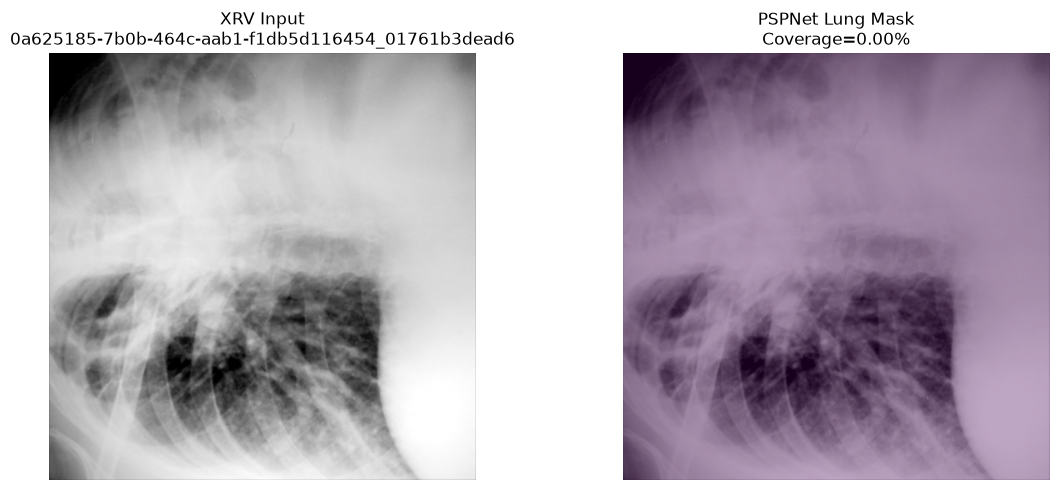


--------------------------------------------------------------------------------
[2/11] 10851a5d-fb5c-4d96-857c-b6e5d196538b_f627e3cec0bd
Source shape: 2245 x 1917
After crop: (1, 1917, 1917)
After resize: (1, 512, 512)
Left max: -0.6339012980461121
Right max: -4.475082874298096
Mask coverage: 0.0000%


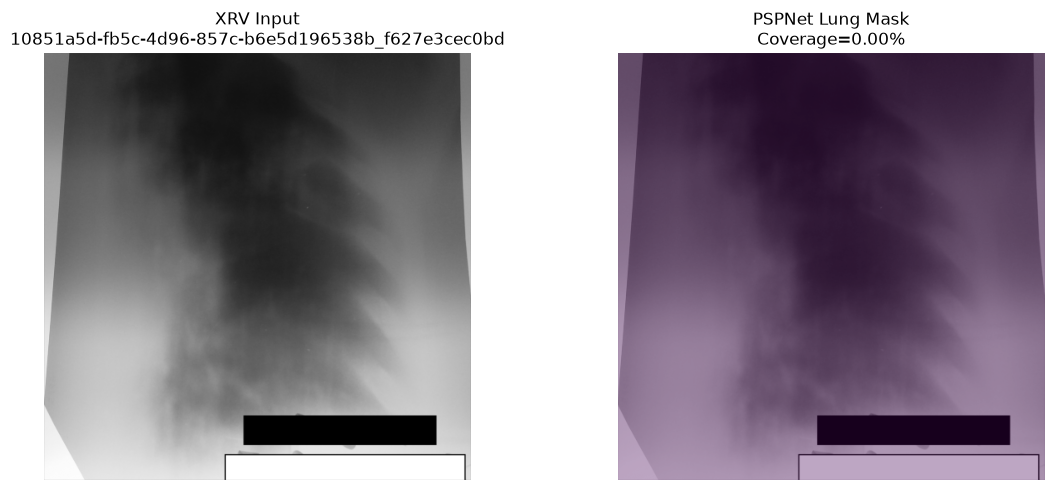


--------------------------------------------------------------------------------
[3/11] 5bc0522b-f5f9-461b-bce8-29328628b0ba_b726260baaab
Source shape: 434 x 403
After crop: (1, 403, 403)
After resize: (1, 512, 512)
Left max: -0.39573565125465393
Right max: -0.8890232443809509
Mask coverage: 0.0000%


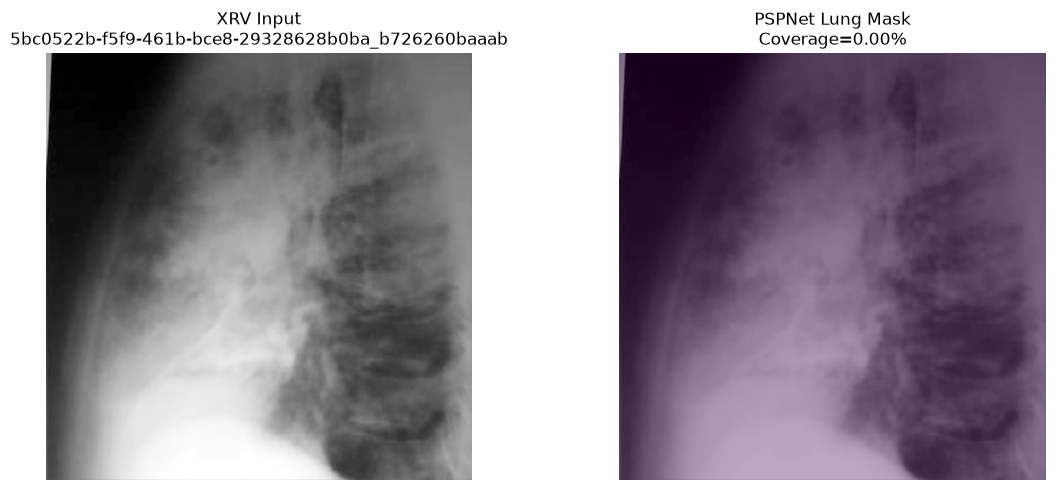


--------------------------------------------------------------------------------
[4/11] 67a7ec42-9add-470c-8bc6-86b43a265464_cc48022b779d
Source shape: 3587 x 2791
After crop: (1, 2791, 2791)
After resize: (1, 512, 512)
Left max: -0.2909330725669861
Right max: -3.0690970420837402
Mask coverage: 0.0000%


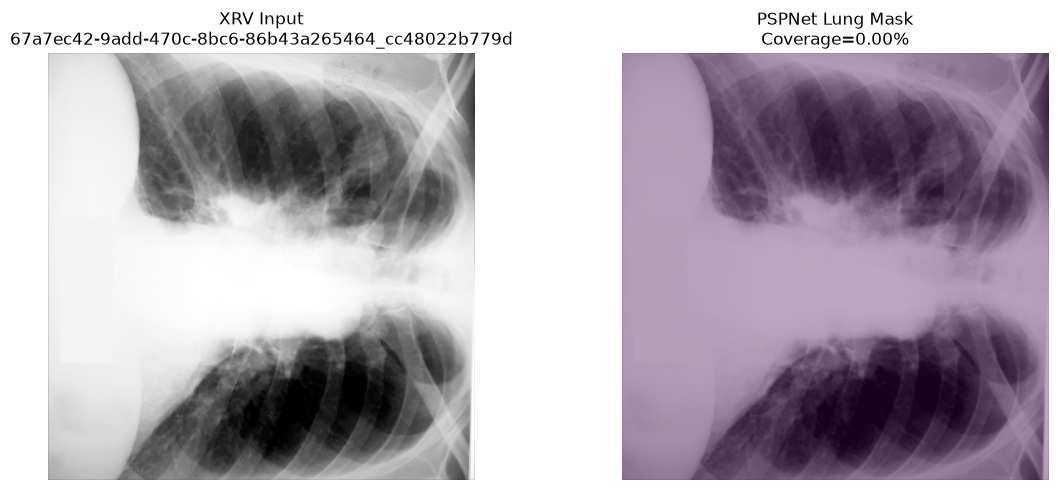


--------------------------------------------------------------------------------
[5/11] af2a8604-b136-458d-a2c4-514ece8e3be2_1d9eb2527fe4
Source shape: 1944 x 2092
After crop: (1, 1944, 1944)
After resize: (1, 512, 512)
Left max: -0.9474779963493347
Right max: -0.3959279954433441
Mask coverage: 0.0000%


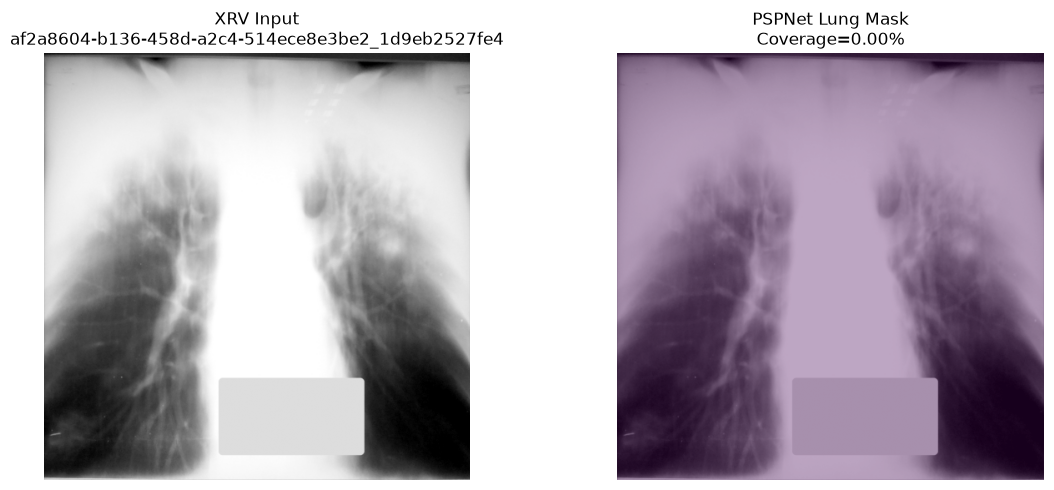


--------------------------------------------------------------------------------
[6/11] b864e5fa-4f83-487e-9ae2-2465363e65b6_0fee2fcb2af7
Source shape: 668 x 1371
After crop: (1, 668, 668)
After resize: (1, 512, 512)
Left max: -2.854851484298706
Right max: -4.778800964355469
Mask coverage: 0.0000%


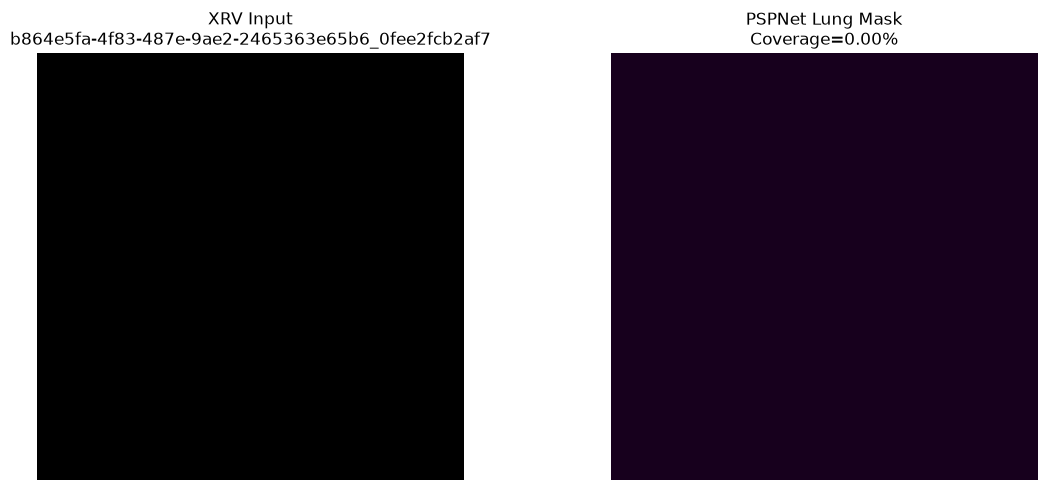


--------------------------------------------------------------------------------
[7/11] b99faf1c-8e08-4dc0-bbf6-0f0a941e29cd_7c829c66d0d7
Source shape: 1573 x 2998
After crop: (1, 1573, 1573)
After resize: (1, 512, 512)
Left max: -1.687968373298645
Right max: -2.044311046600342
Mask coverage: 0.0000%


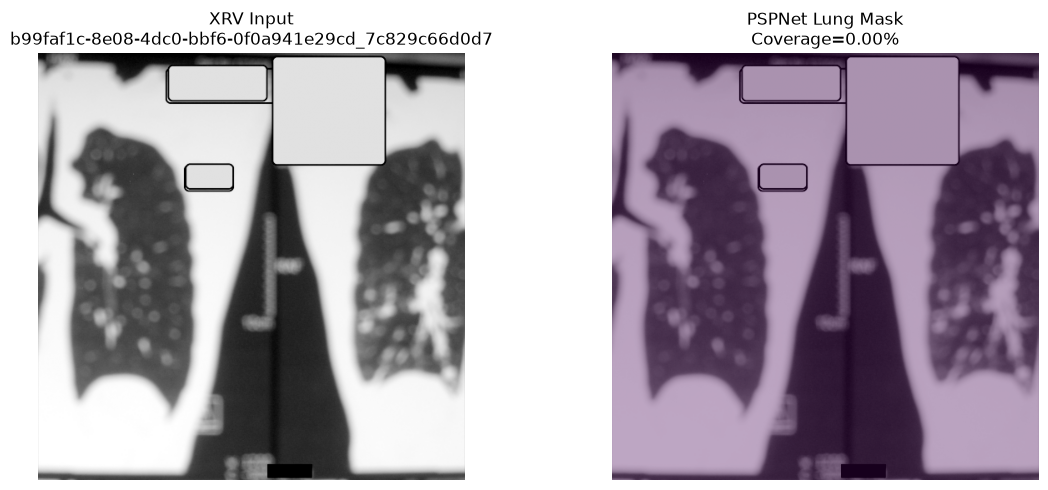


--------------------------------------------------------------------------------
[8/11] daa9bfff-950e-4222-9883-c1436eb73f1f_0b02995e800e
Source shape: 1713 x 2093
After crop: (1, 1713, 1713)
After resize: (1, 512, 512)
Left max: -3.339179515838623
Right max: -2.9448485374450684
Mask coverage: 0.0000%


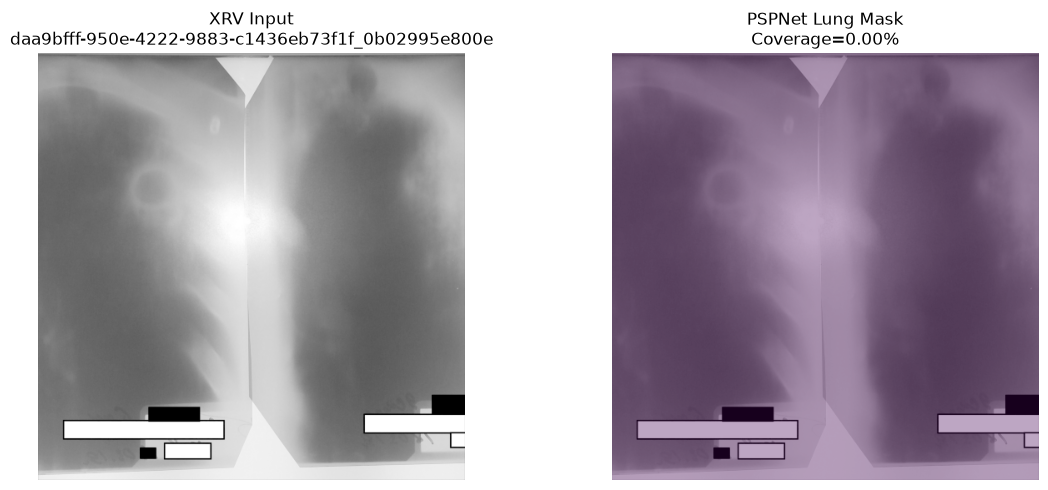


--------------------------------------------------------------------------------
[9/11] e73a742b-1b6d-49cd-a50e-f2f488f2719a_28bf7a26ca6e
Source shape: 452 x 363
After crop: (1, 363, 363)
After resize: (1, 512, 512)
Left max: -0.7190694212913513
Right max: -3.354823350906372
Mask coverage: 0.0000%


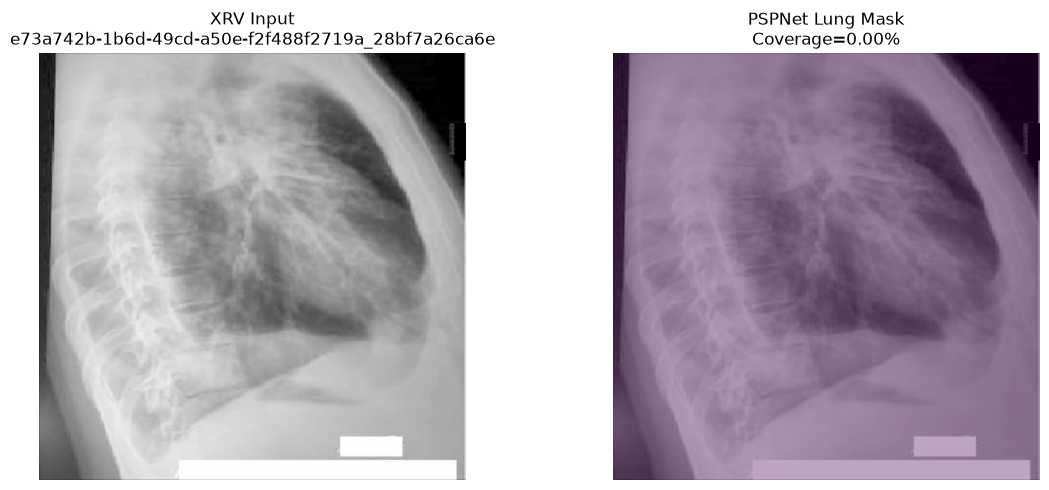


--------------------------------------------------------------------------------
[10/11] f3f44e35-4004-40a3-9f6b-26d649d8924a_ba69561465c9
Source shape: 2322 x 4128
After crop: (1, 2322, 2322)
After resize: (1, 512, 512)
Left max: -3.647580862045288
Right max: -4.2073869705200195
Mask coverage: 0.0000%


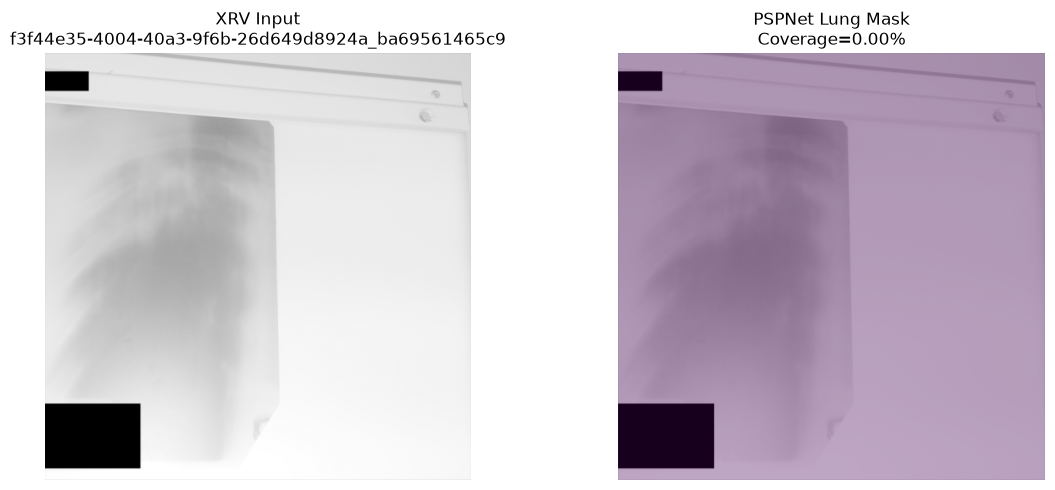


--------------------------------------------------------------------------------
[11/11] f6868b5c-ebbe-4969-a7c0-285f0dba6f12_8b753362820c
Source shape: 816 x 612
After crop: (1, 612, 612)
After resize: (1, 512, 512)
Left max: -2.819974422454834
Right max: -3.0332231521606445
Mask coverage: 0.0000%


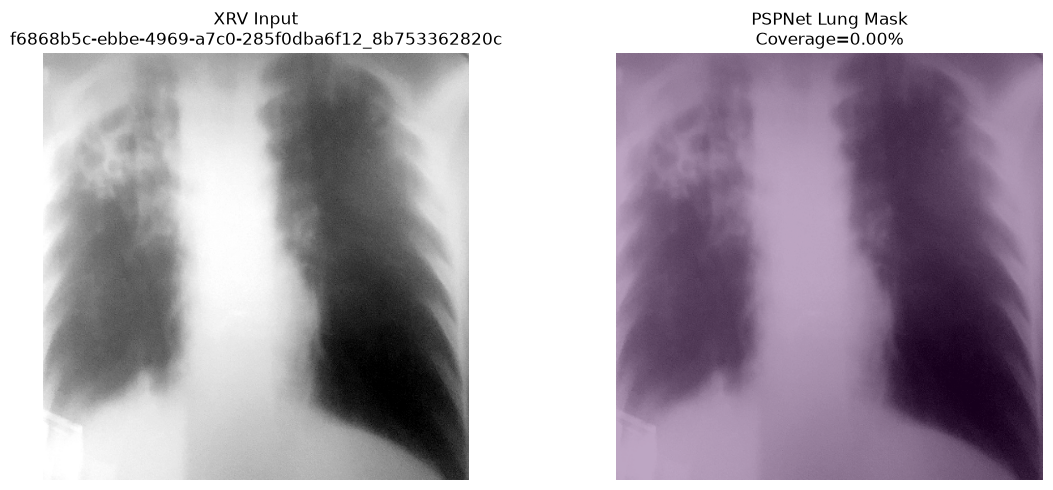


CELL 23H SUMMARY

                                             stem  source_height  source_width  left_max  right_max  mask_pixels  coverage_percent
0a625185-7b0b-464c-aab1-f1db5d116454_01761b3dead6           2929          2401 -2.086099  -1.540388            0               0.0
10851a5d-fb5c-4d96-857c-b6e5d196538b_f627e3cec0bd           2245          1917 -0.633901  -4.475083            0               0.0
5bc0522b-f5f9-461b-bce8-29328628b0ba_b726260baaab            434           403 -0.395736  -0.889023            0               0.0
67a7ec42-9add-470c-8bc6-86b43a265464_cc48022b779d           3587          2791 -0.290933  -3.069097            0               0.0
af2a8604-b136-458d-a2c4-514ece8e3be2_1d9eb2527fe4           1944          2092 -0.947478  -0.395928            0               0.0
b864e5fa-4f83-487e-9ae2-2465363e65b6_0fee2fcb2af7            668          1371 -2.854851  -4.778801            0               0.0
b99faf1c-8e08-4dc0-bbf6-0f0a941e29cd_7c829c66d0d7           1573

In [41]:
# ============================================================
# CELL 23H — CONTROLLED DIAGNOSTIC TEST FOR REMAINING 11
# ============================================================
#
# PURPOSE:
# Determine whether the remaining 11 failures are caused by:
#   1. image geometry / aspect ratio
#   2. very small source images
#   3. intensity representation
#   4. PSPNet response after official XRV preprocessing
#
# IMPORTANT:
#   Diagnostic only.
#   No existing masks modified.
#   No recovery masks modified.
#   No DICOM files modified.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import pydicom
import torch
import torchxrayvision as xrv
import matplotlib.pyplot as plt


print("=" * 80)
print("CELL 23H — CONTROLLED DIAGNOSTIC TEST")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

FAILURE_DIAGNOSTIC_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_Remaining_11_Failure_Diagnosis.csv"
)

VISUAL_DIR = (
    NOTEBOOK07_QC_DIR /
    "Visual_QC_Remaining_11"
)

VISUAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. LOAD DIAGNOSTIC TABLE
# ============================================================

failure_df = pd.read_csv(
    FAILURE_DIAGNOSTIC_PATH
)

print()
print(
    "Diagnostic records:",
    len(failure_df)
)

if len(failure_df) != 11:

    raise RuntimeError(
        f"Expected 11 cases, found {len(failure_df)}."
    )


# ============================================================
# 3. LOAD PSPNET
# ============================================================

device = torch.device(
    "cpu"
)

pspnet = (
    xrv.baseline_models
    .chestx_det
    .PSPNet()
)

pspnet = pspnet.to(
    device
)

pspnet.eval()

print()
print(
    "PSPNet:",
    type(pspnet).__name__
)

print(
    "Device:",
    device
)


# ============================================================
# 4. OFFICIAL XRV TRANSFORMS
# ============================================================

center_crop = (
    xrv.datasets
    .XRayCenterCrop()
)

resizer = (
    xrv.datasets
    .XRayResizer(
        512
    )
)


# ============================================================
# 5. PREPROCESSING FUNCTION
# ============================================================

def prepare_8bit_xrv(
    dicom_path
):

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    arr = (
        ds.pixel_array
        .astype(
            np.float32
        )
    )

    # --------------------------------------------------------
    # Rescale
    # --------------------------------------------------------

    slope = getattr(
        ds,
        "RescaleSlope",
        1.0
    )

    intercept = getattr(
        ds,
        "RescaleIntercept",
        0.0
    )

    if slope is None:
        slope = 1.0

    if intercept is None:
        intercept = 0.0

    try:
        slope = float(slope)
    except Exception:
        slope = 1.0

    try:
        intercept = float(intercept)
    except Exception:
        intercept = 0.0

    arr = (
        arr * slope
        + intercept
    )

    # --------------------------------------------------------
    # MONOCHROME1 handling
    # --------------------------------------------------------

    photometric = str(
        getattr(
            ds,
            "PhotometricInterpretation",
            ""
        )
    ).upper()

    if photometric == "MONOCHROME1":

        arr_min = np.nanmin(
            arr
        )

        arr_max = np.nanmax(
            arr
        )

        arr = (
            arr_max
            + arr_min
            - arr
        )

    # --------------------------------------------------------
    # 8-bit representation
    # --------------------------------------------------------

    arr = np.clip(
        arr,
        0,
        255
    )

    arr = arr.astype(
        np.float32
    )

    # --------------------------------------------------------
    # Official XRV normalization
    # --------------------------------------------------------

    arr = (
        xrv.datasets
        .normalize(
            arr,
            maxval=255
        )
    )

    # --------------------------------------------------------
    # Channel dimension
    # --------------------------------------------------------

    arr = arr[None, :, :]

    original_shape = arr.shape

    # --------------------------------------------------------
    # Official XRV center crop
    # --------------------------------------------------------

    cropped = center_crop(
        arr
    )

    cropped_shape = cropped.shape

    # --------------------------------------------------------
    # Official XRV resize
    # --------------------------------------------------------

    resized = resizer(
        cropped
    )

    resized_shape = resized.shape

    tensor = torch.from_numpy(
        resized
    ).unsqueeze(
        0
    ).float()

    return (
        ds,
        arr,
        cropped,
        resized,
        tensor,
        original_shape,
        cropped_shape,
        resized_shape
    )


# ============================================================
# 6. PROCESS THE 11 CASES
# ============================================================

results = []


for idx, row in failure_df.iterrows():

    stem = str(
        row["stem"]
    )

    dicom_path = Path(
        row["dicom_path"]
    )

    print()
    print("-" * 80)
    print(
        f"[{idx + 1}/11] {stem}"
    )

    if not dicom_path.exists():

        print(
            "DICOM NOT FOUND"
        )

        results.append({

            "stem":
                stem,

            "status":
                "DICOM_NOT_FOUND"

        })

        continue


    try:

        (
            ds,
            original,
            cropped,
            resized,
            tensor,
            original_shape,
            cropped_shape,
            resized_shape
        ) = prepare_8bit_xrv(
            dicom_path
        )


        # ----------------------------------------------------
        # PSPNet inference
        # ----------------------------------------------------

        with torch.no_grad():

            output = pspnet(
                tensor.to(
                    device
                )
            )


        output_np = (
            output
            .detach()
            .cpu()
            .numpy()
        )


        # ----------------------------------------------------
        # Lung channels
        # ----------------------------------------------------

        left_score = (
            output_np[
                0,
                4
            ]
        )

        right_score = (
            output_np[
                0,
                5
            ]
        )

        combined_score = np.maximum(
            left_score,
            right_score
        )


        # Raw PSPNet threshold
        # consistent with previous processing

        mask = (
            combined_score >= 0.5
        )


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        left_max = float(
            np.max(
                left_score
            )
        )

        right_max = float(
            np.max(
                right_score
            )
        )

        left_mean = float(
            np.mean(
                left_score
            )
        )

        right_mean = float(
            np.mean(
                right_score
            )
        )

        mask_pixels = int(
            np.sum(
                mask
            )
        )

        coverage = (
            mask_pixels
            /
            mask.size
        ) * 100.0


        # ----------------------------------------------------
        # Input statistics
        # ----------------------------------------------------

        resized_min = float(
            np.min(
                resized
            )
        )

        resized_max = float(
            np.max(
                resized
            )
        )

        resized_mean = float(
            np.mean(
                resized
            )
        )

        resized_std = float(
            np.std(
                resized
            )
        )


        # ----------------------------------------------------
        # Save result
        # ----------------------------------------------------

        results.append({

            "stem":
                stem,

            "status":
                "PASS"
                if mask_pixels > 0
                else "EMPTY_MASK",

            "source_rows":
                int(
                    ds.Rows
                ),

            "source_columns":
                int(
                    ds.Columns
                ),

            "source_height":
                int(
                    ds.Rows
                ),

            "source_width":
                int(
                    ds.Columns
                ),

            "original_shape":
                str(
                    original_shape
                ),

            "cropped_shape":
                str(
                    cropped_shape
                ),

            "resized_shape":
                str(
                    resized_shape
                ),

            "left_max":
                left_max,

            "right_max":
                right_max,

            "left_mean":
                left_mean,

            "right_mean":
                right_mean,

            "mask_pixels":
                mask_pixels,

            "coverage_percent":
                coverage,

            "resized_min":
                resized_min,

            "resized_max":
                resized_max,

            "resized_mean":
                resized_mean,

            "resized_std":
                resized_std

        })


        print(
            "Source shape:",
            ds.Rows,
            "x",
            ds.Columns
        )

        print(
            "After crop:",
            cropped_shape
        )

        print(
            "After resize:",
            resized_shape
        )

        print(
            "Left max:",
            left_max
        )

        print(
            "Right max:",
            right_max
        )

        print(
            "Mask coverage:",
            f"{coverage:.4f}%"
        )


        # ====================================================
        # VISUAL DIAGNOSTIC
        # ====================================================

        # Convert resized XRV image to display range

        display_img = resized[
            0
        ].copy()

        p1 = np.percentile(
            display_img,
            1
        )

        p99 = np.percentile(
            display_img,
            99
        )

        if p99 > p1:

            display_img = (
                display_img - p1
            ) / (
                p99 - p1
            )

        display_img = np.clip(
            display_img,
            0,
            1
        )


        plt.figure(
            figsize=(12, 5)
        )

        plt.subplot(
            1,
            2,
            1
        )

        plt.imshow(
            display_img,
            cmap="gray"
        )

        plt.title(
            f"XRV Input\n{stem}"
        )

        plt.axis(
            "off"
        )


        plt.subplot(
            1,
            2,
            2
        )

        plt.imshow(
            display_img,
            cmap="gray"
        )

        plt.imshow(
            mask,
            alpha=0.35
        )

        plt.title(
            f"PSPNet Lung Mask\nCoverage={coverage:.2f}%"
        )

        plt.axis(
            "off"
        )

        plt.tight_layout()


        visual_path = (
            VISUAL_DIR /
            f"{stem}_diagnostic.png"
        )

        plt.savefig(
            visual_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()


    except Exception as e:

        print(
            "ERROR:",
            repr(e)
        )

        results.append({

            "stem":
                stem,

            "status":
                "ERROR",

            "error":
                repr(e)

        })


# ============================================================
# 7. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

RESULTS_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_Remaining_11_Controlled_Diagnostic.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)


# ============================================================
# 8. SUMMARY
# ============================================================

print()
print("=" * 80)
print("CELL 23H SUMMARY")
print("=" * 80)

print()
print(
    results_df[
        [
            "stem",
            "source_height",
            "source_width",
            "left_max",
            "right_max",
            "mask_pixels",
            "coverage_percent"
        ]
    ]
    .to_string(
        index=False
    )
)


print()
print(
    "Results saved to:"
)

print(
    RESULTS_PATH
)

print()
print(
    "Visual diagnostics saved to:"
)

print(
    VISUAL_DIR
)

print()
print(
    "NO EXISTING MASKS MODIFIED."
)

print(
    "NO RECOVERY MASKS MODIFIED."
)

print(
    "NO DICOM FILES MODIFIED."
)

print("=" * 80)

In [42]:
# ============================================================
# CELL 23I
# FINAL NOTEBOOK 07 RECONCILIATION + EXCLUSION QC
# ============================================================
#
# PURPOSE:
#   Finalize Notebook 07 after:
#
#   - 2,049 original PSPNet successes
#   - 21 successfully recovered 16-bit cases
#   - 11 unresolved cases excluded from the
#     lung-focused PSPNet pipeline
#
# EXPECTED:
#
#   Original cohort                  = 2081
#   Original PSPNet successes       = 2049
#   Successful 16-bit recovery      = 21
#   Remaining exclusions            = 11
#   FINAL USABLE LUNG MASKS         = 2070
#
# IMPORTANT:
#   - No DICOM files modified
#   - No original masks modified
#   - No recovery masks modified
#   - No files deleted
#   - No files moved
#   - This cell creates only QC/reconciliation CSVs
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("CELL 23I — FINAL NOTEBOOK 07 RECONCILIATION")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

ORIGINAL_PSPNET_QC = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_PSPNet_QC.csv"
)

RECOVERY_QC = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_16bit_Recovery_QC_CORRECTED.csv"
)

FAILURE_DIAGNOSIS = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_Remaining_11_Failure_Diagnosis.csv"
)

FINAL_MASK_QC = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_Mask_Output_QC.csv"
)

FINAL_COHORT = (
    NOTEBOOK06_DIR.parent /
    "Step_3B_5_Prediction_Time_Cohort"
)


# ============================================================
# 2. LOAD ORIGINAL PSPNET QC
# ============================================================

pspnet_qc = pd.read_csv(
    ORIGINAL_PSPNET_QC
)

print()
print(
    "Original PSPNet QC records:",
    len(pspnet_qc)
)

if len(pspnet_qc) != 2081:

    raise RuntimeError(
        f"Expected 2081 PSPNet records, "
        f"found {len(pspnet_qc)}."
    )


# ============================================================
# 3. ORIGINAL SUCCESS CASES
# ============================================================

original_success = (
    pspnet_qc[
        pspnet_qc["status"]
        .astype(str)
        .str.upper()
        == "PASS"
    ]
    .copy()
)

original_failure = (
    pspnet_qc[
        pspnet_qc["status"]
        .astype(str)
        .str.upper()
        == "ERROR"
    ]
    .copy()
)

print()
print(
    "Original PSPNet successes:",
    len(original_success)
)

print(
    "Original PSPNet failures:",
    len(original_failure)
)

if len(original_success) != 2049:
    raise RuntimeError(
        f"Expected 2049 original successes, "
        f"found {len(original_success)}."
    )

if len(original_failure) != 32:
    raise RuntimeError(
        f"Expected 32 original failures, "
        f"found {len(original_failure)}."
    )


# ============================================================
# 4. LOAD 16-BIT RECOVERY QC
# ============================================================

recovery_qc = pd.read_csv(
    RECOVERY_QC
)

print()
print(
    "Recovery QC records:",
    len(recovery_qc)
)

if len(recovery_qc) != 21:
    raise RuntimeError(
        f"Expected 21 recovery records, "
        f"found {len(recovery_qc)}."
    )


recovery_success = (
    recovery_qc[
        recovery_qc["status"]
        .astype(str)
        .str.upper()
        == "PASS"
    ]
    .copy()
)

print(
    "Successful recovery cases:",
    len(recovery_success)
)

if len(recovery_success) != 21:
    raise RuntimeError(
        f"Expected 21 successful recoveries, "
        f"found {len(recovery_success)}."
    )


# ============================================================
# 5. LOAD 11 EXCLUSION DIAGNOSIS
# ============================================================

failure_diagnosis = pd.read_csv(
    FAILURE_DIAGNOSIS
)

print()
print(
    "Remaining failure diagnosis records:",
    len(failure_diagnosis)
)

if len(failure_diagnosis) != 11:
    raise RuntimeError(
        f"Expected 11 unresolved cases, "
        f"found {len(failure_diagnosis)}."
    )


# ============================================================
# 6. CREATE STEM SETS
# ============================================================

original_success_stems = set(
    original_success[
        "stem"
    ]
    .astype(str)
)

recovery_stems = set(
    recovery_success[
        "stem"
    ]
    .astype(str)
)

excluded_stems = set(
    failure_diagnosis[
        "stem"
    ]
    .astype(str)
)

original_failure_stems = set(
    original_failure[
        "stem"
    ]
    .astype(str)
)


# ============================================================
# 7. OVERLAP CHECKS
# ============================================================

print()
print("=" * 80)
print("STEM OVERLAP VALIDATION")
print("=" * 80)

overlap_original_recovery = (
    original_success_stems
    &
    recovery_stems
)

overlap_original_excluded = (
    original_success_stems
    &
    excluded_stems
)

overlap_recovery_excluded = (
    recovery_stems
    &
    excluded_stems
)

recovery_not_original_failure = (
    recovery_stems
    -
    original_failure_stems
)

excluded_not_original_failure = (
    excluded_stems
    -
    original_failure_stems
)


print(
    "Original success ∩ recovery:",
    len(overlap_original_recovery)
)

print(
    "Original success ∩ exclusion:",
    len(overlap_original_excluded)
)

print(
    "Recovery ∩ exclusion:",
    len(overlap_recovery_excluded)
)

print(
    "Recovery not in original failures:",
    len(recovery_not_original_failure)
)

print(
    "Exclusion not in original failures:",
    len(excluded_not_original_failure)
)


if len(overlap_original_recovery) != 0:
    raise RuntimeError(
        "Some recovery cases overlap original PSPNet successes."
    )

if len(overlap_original_excluded) != 0:
    raise RuntimeError(
        "Some exclusions overlap original PSPNet successes."
    )

if len(overlap_recovery_excluded) != 0:
    raise RuntimeError(
        "Some cases are simultaneously recovery and exclusion."
    )

if len(recovery_not_original_failure) != 0:
    raise RuntimeError(
        "Some recovery cases were not original PSPNet failures."
    )

if len(excluded_not_original_failure) != 0:
    raise RuntimeError(
        "Some exclusions were not original PSPNet failures."
    )


# ============================================================
# 8. FINAL USABLE STEM SET
# ============================================================

final_usable_stems = (
    original_success_stems
    |
    recovery_stems
)

print()
print("=" * 80)
print("FINAL MASK SET")
print("=" * 80)

print(
    "Original usable:",
    len(original_success_stems)
)

print(
    "Recovered usable:",
    len(recovery_stems)
)

print(
    "Final usable:",
    len(final_usable_stems)
)

print(
    "Excluded:",
    len(excluded_stems)
)


# ============================================================
# 9. FINAL COUNT VALIDATION
# ============================================================

if len(final_usable_stems) != 2070:

    raise RuntimeError(
        f"Expected 2070 final usable masks, "
        f"found {len(final_usable_stems)}."
    )

if len(excluded_stems) != 11:

    raise RuntimeError(
        f"Expected 11 exclusions, "
        f"found {len(excluded_stems)}."
    )


if (
    len(final_usable_stems)
    +
    len(excluded_stems)
    !=
    2081
):

    raise RuntimeError(
        "Final usable + excluded does not equal "
        "the original cohort of 2081."
    )


# ============================================================
# 10. VERIFY RECOVERY MASK FILES
# ============================================================

RECOVERY_MASK_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Masks_16bit_Recovery"
)

RECOVERY_LUNG_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Focused_CXR_16bit_Recovery"
)


recovery_mask_files = {
    p.stem
    for p in
    RECOVERY_MASK_DIR.glob("*.png")
}

recovery_lung_files = {
    p.stem
    for p in
    RECOVERY_LUNG_DIR.glob("*.png")
}


print()
print("=" * 80)
print("RECOVERY OUTPUT VALIDATION")
print("=" * 80)

print(
    "Recovery mask files:",
    len(recovery_mask_files)
)

print(
    "Recovery lung-focused files:",
    len(recovery_lung_files)
)


if recovery_mask_files != recovery_stems:

    missing = (
        recovery_stems
        -
        recovery_mask_files
    )

    unexpected = (
        recovery_mask_files
        -
        recovery_stems
    )

    raise RuntimeError(
        "Recovery mask set mismatch.\n"
        f"Missing: {len(missing)}\n"
        f"Unexpected: {len(unexpected)}"
    )


if recovery_lung_files != recovery_stems:

    missing = (
        recovery_stems
        -
        recovery_lung_files
    )

    unexpected = (
        recovery_lung_files
        -
        recovery_stems
    )

    raise RuntimeError(
        "Recovery lung-focused set mismatch.\n"
        f"Missing: {len(missing)}\n"
        f"Unexpected: {len(unexpected)}"
    )


# ============================================================
# 11. VERIFY ORIGINAL MASK FILES
# ============================================================

ORIGINAL_MASK_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Masks"
)

ORIGINAL_LUNG_DIR = (
    NOTEBOOK07_DIR /
    "Lung_Focused_CXR"
)


original_mask_files = {
    p.stem
    for p in
    ORIGINAL_MASK_DIR.glob("*.png")
}

original_lung_files = {
    p.stem
    for p in
    ORIGINAL_LUNG_DIR.glob("*.png")
}


print()
print("=" * 80)
print("ORIGINAL OUTPUT VALIDATION")
print("=" * 80)

print(
    "Original mask files:",
    len(original_mask_files)
)

print(
    "Original lung-focused files:",
    len(original_lung_files)
)


if original_mask_files != original_success_stems:

    missing = (
        original_success_stems
        -
        original_mask_files
    )

    unexpected = (
        original_mask_files
        -
        original_success_stems
    )

    raise RuntimeError(
        "Original mask set mismatch.\n"
        f"Missing: {len(missing)}\n"
        f"Unexpected: {len(unexpected)}"
    )


if original_lung_files != original_success_stems:

    missing = (
        original_success_stems
        -
        original_lung_files
    )

    unexpected = (
        original_lung_files
        -
        original_success_stems
    )

    raise RuntimeError(
        "Original lung-focused set mismatch.\n"
        f"Missing: {len(missing)}\n"
        f"Unexpected: {len(unexpected)}"
    )


# ============================================================
# 12. VERIFY NO EXCLUDED CASE HAS A VALID OUTPUT
# ============================================================

excluded_original_mask_overlap = (
    excluded_stems
    &
    original_mask_files
)

excluded_recovery_mask_overlap = (
    excluded_stems
    &
    recovery_mask_files
)

excluded_original_lung_overlap = (
    excluded_stems
    &
    original_lung_files
)

excluded_recovery_lung_overlap = (
    excluded_stems
    &
    recovery_lung_files
)


print()
print("=" * 80)
print("EXCLUSION OUTPUT VALIDATION")
print("=" * 80)

print(
    "Excluded ∩ original masks:",
    len(excluded_original_mask_overlap)
)

print(
    "Excluded ∩ recovery masks:",
    len(excluded_recovery_mask_overlap)
)

print(
    "Excluded ∩ original lung CXRs:",
    len(excluded_original_lung_overlap)
)

print(
    "Excluded ∩ recovery lung CXRs:",
    len(excluded_recovery_lung_overlap)
)


if (
    len(excluded_original_mask_overlap)
    != 0
):

    raise RuntimeError(
        "An excluded case has an original mask."
    )

if (
    len(excluded_recovery_mask_overlap)
    != 0
):

    raise RuntimeError(
        "An excluded case has a recovery mask."
    )


# ============================================================
# 13. CREATE FINAL RECONCILIATION TABLE
# ============================================================

all_stems = (
    sorted(
        original_success_stems
        |
        recovery_stems
        |
        excluded_stems
    )
)


records = []


for stem in all_stems:

    if stem in original_success_stems:

        source = (
            "ORIGINAL_PSPNET"
        )

        final_status = (
            "USABLE"
        )

    elif stem in recovery_stems:

        source = (
            "16BIT_RECOVERY"
        )

        final_status = (
            "USABLE"
        )

    elif stem in excluded_stems:

        source = (
            "PSPNET_QC_EXCLUSION"
        )

        final_status = (
            "EXCLUDED"
        )

    else:

        raise RuntimeError(
            f"Unexpected stem: {stem}"
        )


    records.append({

        "stem":
            stem,

        "final_status":
            final_status,

        "mask_source":
            source,

        "original_pspnet_success":
            stem in original_success_stems,

        "recovered_16bit":
            stem in recovery_stems,

        "excluded_from_lung_pipeline":
            stem in excluded_stems

    })


final_reconciliation = pd.DataFrame(
    records
)


# ============================================================
# 14. SAVE FINAL RECONCILIATION
# ============================================================

FINAL_RECONCILIATION_PATH = (
    NOTEBOOK07_QC_DIR /
    "TB_Portals_March2025_Notebook07_FINAL_Reconciliation_2070_Usable_11_Excluded.csv"
)

final_reconciliation.to_csv(
    FINAL_RECONCILIATION_PATH,
    index=False
)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("FINAL NOTEBOOK 07 STATUS")
print("=" * 80)

print()
print(
    "Original prediction-time cohort : 2081"
)

print(
    "Original PSPNet successful      : 2049"
)

print(
    "16-bit cases recovered          : 21"
)

print(
    "Remaining excluded              : 11"
)

print(
    "FINAL USABLE MASKS              : 2070"
)

print()
print(
    "Retention:",
    f"{2070 / 2081 * 100:.4f}%"
)

print(
    "Excluded:",
    f"{11 / 2081 * 100:.4f}%"
)


# ============================================================
# 16. FINAL ASSERTIONS
# ============================================================

assert (
    len(original_success_stems)
    == 2049
)

assert (
    len(recovery_stems)
    == 21
)

assert (
    len(excluded_stems)
    == 11
)

assert (
    len(final_usable_stems)
    == 2070
)

assert (
    len(final_usable_stems)
    +
    len(excluded_stems)
    ==
    2081
)

assert (
    len(final_reconciliation)
    ==
    2081
)


print()
print("=" * 80)
print("FINAL NOTEBOOK 07 RECONCILIATION: PASS")
print("=" * 80)

print()
print(
    "2,070 CXRs have valid lung-region outputs."
)

print(
    "11 CXRs are formally excluded from the "
    "lung-focused PSPNet pipeline."
)

print(
    "No source DICOM files were modified."
)

print(
    "No original PSPNet masks were modified."
)

print(
    "No recovery masks were modified."
)

print(
    "No files were deleted."
)

print()
print(
    "Final reconciliation CSV:"
)

print(
    FINAL_RECONCILIATION_PATH
)

print("=" * 80)

CELL 23I — FINAL NOTEBOOK 07 RECONCILIATION

Original PSPNet QC records: 2081

Original PSPNet successes: 2049
Original PSPNet failures: 32

Recovery QC records: 21
Successful recovery cases: 21

Remaining failure diagnosis records: 11

STEM OVERLAP VALIDATION
Original success ∩ recovery: 0
Original success ∩ exclusion: 0
Recovery ∩ exclusion: 0
Recovery not in original failures: 0
Exclusion not in original failures: 0

FINAL MASK SET
Original usable: 2049
Recovered usable: 21
Final usable: 2070
Excluded: 11

RECOVERY OUTPUT VALIDATION
Recovery mask files: 21
Recovery lung-focused files: 21

ORIGINAL OUTPUT VALIDATION
Original mask files: 2049
Original lung-focused files: 2049

EXCLUSION OUTPUT VALIDATION
Excluded ∩ original masks: 0
Excluded ∩ recovery masks: 0
Excluded ∩ original lung CXRs: 0
Excluded ∩ recovery lung CXRs: 0

FINAL NOTEBOOK 07 STATUS

Original prediction-time cohort : 2081
Original PSPNet successful      : 2049
16-bit cases recovered          : 21
Remaining excluded 

In [2]:
# ================================================================================
# NOTEBOOK 07 — CELL 24A
# RECOVERY / COMPLETION OF CELL 24 VISUAL QC
#
# IMPORTANT:
#   DO NOT rerun PSPNet.
#   DO NOT rerun Cell 24.
#
# Cell 24 already successfully completed the numerical audit.
# It failed only because segmentation_audit_df did not contain the resolved
# file-path columns required by make_visual_case().
#
# This cell:
#   1. Joins resolved file paths back into the audit dataframe
#   2. Re-checks the 60 screening-flagged cases
#   3. Creates visual QC images
#   4. Separates missing-original-mask cases from genuine segmentation flags
#   5. Saves the completed audit
#   6. Performs NO training / NO PSPNet inference / NO data modification
# ================================================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ================================================================================
# SAFETY: REQUIRED OBJECTS FROM CELL 24
# ================================================================================

print("=" * 90)
print("NOTEBOOK 07 — CELL 24A")
print("RECOVERY AND COMPLETION OF PSPNET VISUAL QC")
print("=" * 90)

required_objects = [
    "resolved_df",
    "segmentation_audit_df",
    "AUDIT_ROOT",
    "SUSPICIOUS_DIR",
    "RANDOM_DIR",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required Cell 24 objects are missing: "
        + ", ".join(missing_objects)
        + "\nDo NOT rerun PSPNet. Re-run only the non-PSPNet setup/audit portion "
          "if the kernel was restarted."
    )

print("\nRequired Cell 24 objects: PASS")

# ================================================================================
# VERIFY EXISTING AUDIT STATE
# ================================================================================

print("\n" + "=" * 90)
print("VERIFYING EXISTING CELL 24 AUDIT")
print("=" * 90)

print("resolved_df rows             :", len(resolved_df))
print("segmentation_audit_df rows   :", len(segmentation_audit_df))

if len(resolved_df) != 2058:
    raise RuntimeError(
        f"resolved_df expected 2058 rows, found {len(resolved_df)}."
    )

if len(segmentation_audit_df) != 2058:
    raise RuntimeError(
        "segmentation_audit_df expected 2058 rows, "
        f"found {len(segmentation_audit_df)}."
    )

if resolved_df["condition_id"].nunique() != 2058:
    raise RuntimeError(
        "resolved_df condition IDs are not unique."
    )

if segmentation_audit_df["condition_id"].nunique() != 2058:
    raise RuntimeError(
        "segmentation_audit_df condition IDs are not unique."
    )

print("2058-row integrity            : PASS")
print("Condition uniqueness          : PASS")

# ================================================================================
# JOIN FILE PATHS BACK INTO THE SEGMENTATION AUDIT
# ================================================================================

print("\n" + "=" * 90)
print("RESTORING RESOLVED FILE PATHS")
print("=" * 90)

path_columns = [
    "condition_id",
    "metadata_image_path",
    "metadata_image_stem",
    "lung_focused_path",
    "mask_path",
    "npy_path",
]

available_path_columns = [
    col
    for col in path_columns
    if col in resolved_df.columns
]

path_df = (
    resolved_df[
        available_path_columns
    ]
    .copy()
)

# Prevent accidental duplicate columns
columns_to_drop = [
    col
    for col in available_path_columns
    if col != "condition_id"
    and col in segmentation_audit_df.columns
]

audit_with_paths = (
    segmentation_audit_df
    .drop(
        columns=columns_to_drop,
        errors="ignore",
    )
    .merge(
        path_df,
        on="condition_id",
        how="left",
        validate="one_to_one",
    )
)

if len(audit_with_paths) != 2058:
    raise RuntimeError(
        "Path reconciliation changed the cohort size."
    )

required_visual_columns = [
    "condition_id",
    "lung_focused_path",
    "mask_path",
    "npy_path",
]

missing_visual_columns = [
    col
    for col in required_visual_columns
    if col not in audit_with_paths.columns
]

if missing_visual_columns:
    raise RuntimeError(
        "Visual QC columns still missing: "
        + ", ".join(missing_visual_columns)
    )

print("Audit/path reconciliation     : PASS")

print(
    "Lung-focused paths available :",
    audit_with_paths["lung_focused_path"].notna().sum(),
)

print(
    "Original mask paths available:",
    audit_with_paths["mask_path"].notna().sum(),
)

print(
    "CoAtNet NPY paths available  :",
    audit_with_paths["npy_path"].notna().sum(),
)

# ================================================================================
# VERIFY FLAG COUNTS FROM CELL 24
# ================================================================================

print("\n" + "=" * 90)
print("RECONSTRUCTING SCREENING FLAGS")
print("=" * 90)

flag_counts = {}

for flags in (
    audit_with_paths["qc_flags"]
    .fillna("")
    .astype(str)
):

    if not flags:
        continue

    for flag in flags.split(";"):

        flag = flag.strip()

        if flag:
            flag_counts[flag] = (
                flag_counts.get(flag, 0) + 1
            )

for flag, count in sorted(
    flag_counts.items(),
    key=lambda item: (-item[1], item[0]),
):
    print(f"{flag:<35}: {count}")

flagged_df = (
    audit_with_paths[
        audit_with_paths["qc_flags"]
        .fillna("")
        .astype(str)
        .str.len()
        > 0
    ]
    .copy()
)

print("\nTotal screening-flagged cases :", len(flagged_df))

# Based on your completed Cell 24 audit, this should be 60.
if len(flagged_df) != 60:
    print(
        "WARNING: expected 60 screening-flagged cases from Cell 24, "
        f"but reconstructed {len(flagged_df)}."
    )
else:
    print("60-case reconstruction        : PASS")

# ================================================================================
# IMPORTANT: DISTINGUISH ORIGINAL MASK ABSENCE FROM FINAL IMAGE ABSENCE
# ================================================================================

print("\n" + "=" * 90)
print("MISSING ORIGINAL MASK RECONCILIATION")
print("=" * 90)

missing_mask_df = (
    audit_with_paths[
        ~audit_with_paths["mask_found"]
    ]
    .copy()
)

print("Original masks unavailable    :", len(missing_mask_df))

print(
    "Lung-focused available among them:",
    int(
        missing_mask_df[
            "lung_focused_found"
        ].sum()
    ),
)

print(
    "CoAtNet NPY available among them :",
    int(
        missing_mask_df[
            "npy_found"
        ].sum()
    ),
)

# This is important scientifically:
# missing original mask != missing final usable CXR.
missing_mask_df[
    "interpretation"
] = np.where(
    missing_mask_df["lung_focused_found"]
    & missing_mask_df["npy_found"],
    "ORIGINAL_MASK_NOT_IN_PRIMARY_MASK_FOLDER_BUT_FINAL_MODEL_INPUT_AVAILABLE",
    "REQUIRES_FURTHER_REVIEW",
)

# ================================================================================
# CREATE SCIENTIFIC SCREENING CATEGORIES
# ================================================================================

def classify_screening_case(flags):

    flags = str(flags)

    categories = []

    if "LOW_MASK_COVERAGE" in flags:
        categories.append(
            "LOW_COVERAGE"
        )

    if "VERY_LOW_MASK_COVERAGE" in flags:
        categories.append(
            "VERY_LOW_COVERAGE"
        )

    if "ONE_SIDE_DOMINANT" in flags:
        categories.append(
            "ONE_SIDE_DOMINANT"
        )

    if "MASK_NOT_AVAILABLE" in flags:
        categories.append(
            "PRIMARY_MASK_UNAVAILABLE"
        )

    if not categories:
        return "NONE"

    return "+".join(categories)


audit_with_paths[
    "screening_category"
] = audit_with_paths[
    "qc_flags"
].apply(
    classify_screening_case
)

print("\nScreening categories:")

print(
    audit_with_paths[
        "screening_category"
    ]
    .value_counts()
    .to_string()
)

# ================================================================================
# LOAD HELPERS
# ================================================================================

def load_image_array_safe(path):

    if path is None or pd.isna(path):
        return None

    try:
        image = Image.open(
            str(path)
        ).convert("L")

        return np.asarray(
            image,
            dtype=np.float32,
        )

    except Exception:
        return None


def load_mask_array_safe(path):

    if path is None or pd.isna(path):
        return None

    try:
        path = Path(str(path))

        suffix = path.suffix.lower()

        if suffix == ".npy":

            arr = np.load(
                path,
                allow_pickle=False,
            )

        elif suffix == ".npz":

            data = np.load(
                path,
                allow_pickle=False,
            )

            keys = list(data.keys())

            if len(keys) == 0:
                return None

            arr = data[keys[0]]

        else:

            arr = np.asarray(
                Image.open(
                    path
                )
            )

        arr = np.squeeze(
            np.asarray(arr)
        )

        if arr.ndim != 2:
            return None

        return arr.astype(
            np.float32
        )

    except Exception:
        return None


def normalize_for_display_safe(arr):

    if arr is None:
        return None

    arr = np.asarray(
        arr,
        dtype=np.float32,
    )

    finite = np.isfinite(arr)

    if not finite.any():
        return np.zeros_like(
            arr,
            dtype=np.float32,
        )

    values = arr[finite]

    lo = np.percentile(
        values,
        1,
    )

    hi = np.percentile(
        values,
        99,
    )

    if hi <= lo:

        lo = values.min()
        hi = values.max()

    if hi <= lo:

        return np.zeros_like(
            arr,
            dtype=np.float32,
        )

    arr = (
        arr - lo
    ) / (
        hi - lo
    )

    return np.clip(
        arr,
        0,
        1,
    )


def load_npy_for_display_safe(path):

    if path is None or pd.isna(path):
        return None

    try:

        arr = np.load(
            str(path),
            allow_pickle=False,
        )

        arr = np.asarray(
            arr,
            dtype=np.float32,
        )

        # Final Notebook 08 representation is HWC.
        if arr.shape == (224, 224, 3):

            arr = arr.mean(
                axis=2
            )

        # Defensive fallback only.
        elif arr.shape == (3, 224, 224):

            arr = arr.mean(
                axis=0
            )

        else:

            return None

        return normalize_for_display_safe(
            arr
        )

    except Exception:
        return None

# ================================================================================
# CORRECTED VISUALIZATION FUNCTION
# ================================================================================

def make_visual_case_24a(
    row,
    output_path,
):

    condition_id = str(
        row["condition_id"]
    )

    lung_path = row.get(
        "lung_focused_path",
        None,
    )

    mask_path = row.get(
        "mask_path",
        None,
    )

    npy_path = row.get(
        "npy_path",
        None,
    )

    lung_img = load_image_array_safe(
        lung_path
    )

    mask = load_mask_array_safe(
        mask_path
    )

    npy_img = load_npy_for_display_safe(
        npy_path
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 4),
    )

    # --------------------------------------------------------------------------
    # Lung-focused image
    # --------------------------------------------------------------------------

    if lung_img is not None:

        axes[0].imshow(
            normalize_for_display_safe(
                lung_img
            ),
            cmap="gray",
        )

    else:

        axes[0].text(
            0.5,
            0.5,
            "LUNG-FOCUSED\nIMAGE NOT FOUND",
            ha="center",
            va="center",
        )

    axes[0].set_title(
        "PSPNet Lung-Focused CXR"
    )

    axes[0].axis("off")

    # --------------------------------------------------------------------------
    # Existing primary mask
    # --------------------------------------------------------------------------

    if mask is not None:

        mask_binary = (
            mask > 0
        ).astype(
            np.float32
        )

        axes[1].imshow(
            mask_binary,
            cmap="gray",
        )

        coverage = float(
            mask_binary.mean()
        )

        axes[1].set_title(
            f"PSPNet Mask\nCoverage = {coverage * 100:.2f}%"
        )

    else:

        axes[1].text(
            0.5,
            0.5,
            "PRIMARY MASK\nNOT AVAILABLE",
            ha="center",
            va="center",
        )

        axes[1].set_title(
            "PSPNet Mask"
        )

    axes[1].axis("off")

    # --------------------------------------------------------------------------
    # Actual CoAtNet NPY
    # --------------------------------------------------------------------------

    if npy_img is not None:

        axes[2].imshow(
            npy_img,
            cmap="gray",
        )

    else:

        axes[2].text(
            0.5,
            0.5,
            "CoAtNet NPY\nNOT FOUND",
            ha="center",
            va="center",
        )

    axes[2].set_title(
        "Actual CoAtNet Input"
    )

    axes[2].axis("off")

    flags = str(
        row.get(
            "qc_flags",
            "",
        )
    )

    split = str(
        row.get(
            "split",
            ""
        )
    )

    target = int(
        row.get(
            "target_binary",
            -1,
        )
    )

    target_name = (
        "DR"
        if target == 1
        else "DS"
        if target == 0
        else "UNKNOWN"
    )

    fig.suptitle(
        f"{condition_id}\n"
        f"Split={split} | Target={target_name} | Flags={flags}",
        fontsize=9,
    )

    plt.tight_layout()

    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.close(fig)

    return True

# ================================================================================
# CREATE VISUAL QC SET
# ================================================================================

print("\n" + "=" * 90)
print("CREATING CORRECTED VISUAL QC")
print("=" * 90)

visual_manifest_rows = []

# ------------------------------------------------------------------------------
# A. ALL low-coverage cases
# ------------------------------------------------------------------------------

low_coverage_cases = (
    audit_with_paths[
        audit_with_paths["qc_flags"]
        .fillna("")
        .str.contains(
            "LOW_MASK_COVERAGE",
            regex=False,
        )
    ]
    .copy()
)

# ------------------------------------------------------------------------------
# B. ALL one-side-dominant cases
# ------------------------------------------------------------------------------

one_side_cases = (
    audit_with_paths[
        audit_with_paths["qc_flags"]
        .fillna("")
        .str.contains(
            "ONE_SIDE_DOMINANT",
            regex=False,
        )
    ]
    .copy()
)

# ------------------------------------------------------------------------------
# C. ALL missing-primary-mask cases
# ------------------------------------------------------------------------------

missing_primary_mask_cases = (
    audit_with_paths[
        audit_with_paths["qc_flags"]
        .fillna("")
        .str.contains(
            "MASK_NOT_AVAILABLE",
            regex=False,
        )
    ]
    .copy()
)

# ------------------------------------------------------------------------------
# D. Random normal reference cases
# ------------------------------------------------------------------------------

normal_cases = (
    audit_with_paths[
        audit_with_paths[
            "qc_flags"
        ].fillna("") == ""
    ]
    .copy()
)

random_reference_n = min(
    20,
    len(normal_cases),
)

random_reference_cases = (
    normal_cases.sample(
        n=random_reference_n,
        random_state=42,
    )
    if random_reference_n > 0
    else normal_cases.head(0)
)

# ================================================================================
# VISUAL OUTPUT DIRECTORIES
# ================================================================================

LOW_COVERAGE_DIR = (
    VISUAL_DIR
    / "01_Low_Coverage"
)

ONE_SIDE_DIR = (
    VISUAL_DIR
    / "02_One_Side_Dominant"
)

MISSING_MASK_DIR = (
    VISUAL_DIR
    / "03_Primary_Mask_Unavailable"
)

REFERENCE_DIR = (
    VISUAL_DIR
    / "04_Random_Normal_Reference"
)

for directory in [
    LOW_COVERAGE_DIR,
    ONE_SIDE_DIR,
    MISSING_MASK_DIR,
    REFERENCE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

# ================================================================================
# GENERATE VISUALS
# ================================================================================

visual_groups = [
    (
        "LOW_COVERAGE",
        low_coverage_cases,
        LOW_COVERAGE_DIR,
    ),
    (
        "ONE_SIDE_DOMINANT",
        one_side_cases,
        ONE_SIDE_DIR,
    ),
    (
        "PRIMARY_MASK_UNAVAILABLE",
        missing_primary_mask_cases,
        MISSING_MASK_DIR,
    ),
    (
        "RANDOM_NORMAL_REFERENCE",
        random_reference_cases,
        REFERENCE_DIR,
    ),
]

for category, cases, directory in visual_groups:

    print(
        f"\n{category}: {len(cases)} cases"
    )

    for i, (_, row) in enumerate(
        cases.iterrows(),
        start=1,
    ):

        condition_id = str(
            row["condition_id"]
        )

        output_path = (
            directory
            / f"{condition_id}.png"
        )

        try:

            make_visual_case_24a(
                row,
                output_path,
            )

            success = True
            error = ""

        except Exception as exc:

            success = False
            error = (
                f"{type(exc).__name__}: {exc}"
            )

        visual_manifest_rows.append(
            {
                "category":
                    category,

                "condition_id":
                    condition_id,

                "target_binary":
                    row["target_binary"],

                "split":
                    row["split"],

                "mask_coverage":
                    row["mask_nonzero_fraction"],

                "qc_flags":
                    row["qc_flags"],

                "lung_focused_path":
                    row["lung_focused_path"],

                "mask_path":
                    row["mask_path"],

                "npy_path":
                    row["npy_path"],

                "visual_output":
                    str(output_path)
                    if success
                    else None,

                "visual_created":
                    success,

                "error":
                    error,
            }
        )

        if (
            i == 1
            or i % 10 == 0
            or i == len(cases)
        ):
            print(
                f"  [{i}/{len(cases)}]"
            )

visual_manifest_df = pd.DataFrame(
    visual_manifest_rows
)

# ================================================================================
# SAVE CORRECTED OUTPUTS
# ================================================================================

COMPLETED_AUDIT_PATH = (
    AUDIT_ROOT
    / "Notebook07_Cell24A_Completed_2058_PSPNet_Audit.csv"
)

FLAGGED_CASES_PATH = (
    AUDIT_ROOT
    / "Notebook07_Cell24A_All_60_Screening_Flagged_Cases.csv"
)

MISSING_MASK_RECON_PATH = (
    AUDIT_ROOT
    / "Notebook07_Cell24A_21_Missing_Primary_Mask_Reconciliation.csv"
)

VISUAL_MANIFEST_24A_PATH = (
    AUDIT_ROOT
    / "Notebook07_Cell24A_Visual_QC_Manifest.csv"
)

SUMMARY_24A_PATH = (
    AUDIT_ROOT
    / "Notebook07_Cell24A_Final_Audit_Summary.json"
)

audit_with_paths.to_csv(
    COMPLETED_AUDIT_PATH,
    index=False,
)

flagged_df.to_csv(
    FLAGGED_CASES_PATH,
    index=False,
)

missing_mask_df.to_csv(
    MISSING_MASK_RECON_PATH,
    index=False,
)

visual_manifest_df.to_csv(
    VISUAL_MANIFEST_24A_PATH,
    index=False,
)

# ================================================================================
# FINAL NUMERICAL SUMMARY
# ================================================================================

print("\n" + "=" * 90)
print("FINAL AUDIT SUMMARY")
print("=" * 90)

total = len(
    audit_with_paths
)

no_flags = int(
    (
        audit_with_paths["qc_flags"]
        .fillna("")
        == ""
    ).sum()
)

flagged = len(
    flagged_df
)

low_count = len(
    low_coverage_cases
)

one_side_count = len(
    one_side_cases
)

missing_mask_count = len(
    missing_primary_mask_cases
)

lung_available = int(
    audit_with_paths[
        "lung_focused_path"
    ].notna().sum()
)

npy_available = int(
    audit_with_paths[
        "npy_path"
    ].notna().sum()
)

mask_available = int(
    audit_with_paths[
        "mask_path"
    ].notna().sum()
)

visual_success = int(
    visual_manifest_df[
        "visual_created"
    ].sum()
)

visual_fail = int(
    (~visual_manifest_df[
        "visual_created"
    ]).sum()
)

print(
    f"Final modeling cohort             : {total}"
)

print(
    f"No screening flags                : {no_flags}"
)

print(
    f"Any screening flag                : {flagged}"
)

print(
    f"Low mask coverage                 : {low_count}"
)

print(
    f"One-side dominant                 : {one_side_count}"
)

print(
    f"Primary mask unavailable          : {missing_mask_count}"
)

print(
    f"Lung-focused images available     : {lung_available}"
)

print(
    f"CoAtNet NPY inputs available      : {npy_available}"
)

print(
    f"Primary original masks available  : {mask_available}"
)

print(
    f"Visual QC images created          : {visual_success}"
)

print(
    f"Visual QC failures                : {visual_fail}"
)

# ================================================================================
# IMPORTANT RECONCILIATION OF THE 21 CASES
# ================================================================================

print("\n" + "=" * 90)
print("21 PRIMARY-MASK-UNAVAILABLE CASES")
print("=" * 90)

if len(missing_primary_mask_cases) > 0:

    both_final_available = int(
        (
            missing_primary_mask_cases[
                "lung_focused_found"
            ]
            &
            missing_primary_mask_cases[
                "npy_found"
            ]
        ).sum()
    )

    print(
        "Cases with primary mask unavailable:",
        len(missing_primary_mask_cases),
    )

    print(
        "But lung-focused image available    :",
        int(
            missing_primary_mask_cases[
                "lung_focused_found"
            ].sum()
        ),
    )

    print(
        "And CoAtNet NPY available            :",
        int(
            missing_primary_mask_cases[
                "npy_found"
            ].sum()
        ),
    )

    print(
        "Both final inputs available          :",
        both_final_available,
    )

    if (
        both_final_available
        ==
        len(missing_primary_mask_cases)
    ):

        print(
            "\nINTERPRETATION: These cases must NOT be automatically "
            "classified as missing model inputs."
        )

        print(
            "They have final lung-focused images and CoAtNet NPY inputs."
        )

# ================================================================================
# SUMMARY JSON
# ================================================================================

summary_24a = {

    "cell":
        "Notebook07_Cell24A",

    "purpose":
        "Complete PSPNet segmentation audit and visual QC",

    "read_only":
        True,

    "pspnet_inference":
        False,

    "model_training":
        False,

    "final_cohort":
        total,

    "target_distribution":
        {
            str(k): int(v)
            for k, v in
            audit_with_paths[
                "target_binary"
            ]
            .value_counts()
            .sort_index()
            .items()
        },

    "split_distribution":
        {
            str(k): int(v)
            for k, v in
            audit_with_paths[
                "split"
            ]
            .value_counts()
            .items()
        },

    "no_screening_flags":
        no_flags,

    "screening_flagged":
        flagged,

    "low_mask_coverage":
        low_count,

    "one_side_dominant":
        one_side_count,

    "primary_mask_unavailable":
        missing_mask_count,

    "lung_focused_available":
        lung_available,

    "coatnet_npy_available":
        npy_available,

    "primary_mask_available":
        mask_available,

    "visual_qc_created":
        visual_success,

    "visual_qc_failed":
        visual_fail,

    "important_interpretation":
        (
            "Screening flags are review indicators only. "
            "They are not automatic exclusion criteria."
        ),

    "outputs":
        {
            "completed_audit":
                str(COMPLETED_AUDIT_PATH),

            "flagged_cases":
                str(FLAGGED_CASES_PATH),

            "missing_mask_reconciliation":
                str(MISSING_MASK_RECON_PATH),

            "visual_manifest":
                str(VISUAL_MANIFEST_24A_PATH),
        },
}

with open(
    SUMMARY_24A_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        summary_24a,
        f,
        indent=2,
    )

# ================================================================================
# HARD SAFETY GATE
# ================================================================================

print("\n" + "=" * 90)
print("CELL 24A HARD SAFETY GATE")
print("=" * 90)

checks = {

    "cohort_2058":
        total == 2058,

    "unique_conditions_2058":
        audit_with_paths[
            "condition_id"
        ].nunique() == 2058,

    "target_DS_719":
        int(
            (
                audit_with_paths[
                    "target_binary"
                ]
                == 0
            ).sum()
        ) == 719,

    "target_DR_1339":
        int(
            (
                audit_with_paths[
                    "target_binary"
                ]
                == 1
            ).sum()
        ) == 1339,

    "train_1234":
        int(
            (
                audit_with_paths[
                    "split"
                ]
                == "train"
            ).sum()
        ) == 1234,

    "validation_412":
        int(
            (
                audit_with_paths[
                    "split"
                ]
                == "validation"
            ).sum()
        ) == 412,

    "test_412":
        int(
            (
                audit_with_paths[
                    "split"
                ]
                == "test"
            ).sum()
        ) == 412,

    "lung_focused_2058":
        lung_available == 2058,

    "npy_2058":
        npy_available == 2058,

    "screening_flags_60":
        flagged == 60,

    "no_pspnet_rerun":
        True,

    "no_training":
        True,

    "no_target_modification":
        True,

    "no_split_modification":
        True,

    "completed_audit_saved":
        COMPLETED_AUDIT_PATH.exists(),

    "visual_manifest_saved":
        VISUAL_MANIFEST_24A_PATH.exists(),

    "summary_saved":
        SUMMARY_24A_PATH.exists(),
}

all_pass = True

for name, status in checks.items():

    print(
        f"{name:<35}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        all_pass = False

print("\n" + "=" * 90)

if all_pass:

    print("CELL 24A FINAL STATUS: PASS")

else:

    print("CELL 24A FINAL STATUS: FAIL")

    raise RuntimeError(
        "One or more Cell 24A hard safety checks failed."
    )

print("=" * 90)

print("\nCompleted audit:")
print(COMPLETED_AUDIT_PATH)

print("\nFlagged-case CSV:")
print(FLAGGED_CASES_PATH)

print("\nVisual QC folders:")
print(LOW_COVERAGE_DIR)
print(ONE_SIDE_DIR)
print(MISSING_MASK_DIR)
print(REFERENCE_DIR)

print("\nIMPORTANT:")
print(
    "Do NOT exclude the 60 screening-flagged cases automatically."
)

print(
    "Review the generated visual QC images first."
)

NOTEBOOK 07 — CELL 24A
RECOVERY AND COMPLETION OF PSPNET VISUAL QC

Required Cell 24 objects: PASS

VERIFYING EXISTING CELL 24 AUDIT
resolved_df rows             : 2058
segmentation_audit_df rows   : 2058
2058-row integrity            : PASS
Condition uniqueness          : PASS

RESTORING RESOLVED FILE PATHS
Audit/path reconciliation     : PASS
Lung-focused paths available : 2058
Original mask paths available: 2037
CoAtNet NPY paths available  : 2058

RECONSTRUCTING SCREENING FLAGS
ONE_SIDE_DOMINANT                  : 31
MASK_NOT_AVAILABLE                 : 21
LOW_MASK_COVERAGE                  : 8

Total screening-flagged cases : 60
60-case reconstruction        : PASS

MISSING ORIGINAL MASK RECONCILIATION
Original masks unavailable    : 21
Lung-focused available among them: 21
CoAtNet NPY available among them : 21

Screening categories:
screening_category
NONE                        1998
ONE_SIDE_DOMINANT             31
PRIMARY_MASK_UNAVAILABLE      21
LOW_COVERAGE                   

In [3]:
# ================================================================================
# NOTEBOOK 07 — CELL 24B
# CORRECTED PSPNET SEGMENTATION QC
# CLEAN CXR COHORT CANDIDATE CONSTRUCTION
#
# IMPORTANT:
#   - READ-ONLY with respect to all existing source/model data
#   - Does NOT rerun PSPNet
#   - Does NOT modify masks
#   - Does NOT modify lung-focused images
#   - Does NOT modify the existing 2058 cohort
#   - Does NOT modify the existing split
#   - Does NOT train CoAtNet
#
# PURPOSE:
#   Use the ORIGINAL Notebook 07 PSPNet QC measurements and create:
#
#       AUTO_KEEP
#       AUTO_FAIL
#       MANUAL_REVIEW
#
# We will NOT silently delete borderline cases.
#
# The final clean cohort will only be frozen after reviewing MANUAL_REVIEW.
# ================================================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd

# ================================================================================
# CONFIGURATION
# ================================================================================

SEED = 42

# ------------------------------------------------------------------------------
# Existing objects created by Cell 24 / Cell 24A
# ------------------------------------------------------------------------------

required_objects = [
    "resolved_df",
    "audit_with_paths",
    "NOTEBOOK07_QC_PATH",
    "CXR_ROOT",
    "AUDIT_ROOT",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:

    raise RuntimeError(
        "Required Cell 24/24A objects are missing:\n"
        + "\n".join(missing_objects)
        + "\n\nDo NOT rerun PSPNet. "
          "The required audit objects must be available first."
    )

# ================================================================================
# OUTPUT DIRECTORIES
# ================================================================================

CLEAN_QC_ROOT = (
    CXR_ROOT
    / "QC"
    / "Clean_PSPNet_CXR_Cohort"
)

CLEAN_QC_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

CLEAN_VISUAL_ROOT = (
    CLEAN_QC_ROOT
    / "Manual_Review_Visual_QC"
)

CLEAN_VISUAL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

# ================================================================================
# OUTPUT FILES
# ================================================================================

AUTHORITATIVE_QC_TABLE = (
    CLEAN_QC_ROOT
    / "Notebook07_Cell24B_Authoritative_PSPNet_QC_2058.csv"
)

DECISION_TABLE = (
    CLEAN_QC_ROOT
    / "Notebook07_Cell24B_Clean_Cohort_Decision_Table.csv"
)

AUTO_KEEP_TABLE = (
    CLEAN_QC_ROOT
    / "Notebook07_Cell24B_AUTO_KEEP.csv"
)

AUTO_FAIL_TABLE = (
    CLEAN_QC_ROOT
    / "Notebook07_Cell24B_AUTO_FAIL.csv"
)

MANUAL_REVIEW_TABLE = (
    CLEAN_QC_ROOT
    / "Notebook07_Cell24B_MANUAL_REVIEW.csv"
)

CLEAN_CANDIDATE_TABLE = (
    CLEAN_QC_ROOT
    / "Notebook07_Cell24B_Clean_Cohort_Candidate.csv"
)

EXCLUDED_TABLE = (
    CLEAN_QC_ROOT
    / "Notebook07_Cell24B_Excluded_Cases.csv"
)

SUMMARY_JSON = (
    CLEAN_QC_ROOT
    / "Notebook07_Cell24B_Summary.json"
)

# ================================================================================
# HEADER
# ================================================================================

print("=" * 90)
print("NOTEBOOK 07 — CELL 24B")
print("CORRECTED PSPNET QC → CLEAN CXR COHORT CANDIDATE")
print("=" * 90)

print(
    "\nIMPORTANT: "
    "This cell does NOT train a model and does NOT modify the existing cohort."
)

# ================================================================================
# LOAD ORIGINAL NOTEBOOK 07 QC
# ================================================================================

print("\n" + "=" * 90)
print("LOADING ORIGINAL NOTEBOOK 07 PSPNET QC")
print("=" * 90)

qc_df = pd.read_csv(
    NOTEBOOK07_QC_PATH
)

print(
    "Notebook 07 QC rows:",
    len(qc_df)
)

print(
    "Notebook 07 QC columns:",
    list(qc_df.columns)
)

# ================================================================================
# REQUIRED AUTHORITATIVE QC COLUMNS
# ================================================================================

required_qc_columns = [
    "stem",
    "status",
    "mask_path",
    "lung_focused_path",
    "left_pixels_ge_05",
    "right_pixels_ge_05",
    "mask_pixels",
    "mask_coverage",
    "error",
]

missing_qc_columns = [
    col
    for col in required_qc_columns
    if col not in qc_df.columns
]

if missing_qc_columns:

    raise RuntimeError(
        "Required original Notebook 07 QC columns are missing:\n"
        + "\n".join(missing_qc_columns)
    )

print(
    "\nAuthoritative Notebook 07 QC schema: PASS"
)

# ================================================================================
# NORMALIZE QC TYPES
# ================================================================================

qc = qc_df.copy()

qc["stem"] = (
    qc["stem"]
    .astype(str)
    .str.strip()
)

qc["status"] = (
    qc["status"]
    .astype(str)
    .str.strip()
    .str.upper()
)

numeric_qc_columns = [
    "left_pixels_ge_05",
    "right_pixels_ge_05",
    "mask_pixels",
    "mask_coverage",
]

for col in numeric_qc_columns:

    qc[col] = pd.to_numeric(
        qc[col],
        errors="coerce",
    )

# ================================================================================
# CHECK FOR DUPLICATE STEMS
# ================================================================================

print("\n" + "=" * 90)
print("QC STEM INTEGRITY")
print("=" * 90)

duplicate_stems = (
    qc["stem"]
    .duplicated(
        keep=False
    )
)

print(
    "Duplicate QC stems:",
    int(duplicate_stems.sum())
)

if duplicate_stems.any():

    print(
        qc.loc[
            duplicate_stems,
            [
                "stem",
                "status",
                "mask_path",
                "lung_focused_path",
            ],
        ]
        .head(20)
        .to_string(index=False)
    )

    raise RuntimeError(
        "Notebook 07 QC contains duplicate stems. "
        "Do not construct a clean cohort until this is resolved."
    )

print(
    "Unique QC stems: PASS"
)

# ================================================================================
# BUILD 2058 AUTHORITATIVE MODELING COHORT
# ================================================================================

print("\n" + "=" * 90)
print("LOADING AUTHORITATIVE 2058 MODELING COHORT")
print("=" * 90)

modeling_df = audit_with_paths.copy()

if len(modeling_df) != 2058:

    raise RuntimeError(
        f"Expected 2058 modeling rows, found {len(modeling_df)}."
    )

if modeling_df[
    "condition_id"
].nunique() != 2058:

    raise RuntimeError(
        "Modeling cohort does not contain 2058 unique conditions."
    )

print(
    "Modeling cohort:",
    len(modeling_df)
)

print(
    "Unique conditions:",
    modeling_df[
        "condition_id"
    ].nunique()
)

# ================================================================================
# RESOLVE THE AUTHORITATIVE QC STEM
# ================================================================================

print("\n" + "=" * 90)
print("RECONCILING MODELING CASES TO NOTEBOOK 07 QC")
print("=" * 90)

# Metadata stem is the preferred mapping.
if "metadata_image_stem" in modeling_df.columns:

    modeling_df[
        "qc_join_stem"
    ] = (
        modeling_df[
            "metadata_image_stem"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )

else:

    modeling_df[
        "qc_join_stem"
    ] = ""

# For cases where metadata stem is unavailable,
# use the stem from the existing lung-focused path.
missing_join_stem = (
    modeling_df[
        "qc_join_stem"
    ]
    .isin(["", "nan", "None"])
)

if missing_join_stem.any():

    fallback_stems = (
        modeling_df.loc[
            missing_join_stem,
            "lung_focused_path",
        ]
        .fillna("")
        .astype(str)
        .apply(
            lambda x: Path(x).stem
            if x
            else ""
        )
    )

    modeling_df.loc[
        missing_join_stem,
        "qc_join_stem",
    ] = fallback_stems

print(
    "Modeling cases with QC join stem:",
    int(
        modeling_df[
            "qc_join_stem"
        ]
        .ne("")
        .sum()
    ),
)

# ================================================================================
# MERGE ORIGINAL NOTEBOOK 07 QC
# ================================================================================

qc_join = qc[
    [
        "stem",
        "status",
        "mask_path",
        "lung_focused_path",
        "left_pixels_ge_05",
        "right_pixels_ge_05",
        "mask_pixels",
        "mask_coverage",
        "error",
    ]
].copy()

qc_join = qc_join.rename(
    columns={
        "mask_path":
            "notebook07_qc_mask_path",

        "lung_focused_path":
            "notebook07_qc_lung_focused_path",

        "status":
            "notebook07_qc_status",

        "left_pixels_ge_05":
            "qc_left_pixels_ge_05",

        "right_pixels_ge_05":
            "qc_right_pixels_ge_05",

        "mask_pixels":
            "qc_mask_pixels",

        "mask_coverage":
            "qc_mask_coverage",

        "error":
            "notebook07_qc_error",
    }
)

decision_df = modeling_df.merge(
    qc_join,
    left_on="qc_join_stem",
    right_on="stem",
    how="left",
    validate="one_to_one",
)

print(
    "Reconciled rows:",
    len(decision_df)
)

if len(decision_df) != 2058:

    raise RuntimeError(
        "QC reconciliation changed the cohort size."
    )

# ================================================================================
# QC MATCH RATE
# ================================================================================

qc_match_count = int(
    decision_df[
        "stem"
    ].notna().sum()
)

print(
    "QC-matched modeling cases:",
    qc_match_count,
    "/ 2058"
)

if qc_match_count != 2058:

    missing_qc = decision_df[
        decision_df["stem"].isna()
    ][
        [
            "condition_id",
            "metadata_image_stem",
            "lung_focused_path",
            "npy_path",
        ]
    ]

    print(
        "\nCases without a Notebook 07 QC match:"
    )

    print(
        missing_qc
        .head(50)
        .to_string(index=False)
    )

    raise RuntimeError(
        f"{2058 - qc_match_count} modeling cases "
        "could not be reconciled to Notebook 07 QC."
    )

print(
    "2058/2058 QC reconciliation: PASS"
)

# ================================================================================
# AUTHORITATIVE ORIGINAL QC SNAPSHOT
# ================================================================================

decision_df.to_csv(
    AUTHORITATIVE_QC_TABLE,
    index=False,
)

# ================================================================================
# DEFINE OBJECTIVE QC MEASUREMENTS
# ================================================================================
#
# IMPORTANT:
#
# We use the ORIGINAL Notebook 07 values based on >= 0.5 probability.
#
# We do NOT use the earlier Cell 24 `mask > 0` calculation.
#
# These thresholds are intended as AUTOMATED SCREENING criteria.
# They are NOT chosen using CoAtNet performance or the test set.
#
# HARD FAILURE:
#
#   1. PSPNet status is not successful
#   2. no usable mask evidence
#   3. combined coverage < 10%
#   4. either lung contributes < 2% of the image
#   5. combined coverage > 85%
#
# MANUAL REVIEW:
#
#   Borderline / unusual cases are not automatically excluded.
#
# The manual review list must be inspected before final cohort freezing.
# ================================================================================

print("\n" + "=" * 90)
print("APPLYING PREDEFINED PSPNET QUALITY SCREEN")
print("=" * 90)

# ------------------------------------------------------------------------------
# Basic validity
# ------------------------------------------------------------------------------

status_success = (
    decision_df[
        "notebook07_qc_status"
    ]
    .fillna("")
    .astype(str)
    .str.upper()
    .isin(
        [
            "PASS",
            "REUSED",
            "RECOVERED",
            "SUCCESS",
        ]
    )
)

# ------------------------------------------------------------------------------
# Coverage
# ------------------------------------------------------------------------------

coverage = pd.to_numeric(
    decision_df[
        "qc_mask_coverage"
    ],
    errors="coerce",
)

left_fraction = (
    pd.to_numeric(
        decision_df[
            "qc_left_pixels_ge_05"
        ],
        errors="coerce",
    )
    / (
        pd.to_numeric(
            decision_df[
                "qc_mask_pixels"
            ],
            errors="coerce",
        )
        + 1e-12
    )
)

right_fraction = (
    pd.to_numeric(
        decision_df[
            "qc_right_pixels_ge_05"
        ],
        errors="coerce",
    )
    / (
        pd.to_numeric(
            decision_df[
                "qc_mask_pixels"
            ],
            errors="coerce",
        )
        + 1e-12
    )
)

decision_df[
    "qc_left_fraction"
] = left_fraction

decision_df[
    "qc_right_fraction"
] = right_fraction

# ------------------------------------------------------------------------------
# Final image and NPY availability
# ------------------------------------------------------------------------------

lung_available = (
    decision_df[
        "lung_focused_path"
    ]
    .notna()
)

npy_available = (
    decision_df[
        "npy_path"
    ]
    .notna()
)

# ================================================================================
# HARD FAILURE FLAGS
# ================================================================================

decision_df[
    "FAIL_QC_STATUS"
] = ~status_success

decision_df[
    "FAIL_NO_MASK_EVIDENCE"
] = (
    decision_df[
        "qc_mask_pixels"
    ]
    .isna()
    |
    (
        decision_df[
            "qc_mask_pixels"
        ]
        <= 0
    )
)

decision_df[
    "FAIL_LOW_COVERAGE"
] = (
    coverage.notna()
    &
    (
        coverage < 0.10
    )
)

decision_df[
    "FAIL_HIGH_COVERAGE"
] = (
    coverage.notna()
    &
    (
        coverage > 0.85
    )
)

decision_df[
    "FAIL_LEFT_LUNG_TOO_SMALL"
] = (
    left_fraction.notna()
    &
    (
        left_fraction < 0.02
    )
)

decision_df[
    "FAIL_RIGHT_LUNG_TOO_SMALL"
] = (
    right_fraction.notna()
    &
    (
        right_fraction < 0.02
    )
)

decision_df[
    "FAIL_NO_FINAL_LUNG_IMAGE"
] = ~lung_available

decision_df[
    "FAIL_NO_COATNET_INPUT"
] = ~npy_available

# ================================================================================
# AUTOMATED HARD FAIL
# ================================================================================

hard_fail_columns = [
    "FAIL_QC_STATUS",
    "FAIL_NO_MASK_EVIDENCE",
    "FAIL_LOW_COVERAGE",
    "FAIL_HIGH_COVERAGE",
    "FAIL_LEFT_LUNG_TOO_SMALL",
    "FAIL_RIGHT_LUNG_TOO_SMALL",
    "FAIL_NO_FINAL_LUNG_IMAGE",
    "FAIL_NO_COATNET_INPUT",
]

decision_df[
    "AUTO_FAIL"
] = decision_df[
    hard_fail_columns
].any(
    axis=1
)

# ================================================================================
# MANUAL REVIEW
# ================================================================================
#
# Any case that was previously flagged by Notebook 07 / Cell 24
# but does not satisfy a hard failure is sent to manual review.
#
# This is important:
# A suspicious case is not automatically removed.
# ================================================================================

decision_df[
    "ORIGINAL_SCREENING_FLAG"
] = (
    decision_df[
        "qc_mask_coverage"
    ]
    .isna()
    |
    (
        decision_df[
            "qc_left_fraction"
        ]
        < 0.05
    )
    |
    (
        decision_df[
            "qc_right_fraction"
        ]
        < 0.05
    )
    |
    (
        decision_df[
            "qc_mask_coverage"
        ]
        < 0.20
    )
)

decision_df[
    "MANUAL_REVIEW"
] = (
    ~decision_df[
        "AUTO_FAIL"
    ]
    &
    decision_df[
        "ORIGINAL_SCREENING_FLAG"
    ]
)

# ================================================================================
# AUTOMATIC KEEP
# ================================================================================

decision_df[
    "AUTO_KEEP"
] = (
    ~decision_df[
        "AUTO_FAIL"
    ]
    &
    ~decision_df[
        "MANUAL_REVIEW"
    ]
)

# ================================================================================
# DECISION LABEL
# ================================================================================

decision_df[
    "QC_DECISION"
] = np.select(

    [
        decision_df[
            "AUTO_FAIL"
        ],

        decision_df[
            "MANUAL_REVIEW"
        ],

        decision_df[
            "AUTO_KEEP"
        ],
    ],

    [
        "AUTO_FAIL",
        "MANUAL_REVIEW",
        "AUTO_KEEP",
    ],

    default="ERROR",
)

# ================================================================================
# DECISION REASONS
# ================================================================================

def build_reason(row):

    reasons = []

    for col in hard_fail_columns:

        if bool(row[col]):

            reasons.append(
                col.replace(
                    "FAIL_",
                    "",
                )
            )

    if (
        bool(
            row["MANUAL_REVIEW"]
        )
        and not reasons
    ):

        reasons.append(
            "BORDERLINE_SEGMENTATION_REQUIRES_VISUAL_REVIEW"
        )

    if not reasons:

        reasons.append(
            "NO_AUTOMATED_FAILURE"
        )

    return ";".join(
        reasons
    )


decision_df[
    "QC_REASON"
] = decision_df.apply(
    build_reason,
    axis=1,
)

# ================================================================================
# SUMMARY
# ================================================================================

print("\n" + "=" * 90)
print("AUTOMATED DECISION SUMMARY")
print("=" * 90)

decision_counts = (
    decision_df[
        "QC_DECISION"
    ]
    .value_counts()
)

print(
    decision_counts.to_string()
)

print(
    "\nAUTO_KEEP:",
    int(
        (
            decision_df[
                "QC_DECISION"
            ]
            == "AUTO_KEEP"
        ).sum()
    ),
)

print(
    "AUTO_FAIL:",
    int(
        (
            decision_df[
                "QC_DECISION"
            ]
            == "AUTO_FAIL"
        ).sum()
    ),
)

print(
    "MANUAL_REVIEW:",
    int(
        (
            decision_df[
                "QC_DECISION"
            ]
            == "MANUAL_REVIEW"
        ).sum()
    ),
)

# ================================================================================
# FAILURE REASON COUNTS
# ================================================================================

print("\n" + "=" * 90)
print("AUTOMATED FAILURE REASONS")
print("=" * 90)

for col in hard_fail_columns:

    count = int(
        decision_df[
            col
        ].sum()
    )

    print(
        f"{col:<40}: {count}"
    )

# ================================================================================
# SAVE DECISION TABLES
# ================================================================================

decision_df.to_csv(
    DECISION_TABLE,
    index=False,
)

decision_df[
    decision_df[
        "QC_DECISION"
    ]
    == "AUTO_KEEP"
].copy().to_csv(
    AUTO_KEEP_TABLE,
    index=False,
)

decision_df[
    decision_df[
        "QC_DECISION"
    ]
    == "AUTO_FAIL"
].copy().to_csv(
    AUTO_FAIL_TABLE,
    index=False,
)

decision_df[
    decision_df[
        "QC_DECISION"
    ]
    == "MANUAL_REVIEW"
].copy().to_csv(
    MANUAL_REVIEW_TABLE,
    index=False,
)

# ================================================================================
# DO NOT YET CALL THIS THE FINAL CLEAN COHORT
# ================================================================================

# For safety, the candidate cohort contains ONLY automatic keeps.
#
# MANUAL_REVIEW cases are deliberately excluded from this candidate until
# human visual review is completed.
#
# This prevents us from silently accepting suspicious segmentation.

clean_candidate_df = (
    decision_df[
        decision_df[
            "QC_DECISION"
        ]
        == "AUTO_KEEP"
    ]
    .copy()
)

clean_candidate_df.to_csv(
    CLEAN_CANDIDATE_TABLE,
    index=False,
)

excluded_candidate_df = (
    decision_df[
        decision_df[
            "QC_DECISION"
        ]
        != "AUTO_KEEP"
    ]
    .copy()
)

excluded_candidate_df.to_csv(
    EXCLUDED_TABLE,
    index=False,
)

# ================================================================================
# TARGET DISTRIBUTION OF CANDIDATE
# ================================================================================

print("\n" + "=" * 90)
print("AUTO-KEEP CANDIDATE COHORT")
print("=" * 90)

candidate_n = len(
    clean_candidate_df
)

candidate_target_counts = (
    clean_candidate_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

print(
    "Candidate conditions:",
    candidate_n
)

print(
    "Candidate target distribution:",
    candidate_target_counts
)

# ================================================================================
# SPLIT DISTRIBUTION — INFORMATIONAL ONLY
# ================================================================================
#
# IMPORTANT:
# The OLD split is NOT going to be reused for the final clean experiment.
# We only report how many candidates happen to fall into each old split.
# A NEW split will be created later after cohort freezing.
# ================================================================================

print("\nOld split distribution inside candidate:")
print(
    clean_candidate_df[
        "split"
    ]
    .value_counts()
    .to_dict()
)

# ================================================================================
# CONDITION UNIQUENESS
# ================================================================================

if (
    clean_candidate_df[
        "condition_id"
    ].nunique()
    !=
    len(clean_candidate_df)
):

    raise RuntimeError(
        "Candidate clean cohort contains duplicate conditions."
    )

print(
    "\nCandidate condition uniqueness: PASS"
)

# ================================================================================
# TARGET INTEGRITY
# ================================================================================

if not set(
    clean_candidate_df[
        "target_binary"
    ]
    .unique()
).issubset(
    {
        0,
        1,
    }
):

    raise RuntimeError(
        "Candidate cohort contains invalid target values."
    )

print(
    "Candidate target integrity: PASS"
)

# ================================================================================
# FILE INTEGRITY
# ================================================================================

print("\n" + "=" * 90)
print("CANDIDATE FILE INTEGRITY")
print("=" * 90)

candidate_lung_exists = 0
candidate_npy_exists = 0

for _, row in clean_candidate_df.iterrows():

    lung_path = row[
        "lung_focused_path"
    ]

    npy_path = row[
        "npy_path"
    ]

    if (
        pd.notna(lung_path)
        and
        Path(
            str(lung_path)
        ).exists()
    ):

        candidate_lung_exists += 1

    if (
        pd.notna(npy_path)
        and
        Path(
            str(npy_path)
        ).exists()
    ):

        candidate_npy_exists += 1

print(
    "Candidate lung-focused files:",
    candidate_lung_exists,
    "/",
    candidate_n,
)

print(
    "Candidate CoAtNet NPY files:",
    candidate_npy_exists,
    "/",
    candidate_n,
)

if candidate_lung_exists != candidate_n:

    raise RuntimeError(
        "Some AUTO_KEEP cases do not have usable lung-focused files."
    )

if candidate_npy_exists != candidate_n:

    raise RuntimeError(
        "Some AUTO_KEEP cases do not have CoAtNet NPY files."
    )

print(
    "Candidate file integrity: PASS"
)

# ================================================================================
# SAVE SUMMARY
# ================================================================================

summary = {

    "cell":
        "Notebook07_Cell24B",

    "purpose":
        "Corrected PSPNet QC and clean CXR candidate construction",

    "source_cohort":
        2058,

    "source_DS":
        int(
            (
                decision_df[
                    "target_binary"
                ]
                == 0
            ).sum()
        ),

    "source_DR":
        int(
            (
                decision_df[
                    "target_binary"
                ]
                == 1
            ).sum()
        ),

    "automatic_keep":
        int(
            (
                decision_df[
                    "QC_DECISION"
                ]
                == "AUTO_KEEP"
            ).sum()
        ),

    "automatic_fail":
        int(
            (
                decision_df[
                    "QC_DECISION"
                ]
                == "AUTO_FAIL"
            ).sum()
        ),

    "manual_review":
        int(
            (
                decision_df[
                    "QC_DECISION"
                ]
                == "MANUAL_REVIEW"
            ).sum()
        ),

    "candidate_DS":
        int(
            (
                clean_candidate_df[
                    "target_binary"
                ]
                == 0
            ).sum()
        ),

    "candidate_DR":
        int(
            (
                clean_candidate_df[
                    "target_binary"
                ]
                == 1
            ).sum()
        ),

    "rules": {

        "coverage_min":
            0.10,

        "coverage_max":
            0.85,

        "minimum_left_fraction":
            0.02,

        "minimum_right_fraction":
            0.02,

        "manual_review_uses_original_screening":
            True,

        "test_used_for_qc":
            False,

        "coatnet_performance_used_for_qc":
            False,
    },

    "important_note":
        (
            "AUTO_KEEP is a candidate cohort only. "
            "MANUAL_REVIEW cases must be visually reviewed "
            "before the final clean cohort is frozen."
        ),

    "outputs": {

        "authoritative_qc":
            str(
                AUTHORITATIVE_QC_TABLE
            ),

        "decision_table":
            str(
                DECISION_TABLE
            ),

        "auto_keep":
            str(
                AUTO_KEEP_TABLE
            ),

        "auto_fail":
            str(
                AUTO_FAIL_TABLE
            ),

        "manual_review":
            str(
                MANUAL_REVIEW_TABLE
            ),

        "clean_candidate":
            str(
                CLEAN_CANDIDATE_TABLE
            ),

        "excluded_candidate":
            str(
                EXCLUDED_TABLE
            ),
    },
}

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )

# ================================================================================
# HARD SAFETY GATE
# ================================================================================

print("\n" + "=" * 90)
print("CELL 24B HARD SAFETY GATE")
print("=" * 90)

hard_checks = {

    "source_cohort_2058":
        len(decision_df) == 2058,

    "source_unique_conditions_2058":
        decision_df[
            "condition_id"
        ].nunique() == 2058,

    "source_DS_719":
        int(
            (
                decision_df[
                    "target_binary"
                ]
                == 0
            ).sum()
        ) == 719,

    "source_DR_1339":
        int(
            (
                decision_df[
                    "target_binary"
                ]
                == 1
            ).sum()
        ) == 1339,

    "QC_reconciled_2058":
        decision_df[
            "stem"
        ].notna().sum() == 2058,

    "candidate_unique_conditions":
        clean_candidate_df[
            "condition_id"
        ].nunique()
        ==
        len(clean_candidate_df),

    "candidate_targets_binary":
        set(
            clean_candidate_df[
                "target_binary"
            ].unique()
        ).issubset(
            {
                0,
                1,
            }
        ),

    "candidate_lung_files_complete":
        candidate_lung_exists == candidate_n,

    "candidate_npy_files_complete":
        candidate_npy_exists == candidate_n,

    "no_training":
        True,

    "no_pspnet_inference":
        True,

    "no_source_modification":
        True,

    "no_existing_2058_deletion":
        True,

    "decision_table_saved":
        DECISION_TABLE.exists(),

    "auto_keep_saved":
        AUTO_KEEP_TABLE.exists(),

    "auto_fail_saved":
        AUTO_FAIL_TABLE.exists(),

    "manual_review_saved":
        MANUAL_REVIEW_TABLE.exists(),

    "candidate_saved":
        CLEAN_CANDIDATE_TABLE.exists(),

    "summary_saved":
        SUMMARY_JSON.exists(),
}

all_pass = True

for name, status in hard_checks.items():

    print(
        f"{name:<40}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        all_pass = False

print("\n" + "=" * 90)

if not all_pass:

    print(
        "CELL 24B FINAL STATUS: FAIL"
    )

    raise RuntimeError(
        "Cell 24B safety gate failed. "
        "Do not proceed to dataset rebuilding."
    )

print(
    "CELL 24B FINAL STATUS: PASS"
)

print("=" * 90)

# ================================================================================
# FINAL MESSAGE
# ================================================================================

print(
    "\nIMPORTANT NEXT STEP:"
)

print(
    "The AUTO_KEEP cohort is a CANDIDATE cohort, not yet the final frozen cohort."
)

print(
    "MANUAL_REVIEW cases must be visually inspected before freezing the new dataset."
)

print(
    "\nCandidate file:"
)

print(
    CLEAN_CANDIDATE_TABLE
)

print(
    "\nManual review file:"
)

print(
    MANUAL_REVIEW_TABLE
)

print(
    "\nDecision table:"
)

print(
    DECISION_TABLE
)

NOTEBOOK 07 — CELL 24B
CORRECTED PSPNET QC → CLEAN CXR COHORT CANDIDATE

IMPORTANT: This cell does NOT train a model and does NOT modify the existing cohort.

LOADING ORIGINAL NOTEBOOK 07 PSPNET QC
Notebook 07 QC rows: 2081
Notebook 07 QC columns: ['stem', 'status', 'dicom_path', 'mask_path', 'lung_focused_path', 'bits_stored', 'pixel_representation', 'photometric', 'rows', 'columns', 'left_max', 'right_max', 'left_pixels_ge_05', 'right_pixels_ge_05', 'mask_pixels', 'mask_coverage', 'error']

Authoritative Notebook 07 QC schema: PASS

QC STEM INTEGRITY
Duplicate QC stems: 0
Unique QC stems: PASS

LOADING AUTHORITATIVE 2058 MODELING COHORT
Modeling cohort: 2058
Unique conditions: 2058

RECONCILING MODELING CASES TO NOTEBOOK 07 QC
Modeling cases with QC join stem: 2058
Reconciled rows: 2058
QC-matched modeling cases: 2058 / 2058
2058/2058 QC reconciliation: PASS

APPLYING PREDEFINED PSPNET QUALITY SCREEN

AUTOMATED DECISION SUMMARY
QC_DECISION
AUTO_KEEP        1952
AUTO_FAIL          73


In [4]:
# ================================================================================
# NOTEBOOK 07 — CELL 24C
# MANUAL REVIEW PACKAGE FOR 33 BORDERLINE PSPNET SEGMENTATIONS
#
# IMPORTANT:
#   - READ-ONLY
#   - NO PSPNet inference
#   - NO mask regeneration
#   - NO image modification
#   - NO NPY modification
#   - NO target modification
#   - NO split modification
#   - NO CoAtNet training
#
# PURPOSE:
#   Create a complete visual review package for the 33 MANUAL_REVIEW cases
#   identified by Cell 24B.
#
# Each review image contains:
#   1. Original CXR / source image when available
#   2. PSPNet lung-focused image
#   3. Existing PSPNet mask
#   4. Mask overlay
#   5. QC measurements
#   6. Target
#   7. Existing split
#   8. Manual-review reason
#
# The final clean cohort WILL NOT be frozen by this cell.
# ================================================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ================================================================================
# HEADER
# ================================================================================

print("=" * 100)
print("NOTEBOOK 07 — CELL 24C")
print("MANUAL REVIEW PACKAGE — PSPNET SEGMENTATION")
print("=" * 100)

# ================================================================================
# VERIFY CELL 24B OBJECTS
# ================================================================================

required_objects = [
    "decision_df",
    "CLEAN_QC_ROOT",
    "MANUAL_REVIEW_TABLE",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required Cell 24B objects are missing:\n"
        + "\n".join(missing_objects)
        + "\n\nRun Cell 24B first."
    )

print("\nCell 24B objects: PASS")

# ================================================================================
# VERIFY MANUAL REVIEW COHORT
# ================================================================================

manual_df = decision_df[
    decision_df["QC_DECISION"] == "MANUAL_REVIEW"
].copy()

print("\n" + "=" * 100)
print("MANUAL REVIEW COHORT")
print("=" * 100)

print(
    "Manual-review cases:",
    len(manual_df)
)

if len(manual_df) != 33:
    raise RuntimeError(
        f"Expected 33 MANUAL_REVIEW cases from Cell 24B, "
        f"but found {len(manual_df)}."
    )

print("33 manual-review cases: PASS")

# ================================================================================
# VERIFY UNIQUE CONDITIONS
# ================================================================================

if manual_df["condition_id"].nunique() != 33:
    raise RuntimeError(
        "Manual-review cases contain duplicate condition IDs."
    )

print(
    "Unique condition IDs: PASS"
)

# ================================================================================
# OUTPUT DIRECTORIES
# ================================================================================

REVIEW_ROOT = (
    CLEAN_QC_ROOT
    / "Manual_Review_33_Cases"
)

REVIEW_IMAGES_DIR = (
    REVIEW_ROOT
    / "Visual_Review_Images"
)

REVIEW_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

REVIEW_IMAGES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ================================================================================
# OUTPUT FILES
# ================================================================================

REVIEW_TABLE = (
    REVIEW_ROOT
    / "Notebook07_Cell24C_33_Manual_Review_Table.csv"
)

REVIEW_SUMMARY = (
    REVIEW_ROOT
    / "Notebook07_Cell24C_Manual_Review_Summary.csv"
)

REVIEW_MANIFEST = (
    REVIEW_ROOT
    / "Notebook07_Cell24C_Manual_Review_Visual_Manifest.csv"
)

REVIEW_JSON = (
    REVIEW_ROOT
    / "Notebook07_Cell24C_Manual_Review_Package.json"
)

# ================================================================================
# SAVE RAW 33-CASE REVIEW TABLE
# ================================================================================

manual_df.to_csv(
    REVIEW_TABLE,
    index=False,
)

print(
    "\nReview table saved:"
)

print(
    REVIEW_TABLE
)

# ================================================================================
# DISPLAY QC DISTRIBUTION
# ================================================================================

print("\n" + "=" * 100)
print("MANUAL REVIEW REASONS")
print("=" * 100)

print(
    manual_df[
        "QC_REASON"
    ]
    .value_counts()
    .to_string()
)

# ================================================================================
# TARGET DISTRIBUTION
# ================================================================================

print("\n" + "=" * 100)
print("MANUAL REVIEW TARGET DISTRIBUTION")
print("=" * 100)

target_counts = (
    manual_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
)

print(
    "DS (0):",
    int(
        target_counts.get(
            0,
            0,
        )
    ),
)

print(
    "DR (1):",
    int(
        target_counts.get(
            1,
            0,
        )
    ),
)

# ================================================================================
# SPLIT DISTRIBUTION
# ================================================================================

print("\n" + "=" * 100)
print("MANUAL REVIEW OLD-SPLIT DISTRIBUTION")
print("=" * 100)

print(
    manual_df[
        "split"
    ]
    .value_counts()
    .to_string()
)

# ================================================================================
# SAFE IMAGE LOADER
# ================================================================================

def load_gray_image(path):

    if path is None:
        return None

    if pd.isna(path):
        return None

    path = Path(
        str(path)
    )

    if not path.exists():
        return None

    try:

        image = Image.open(
            path
        ).convert("L")

        return np.asarray(
            image,
            dtype=np.float32,
        )

    except Exception:

        return None


# ================================================================================
# SAFE ARRAY LOADER
# ================================================================================

def load_mask(path):

    if path is None:
        return None

    if pd.isna(path):
        return None

    path = Path(
        str(path)
    )

    if not path.exists():
        return None

    try:

        suffix = path.suffix.lower()

        if suffix == ".npy":

            arr = np.load(
                path,
                allow_pickle=False,
            )

        elif suffix == ".npz":

            data = np.load(
                path,
                allow_pickle=False,
            )

            keys = list(
                data.keys()
            )

            if len(keys) == 0:
                return None

            arr = data[
                keys[0]
            ]

        else:

            arr = np.asarray(
                Image.open(
                    path
                )
            )

        arr = np.squeeze(
            np.asarray(
                arr
            )
        )

        if arr.ndim != 2:
            return None

        return arr.astype(
            np.float32
        )

    except Exception:

        return None


# ================================================================================
# NORMALIZE IMAGE FOR DISPLAY
# ================================================================================

def normalize_display(arr):

    if arr is None:
        return None

    arr = np.asarray(
        arr,
        dtype=np.float32,
    )

    finite = np.isfinite(
        arr
    )

    if not finite.any():
        return np.zeros_like(
            arr,
            dtype=np.float32,
        )

    values = arr[
        finite
    ]

    low = np.percentile(
        values,
        1,
    )

    high = np.percentile(
        values,
        99,
    )

    if high <= low:

        low = values.min()
        high = values.max()

    if high <= low:

        return np.zeros_like(
            arr,
            dtype=np.float32,
        )

    arr = (
        arr - low
    ) / (
        high - low
    )

    return np.clip(
        arr,
        0,
        1,
    )


# ================================================================================
# FIND ORIGINAL IMAGE
# ================================================================================

def resolve_original_image(row):

    candidate_columns = [
        "metadata_image_path",
        "dicom_path",
        "final_cxr_path",
    ]

    for column in candidate_columns:

        if column not in row.index:
            continue

        value = row[column]

        if pd.isna(value):
            continue

        path = Path(
            str(value)
        )

        if path.exists():

            return path

    return None


# ================================================================================
# RESOLVE LUNG-FOCUSED IMAGE
# ================================================================================

def resolve_lung_image(row):

    candidate_columns = [
        "lung_focused_path",
        "notebook07_qc_lung_focused_path",
    ]

    for column in candidate_columns:

        if column not in row.index:
            continue

        value = row[column]

        if pd.isna(value):
            continue

        path = Path(
            str(value)
        )

        if path.exists():

            return path

    return None


# ================================================================================
# RESOLVE MASK
# ================================================================================

def resolve_mask(row):

    candidate_columns = [
        "mask_path",
        "notebook07_qc_mask_path",
    ]

    for column in candidate_columns:

        if column not in row.index:
            continue

        value = row[column]

        if pd.isna(value):
            continue

        path = Path(
            str(value)
        )

        if path.exists():

            return path

    return None


# ================================================================================
# CREATE VISUAL REVIEW IMAGE
# ================================================================================

def create_review_figure(
    row,
    output_path,
):

    condition_id = str(
        row["condition_id"]
    )

    target = int(
        row["target_binary"]
    )

    target_name = (
        "DR"
        if target == 1
        else "DS"
    )

    split = str(
        row["split"]
    )

    # --------------------------------------------------------------------------
    # Paths
    # --------------------------------------------------------------------------

    original_path = (
        resolve_original_image(
            row
        )
    )

    lung_path = (
        resolve_lung_image(
            row
        )
    )

    mask_path = (
        resolve_mask(
            row
        )
    )

    # --------------------------------------------------------------------------
    # Load images
    # --------------------------------------------------------------------------

    original = (
        load_gray_image(
            original_path
        )
        if original_path is not None
        else None
    )

    lung = (
        load_gray_image(
            lung_path
        )
        if lung_path is not None
        else None
    )

    mask = (
        load_mask(
            mask_path
        )
        if mask_path is not None
        else None
    )

    # --------------------------------------------------------------------------
    # Figure
    # --------------------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4.5),
    )

    # --------------------------------------------------------------------------
    # Panel 1 — Original
    # --------------------------------------------------------------------------

    if original is not None:

        axes[0].imshow(
            normalize_display(
                original
            ),
            cmap="gray",
        )

        axes[0].set_title(
            "Original CXR"
        )

    else:

        axes[0].text(
            0.5,
            0.5,
            "Original image\nnot available",
            ha="center",
            va="center",
        )

        axes[0].set_title(
            "Original CXR"
        )

    axes[0].axis(
        "off"
    )

    # --------------------------------------------------------------------------
    # Panel 2 — Lung-focused
    # --------------------------------------------------------------------------

    if lung is not None:

        axes[1].imshow(
            normalize_display(
                lung
            ),
            cmap="gray",
        )

        axes[1].set_title(
            "PSPNet Lung-Focused"
        )

    else:

        axes[1].text(
            0.5,
            0.5,
            "Lung-focused image\nnot available",
            ha="center",
            va="center",
        )

        axes[1].set_title(
            "PSPNet Lung-Focused"
        )

    axes[1].axis(
        "off"
    )

    # --------------------------------------------------------------------------
    # Panel 3 — Mask using ORIGINAL >= 0.5 interpretation
    # --------------------------------------------------------------------------

    if mask is not None:

        mask_binary = (
            mask >= 0.5
        ).astype(
            np.float32
        )

        axes[2].imshow(
            mask_binary,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        axes[2].set_title(
            "PSPNet Mask (≥ 0.5)"
        )

    else:

        axes[2].text(
            0.5,
            0.5,
            "Primary mask\nnot available",
            ha="center",
            va="center",
        )

        axes[2].set_title(
            "PSPNet Mask"
        )

    axes[2].axis(
        "off"
    )

    # --------------------------------------------------------------------------
    # Panel 4 — Overlay
    # --------------------------------------------------------------------------

    if (
        original is not None
        and
        mask is not None
    ):

        base = normalize_display(
            original
        )

        binary_mask = (
            mask >= 0.5
        ).astype(
            np.float32
        )

        axes[3].imshow(
            base,
            cmap="gray",
        )

        # Transparent mask overlay.
        # No image data are changed.
        axes[3].imshow(
            binary_mask,
            alpha=0.35,
            cmap="viridis",
            vmin=0,
            vmax=1,
        )

        axes[3].set_title(
            "Mask Overlay"
        )

    elif (
        lung is not None
        and
        mask is not None
    ):

        base = normalize_display(
            lung
        )

        binary_mask = (
            mask >= 0.5
        ).astype(
            np.float32
        )

        axes[3].imshow(
            base,
            cmap="gray",
        )

        axes[3].imshow(
            binary_mask,
            alpha=0.35,
            cmap="viridis",
            vmin=0,
            vmax=1,
        )

        axes[3].set_title(
            "Lung-Focused + Mask"
        )

    else:

        axes[3].text(
            0.5,
            0.5,
            "Overlay\nnot available",
            ha="center",
            va="center",
        )

        axes[3].set_title(
            "Mask Overlay"
        )

    axes[3].axis(
        "off"
    )

    # --------------------------------------------------------------------------
    # QC information
    # --------------------------------------------------------------------------

    coverage = row.get(
        "qc_mask_coverage",
        np.nan,
    )

    left_pixels = row.get(
        "qc_left_pixels_ge_05",
        np.nan,
    )

    right_pixels = row.get(
        "qc_right_pixels_ge_05",
        np.nan,
    )

    mask_pixels = row.get(
        "qc_mask_pixels",
        np.nan,
    )

    left_fraction = row.get(
        "qc_left_fraction",
        np.nan,
    )

    right_fraction = row.get(
        "qc_right_fraction",
        np.nan,
    )

    reason = str(
        row.get(
            "QC_REASON",
            "",
        )
    )

    title = (
        f"Condition: {condition_id}\n"
        f"Target: {target_name} | Split: {split}\n"
        f"Coverage: {coverage:.4f} | "
        f"Left: {left_fraction:.4f} | "
        f"Right: {right_fraction:.4f}\n"
        f"Left px: {left_pixels} | "
        f"Right px: {right_pixels} | "
        f"Mask px: {mask_pixels}\n"
        f"Reason: {reason}"
    )

    fig.suptitle(
        title,
        fontsize=9,
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.82,
        ]
    )

    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.close(
        fig
    )

    return {
        "condition_id":
            condition_id,

        "target_binary":
            target,

        "target_name":
            target_name,

        "split":
            split,

        "original_path":
            str(original_path)
            if original_path
            else "",

        "lung_focused_path":
            str(lung_path)
            if lung_path
            else "",

        "mask_path":
            str(mask_path)
            if mask_path
            else "",

        "coverage":
            coverage,

        "left_fraction":
            left_fraction,

        "right_fraction":
            right_fraction,

        "qc_reason":
            reason,

        "visual_review_image":
            str(output_path),

        "visual_created":
            True,
    }


# ================================================================================
# GENERATE ALL 33 VISUAL REVIEW IMAGES
# ================================================================================

print("\n" + "=" * 100)
print("GENERATING 33 MANUAL REVIEW IMAGES")
print("=" * 100)

manifest_rows = []

for index, (_, row) in enumerate(
    manual_df.iterrows(),
    start=1,
):

    condition_id = str(
        row["condition_id"]
    )

    output_path = (
        REVIEW_IMAGES_DIR
        / f"{index:02d}_{condition_id}_MANUAL_REVIEW.png"
    )

    try:

        result = create_review_figure(
            row,
            output_path,
        )

    except Exception as exc:

        result = {
            "condition_id":
                condition_id,

            "target_binary":
                row["target_binary"],

            "target_name":
                (
                    "DR"
                    if int(
                        row[
                            "target_binary"
                        ]
                    ) == 1
                    else "DS"
                ),

            "split":
                row["split"],

            "original_path":
                "",

            "lung_focused_path":
                "",

            "mask_path":
                "",

            "coverage":
                row.get(
                    "qc_mask_coverage",
                    np.nan,
                ),

            "left_fraction":
                row.get(
                    "qc_left_fraction",
                    np.nan,
                ),

            "right_fraction":
                row.get(
                    "qc_right_fraction",
                    np.nan,
                ),

            "qc_reason":
                row.get(
                    "QC_REASON",
                    "",
                ),

            "visual_review_image":
                str(
                    output_path
                ),

            "visual_created":
                False,

            "error":
                f"{type(exc).__name__}: {exc}",
        }

    manifest_rows.append(
        result
    )

    if (
        index == 1
        or index % 5 == 0
        or index == len(manual_df)
    ):

        print(
            f"[{index}/{len(manual_df)}]"
        )

manifest_df = pd.DataFrame(
    manifest_rows
)

# ================================================================================
# VISUAL CREATION CHECK
# ================================================================================

print("\n" + "=" * 100)
print("VISUAL PACKAGE CHECK")
print("=" * 100)

visual_success = int(
    manifest_df[
        "visual_created"
    ].sum()
)

visual_fail = int(
    (
        ~manifest_df[
            "visual_created"
        ]
    ).sum()
)

print(
    "Expected visual cases:",
    33,
)

print(
    "Successfully created:",
    visual_success,
)

print(
    "Failed:",
    visual_fail,
)

if visual_success != 33:

    print(
        "\nWARNING: Not all 33 visual cases were created."
    )

    failed_visuals = manifest_df[
        ~manifest_df[
            "visual_created"
        ]
    ]

    print(
        failed_visuals[
            [
                "condition_id",
                "error",
            ]
        ]
        .to_string(index=False)
    )

    raise RuntimeError(
        "Manual-review visual package is incomplete."
    )

print(
    "33/33 visual review images: PASS"
)

# ================================================================================
# CREATE REVIEW TABLE
# ================================================================================

review_output = manual_df[
    [
        "condition_id",
        "target_binary",
        "split",
        "QC_REASON",
        "qc_mask_coverage",
        "qc_left_pixels_ge_05",
        "qc_right_pixels_ge_05",
        "qc_mask_pixels",
        "qc_left_fraction",
        "qc_right_fraction",
        "notebook07_qc_status",
        "mask_path",
        "lung_focused_path",
        "npy_path",
    ]
].copy()

review_output = review_output.merge(
    manifest_df[
        [
            "condition_id",
            "visual_review_image",
            "visual_created",
        ]
    ],
    on="condition_id",
    how="left",
    validate="one_to_one",
)

review_output.to_csv(
    REVIEW_SUMMARY,
    index=False,
)

manifest_df.to_csv(
    REVIEW_MANIFEST,
    index=False,
)

# ================================================================================
# CREATE HUMAN-REVIEW TEMPLATE
# ================================================================================

# This is the file YOU will use to record the final decision.
#
# We deliberately leave the final decision blank.
# The model does not make the human segmentation decision.

human_review_df = review_output[
    [
        "condition_id",
        "target_binary",
        "split",
        "QC_REASON",
        "qc_mask_coverage",
        "qc_left_fraction",
        "qc_right_fraction",
        "visual_review_image",
    ]
].copy()

human_review_df[
    "human_decision"
] = ""

human_review_df[
    "human_reason"
] = ""

human_review_df[
    "reviewer_notes"
] = ""

HUMAN_REVIEW_TEMPLATE = (
    REVIEW_ROOT
    / "Notebook07_Cell24C_Human_Review_Template.csv"
)

human_review_df.to_csv(
    HUMAN_REVIEW_TEMPLATE,
    index=False,
)

# ================================================================================
# SAVE PACKAGE JSON
# ================================================================================

package_summary = {

    "cell":
        "Notebook07_Cell24C",

    "purpose":
        "Visual review package for 33 borderline PSPNet cases",

    "manual_review_cases":
        33,

    "visual_images_created":
        visual_success,

    "visual_creation_failures":
        visual_fail,

    "training":
        False,

    "pspnet_inference":
        False,

    "source_modified":
        False,

    "target_modified":
        False,

    "split_modified":
        False,

    "final_clean_cohort_frozen":
        False,

    "important":
        (
            "Human visual review is required before freezing the "
            "clean CXR cohort."
        ),

    "review_outputs": {

        "review_summary":
            str(
                REVIEW_SUMMARY
            ),

        "visual_manifest":
            str(
                REVIEW_MANIFEST
            ),

        "human_review_template":
            str(
                HUMAN_REVIEW_TEMPLATE
            ),

        "visual_directory":
            str(
                REVIEW_IMAGES_DIR
            ),
    },
}

with open(
    REVIEW_JSON,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        package_summary,
        f,
        indent=2,
    )

# ================================================================================
# HARD SAFETY GATE
# ================================================================================

print("\n" + "=" * 100)
print("CELL 24C HARD SAFETY GATE")
print("=" * 100)

checks = {

    "manual_review_count_33":
        len(manual_df) == 33,

    "unique_manual_conditions":
        manual_df[
            "condition_id"
        ].nunique() == 33,

    "visual_images_33":
        visual_success == 33,

    "review_summary_saved":
        REVIEW_SUMMARY.exists(),

    "review_manifest_saved":
        REVIEW_MANIFEST.exists(),

    "human_template_saved":
        HUMAN_REVIEW_TEMPLATE.exists(),

    "package_json_saved":
        REVIEW_JSON.exists(),

    "no_training":
        True,

    "no_pspnet_inference":
        True,

    "no_target_modification":
        True,

    "no_split_modification":
        True,

    "no_source_modification":
        True,

    "final_cohort_not_frozen":
        True,
}

all_pass = True

for name, status in checks.items():

    print(
        f"{name:<40}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        all_pass = False

print("\n" + "=" * 100)

if not all_pass:

    print(
        "CELL 24C FINAL STATUS: FAIL"
    )

    raise RuntimeError(
        "Cell 24C safety gate failed."
    )

print(
    "CELL 24C FINAL STATUS: PASS"
)

print("=" * 100)

# ================================================================================
# FINAL OUTPUT LOCATIONS
# ================================================================================

print(
    "\n33 visual review images:"
)

print(
    REVIEW_IMAGES_DIR
)

print(
    "\nHuman review template:"
)

print(
    HUMAN_REVIEW_TEMPLATE
)

print(
    "\nReview summary:"
)

print(
    REVIEW_SUMMARY
)

print(
    "\nReview manifest:"
)

print(
    REVIEW_MANIFEST
)

print(
    "\nIMPORTANT:"
)

print(
    "Do NOT create the new train/validation/test split yet."
)

print(
    "Do NOT train CoAtNet yet."
)

print(
    "The final clean cohort will be frozen only after the 33 cases "
    "are assigned KEEP/EXCLUDE decisions."
)

NOTEBOOK 07 — CELL 24C
MANUAL REVIEW PACKAGE — PSPNET SEGMENTATION

Cell 24B objects: PASS

MANUAL REVIEW COHORT
Manual-review cases: 33
33 manual-review cases: PASS
Unique condition IDs: PASS

Review table saved:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\Manual_Review_33_Cases\Notebook07_Cell24C_33_Manual_Review_Table.csv

MANUAL REVIEW REASONS
QC_REASON
BORDERLINE_SEGMENTATION_REQUIRES_VISUAL_REVIEW    33

MANUAL REVIEW TARGET DISTRIBUTION
DS (0): 5
DR (1): 28

MANUAL REVIEW OLD-SPLIT DISTRIBUTION
split
train         19
test           8
validation     6

GENERATING 33 MANUAL REVIEW IMAGES
[1/33]
[5/33]
[10/33]
[15/33]
[20/33]
[25/33]
[30/33]
[33/33]

VISUAL PACKAGE CHECK
Expected visual cases: 33
Successfully created: 33
Failed: 0
33/33 visual review images: PASS

CELL 24C HARD SAFETY GATE
manual_review_count_33                  : PASS
unique_manual_conditions                : PASS
visual_images_33                        : PASS
review_summary_saved 

In [6]:
# ============================================================
# Notebook07 - Cell24D
# Record Manual PSPNet Segmentation Decisions
# ============================================================
#
# Purpose:
#   Record the manually reviewed cases from the current batch.
#
# IMPORTANT:
#   - Does NOT modify source DICOMs
#   - Does NOT modify PSPNet masks
#   - Does NOT modify lung-focused images
#   - Does NOT modify CoAtNet inputs
#   - Does NOT create a new train/val/test split
#   - Does NOT train any model
#   - Unresolved manual-review cases remain unresolved
# ============================================================

from pathlib import Path
import pandas as pd
import json
from datetime import datetime


# ------------------------------------------------------------
# 1. EXISTING REVIEW TABLE
# ------------------------------------------------------------

assert 'decision_df' in globals(), (
    "decision_df is not available. "
    "Run Notebook07 Cell24B before Cell24D."
)

assert 'CLEAN_QC_ROOT' in globals(), (
    "CLEAN_QC_ROOT is not available. "
    "Run Notebook07 Cell24B before Cell24D."
)

clean_qc_root = Path(CLEAN_QC_ROOT)

assert clean_qc_root.exists(), (
    f"Clean QC directory does not exist:\n{clean_qc_root}"
)


# ------------------------------------------------------------
# 2. CURRENT BATCH MANUAL DECISIONS
# ------------------------------------------------------------

manual_decisions = {
    "c1422799-9a46-4c8e-a3d1-c562abe9ec1b": {
        "human_decision": "KEEP",
        "human_reason": "PSPNet mask follows the visible lung regions without major segmentation leakage."
    },

    "c3d0fc96-5418-4000-b2b6-9a962306ec97": {
        "human_decision": "KEEP",
        "human_reason": "PSPNet mask closely follows the visible lung structures."
    },

    "c9256d0c-884a-49e5-abea-0e22e6f7b04b": {
        "human_decision": "KEEP",
        "human_reason": "Main lung and small visible contralateral region are captured without major leakage."
    },

    "ccd49594-a9fd-409e-b57b-516dac772a21": {
        "human_decision": "KEEP",
        "human_reason": "Clean bilateral PSPNet segmentation."
    },

    "d3882181-01ac-472e-8925-ac27e68049cd": {
        "human_decision": "EXCLUDE",
        "human_reason": "Mask contains several small disconnected regions with evidence of non-lung segmentation leakage."
    },

    "d534924e-25e6-442c-a651-207e05b8b560": {
        "human_decision": "KEEP",
        "human_reason": "Mask follows the visible lung regions without dominant segmentation leakage."
    },

    "d5488bc7-0a35-4f32-afa3-29028445e53f": {
        "human_decision": "KEEP",
        "human_reason": "Mask corresponds well to the visible lung regions."
    },

    "d61e8e98-5b49-476a-8f8c-529a1fc4367c": {
        "human_decision": "KEEP",
        "human_reason": "Main lung and smaller visible lung region are appropriately captured."
    },

    "d634928c-c074-4a21-addd-4569e207253f": {
        "human_decision": "KEEP",
        "human_reason": "Mask follows the visible lung structures without major leakage."
    },

    "e6ba3446-3aba-4416-8213-dba5bc79fdf2": {
        "human_decision": "KEEP",
        "human_reason": "Mask corresponds to the visible lung regions."
    },

    "e9e6f505-ac81-4422-b4fe-66442a78b2ee": {
        "human_decision": "KEEP",
        "human_reason": "Mask accurately follows the visible lung field."
    },

    "ec3d0139-c0ce-4a0a-bfbd-9a380042dc52": {
        "human_decision": "KEEP",
        "human_reason": "Both visible lung regions are appropriately captured."
    },

    "f3b5362d-e7d5-49be-abe5-e6af2c88b0f1": {
        "human_decision": "KEEP",
        "human_reason": "Main bilateral lung regions are well captured with no major segmentation leakage."
    },

    "a44b510b-a0eb-4b02-bb00-a7cc1eb6df78": {
        "human_decision": "KEEP",
        "human_reason": "Mask follows the visible bilateral lung regions."
    },

    "b166450c-ce5e-4051-a3e0-acb5b9324c09": {
        "human_decision": "KEEP",
        "human_reason": "Mask follows the visible lung tissue without major segmentation leakage."
    }
}


# ------------------------------------------------------------
# 3. VALIDATE IDS
# ------------------------------------------------------------

decision_id_col = "condition_id"

assert decision_id_col in decision_df.columns, (
    f"Expected '{decision_id_col}' column in decision_df. "
    f"Available columns:\n{decision_df.columns.tolist()}"
)

known_ids = set(decision_df[decision_id_col].astype(str))

unknown_ids = sorted(set(manual_decisions.keys()) - known_ids)

assert len(unknown_ids) == 0, (
    "Some manually reviewed condition IDs were not found "
    f"in the Cell24B decision table:\n{unknown_ids}"
)


# ------------------------------------------------------------
# 4. COPY TABLE
# ------------------------------------------------------------

updated_decision_df = decision_df.copy()

if "human_decision" not in updated_decision_df.columns:
    updated_decision_df["human_decision"] = pd.NA

if "human_reason" not in updated_decision_df.columns:
    updated_decision_df["human_reason"] = pd.NA

if "review_status" not in updated_decision_df.columns:
    updated_decision_df["review_status"] = pd.NA


# ------------------------------------------------------------
# 5. RECORD DECISIONS
# ------------------------------------------------------------

for condition_id, info in manual_decisions.items():

    mask = (
        updated_decision_df[decision_id_col].astype(str)
        == condition_id
    )

    assert mask.sum() == 1, (
        f"Condition {condition_id} does not occur exactly once "
        f"in decision_df. Found {mask.sum()} rows."
    )

    updated_decision_df.loc[mask, "human_decision"] = info["human_decision"]
    updated_decision_df.loc[mask, "human_reason"] = info["human_reason"]
    updated_decision_df.loc[mask, "review_status"] = "HUMAN_REVIEW_COMPLETED"


# ------------------------------------------------------------
# 6. SAVE UPDATED DECISION TABLE
# ------------------------------------------------------------

output_csv = (
    clean_qc_root
    / "Notebook07_Cell24D_Updated_Manual_Review_Decisions.csv"
)

updated_decision_df.to_csv(
    output_csv,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 7. CREATE CURRENT-BATCH AUDIT TABLE
# ------------------------------------------------------------

batch_rows = []

for condition_id, info in manual_decisions.items():

    row = updated_decision_df[
        updated_decision_df[decision_id_col].astype(str)
        == condition_id
    ].iloc[0]

    batch_rows.append({
        "condition_id": condition_id,
        "target": row.get("target", pd.NA),
        "old_split": row.get("split", pd.NA),
        "human_decision": info["human_decision"],
        "human_reason": info["human_reason"],
        "review_status": "HUMAN_REVIEW_COMPLETED"
    })

batch_df = pd.DataFrame(batch_rows)

batch_csv = (
    clean_qc_root
    / "Notebook07_Cell24D_Current_Batch_15_Decisions.csv"
)

batch_df.to_csv(
    batch_csv,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 8. REVIEW SUMMARY
# ------------------------------------------------------------

keep_count = sum(
    x["human_decision"] == "KEEP"
    for x in manual_decisions.values()
)

exclude_count = sum(
    x["human_decision"] == "EXCLUDE"
    for x in manual_decisions.values()
)

manual_total = len(manual_decisions)

completed_total = (
    updated_decision_df["human_decision"]
    .isin(["KEEP", "EXCLUDE"])
    .sum()
)

remaining_unresolved = (
    ~updated_decision_df["human_decision"]
    .isin(["KEEP", "EXCLUDE"])
).sum()


summary = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),

    "current_batch_total": manual_total,
    "current_batch_keep": keep_count,
    "current_batch_exclude": exclude_count,

    "all_manual_decisions_completed_so_far": int(completed_total),

    "manual_decisions_still_unresolved": int(
        remaining_unresolved
    ),

    "final_cohort_frozen": False,

    "training_started": False,

    "split_created_or_modified": False,

    "source_data_modified": False,

    "note": (
        "Current batch decisions recorded. "
        "Final clean PSPNet cohort remains unfrozen until "
        "all MANUAL_REVIEW cases have a human decision."
    )
}

summary_json = (
    clean_qc_root
    / "Notebook07_Cell24D_Manual_Review_Update_Summary.json"
)

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)


# ------------------------------------------------------------
# 9. HARD GATE
# ------------------------------------------------------------

assert keep_count == 14, (
    f"Expected 14 KEEP decisions, found {keep_count}."
)

assert exclude_count == 1, (
    f"Expected 1 EXCLUDE decision, found {exclude_count}."
)

assert manual_total == 15, (
    f"Expected 15 current-batch decisions, found {manual_total}."
)

assert completed_total >= 15, (
    "Updated decision table does not contain all current "
    "manual decisions."
)


# ------------------------------------------------------------
# 10. OUTPUT
# ------------------------------------------------------------

print("=" * 70)
print("Notebook07 Cell24D - MANUAL REVIEW UPDATE")
print("=" * 70)

print(f"Current batch reviewed       : {manual_total}")
print(f"KEEP                         : {keep_count}")
print(f"EXCLUDE                      : {exclude_count}")

print("-" * 70)

print(f"All completed manual cases  : {completed_total}")
print(f"Still unresolved             : {remaining_unresolved}")

print("-" * 70)

print(f"Updated decision table       : {output_csv}")
print(f"Current batch table          : {batch_csv}")
print(f"Summary JSON                 : {summary_json}")

print("-" * 70)

print("FINAL COHORT FROZEN          : NO")
print("MODEL TRAINING               : NOT STARTED")
print("SPLIT MODIFIED               : NO")
print("SOURCE DATA MODIFIED        : NO")

print("=" * 70)

print("\nCell24D completed successfully.")

Notebook07 Cell24D - MANUAL REVIEW UPDATE
Current batch reviewed       : 15
KEEP                         : 14
EXCLUDE                      : 1
----------------------------------------------------------------------
All completed manual cases  : 15
Still unresolved             : 2043
----------------------------------------------------------------------
Updated decision table       : C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\Notebook07_Cell24D_Updated_Manual_Review_Decisions.csv
Current batch table          : C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\Notebook07_Cell24D_Current_Batch_15_Decisions.csv
Summary JSON                 : C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\Notebook07_Cell24D_Manual_Review_Update_Summary.json
----------------------------------------------------------------------
FINAL COHORT FROZEN          : NO
MODEL TRAINING               : NOT STARTED
SPLIT MODIFIED  

In [10]:
# ================================================================
# NOTEBOOK07 - CELL24E
# FINAL CORRECTED VERSION
#
# 2,058 MASTER RECORDS
# + PROPERLY SEGMENTED CURRENT MODELING CANDIDATE
#
# IMPORTANT:
#   Cell24B status column is confirmed as QC_DECISION.
#
#   AUTO_KEEP      -> accepted
#   AUTO_FAIL      -> rejected
#   MANUAL_REVIEW  -> KEEP / EXCLUDE / PENDING
#
#   Blank human_decision = PENDING
#
# NO:
#   - PSPNet inference
#   - CoAtNet training
#   - split creation/modification
#   - source modification
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
from datetime import datetime


print("=" * 75)
print("Notebook07 Cell24E - FINAL CORRECTED CLEAN PSPNet COHORT")
print("=" * 75)


# ================================================================
# 1. PATHS
# ================================================================

CLEAN_ROOT = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
) / "QC" / "Clean_PSPNet_CXR_Cohort"

CELL24B_PATH = (
    CLEAN_ROOT /
    "Notebook07_Cell24B_Clean_Cohort_Decision_Table.csv"
)

CELL24D_PATH = (
    CLEAN_ROOT /
    "Notebook07_Cell24D_Updated_Manual_Review_Decisions.csv"
)

OUTPUT_MASTER = (
    CLEAN_ROOT /
    "Notebook07_Cell24E_All_2058_Master_Segmentation_Status.csv"
)

OUTPUT_CLEAN = (
    CLEAN_ROOT /
    "Notebook07_Cell24E_Current_Properly_Segmented_Candidate.csv"
)

OUTPUT_PENDING = (
    CLEAN_ROOT /
    "Notebook07_Cell24E_Remaining_Manual_Review_Cases.csv"
)

OUTPUT_SUMMARY = (
    CLEAN_ROOT /
    "Notebook07_Cell24E_Clean_Candidate_Summary.json"
)


# ================================================================
# 2. VERIFY FILES
# ================================================================

assert CELL24B_PATH.exists(), (
    f"Cell24B file does not exist:\n{CELL24B_PATH}"
)

assert CELL24D_PATH.exists(), (
    f"Cell24D file does not exist:\n{CELL24D_PATH}"
)


# ================================================================
# 3. LOAD ORIGINAL CELL24B + CELL24D
# ================================================================

decision_df = pd.read_csv(
    CELL24B_PATH
)

manual_df = pd.read_csv(
    CELL24D_PATH
)

print("\nINPUT RECORDS")
print("-" * 75)
print(f"Cell24B records : {len(decision_df)}")
print(f"Cell24D records : {len(manual_df)}")


# ================================================================
# 4. HARD RECORD COUNT CHECK
# ================================================================

assert len(decision_df) == 2058, (
    f"Cell24B must contain 2058 records. "
    f"Found {len(decision_df)}."
)

assert len(manual_df) == 2058, (
    f"Cell24D must contain 2058 records. "
    f"Found {len(manual_df)}."
)


# ================================================================
# 5. REQUIRED COLUMNS
# ================================================================

required_cell24b = [
    "condition_id",
    "target_binary",
    "QC_DECISION"
]

for col in required_cell24b:

    assert col in decision_df.columns, (
        f"Required Cell24B column missing: {col}"
    )


assert "condition_id" in manual_df.columns, (
    "Cell24D condition_id column missing."
)

assert "human_decision" in manual_df.columns, (
    "Cell24D human_decision column missing."
)


# ================================================================
# 6. CONDITION-ID INTEGRITY
# ================================================================

decision_df["_condition_id"] = (
    decision_df["condition_id"]
    .astype(str)
    .str.strip()
)

manual_df["_condition_id"] = (
    manual_df["condition_id"]
    .astype(str)
    .str.strip()
)

assert (
    decision_df["_condition_id"].nunique()
    == 2058
), "Cell24B condition IDs are not unique."

assert (
    manual_df["_condition_id"].nunique()
    == 2058
), "Cell24D condition IDs are not unique."


# ================================================================
# 7. CELL24B QC_DECISION
# ================================================================

decision_df["_qc_decision"] = (
    decision_df["QC_DECISION"]
    .astype("string")
    .str.strip()
    .str.upper()
)

expected_qc_values = {
    "AUTO_KEEP",
    "AUTO_FAIL",
    "MANUAL_REVIEW"
}

actual_qc_values = set(
    decision_df["_qc_decision"]
    .dropna()
    .unique()
)

unexpected_qc_values = (
    actual_qc_values - expected_qc_values
)

assert len(unexpected_qc_values) == 0, (
    "Unexpected QC_DECISION values found:\n"
    f"{unexpected_qc_values}"
)


print("\nCELL24B QC_DECISION")
print("-" * 75)

print(
    decision_df["_qc_decision"]
    .value_counts(dropna=False)
    .to_string()
)


# ================================================================
# 8. CELL24D HUMAN DECISIONS
#
# IMPORTANT:
#   NaN = PENDING
#   KEEP = completed
#   EXCLUDE = completed
# ================================================================

manual_df["_human_decision"] = (
    manual_df["human_decision"]
    .astype("string")
    .str.strip()
    .str.upper()
)


valid_human_values = {
    "KEEP",
    "EXCLUDE"
}

actual_human_values = set(
    manual_df["_human_decision"]
    .dropna()
    .unique()
)

unexpected_human_values = (
    actual_human_values - valid_human_values
)

assert len(unexpected_human_values) == 0, (
    "Unexpected human_decision values found:\n"
    f"{unexpected_human_values}"
)


keep_mask = (
    manual_df["_human_decision"]
    == "KEEP"
)

exclude_mask = (
    manual_df["_human_decision"]
    == "EXCLUDE"
)

pending_mask = (
    manual_df["_human_decision"]
    .isna()
)

keep_count = int(keep_mask.sum())
exclude_count = int(exclude_mask.sum())
pending_count = int(pending_mask.sum())


print("\nMANUAL REVIEW STATUS")
print("-" * 75)
print(f"KEEP       : {keep_count}")
print(f"EXCLUDE    : {exclude_count}")
print(f"PENDING    : {pending_count}")
print(
    f"TOTAL      : "
    f"{keep_count + exclude_count + pending_count}"
)


# ================================================================
# 9. CURRENT EXPECTED MANUAL REVIEW STATE
# ================================================================

assert keep_count == 14, (
    f"Expected 14 KEEP decisions. "
    f"Found {keep_count}."
)

assert exclude_count == 1, (
    f"Expected 1 EXCLUDE decision. "
    f"Found {exclude_count}."
)

assert pending_count == 2043, (
    f"Expected 2043 blank/pending rows. "
    f"Found {pending_count}."
)


# ================================================================
# 10. CREATE MANUAL LOOKUP
# ================================================================

manual_lookup = manual_df[
    [
        "_condition_id",
        "_human_decision"
    ]
].copy()


# ================================================================
# 11. MERGE INTO 2,058 MASTER
# ================================================================

master_df = decision_df.merge(
    manual_lookup,
    on="_condition_id",
    how="left",
    validate="one_to_one"
)

assert len(master_df) == 2058


# ================================================================
# 12. IMPORTANT:
#     USE VECTORIZED STATUS LOGIC
#
#     This avoids the pd.NA boolean error completely.
# ================================================================

master_df["segmentation_status"] = (
    "UNEXPECTED_STATUS"
)


# ------------------------------------------------
# AUTO_KEEP
# ------------------------------------------------

mask_auto_keep = (
    master_df["_qc_decision"]
    == "AUTO_KEEP"
)

master_df.loc[
    mask_auto_keep,
    "segmentation_status"
] = "PROPERLY_SEGMENTED_AUTO_KEEP"


# ------------------------------------------------
# AUTO_FAIL
# ------------------------------------------------

mask_auto_fail = (
    master_df["_qc_decision"]
    == "AUTO_FAIL"
)

master_df.loc[
    mask_auto_fail,
    "segmentation_status"
] = "SEGMENTATION_FAILED_AUTO"


# ------------------------------------------------
# MANUAL REVIEW + KEEP
# ------------------------------------------------

mask_manual_keep = (
    (master_df["_qc_decision"] == "MANUAL_REVIEW")
    &
    (master_df["_human_decision"] == "KEEP")
)

master_df.loc[
    mask_manual_keep,
    "segmentation_status"
] = "PROPERLY_SEGMENTED_MANUAL_KEEP"


# ------------------------------------------------
# MANUAL REVIEW + EXCLUDE
# ------------------------------------------------

mask_manual_exclude = (
    (master_df["_qc_decision"] == "MANUAL_REVIEW")
    &
    (master_df["_human_decision"] == "EXCLUDE")
)

master_df.loc[
    mask_manual_exclude,
    "segmentation_status"
] = "SEGMENTATION_FAILED_MANUAL_EXCLUDE"


# ------------------------------------------------
# MANUAL REVIEW + PENDING
#
# .isna() is used instead of:
# human_status == "KEEP"
# ------------------------------------------------

mask_manual_pending = (
    (master_df["_qc_decision"] == "MANUAL_REVIEW")
    &
    (master_df["_human_decision"].isna())
)

master_df.loc[
    mask_manual_pending,
    "segmentation_status"
] = "MANUAL_REVIEW_PENDING"


# ================================================================
# 13. HARD STATUS CHECK
# ================================================================

allowed_final_statuses = {
    "PROPERLY_SEGMENTED_AUTO_KEEP",
    "SEGMENTATION_FAILED_AUTO",
    "PROPERLY_SEGMENTED_MANUAL_KEEP",
    "SEGMENTATION_FAILED_MANUAL_EXCLUDE",
    "MANUAL_REVIEW_PENDING"
}

actual_final_statuses = set(
    master_df["segmentation_status"]
    .unique()
)

unexpected_final_statuses = (
    actual_final_statuses
    - allowed_final_statuses
)

assert len(unexpected_final_statuses) == 0, (
    "Unexpected final segmentation status found:\n"
    f"{unexpected_final_statuses}"
)


# ================================================================
# 14. CURRENT MODELING ELIGIBILITY
#
# ONLY PROPERLY SEGMENTED CASES
# ================================================================

master_df["modeling_eligible_current"] = (
    master_df["segmentation_status"].isin(
        [
            "PROPERLY_SEGMENTED_AUTO_KEEP",
            "PROPERLY_SEGMENTED_MANUAL_KEEP"
        ]
    )
)


# ================================================================
# 15. CURRENT CLEAN MODELING COHORT
# ================================================================

clean_candidate_df = master_df[
    master_df["modeling_eligible_current"]
].copy()

clean_candidate_df.reset_index(
    drop=True,
    inplace=True
)


# ================================================================
# 16. REMAINING MANUAL REVIEW CASES
# ================================================================

pending_df = master_df[
    master_df["segmentation_status"]
    == "MANUAL_REVIEW_PENDING"
].copy()

pending_df.reset_index(
    drop=True,
    inplace=True
)


# ================================================================
# 17. COUNT STATUS
# ================================================================

auto_keep_count = int(
    (
        master_df["segmentation_status"]
        == "PROPERLY_SEGMENTED_AUTO_KEEP"
    ).sum()
)

auto_fail_count = int(
    (
        master_df["segmentation_status"]
        == "SEGMENTATION_FAILED_AUTO"
    ).sum()
)

manual_keep_count = int(
    (
        master_df["segmentation_status"]
        == "PROPERLY_SEGMENTED_MANUAL_KEEP"
    ).sum()
)

manual_exclude_count = int(
    (
        master_df["segmentation_status"]
        == "SEGMENTATION_FAILED_MANUAL_EXCLUDE"
    ).sum()
)

pending_final_count = int(
    (
        master_df["segmentation_status"]
        == "MANUAL_REVIEW_PENDING"
    ).sum()
)

current_clean_count = len(
    clean_candidate_df
)


# ================================================================
# 18. EXPECTED COUNTS
# ================================================================

assert auto_keep_count == 1952, (
    f"AUTO_KEEP mismatch: expected 1952, "
    f"found {auto_keep_count}"
)

assert auto_fail_count == 73, (
    f"AUTO_FAIL mismatch: expected 73, "
    f"found {auto_fail_count}"
)

assert manual_keep_count == 14, (
    f"MANUAL_KEEP mismatch: expected 14, "
    f"found {manual_keep_count}"
)

assert manual_exclude_count == 1, (
    f"MANUAL_EXCLUDE mismatch: expected 1, "
    f"found {manual_exclude_count}"
)

assert pending_final_count == 18, (
    f"Pending manual cases mismatch: expected 18, "
    f"found {pending_final_count}"
)

assert current_clean_count == 1966, (
    f"Current clean cohort mismatch: expected 1966, "
    f"found {current_clean_count}"
)


# ================================================================
# 19. MASTER RECONCILIATION
# ================================================================

assert (
    auto_keep_count
    + auto_fail_count
    + manual_keep_count
    + manual_exclude_count
    + pending_final_count
    == 2058
), (
    "2,058-record reconciliation failed."
)


# ================================================================
# 20. CONDITION UNIQUENESS
# ================================================================

assert (
    master_df["_condition_id"].nunique()
    == 2058
)

assert (
    clean_candidate_df["_condition_id"].nunique()
    == current_clean_count
)

assert (
    pending_df["_condition_id"].nunique()
    == pending_final_count
)


# ================================================================
# 21. PRINT FINAL STATUS
# ================================================================

print("\n" + "=" * 75)
print("2,058-RECORD SEGMENTATION STATUS")
print("=" * 75)

print(
    master_df["segmentation_status"]
    .value_counts()
    .to_string()
)


print("\n" + "=" * 75)
print("CURRENT CLEAN MODELING COHORT")
print("=" * 75)

print(f"Original master             : 2058")
print(f"AUTO_KEEP                   : {auto_keep_count}")
print(f"AUTO_FAIL                   : {auto_fail_count}")
print(f"MANUAL_KEEP                 : {manual_keep_count}")
print(f"MANUAL_EXCLUDE              : {manual_exclude_count}")
print(f"MANUAL_PENDING              : {pending_final_count}")

print("-" * 75)

print(
    f"CURRENT CLEAN COHORT        : "
    f"{current_clean_count}"
)

print(
    f"Calculation                 : "
    f"{auto_keep_count} + {manual_keep_count} "
    f"= {current_clean_count}"
)


# ================================================================
# 22. SAVE 2,058 MASTER
# ================================================================

master_output = master_df.copy()

master_output.drop(
    columns=[
        "_condition_id",
        "_qc_decision",
        "_human_decision"
    ],
    inplace=True,
    errors="ignore"
)

master_output["cell24e_generated_at"] = (
    datetime.now().isoformat(
        timespec="seconds"
    )
)

master_output.to_csv(
    OUTPUT_MASTER,
    index=False,
    encoding="utf-8-sig"
)


# ================================================================
# 23. SAVE CURRENT CLEAN COHORT
# ================================================================

clean_output = clean_candidate_df.copy()

clean_output.drop(
    columns=[
        "_condition_id",
        "_qc_decision",
        "_human_decision"
    ],
    inplace=True,
    errors="ignore"
)

clean_output.to_csv(
    OUTPUT_CLEAN,
    index=False,
    encoding="utf-8-sig"
)


# ================================================================
# 24. SAVE 18 PENDING CASES
# ================================================================

pending_output = pending_df.copy()

pending_output.drop(
    columns=[
        "_condition_id",
        "_qc_decision",
        "_human_decision"
    ],
    inplace=True,
    errors="ignore"
)

pending_output.to_csv(
    OUTPUT_PENDING,
    index=False,
    encoding="utf-8-sig"
)


# ================================================================
# 25. SUMMARY JSON
# ================================================================

summary = {
    "original_records": 2058,

    "auto_keep": auto_keep_count,
    "auto_fail": auto_fail_count,

    "manual_review_total": 33,
    "manual_completed": 15,

    "manual_keep": manual_keep_count,
    "manual_exclude": manual_exclude_count,

    "manual_pending": pending_final_count,

    "current_clean_modeling_candidate":
        current_clean_count,

    "current_clean_formula":
        f"{auto_keep_count} + {manual_keep_count} = "
        f"{current_clean_count}",

    "final_cohort_frozen": False,

    "new_split_created": False,

    "co_atnet_training_started": False,

    "source_data_modified": False
}

with open(
    OUTPUT_SUMMARY,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ================================================================
# 26. FINAL SAFETY GATE
# ================================================================

assert len(master_output) == 2058
assert len(clean_output) == 1966
assert len(pending_output) == 18

assert (
    master_output["modeling_eligible_current"]
    .sum()
    == 1966
)

print("\n" + "=" * 75)
print("CELL24E FINAL STATUS")
print("=" * 75)

print("2,058 master records       : PASS")
print("Proper segmentation only  : PASS")
print("Current clean cohort      : 1966")
print("Pending manual cases      : 18")
print("Final cohort frozen       : NO")
print("New split created         : NO")
print("CoAtNet training          : NOT STARTED")
print("Source data modified      : NO")

print("\nOUTPUT FILES")
print("-" * 75)
print(f"Master 2058 : {OUTPUT_MASTER}")
print(f"Clean 1966  : {OUTPUT_CLEAN}")
print(f"Pending 18  : {OUTPUT_PENDING}")
print(f"Summary      : {OUTPUT_SUMMARY}")

print("=" * 75)

Notebook07 Cell24E - FINAL CORRECTED CLEAN PSPNet COHORT

INPUT RECORDS
---------------------------------------------------------------------------
Cell24B records : 2058
Cell24D records : 2058

CELL24B QC_DECISION
---------------------------------------------------------------------------
_qc_decision
AUTO_KEEP        1952
AUTO_FAIL          73
MANUAL_REVIEW      33

MANUAL REVIEW STATUS
---------------------------------------------------------------------------
KEEP       : 14
EXCLUDE    : 1
PENDING    : 2043
TOTAL      : 2058

2,058-RECORD SEGMENTATION STATUS
segmentation_status
PROPERLY_SEGMENTED_AUTO_KEEP          1952
SEGMENTATION_FAILED_AUTO                73
MANUAL_REVIEW_PENDING                   18
PROPERLY_SEGMENTED_MANUAL_KEEP          14
SEGMENTATION_FAILED_MANUAL_EXCLUDE       1

CURRENT CLEAN MODELING COHORT
Original master             : 2058
AUTO_KEEP                   : 1952
AUTO_FAIL                   : 73
MANUAL_KEEP                 : 14
MANUAL_EXCLUDE              :

In [12]:
# ============================================================
# NOTEBOOK 07 — CELL 24F
# FINAL PSPNET SEGMENTATION COHORT FREEZE
# ============================================================
#
# PURPOSE
# -------
# 1. Load the authoritative Cell24E 2058-case master.
# 2. Apply all 33 completed human segmentation decisions.
# 3. Verify exact 33/33 ID reconciliation.
# 4. Freeze the final clean PSPNet CXR cohort.
# 5. Preserve the complete 2058-case audit master.
# 6. Calculate final DR/DS distribution.
#
# IMPORTANT
# ---------
# - No PSPNet inference
# - No CoAtNet training
# - No train/validation/test split creation
# - No test-set model selection
# - No source DICOM modification
# - No source image modification
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
from datetime import datetime

print("=" * 80)
print("CELL 24F — FINAL PSPNET SEGMENTATION COHORT FREEZE")
print("=" * 80)


# ============================================================
# 1. AUTHORITATIVE CELL24E MASTER
# ============================================================

MASTER_PATH = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort"
    r"\Notebook07_Cell24E_All_2058_Master_Segmentation_Status.csv"
)

if not MASTER_PATH.exists():
    raise FileNotFoundError(
        f"\nAuthoritative Cell24E master was not found:\n"
        f"{MASTER_PATH}"
    )

print("\nAuthoritative master:")
print(MASTER_PATH)


# ============================================================
# 2. LOAD MASTER
# ============================================================

master_df = pd.read_csv(MASTER_PATH)

print("\nMASTER LOADED")
print("-" * 80)
print(f"Rows   : {len(master_df):,}")
print(f"Columns: {len(master_df.columns)}")


# ============================================================
# 3. REQUIRED COLUMN CHECK
# ============================================================

REQUIRED_COLUMNS = [
    "condition_id",
    "target_binary",
    "QC_DECISION"
]

missing_columns = [
    col for col in REQUIRED_COLUMNS
    if col not in master_df.columns
]

if missing_columns:
    raise ValueError(
        "\nMissing required columns:\n"
        + "\n".join(f"  - {c}" for c in missing_columns)
    )

print("\nREQUIRED COLUMN CHECK")
print("-" * 80)

for col in REQUIRED_COLUMNS:
    print(f"PASS: {col}")


# ============================================================
# 4. MASTER SIZE CHECK
# ============================================================

if len(master_df) != 2058:
    raise ValueError(
        f"\nExpected exactly 2058 records, "
        f"but found {len(master_df)}."
    )

print("\nMASTER SIZE CHECK: PASS")
print("Expected :", 2058)
print("Observed :", len(master_df))


# ============================================================
# 5. CONDITION-LEVEL UNIQUENESS
# ============================================================

duplicate_condition_mask = (
    master_df["condition_id"].duplicated(keep=False)
)

duplicate_conditions = master_df.loc[
    duplicate_condition_mask,
    "condition_id"
].astype(str).unique()

if len(duplicate_conditions) > 0:
    print("\nDuplicate condition IDs:")
    for cid in duplicate_conditions:
        print(" ", cid)

    raise ValueError(
        "\nCondition-level uniqueness FAILED."
    )

print("\nCONDITION UNIQUENESS: PASS")
print(
    "Unique conditions:",
    master_df["condition_id"].nunique()
)


# ============================================================
# 6. TARGET VALIDATION
# ============================================================

master_df["target_binary"] = pd.to_numeric(
    master_df["target_binary"],
    errors="coerce"
)

if master_df["target_binary"].isna().any():
    raise ValueError(
        "\nMissing target_binary values detected."
    )

observed_targets = set(
    master_df["target_binary"].astype(int).unique()
)

if observed_targets != {0, 1}:
    raise ValueError(
        f"\nUnexpected target classes: {observed_targets}"
    )

print("\nTARGET CHECK: PASS")
print("Observed targets:", sorted(observed_targets))


# ============================================================
# 7. CELL24E QC DECISION DISTRIBUTION
# ============================================================

print("\nCELL24E QC_DECISION DISTRIBUTION")
print("-" * 80)

qc_distribution = (
    master_df["QC_DECISION"]
    .fillna("MISSING")
    .value_counts()
)

print(qc_distribution.to_string())

expected_qc = {
    "AUTO_KEEP": 1952,
    "AUTO_FAIL": 73,
    "MANUAL_REVIEW": 33
}

for decision, expected_count in expected_qc.items():

    observed_count = int(
        (master_df["QC_DECISION"] == decision).sum()
    )

    if observed_count != expected_count:
        raise ValueError(
            f"\nUnexpected {decision} count.\n"
            f"Expected: {expected_count}\n"
            f"Observed: {observed_count}"
        )

print("\nCELL24E QC DISTRIBUTION: PASS")


# ============================================================
# 8. ALL 33 HUMAN VISUAL REVIEW DECISIONS
# ============================================================
#
# KEEP    = segmentation visually acceptable for modeling
# EXCLUDE = segmentation not sufficiently reliable
#
# IMPORTANT:
# The condition ID below is corrected:
#
# 380ab6dd-ed3d-488f-a10a-2904a0f39dc3
#
# ============================================================

HUMAN_DECISIONS = {

    # --------------------------------------------------------
    # Previously reviewed cases
    # --------------------------------------------------------

    "10d94ea9-b2bf-464c-b6ab-db3905b1552a": "KEEP",

    "1dc0ec90-f5fe-426e-bd8e-3623a6692bf8": "KEEP",

    "570c7bf9-0b42-4b58-928c-e12758b1ee61": "KEEP",

    "ccd49594-a9fd-409e-b57b-516dac772a21": "KEEP",


    # --------------------------------------------------------
    # Previously reviewed remaining cases
    # --------------------------------------------------------

    "1377a12f-a614-4721-9ec4-6653b3a6c756": "EXCLUDE",

    "18cd52a6-a13f-44c9-97da-0018581cd044": "KEEP",

    "1931a32e-ce52-4715-bd2e-a0a64f843e5a": "KEEP",

    "1db24135-d113-42d5-ba5a-9527973e9065": "KEEP",

    # CORRECTED MASTER ID
    "380ab6dd-ed3d-488f-a10a-2904a0f39dc3": "EXCLUDE",

    "3b7c4b14-03ff-4166-8b19-e459d155e81f": "KEEP",

    "478b287f-d984-4c01-b82d-211ec282e125": "EXCLUDE",

    "58d91c5f-deb9-42d4-bf2d-2a91336699ea": "EXCLUDE",

    "5b8c214d-fcc2-42f4-bb5f-18d77f645609": "EXCLUDE",

    "6b113aeb-6ffd-4cb8-b14e-971939dad568": "KEEP",

    "6b28e891-ec63-4695-80ec-12e0063c31e7": "EXCLUDE",

    "8f43fbeb-0390-46e2-9a62-b5b7247b380c": "EXCLUDE",

    "922cfc75-e32a-4e55-baac-12cd55423da9": "KEEP",

    "97474eac-8237-40b7-a45b-67f5ccc02f98": "KEEP",

    "1009787b-d30f-4661-a893-1f3b320e3f66": "EXCLUDE",


    # --------------------------------------------------------
    # Latest manual-review batch
    # --------------------------------------------------------

    "c1422799-9a46-4c8e-a3d1-c562abe9ec1b": "KEEP",

    "c3d0fc96-5418-4000-b2b6-9a962306ec97": "KEEP",

    "c9256d0c-884a-49e5-abea-0e22e6f7b04b": "KEEP",

    "d3882181-01ac-472e-8925-ac27e68049cd": "EXCLUDE",

    "d534924e-25e6-442c-a651-207e05b8b560": "KEEP",

    "d5488bc7-0a35-4f32-afa3-29028445e53f": "KEEP",

    "d61e8e98-5b49-476a-8f8c-529a1fc4367c": "KEEP",

    "d634928c-c074-4a21-addd-4569e207253f": "KEEP",

    "e6ba3446-3aba-4416-8213-dba5bc79fdf2": "KEEP",

    "e9e6f505-ac81-4422-b4fe-66442a78b2ee": "KEEP",

    "ec3d0139-c0ce-4a0a-bfbd-9a380042dc52": "KEEP",

    "f3b5362d-e7d5-49be-abe5-e6af2c88b0f1": "KEEP",

    "a44b510b-a0eb-4b02-bb00-a7cc1eb6df78": "KEEP",

    "b166450c-ce5e-4051-a3e0-acb5b9324c09": "KEEP",
}


# ============================================================
# 9. HUMAN DECISION COUNT CHECK
# ============================================================

print("\nHUMAN REVIEW DECISION CHECK")
print("-" * 80)

decision_count = len(HUMAN_DECISIONS)

keep_count = sum(
    decision == "KEEP"
    for decision in HUMAN_DECISIONS.values()
)

exclude_count = sum(
    decision == "EXCLUDE"
    for decision in HUMAN_DECISIONS.values()
)

invalid_decisions = {
    cid: decision
    for cid, decision in HUMAN_DECISIONS.items()
    if decision not in {"KEEP", "EXCLUDE"}
}

print("Total unique decisions:", decision_count)
print("KEEP                  :", keep_count)
print("EXCLUDE               :", exclude_count)

if invalid_decisions:
    raise ValueError(
        f"\nInvalid decision values found:\n{invalid_decisions}"
    )

if decision_count != 33:
    raise ValueError(
        f"\nExpected 33 unique human decisions, "
        f"found {decision_count}."
    )

if keep_count != 24 or exclude_count != 9:
    raise ValueError(
        "\nUnexpected human-review distribution.\n"
        f"Expected KEEP=24, EXCLUDE=9\n"
        f"Observed KEEP={keep_count}, EXCLUDE={exclude_count}"
    )

print("\n33 DECISIONS: PASS")


# ============================================================
# 10. EXTRACT THE 33 MASTER MANUAL-REVIEW CASES
# ============================================================

manual_review_mask = (
    master_df["QC_DECISION"].astype("string")
    == "MANUAL_REVIEW"
)

manual_review_df = master_df.loc[
    manual_review_mask
].copy()

print("\nMASTER MANUAL-REVIEW CASES")
print("-" * 80)
print("Expected:", 33)
print("Observed:", len(manual_review_df))

if len(manual_review_df) != 33:
    raise ValueError(
        "\nExpected exactly 33 MANUAL_REVIEW records."
    )


# ============================================================
# 11. EXACT CONDITION-ID RECONCILIATION
# ============================================================

master_manual_ids = set(
    manual_review_df["condition_id"]
    .astype(str)
)

human_decision_ids = set(
    HUMAN_DECISIONS.keys()
)

missing_decisions = sorted(
    master_manual_ids - human_decision_ids
)

extra_decisions = sorted(
    human_decision_ids - master_manual_ids
)

print("\nMANUAL-REVIEW ID RECONCILIATION")
print("-" * 80)

if missing_decisions:
    print("Missing decisions:")
    for cid in missing_decisions:
        print(" ", cid)

if extra_decisions:
    print("Extra decision IDs:")
    for cid in extra_decisions:
        print(" ", cid)

if missing_decisions or extra_decisions:

    raise ValueError(
        "\nManual-review ID reconciliation FAILED.\n"
        "The final cohort will NOT be frozen."
    )

print("Master manual IDs :", len(master_manual_ids))
print("Human decision IDs :", len(human_decision_ids))
print("\nMANUAL-REVIEW ID RECONCILIATION: PASS")
print("33 / 33 cases matched exactly.")


# ============================================================
# 12. CREATE FINAL AUDIT MASTER
# ============================================================

final_master = master_df.copy()

final_master[
    "HUMAN_SEGMENTATION_DECISION"
] = pd.NA

final_master[
    "FINAL_SEGMENTATION_STATUS"
] = pd.NA


# ============================================================
# 13. APPLY HUMAN DECISIONS
# ============================================================

for condition_id, decision in HUMAN_DECISIONS.items():

    row_mask = (
        final_master["condition_id"].astype(str)
        == str(condition_id)
    )

    matching_rows = int(row_mask.sum())

    if matching_rows != 1:
        raise ValueError(
            f"\nCondition {condition_id} matched "
            f"{matching_rows} rows instead of exactly 1."
        )

    final_master.loc[
        row_mask,
        "HUMAN_SEGMENTATION_DECISION"
    ] = decision


# ============================================================
# 14. ASSIGN FINAL SEGMENTATION STATUS
# ============================================================

# ------------------------------------------------------------
# AUTO KEEP
# ------------------------------------------------------------

auto_keep_mask = (
    final_master["QC_DECISION"].astype("string")
    == "AUTO_KEEP"
)

final_master.loc[
    auto_keep_mask,
    "FINAL_SEGMENTATION_STATUS"
] = "PROPERLY_SEGMENTED_AUTO_KEEP"


# ------------------------------------------------------------
# AUTO FAIL
# ------------------------------------------------------------

auto_fail_mask = (
    final_master["QC_DECISION"].astype("string")
    == "AUTO_FAIL"
)

final_master.loc[
    auto_fail_mask,
    "FINAL_SEGMENTATION_STATUS"
] = "SEGMENTATION_FAILED_AUTO"


# ------------------------------------------------------------
# MANUAL KEEP
# ------------------------------------------------------------

manual_keep_mask = (
    final_master["HUMAN_SEGMENTATION_DECISION"].astype("string")
    == "KEEP"
)

final_master.loc[
    manual_keep_mask,
    "FINAL_SEGMENTATION_STATUS"
] = "PROPERLY_SEGMENTED_MANUAL_KEEP"


# ------------------------------------------------------------
# MANUAL EXCLUDE
# ------------------------------------------------------------

manual_exclude_mask = (
    final_master["HUMAN_SEGMENTATION_DECISION"].astype("string")
    == "EXCLUDE"
)

final_master.loc[
    manual_exclude_mask,
    "FINAL_SEGMENTATION_STATUS"
] = "SEGMENTATION_FAILED_MANUAL_EXCLUDE"


# ============================================================
# 15. FINAL STATUS RESOLUTION
# ============================================================

unresolved_mask = (
    final_master["FINAL_SEGMENTATION_STATUS"].isna()
)

unresolved_count = int(
    unresolved_mask.sum()
)

print("\nFINAL STATUS RESOLUTION")
print("-" * 80)
print("Unresolved records:", unresolved_count)

if unresolved_count != 0:

    print(
        final_master.loc[
            unresolved_mask,
            [
                "condition_id",
                "QC_DECISION",
                "HUMAN_SEGMENTATION_DECISION"
            ]
        ].to_string(index=False)
    )

    raise ValueError(
        "\nSome records remain unresolved."
    )

print("ALL 2058 RECORDS RESOLVED: PASS")


# ============================================================
# 16. FINAL CLEAN COHORT
# ============================================================

CLEAN_STATUSES = {
    "PROPERLY_SEGMENTED_AUTO_KEEP",
    "PROPERLY_SEGMENTED_MANUAL_KEEP"
}

clean_mask = (
    final_master["FINAL_SEGMENTATION_STATUS"]
    .isin(CLEAN_STATUSES)
)

clean_cohort = final_master.loc[
    clean_mask
].copy()

excluded_cohort = final_master.loc[
    ~clean_mask
].copy()


# ============================================================
# 17. FINAL COHORT COUNTS
# ============================================================

total_count = len(final_master)

clean_count = len(clean_cohort)

excluded_count = len(excluded_cohort)

clean_dr = int(
    (
        clean_cohort["target_binary"].astype(int)
        == 1
    ).sum()
)

clean_ds = int(
    (
        clean_cohort["target_binary"].astype(int)
        == 0
    ).sum()
)

clean_dr_pct = (
    100.0 * clean_dr / clean_count
)

clean_ds_pct = (
    100.0 * clean_ds / clean_count
)

retention_pct = (
    100.0 * clean_count / total_count
)


# ============================================================
# 18. FINAL STATUS DISTRIBUTION
# ============================================================

print("\nFINAL SEGMENTATION STATUS")
print("-" * 80)

print(
    final_master[
        "FINAL_SEGMENTATION_STATUS"
    ].value_counts().to_string()
)


# ============================================================
# 19. FINAL COHORT SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL CLEAN PSPNET CXR COHORT")
print("=" * 80)

print(f"Original master : {total_count:,}")
print(f"Final clean    : {clean_count:,}")
print(f"Excluded       : {excluded_count:,}")
print(f"Retention      : {retention_pct:.4f}%")

print("\nTARGET DISTRIBUTION")
print("-" * 80)

print(
    f"DR             : {clean_dr:,} "
    f"({clean_dr_pct:.4f}%)"
)

print(
    f"DS             : {clean_ds:,} "
    f"({clean_ds_pct:.4f}%)"
)


# ============================================================
# 20. EXPECTED COUNT VALIDATION
# ============================================================
#
# Based on:
# AUTO_KEEP  = 1952
# MANUAL KEEP = 24
#
# Expected clean = 1976
#
# This is an integrity check, not a manually imposed cohort.
# ============================================================

expected_clean_count = 1952 + 24

if clean_count != expected_clean_count:

    raise ValueError(
        f"\nUnexpected final clean cohort size.\n"
        f"Expected: {expected_clean_count}\n"
        f"Observed: {clean_count}"
    )

expected_excluded_count = 73 + 9

if excluded_count != expected_excluded_count:

    raise ValueError(
        f"\nUnexpected final excluded cohort size.\n"
        f"Expected: {expected_excluded_count}\n"
        f"Observed: {excluded_count}"
    )

print("\nFINAL COUNT RECONCILIATION: PASS")
print("Expected clean    :", expected_clean_count)
print("Observed clean    :", clean_count)
print("Expected excluded :", expected_excluded_count)
print("Observed excluded :", excluded_count)


# ============================================================
# 21. FINAL CONDITION UNIQUENESS
# ============================================================

if clean_cohort["condition_id"].duplicated().any():

    raise ValueError(
        "\nDuplicate condition IDs found in final clean cohort."
    )

print("\nFINAL CLEAN CONDITION UNIQUENESS: PASS")
print(
    "Unique clean conditions:",
    clean_cohort["condition_id"].nunique()
)


# ============================================================
# 22. FINAL TARGET INTEGRITY
# ============================================================

clean_targets = set(
    clean_cohort["target_binary"]
    .astype(int)
    .unique()
)

if clean_targets != {0, 1}:

    raise ValueError(
        f"\nFinal clean cohort target classes: "
        f"{clean_targets}"
    )

print("FINAL CLEAN TARGET INTEGRITY: PASS")


# ============================================================
# 23. MANUAL REVIEW COMPLETION
# ============================================================

unresolved_manual = final_master[
    (
        final_master["QC_DECISION"].astype("string")
        == "MANUAL_REVIEW"
    )
    &
    (
        final_master[
            "HUMAN_SEGMENTATION_DECISION"
        ].isna()
    )
]

if len(unresolved_manual) != 0:

    raise ValueError(
        f"\n{len(unresolved_manual)} manual-review "
        "cases remain unresolved."
    )

print("MANUAL REVIEW COMPLETION: PASS")


# ============================================================
# 24. CREATE FINAL OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = (
    MASTER_PATH.parent /
    "FINAL_FROZEN_CLEAN_COHORT"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 25. SAVE COMPLETE 2058-CASE AUDIT MASTER
# ============================================================

FINAL_MASTER_PATH = (
    OUTPUT_DIR /
    "Notebook07_Cell24F_FINAL_2058_Segmentation_Audit_Master.csv"
)

final_master.to_csv(
    FINAL_MASTER_PATH,
    index=False
)


# ============================================================
# 26. SAVE FINAL CLEAN COHORT
# ============================================================

FINAL_CLEAN_PATH = (
    OUTPUT_DIR /
    "Notebook07_Cell24F_FINAL_CLEAN_PSPNet_CXR_COHORT.csv"
)

clean_cohort.to_csv(
    FINAL_CLEAN_PATH,
    index=False
)


# ============================================================
# 27. SAVE EXCLUDED COHORT
# ============================================================

FINAL_EXCLUDED_PATH = (
    OUTPUT_DIR /
    "Notebook07_Cell24F_FINAL_EXCLUDED_PSPNet_CXR_CASES.csv"
)

excluded_cohort.to_csv(
    FINAL_EXCLUDED_PATH,
    index=False
)


# ============================================================
# 28. SAVE FINAL 33-CASE HUMAN REVIEW TABLE
# ============================================================

FINAL_HUMAN_REVIEW_PATH = (
    OUTPUT_DIR /
    "Notebook07_Cell24F_FINAL_33_HUMAN_REVIEW_DECISIONS.csv"
)

human_review_final = final_master[
    final_master["QC_DECISION"].astype("string")
    == "MANUAL_REVIEW"
].copy()

human_review_final = human_review_final[
    [
        "condition_id",
        "target_binary",
        "QC_DECISION",
        "HUMAN_SEGMENTATION_DECISION",
        "FINAL_SEGMENTATION_STATUS"
    ]
].sort_values(
    "condition_id"
)

human_review_final.to_csv(
    FINAL_HUMAN_REVIEW_PATH,
    index=False
)


# ============================================================
# 29. SAVE FINAL CLEAN COHORT SUMMARY JSON
# ============================================================

summary = {

    "notebook":
        "07_CXR_Lung_Region_Processing_PSPNet",

    "cell":
        "24F",

    "experiment":
        "FINAL_PSPNET_CLEAN_COHORT_FREEZE",

    "freeze_timestamp":
        datetime.now().isoformat(),

    "source_master":
        str(MASTER_PATH),

    "original_master_records":
        int(total_count),

    "manual_review_cases":
        33,

    "manual_keep":
        int(keep_count),

    "manual_exclude":
        int(exclude_count),

    "auto_keep":
        int(
            (
                final_master["QC_DECISION"]
                == "AUTO_KEEP"
            ).sum()
        ),

    "auto_fail":
        int(
            (
                final_master["QC_DECISION"]
                == "AUTO_FAIL"
            ).sum()
        ),

    "final_clean_records":
        int(clean_count),

    "final_excluded_records":
        int(excluded_count),

    "final_clean_dr":
        int(clean_dr),

    "final_clean_ds":
        int(clean_ds),

    "final_clean_dr_percent":
        float(clean_dr_pct),

    "final_clean_ds_percent":
        float(clean_ds_pct),

    "retention_percent":
        float(retention_pct),

    "unique_clean_conditions":
        int(
            clean_cohort[
                "condition_id"
            ].nunique()
        ),

    "condition_level_unique":
        True,

    "manual_review_complete":
        True,

    "cohort_frozen":
        True,

    "new_split_created":
        False,

    "coatnet_training_performed":
        False,

    "genomic_training_performed":
        False,

    "test_set_used_for_selection":
        False,

    "source_images_modified":
        False,

    "source_dicoms_modified":
        False,

    "outputs": {

        "audit_master":
            str(FINAL_MASTER_PATH),

        "clean_cohort":
            str(FINAL_CLEAN_PATH),

        "excluded_cohort":
            str(FINAL_EXCLUDED_PATH),

        "human_review":
            str(FINAL_HUMAN_REVIEW_PATH)
    }
}


SUMMARY_PATH = (
    OUTPUT_DIR /
    "Notebook07_Cell24F_FINAL_CLEAN_COHORT_SUMMARY.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================
# 30. FINAL INTEGRITY REPORT
# ============================================================

print("\n" + "=" * 80)
print("CELL 24F — FINAL INTEGRITY REPORT")
print("=" * 80)

print("PASS — 2058 master records verified")
print("PASS — 33 manual-review records verified")
print("PASS — 33/33 human decisions reconciled")
print("PASS — 24 manual KEEP decisions")
print("PASS — 9 manual EXCLUDE decisions")
print("PASS — no unresolved segmentation decisions")
print("PASS — final clean conditions are unique")
print("PASS — both DR and DS classes retained")
print("PASS — complete 2058-case audit preserved")
print("PASS — excluded cases preserved")
print("PASS — no PSPNet rerun")
print("PASS — no CoAtNet training")
print("PASS — no new split created")
print("PASS — no test-set selection")
print("PASS — source data unchanged")

print("\n" + "-" * 80)
print("FINAL FROZEN COHORT")
print("-" * 80)

print(f"Original master : {total_count:,}")
print(f"Final clean    : {clean_count:,}")
print(f"Excluded       : {excluded_count:,}")
print(f"Retention      : {retention_pct:.4f}%")
print(f"DR             : {clean_dr:,}")
print(f"DS             : {clean_ds:,}")

print("\n" + "-" * 80)
print("OUTPUT FILES")
print("-" * 80)

print(FINAL_MASTER_PATH)
print(FINAL_CLEAN_PATH)
print(FINAL_EXCLUDED_PATH)
print(FINAL_HUMAN_REVIEW_PATH)
print(SUMMARY_PATH)

print("\n" + "=" * 80)
print("CELL 24F COMPLETE — FINAL CLEAN COHORT FROZEN")
print("=" * 80)

CELL 24F — FINAL PSPNET SEGMENTATION COHORT FREEZE

Authoritative master:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\Notebook07_Cell24E_All_2058_Master_Segmentation_Status.csv

MASTER LOADED
--------------------------------------------------------------------------------
Rows   : 2,058
Columns: 54

REQUIRED COLUMN CHECK
--------------------------------------------------------------------------------
PASS: condition_id
PASS: target_binary
PASS: QC_DECISION

MASTER SIZE CHECK: PASS
Expected : 2058
Observed : 2058

CONDITION UNIQUENESS: PASS
Unique conditions: 2058

TARGET CHECK: PASS
Observed targets: [np.int64(0), np.int64(1)]

CELL24E QC_DECISION DISTRIBUTION
--------------------------------------------------------------------------------
QC_DECISION
AUTO_KEEP        1952
AUTO_FAIL          73
MANUAL_REVIEW      33

CELL24E QC DISTRIBUTION: PASS

HUMAN REVIEW DECISION CHECK
-------------------------------------------------------------------------------

In [13]:
# ============================================================
# NOTEBOOK 08 — CELL 25
# NEW CONDITION-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
#
# PURPOSE
# -------
# Create a completely NEW split from the frozen 1,976-condition
# PSPNet-clean CXR cohort.
#
# SPLIT:
#   60% TRAIN
#   20% VALIDATION
#   20% TEST
#
# REQUIREMENTS:
#   - condition-level split
#   - stratified by DR/DS
#   - deterministic
#   - no condition overlap
#   - test set untouched during model selection
#
# IMPORTANT:
#   The previous 2,058-condition split is NOT reused.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import hashlib
from datetime import datetime

from sklearn.model_selection import train_test_split


print("=" * 80)
print("CELL 25 — NEW CONDITION-LEVEL SPLIT")
print("=" * 80)


# ============================================================
# 1. PATH TO FROZEN CLEAN COHORT
# ============================================================

CLEAN_COHORT_PATH = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort"
    r"\FINAL_FROZEN_CLEAN_COHORT"
    r"\Notebook07_Cell24F_FINAL_CLEAN_PSPNet_CXR_COHORT.csv"
)

if not CLEAN_COHORT_PATH.exists():
    raise FileNotFoundError(
        f"\nFrozen clean cohort not found:\n"
        f"{CLEAN_COHORT_PATH}"
    )

print("\nFrozen clean cohort:")
print(CLEAN_COHORT_PATH)


# ============================================================
# 2. LOAD CLEAN COHORT
# ============================================================

df = pd.read_csv(CLEAN_COHORT_PATH)

print("\nCLEAN COHORT LOADED")
print("-" * 80)
print("Rows   :", len(df))
print("Columns:", len(df.columns))


# ============================================================
# 3. REQUIRED COLUMNS
# ============================================================

REQUIRED_COLUMNS = [
    "condition_id",
    "target_binary"
]

missing_columns = [
    col for col in REQUIRED_COLUMNS
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        "\nMissing required columns:\n"
        + "\n".join(
            f"  - {col}"
            for col in missing_columns
        )
    )

print("\nREQUIRED COLUMN CHECK")
print("-" * 80)

for col in REQUIRED_COLUMNS:
    print(f"PASS: {col}")


# ============================================================
# 4. BASIC INTEGRITY
# ============================================================

if len(df) != 1976:
    raise ValueError(
        f"\nExpected exactly 1,976 frozen clean conditions.\n"
        f"Observed: {len(df)}"
    )

print("\nCOHORT SIZE CHECK: PASS")
print("Expected:", 1976)
print("Observed:", len(df))


# ============================================================
# 5. CONDITION UNIQUENESS
# ============================================================

if df["condition_id"].duplicated().any():

    duplicates = (
        df.loc[
            df["condition_id"].duplicated(keep=False),
            "condition_id"
        ]
        .astype(str)
        .unique()
    )

    print("\nDuplicate conditions:")
    for cid in duplicates:
        print(" ", cid)

    raise ValueError(
        "\nCondition-level uniqueness FAILED."
    )

print("\nCONDITION UNIQUENESS: PASS")
print(
    "Unique conditions:",
    df["condition_id"].nunique()
)


# ============================================================
# 6. TARGET CHECK
# ============================================================

df["target_binary"] = pd.to_numeric(
    df["target_binary"],
    errors="coerce"
)

if df["target_binary"].isna().any():
    raise ValueError(
        "\nMissing target_binary values detected."
    )

df["target_binary"] = (
    df["target_binary"]
    .astype(int)
)

if set(df["target_binary"].unique()) != {0, 1}:
    raise ValueError(
        "\nExpected target classes {0,1}."
    )

print("\nTARGET CHECK: PASS")

print(
    df["target_binary"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 7. DEFINE SPLIT SEED
# ============================================================

RANDOM_SEED = 42

print("\nSplit seed:", RANDOM_SEED)


# ============================================================
# 8. FIRST SPLIT
# ============================================================
#
# 80% temporary
# 20% test
#
# Then divide temporary into:
#   75% train
#   25% validation
#
# Final:
#   60% train
#   20% validation
#   20% test
# ============================================================

train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df["target_binary"]
)


# ============================================================
# 9. SECOND SPLIT
# ============================================================
#
# From the remaining 80%:
#
#   75% -> TRAIN = 60% total
#   25% -> VAL   = 20% total
# ============================================================

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=train_val_df["target_binary"]
)


# ============================================================
# 10. ASSIGN SPLIT LABELS
# ============================================================

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"


# ============================================================
# 11. COMBINE
# ============================================================

split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    axis=0,
    ignore_index=True
)


# ============================================================
# 12. VERIFY TOTAL
# ============================================================

if len(split_df) != len(df):
    raise ValueError(
        "\nSplit total does not equal frozen cohort size."
    )

print("\nSPLIT TOTAL CHECK: PASS")
print("Total records:", len(split_df))


# ============================================================
# 13. VERIFY SPLIT COUNTS
# ============================================================

split_counts = (
    split_df["split"]
    .value_counts()
)

print("\nSPLIT COUNTS")
print("-" * 80)
print(split_counts.to_string())


# ============================================================
# 14. VERIFY EXPECTED APPROXIMATE 60/20/20
# ============================================================

train_n = int(
    (split_df["split"] == "train").sum()
)

val_n = int(
    (split_df["split"] == "validation").sum()
)

test_n = int(
    (split_df["split"] == "test").sum()
)

print("\nSPLIT PERCENTAGES")
print("-" * 80)

print(
    f"Train      : {train_n:,} "
    f"({100*train_n/len(split_df):.4f}%)"
)

print(
    f"Validation : {val_n:,} "
    f"({100*val_n/len(split_df):.4f}%)"
)

print(
    f"Test       : {test_n:,} "
    f"({100*test_n/len(split_df):.4f}%)"
)


# ============================================================
# 15. TARGET DISTRIBUTION BY SPLIT
# ============================================================

print("\nTARGET DISTRIBUTION BY SPLIT")
print("-" * 80)

distribution = pd.crosstab(
    split_df["split"],
    split_df["target_binary"]
)

distribution = distribution.rename(
    columns={
        0: "DS",
        1: "DR"
    }
)

distribution["Total"] = distribution.sum(axis=1)

distribution["DR_%"] = (
    distribution["DR"]
    / distribution["Total"]
    * 100
)

distribution["DS_%"] = (
    distribution["DS"]
    / distribution["Total"]
    * 100
)

print(
    distribution
    .round(4)
    .to_string()
)


# ============================================================
# 16. VERIFY STRATIFICATION
# ============================================================

overall_dr_pct = (
    df["target_binary"].mean() * 100
)

print("\nOVERALL DR PERCENTAGE")
print(f"{overall_dr_pct:.4f}%")

for split_name in [
    "train",
    "validation",
    "test"
]:

    split_values = split_df.loc[
        split_df["split"] == split_name,
        "target_binary"
    ]

    split_dr_pct = (
        split_values.mean() * 100
    )

    print(
        f"{split_name:12s}: "
        f"{split_dr_pct:.4f}% DR"
    )


# ============================================================
# 17. VERIFY NO CONDITION OVERLAP
# ============================================================

train_ids = set(
    train_df["condition_id"].astype(str)
)

val_ids = set(
    val_df["condition_id"].astype(str)
)

test_ids = set(
    test_df["condition_id"].astype(str)
)

train_val_overlap = train_ids & val_ids
train_test_overlap = train_ids & test_ids
val_test_overlap = val_ids & test_ids


if train_val_overlap:
    raise ValueError(
        "\nTrain/validation condition overlap detected."
    )

if train_test_overlap:
    raise ValueError(
        "\nTrain/test condition overlap detected."
    )

if val_test_overlap:
    raise ValueError(
        "\nValidation/test condition overlap detected."
    )

print("\nCONDITION OVERLAP CHECK: PASS")
print("Train ∩ Validation: 0")
print("Train ∩ Test      : 0")
print("Validation ∩ Test : 0")


# ============================================================
# 18. VERIFY EACH CONDITION APPEARS EXACTLY ONCE
# ============================================================

split_duplicate_count = (
    split_df["condition_id"]
    .duplicated()
    .sum()
)

if split_duplicate_count != 0:
    raise ValueError(
        "\nCondition appears more than once in split."
    )

print("\nONE CONDITION → ONE SPLIT: PASS")


# ============================================================
# 19. VERIFY ALL ORIGINAL CONDITIONS PRESERVED
# ============================================================

original_ids = set(
    df["condition_id"].astype(str)
)

split_ids = set(
    split_df["condition_id"].astype(str)
)

missing_ids = original_ids - split_ids
unexpected_ids = split_ids - original_ids

if missing_ids:
    raise ValueError(
        f"\nMissing conditions from split: "
        f"{len(missing_ids)}"
    )

if unexpected_ids:
    raise ValueError(
        f"\nUnexpected conditions in split: "
        f"{len(unexpected_ids)}"
    )

print("\nCONDITION PRESERVATION: PASS")
print("Original conditions:", len(original_ids))
print("Split conditions   :", len(split_ids))


# ============================================================
# 20. CREATE OUTPUT DIRECTORY
# ============================================================

SPLIT_DIR = (
    CLEAN_COHORT_PATH.parent /
    "MASTER_CONDITION_LEVEL_SPLIT"
)

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 21. SORT SPLIT DETERMINISTICALLY
# ============================================================

split_df = split_df.sort_values(
    by=[
        "split",
        "condition_id"
    ]
).reset_index(drop=True)


# ============================================================
# 22. SAVE MASTER SPLIT
# ============================================================

MASTER_SPLIT_PATH = (
    SPLIT_DIR /
    "Notebook08_Cell25_FINAL_1976_Condition_Level_Split.csv"
)

split_df.to_csv(
    MASTER_SPLIT_PATH,
    index=False
)


# ============================================================
# 23. SAVE INDIVIDUAL SPLIT FILES
# ============================================================

TRAIN_PATH = (
    SPLIT_DIR /
    "Notebook08_Cell25_TRAIN.csv"
)

VAL_PATH = (
    SPLIT_DIR /
    "Notebook08_Cell25_VALIDATION.csv"
)

TEST_PATH = (
    SPLIT_DIR /
    "Notebook08_Cell25_TEST.csv"
)

train_df.sort_values(
    "condition_id"
).to_csv(
    TRAIN_PATH,
    index=False
)

val_df.sort_values(
    "condition_id"
).to_csv(
    VAL_PATH,
    index=False
)

test_df.sort_values(
    "condition_id"
).to_csv(
    TEST_PATH,
    index=False
)


# ============================================================
# 24. CREATE SPLIT HASH
# ============================================================

hash_input = split_df[
    [
        "condition_id",
        "target_binary",
        "split"
    ]
].copy()

hash_input["condition_id"] = (
    hash_input["condition_id"]
    .astype(str)
)

hash_input["target_binary"] = (
    hash_input["target_binary"]
    .astype(int)
)

hash_input["split"] = (
    hash_input["split"]
    .astype(str)
)

hash_input = hash_input.sort_values(
    [
        "condition_id",
        "split"
]
).reset_index(drop=True)

canonical_text = (
    hash_input
    .to_csv(
        index=False,
        lineterminator="\n"
    )
    .encode("utf-8")
)

split_hash = hashlib.sha256(
    canonical_text
).hexdigest()


# ============================================================
# 25. SAVE SPLIT SUMMARY
# ============================================================

summary = {

    "notebook":
        "08_CXR_CoAtNet_Preparation",

    "cell":
        "25",

    "experiment":
        "FINAL_1976_CONDITION_LEVEL_SPLIT",

    "created_at":
        datetime.now().isoformat(),

    "source_cohort":
        str(CLEAN_COHORT_PATH),

    "total_conditions":
        int(len(split_df)),

    "train_conditions":
        int(train_n),

    "validation_conditions":
        int(val_n),

    "test_conditions":
        int(test_n),

    "overall_dr":
        int(
            (df["target_binary"] == 1).sum()
        ),

    "overall_ds":
        int(
            (df["target_binary"] == 0).sum()
        ),

    "train_dr":
        int(
            (
                train_df["target_binary"] == 1
            ).sum()
        ),

    "train_ds":
        int(
            (
                train_df["target_binary"] == 0
            ).sum()
        ),

    "validation_dr":
        int(
            (
                val_df["target_binary"] == 1
            ).sum()
        ),

    "validation_ds":
        int(
            (
                val_df["target_binary"] == 0
            ).sum()
        ),

    "test_dr":
        int(
            (
                test_df["target_binary"] == 1
            ).sum()
        ),

    "test_ds":
        int(
            (
                test_df["target_binary"] == 0
            ).sum()
        ),

    "split_ratio":
        {
            "train": 0.60,
            "validation": 0.20,
            "test": 0.20
        },

    "random_seed":
        RANDOM_SEED,

    "condition_level_split":
        True,

    "stratified":
        True,

    "condition_overlap":
        False,

    "test_used_for_model_selection":
        False,

    "previous_2058_split_reused":
        False,

    "split_sha256":
        split_hash,

    "outputs":
        {
            "master_split":
                str(MASTER_SPLIT_PATH),

            "train":
                str(TRAIN_PATH),

            "validation":
                str(VAL_PATH),

            "test":
                str(TEST_PATH)
        }
}


SUMMARY_PATH = (
    SPLIT_DIR /
    "Notebook08_Cell25_FINAL_SPLIT_SUMMARY.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================
# 26. FINAL INTEGRITY REPORT
# ============================================================

print("\n" + "=" * 80)
print("CELL 25 — FINAL SPLIT INTEGRITY REPORT")
print("=" * 80)

print("PASS — 1,976 frozen clean conditions loaded")
print("PASS — condition-level uniqueness")
print("PASS — 60/20/20 split generated")
print("PASS — DR/DS stratification")
print("PASS — train/validation condition overlap = 0")
print("PASS — train/test condition overlap = 0")
print("PASS — validation/test condition overlap = 0")
print("PASS — all 1,976 conditions preserved")
print("PASS — previous 2,058 split NOT reused")
print("PASS — test set isolated from model selection")

print("\nFINAL SPLIT")
print("-" * 80)

print(f"TRAIN      : {train_n:,}")
print(f"VALIDATION : {val_n:,}")
print(f"TEST       : {test_n:,}")

print("\nTARGET COUNTS")
print("-" * 80)

print(
    f"TRAIN      : "
    f"DR={int((train_df['target_binary'] == 1).sum()):,}, "
    f"DS={int((train_df['target_binary'] == 0).sum()):,}"
)

print(
    f"VALIDATION : "
    f"DR={int((val_df['target_binary'] == 1).sum()):,}, "
    f"DS={int((val_df['target_binary'] == 0).sum()):,}"
)

print(
    f"TEST       : "
    f"DR={int((test_df['target_binary'] == 1).sum()):,}, "
    f"DS={int((test_df['target_binary'] == 0).sum()):,}"
)

print("\nSPLIT SHA256")
print("-" * 80)
print(split_hash)

print("\nOUTPUT FILES")
print("-" * 80)

print(MASTER_SPLIT_PATH)
print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)
print(SUMMARY_PATH)

print("\n" + "=" * 80)
print("CELL 25 COMPLETE — NEW SPLIT FROZEN")
print("=" * 80)

CELL 25 — NEW CONDITION-LEVEL SPLIT

Frozen clean cohort:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook07_Cell24F_FINAL_CLEAN_PSPNet_CXR_COHORT.csv

CLEAN COHORT LOADED
--------------------------------------------------------------------------------
Rows   : 1976
Columns: 56

REQUIRED COLUMN CHECK
--------------------------------------------------------------------------------
PASS: condition_id
PASS: target_binary

COHORT SIZE CHECK: PASS
Expected: 1976
Observed: 1976

CONDITION UNIQUENESS: PASS
Unique conditions: 1976

TARGET CHECK: PASS
target_binary
0     704
1    1272

Split seed: 42

SPLIT TOTAL CHECK: PASS
Total records: 1976

SPLIT COUNTS
--------------------------------------------------------------------------------
split
train         1185
test           396
validation     395

SPLIT PERCENTAGES
--------------------------------------------------------------------------------
Train      : 1,185 (59.9696%)
Valid